# Interpretting and Validating Gene and System Biomarkers from DRPT

In part 1, this notebook provides the code for interpretting the molecular biomarkers underlying DRPT's predictions and for reproducing Fig. 4 and Supplementary Fig. 5-6. In part 2, this noteboook provides the code for evaluating whether DRPT’s gene- and system-level biomarkers could be corroborated by independent functional perturbation evidence and for reproducing Fig. 5. Finally, in part 3, this notebook provides the code for analyzing epistasis in DRPT pathway determinants for response and for reproducing Fig. 6 and Supplementary Fig. 7.

In [1]:
from scipy.stats import norm
from scipy.stats import ttest_1samp
from statsmodels.stats.multitest import multipletests
import seaborn as sns
import numpy as np
import pandas as pd
import pickle

In [2]:
with open("mappings/nest_to_old_name.pkl", "rb") as handle:
    nest_to_name = pickle.load(handle)

with open("mappings/index_to_nest.pkl", "rb") as handle:
    index_to_nest = pickle.load(handle)

with open("mappings/system_to_genes.pkl", "rb") as handle:
    system_to_genes = pickle.load(handle)

system_to_index = {nest_to_name[nest_id]: index for index, nest_id in index_to_nest.items()}
name_to_new_name = pd.read_csv("mappings/nest_name_mapping.csv")

# 1. DRPT Reveals Mechanisms Governing Chemotherapy Response

## Load in Null Model Results

### System Importance Results

In [3]:
importance_df_semi = pd.read_csv("system_semi_partial_importance_g2d.csv")
importance_df_semi.head()

,drug,system,semi_partial_pearson,semi_partial_spearman,p_pearson,p_spearman,p_bonferroni_pearson,p_bonferroni_spearman,q_fdr_pearson,q_fdr_spearman,q_fdr_pearson_all,q_fdr_spearman_all
0,5-FU,Cell,0.475465,0.436542,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
1,5-FU,Signaling pathways,-0.066589,-0.031557,2.650005e-02,2.929369e-01,1.000000e+00,1.000000,6.943013e-02,3.956158e-01,6.063767e-02,4.067993e-01
2,5-FU,Chromatin binding,0.217978,0.259285,3.748113e-13,0.000000e+00,4.910028e-11,0.000000,9.820056e-12,0.000000e+00,2.215847e-11,0.000000e+00
3,5-FU,CDK holoenzyme complex II,-0.108062,-0.126173,3.171380e-04,2.607540e-05,4.154507e-02,0.003416,1.597887e-03,1.101896e-04,1.455247e-03,1.352823e-04
4,5-FU,MAPK and MAP2K activation,0.112662,0.164830,1.735539e-04,3.929805e-08,2.273557e-02,0.000005,9.885029e-04,4.290037e-07,9.071029e-04,4.610189e-07


### Gene Importance Results

In [4]:
gene_importance_df = pd.read_csv("gene_semi_partial_importance_g2d.csv")
gene_importance_df.head()

,drug,gene,semi_partial_pearson,semi_partial_spearman,p_pearson,p_spearman,p_bonferroni_pearson,p_bonferroni_spearman,q_fdr_pearson,q_fdr_spearman,q_fdr_pearson_all,q_fdr_spearman_all
0,5-FU,ABCB1,0.148784,0.191896,7.169485e-07,1.626401e-10,0.000515,1.167756e-07,0.000007,1.283248e-09,0.000007,1.782834e-09
1,5-FU,ABCC3,0.081800,0.187563,6.427971e-03,4.138778e-10,1.000000,2.971643e-07,0.019588,3.095461e-09,0.020836,4.235120e-09
2,5-FU,ABL1,0.000779,-0.046393,9.793811e-01,1.223213e-01,1.000000,1.000000e+00,0.987390,1.728872e-01,0.989487,1.890779e-01
3,5-FU,ABL2,-0.057805,0.005349,5.411769e-02,8.582516e-01,1.000000,1.000000e+00,0.113949,8.975462e-01,0.121648,8.985019e-01
4,5-FU,ACTA2,0.085415,0.253009,4.433314e-03,0.000000e+00,1.000000,0.000000e+00,0.014601,0.000000e+00,0.015164,0.000000e+00


## i. Compute System and Gene Importance Harmonic Mean P-value (HMP)

### a. System HMP

In [5]:
import numpy as np
import pandas as pd

from statsmodels.stats.multitest import multipletests
from typing import Dict, List, Tuple, Any


def harmonic_mean_pvalue(pvals: np.ndarray) -> float:
    pvals = np.asarray(pvals, dtype=float)
    pvals = pvals[np.isfinite(pvals)]

    if pvals.size == 0:
        return np.nan

    # Safer lower bound to avoid overflow from 1 / extremely tiny p-values
    pvals = np.clip(pvals, 1e-300, 1.0)

    D = float(pvals.size)
    denom = np.sum(1.0 / pvals)

    if not np.isfinite(denom) or denom <= 0:
        return 0.0

    return float(D / denom)


def hmp_systems_across_drugs_bonferroni_all131_then_size_filter(
    importance_df: pd.DataFrame,
    system_to_genes: dict,
    p_col: str = "p_pearson",
    system_col: str = "system",
    drug_col: str = "drug",
    per_drug_bonf_col: str = "p_bonferroni_pearson",
    D_expected: int = 12,
    alpha: float = 0.05,
    require_all_drugs: bool = True,
    max_genes: int = 400,
    verbose: bool = True,
) -> Tuple[pd.DataFrame, Dict[str, List[str]], Dict[str, float], pd.DataFrame, List[str]]:
    """
    Returns
    -------
    imp_df : pd.DataFrame
        Important systems table.

    importance_by_drug : Dict[str, List[str]]
        drug -> list of important systems that are per-drug significant for that drug.

    p_bonf_by_system : Dict[str, float]
        system -> Bonferroni-corrected HMP p-value for all systems in the HMP table.

    all_systems_table : pd.DataFrame
        Full per-system table for all systems included in HMP computation.

    important_systems : List[str]
        List of important systems from imp_df["system"].
    """

    needed = {system_col, drug_col, p_col, per_drug_bonf_col}
    missing = needed - set(importance_df.columns)

    if missing:
        raise KeyError(f"importance_df missing required columns: {missing}")

    # ---------------------------
    # Prep for HMP: (system, drug) de-dup, keep min raw p
    # ---------------------------
    df_hmp = importance_df[[system_col, drug_col, p_col]].copy()

    df_hmp[system_col] = df_hmp[system_col].astype(str)
    df_hmp[drug_col] = df_hmp[drug_col].astype(str)
    df_hmp[p_col] = pd.to_numeric(df_hmp[p_col], errors="coerce")

    df_hmp = (
        df_hmp.dropna(subset=[p_col])
        .groupby([system_col, drug_col], as_index=False)[p_col]
        .min()
    )

    # ---------------------------
    # HMP per system
    # ---------------------------
    rows = []

    for system, g in df_hmp.groupby(system_col, sort=False):
        pvals = g[p_col].values.astype(float)
        D_used = int(np.isfinite(pvals).sum())

        if require_all_drugs and D_used != int(D_expected):
            continue

        p_hmp = harmonic_mean_pvalue(pvals)

        rows.append({
            "system": system,
            "D_used": D_used,
            "p_hmp": p_hmp,
        })

    out = pd.DataFrame(rows)

    if out.empty:
        raise ValueError(
            "No systems left after HMP aggregation. "
            "If require_all_drugs=True, check each system has p-values for all drugs "
            "after de-duplication."
        )

    # ---------------------------
    # Bonferroni across ALL systems in out
    # ---------------------------
    m = int(len(out))

    out["p_bonf"] = multipletests(
        out["p_hmp"].values.astype(float),
        alpha=alpha,
        method="bonferroni",
    )[1]

    out["is_sig_bonf"] = out["p_bonf"] < float(alpha)

    p_bonf_by_system: Dict[str, float] = dict(
        zip(out["system"].astype(str), out["p_bonf"].astype(float))
    )

    # ---------------------------
    # Size filter AFTER correction
    # ---------------------------
    def _n_genes(sys_name: str) -> float:
        genes = system_to_genes.get(sys_name, None)

        if genes is None:
            return np.nan

        try:
            return int(len(genes))
        except Exception:
            return np.nan

    out["system_n_genes"] = out["system"].map(_n_genes)
    out["passes_size"] = out["system_n_genes"].le(int(max_genes))

    # ---------------------------
    # Per-drug Bonf significance table
    # ---------------------------
    df_drug = importance_df[[drug_col, system_col, per_drug_bonf_col]].copy()

    df_drug[drug_col] = df_drug[drug_col].astype(str)
    df_drug[system_col] = df_drug[system_col].astype(str)
    df_drug[per_drug_bonf_col] = pd.to_numeric(
        df_drug[per_drug_bonf_col],
        errors="coerce",
    )

    # De-dup drug-system pairs, keep min per-drug Bonferroni p
    df_drug = (
        df_drug.dropna(subset=[per_drug_bonf_col])
        .groupby([drug_col, system_col], as_index=False)[per_drug_bonf_col]
        .min()
    )

    df_drug["is_sig"] = df_drug[per_drug_bonf_col].astype(float) < float(alpha)

    sig_drugs_series = (
        df_drug[df_drug["is_sig"]]
        .groupby(system_col)[drug_col]
        .apply(lambda s: sorted(s.unique().tolist()))
    )

    out["sig_drugs"] = out["system"].map(lambda s: sig_drugs_series.get(s, []))
    out["n_sig_drugs"] = out["sig_drugs"].map(len)
    out["has_any_sig_drug"] = out["n_sig_drugs"] > 0

    # ---------------------------
    # IMPORTANT rule
    # ---------------------------
    out["is_important"] = (
        out["is_sig_bonf"]
        & out["passes_size"]
        & out["has_any_sig_drug"]
    )

    # ---------------------------
    # Sort + important systems list
    # ---------------------------
    out = out.sort_values(
        ["is_important", "n_sig_drugs", "p_bonf", "p_hmp", "D_used", "system_n_genes"],
        ascending=[False, False, True, True, False, True],
    ).reset_index(drop=True)

    imp_df = out[out["is_important"]].copy()

    important_systems: List[str] = imp_df["system"].astype(str).tolist()

    important_systems_set = set(important_systems)

    # ---------------------------
    # importance_by_drug, only among important systems
    # ---------------------------
    if important_systems_set:
        tmp = df_drug[
            df_drug[system_col].isin(important_systems_set)
            & df_drug["is_sig"]
        ].copy()

        importance_by_drug: Dict[str, List[str]] = (
            tmp.groupby(drug_col)[system_col]
            .apply(lambda s: sorted(s.unique().tolist()))
            .to_dict()
        )
    else:
        importance_by_drug = {}

    # ---------------------------
    # Verbose output
    # ---------------------------
    if verbose:
        print(f"Computed HMP for {len(out)} systems.")
        print(f"Bonferroni correction across ALL systems in this table: m={m}, alpha={alpha}.")
        print(f"Size rule applied AFTER correction: system_n_genes <= {max_genes}")
        print(f"Additional rule: must have >=1 drug with {per_drug_bonf_col} < alpha\n")

        print(f"IMPORTANT systems (HMP Bonferroni + size + >=1 drug Bonf): {len(imp_df)}")

        if not imp_df.empty:
            print(
                imp_df[
                    [
                        "system",
                        "system_n_genes",
                        "D_used",
                        "p_hmp",
                        "p_bonf",
                        "n_sig_drugs",
                        "sig_drugs",
                    ]
                ].to_string(index=False)
            )
        else:
            print("None pass all criteria.")

    return imp_df, importance_by_drug, p_bonf_by_system, out, important_systems


# ---- example usage ----
imp, importance_by_drug, p_bonf_by_system, all_systems_table, important_systems = (
    hmp_systems_across_drugs_bonferroni_all131_then_size_filter(
        importance_df=importance_df_semi,
        system_to_genes=system_to_genes,
        p_col="p_pearson",
        per_drug_bonf_col="p_bonferroni_pearson",
        D_expected=12,
        alpha=1e-4,
        require_all_drugs=True,
        max_genes=100,
        verbose=True,
    )
)

Computed HMP for 131 systems.
Bonferroni correction across ALL systems in this table: m=131, alpha=0.0001.
Size rule applied AFTER correction: system_n_genes <= 100
Additional rule: must have >=1 drug with p_bonferroni_pearson < alpha

IMPORTANT systems (HMP Bonferroni + size + >=1 drug Bonf): 51
                                                 system  system_n_genes  D_used         p_hmp        p_bonf  n_sig_drugs                                                                    sig_drugs
                      Transcription factor (TF) binding              14      12 1.200000e-299 1.572000e-297            7 [5-FU, Bleomycin-a2, CD437, Ceralasertib, Cisplatin, Etoposide, Gemcitabine]
                            Histone deacetylase binding              16      12 1.200000e-299 1.572000e-297            6              [5-FU, Bleomycin-a2, CD437, Ceralasertib, Doxorubicin, MK-1775]
                           p53 regulation of cell cycle               5      12 1.200000e-299 1.572000e-297 

### b. Gene HMP

In [6]:
import numpy as np
import pandas as pd

from statsmodels.stats.multitest import multipletests
from typing import Dict, Any, Tuple, Iterable, Optional, List


def harmonic_mean_pvalue(pvals: np.ndarray) -> float:
    """Harmonic mean p-value (HMP): p_HMP = D / sum_i (1 / p_i)."""
    pvals = np.asarray(pvals, dtype=float)
    pvals = pvals[np.isfinite(pvals)]

    if pvals.size == 0:
        return np.nan

    # Safer lower bound to avoid overflow from 1 / extremely tiny p-values
    pvals = np.clip(pvals, 1e-300, 1.0)

    D = float(pvals.size)
    denom = np.sum(1.0 / pvals)

    if not np.isfinite(denom) or denom <= 0:
        return 0.0

    return float(D / denom)


def hmp_genes_across_drugs_bonferroni_all718_with_drug_hits_and_small_system_requirement(
    importance_df: pd.DataFrame,
    system_to_genes: Dict[str, Iterable[str]],
    p_col: str = "p_pearson",
    p_drug_bonf_col: str = "p_bonferroni_pearson",
    gene_col: str = "gene",
    drug_col: str = "drug",
    D_expected: int = 12,
    alpha: float = 0.05,
    require_all_drugs: bool = True,
    max_system_genes: int = 100,
    important_systems: Optional[Iterable[str]] = None,
    out_csv: str = "drpt_important_genes.csv",
    verbose: bool = True,
) -> Tuple[pd.DataFrame, Dict[str, Any], List[str]]:
    """
    IMPORTANT gene definition.

    A gene is in the FINAL important list iff all are true:
      1. Bonferroni-corrected HMP across drugs is < alpha.
      2. It is significant for at least one drug: p_drug_bonf_col < alpha.
      3. It belongs to at least one small system, size <= max_system_genes.

    Optional additional filter:
      4. If important_systems is provided, gene must belong to at least one
         provided important system.

    Returns
    -------
    imp_genes_df : pd.DataFrame
        Final important genes table.

    meta : dict
        Useful extras including full HMP table and drug mappings.

    important_genes : List[str]
        Final important genes as a list.
    """

    needed = {gene_col, drug_col, p_col, p_drug_bonf_col}
    missing = needed - set(importance_df.columns)

    if missing:
        raise KeyError(f"importance_df missing required columns: {missing}")

    # ----------------------------
    # Build reverse index: gene -> [small systems containing it]
    # ----------------------------
    small_systems: Dict[str, set] = {}

    for sys, genes in (system_to_genes or {}).items():
        if genes is None:
            continue

        try:
            genes_list = list(genes)
        except Exception:
            continue

        if len(genes_list) <= int(max_system_genes):
            small_systems[str(sys)] = set(map(str, genes_list))

    gene_to_small_systems: Dict[str, list] = {}

    for sys, gene_set in small_systems.items():
        for g in gene_set:
            gene_to_small_systems.setdefault(g, []).append(sys)

    for g in list(gene_to_small_systems.keys()):
        gene_to_small_systems[g] = sorted(set(gene_to_small_systems[g]))

    # ----------------------------
    # Optional important-systems filter prep
    # ----------------------------
    use_important_system_filter = important_systems is not None
    important_systems_set = None
    gene_to_important_systems_matched: Dict[str, list] = {}

    if use_important_system_filter:
        important_systems_set = {
            str(s).strip()
            for s in important_systems
            if s is not None and str(s).strip()
        }

        for g, sys_list in gene_to_small_systems.items():
            matched = sorted([s for s in sys_list if s in important_systems_set])

            if matched:
                gene_to_important_systems_matched[g] = matched

    # ----------------------------
    # Prep + gene/drug de-dup
    # ----------------------------
    df = importance_df[[gene_col, drug_col, p_col, p_drug_bonf_col]].copy()

    df[gene_col] = df[gene_col].astype(str)
    df[drug_col] = df[drug_col].astype(str)
    df[p_col] = pd.to_numeric(df[p_col], errors="coerce")
    df[p_drug_bonf_col] = pd.to_numeric(df[p_drug_bonf_col], errors="coerce")

    df = (
        df.dropna(subset=[p_col])
        .groupby([gene_col, drug_col], as_index=False)
        .agg(
            **{
                p_col: (p_col, "min"),
                p_drug_bonf_col: (p_drug_bonf_col, "min"),
            }
        )
    )

    # ----------------------------
    # HMP per gene
    # ----------------------------
    rows = []

    for gene, g in df.groupby(gene_col, sort=False):
        pvals = g[p_col].values.astype(float)
        D_used = int(np.isfinite(pvals).sum())

        if require_all_drugs and D_used != int(D_expected):
            continue

        p_hmp = harmonic_mean_pvalue(pvals)

        rows.append({
            gene_col: gene,
            "D_used": D_used,
            "p_hmp": p_hmp,
        })

    all_gene_summary = pd.DataFrame(rows)

    if all_gene_summary.empty:
        raise ValueError(
            "No genes left after HMP aggregation. "
            "If require_all_drugs=True, check each gene has p-values for all drugs "
            "after de-duplication."
        )

    # ----------------------------
    # Bonferroni across ALL genes
    # ----------------------------
    m = int(len(all_gene_summary))

    all_gene_summary["p_bonf_hmp"] = multipletests(
        all_gene_summary["p_hmp"].values.astype(float),
        alpha=float(alpha),
        method="bonferroni",
    )[1]

    all_gene_summary["is_sig_hmp_bonf"] = (
        all_gene_summary["p_bonf_hmp"] < float(alpha)
    )

    p_bonf_gene = dict(
        zip(
            all_gene_summary[gene_col].astype(str),
            all_gene_summary["p_bonf_hmp"].astype(float),
        )
    )

    # ----------------------------
    # Candidate genes passing HMP-Bonf
    # ----------------------------
    sig_hmp_genes = set(
        all_gene_summary.loc[
            all_gene_summary["is_sig_hmp_bonf"],
            gene_col,
        ]
        .astype(str)
        .tolist()
    )

    # Among those: per-drug significance hits
    df_hits = df[df[gene_col].isin(sig_hmp_genes)].copy()
    df_hits["is_drug_sig"] = df_hits[p_drug_bonf_col].astype(float) < float(alpha)

    gene_to_drugs = (
        df_hits[df_hits["is_drug_sig"]]
        .groupby(gene_col)[drug_col]
        .apply(lambda s: sorted(s.dropna().astype(str).unique().tolist()))
        .to_dict()
    )

    # Base requirement: gene must be in at least one small system
    genes_with_small_system = set(gene_to_small_systems.keys())

    final_gene_set = set(gene_to_drugs.keys()).intersection(genes_with_small_system)

    # Optional additional filter: gene must be in >=1 provided important system
    if use_important_system_filter:
        genes_with_important_system_match = set(gene_to_important_systems_matched.keys())
        final_gene_set = final_gene_set.intersection(genes_with_important_system_match)

    final_genes = sorted(final_gene_set)

    # This is the requested list
    important_genes: List[str] = final_genes

    # Filter gene_to_drugs down to final genes
    gene_to_drugs = {g: gene_to_drugs[g] for g in final_genes}

    # Drug -> final genes mapping
    importance_by_drug = (
        df_hits[
            df_hits["is_drug_sig"]
            & df_hits[gene_col].isin(final_genes)
        ]
        .groupby(drug_col)[gene_col]
        .apply(lambda s: sorted(s.dropna().astype(str).unique().tolist()))
        .to_dict()
    )

    # ----------------------------
    # Build FINAL returned dataframe
    # ----------------------------
    base_cols = [
        "gene",
        "num_important_drugs",
        "p_bonf_hmp",
        "min_p_drug_bonf",
        "important_drugs",
        "num_small_systems",
        "small_systems",
    ]

    extra_cols = []

    if use_important_system_filter:
        extra_cols = [
            "num_important_systems_matched",
            "important_systems_matched",
        ]

    if len(final_genes) == 0:
        imp = pd.DataFrame(columns=base_cols + extra_cols)

    else:
        imp = all_gene_summary[
            all_gene_summary[gene_col].isin(final_genes)
        ].copy()

        min_p_drug = (
            df_hits[
                df_hits["is_drug_sig"]
                & df_hits[gene_col].isin(final_genes)
            ]
            .groupby(gene_col)[p_drug_bonf_col]
            .min()
            .to_dict()
        )

        imp["important_drugs"] = imp[gene_col].map(
            lambda g: gene_to_drugs.get(str(g), [])
        )

        imp["num_important_drugs"] = imp["important_drugs"].map(
            lambda L: int(len(L)) if isinstance(L, list) else 0
        )

        imp["min_p_drug_bonf"] = imp[gene_col].map(
            lambda g: float(min_p_drug.get(str(g), np.nan))
        )

        imp["small_systems"] = imp[gene_col].map(
            lambda g: gene_to_small_systems.get(str(g), [])
        )

        imp["num_small_systems"] = imp["small_systems"].map(
            lambda L: int(len(L)) if isinstance(L, list) else 0
        )

        if use_important_system_filter:
            imp["important_systems_matched"] = imp[gene_col].map(
                lambda g: gene_to_important_systems_matched.get(str(g), [])
            )

            imp["num_important_systems_matched"] = imp[
                "important_systems_matched"
            ].map(
                lambda L: int(len(L)) if isinstance(L, list) else 0
            )

        if gene_col != "gene":
            imp = imp.rename(columns={gene_col: "gene"})
        else:
            imp = imp.rename(columns={gene_col: "gene"})

        imp = imp[base_cols + extra_cols].copy()

        imp = imp.sort_values(
            ["num_important_drugs", "p_bonf_hmp", "min_p_drug_bonf"],
            ascending=[False, True, True],
        ).reset_index(drop=True)

    # ----------------------------
    # Save CSV
    # ----------------------------
    imp_to_save = imp.copy()

    if not imp_to_save.empty:
        list_cols = ["important_drugs", "small_systems"]

        if use_important_system_filter:
            list_cols += ["important_systems_matched"]

        for c in list_cols:
            if c in imp_to_save.columns:
                imp_to_save[c] = imp_to_save[c].map(
                    lambda L: ";".join(L) if isinstance(L, list) else ""
                )

    imp_to_save.to_csv(out_csv, index=False)

    if verbose:
        print(f"Saved important genes CSV to: {out_csv}")

        print(f"\nComputed HMP for {len(all_gene_summary)} genes.")
        print(f"Bonferroni correction across ALL genes in this table: m={m}, alpha={alpha}.")
        print(f"Genes passing HMP-Bonf: {int(all_gene_summary['is_sig_hmp_bonf'].sum())}")

        if use_important_system_filter:
            print(
                f"Applied additional filter: gene must belong to >=1 provided important system "
                f"(n_systems_provided={len(important_systems_set)})."
            )

        final_desc = (
            f"FINAL IMPORTANT genes "
            f"(HMP-Bonf + >=1 drug hit + >=1 small system <= {max_system_genes}"
            + (" + in provided important_systems" if use_important_system_filter else "")
            + f"): {len(imp)}\n"
        )

        print(final_desc)

        if not imp.empty:
            show = imp.copy()

            for c in ["important_drugs", "small_systems", "important_systems_matched"]:
                if c in show.columns:
                    show[c] = show[c].map(
                        lambda L: ", ".join(L) if isinstance(L, list) else ""
                    )

            print(show.to_string(index=False))

        else:
            print("None meet all criteria.")

    meta = {
        "p_bonf_gene": p_bonf_gene,
        "importance_by_drug": importance_by_drug,
        "gene_to_small_systems": gene_to_small_systems,
        "all_gene_summary": all_gene_summary,
        "saved_csv": out_csv,

        "used_important_system_filter": bool(use_important_system_filter),
        "important_systems_set": (
            sorted(list(important_systems_set))
            if use_important_system_filter
            else None
        ),
        "gene_to_important_systems_matched": (
            gene_to_important_systems_matched
            if use_important_system_filter
            else None
        ),

        # Also storing it in meta for convenience
        "important_genes": important_genes,
    }

    return imp, meta, important_genes


# ---- example usage ----
imp_genes, meta, important_genes = (
    hmp_genes_across_drugs_bonferroni_all718_with_drug_hits_and_small_system_requirement(
        importance_df=gene_importance_df,
        system_to_genes=system_to_genes,
        p_col="p_pearson",
        p_drug_bonf_col="p_bonferroni_pearson",
        gene_col="gene",
        drug_col="drug",
        D_expected=12,
        alpha=1e-4,
        require_all_drugs=True,
        max_system_genes=100,
        important_systems=important_systems,
        out_csv="drpt_important_genes.csv",
        verbose=True,
    )
)

Saved important genes CSV to: drpt_important_genes.csv

Computed HMP for 718 genes.
Bonferroni correction across ALL genes in this table: m=718, alpha=0.0001.
Genes passing HMP-Bonf: 316
Applied additional filter: gene must belong to >=1 provided important system (n_systems_provided=51).
FINAL IMPORTANT genes (HMP-Bonf + >=1 drug hit + >=1 small system <= 100 + in provided important_systems): 129

    gene  num_important_drugs    p_bonf_hmp  min_p_drug_bonf                                                 important_drugs  num_small_systems                                                                                                                                                                                                                                                                                                                                                                                                                                                                        

## ii. Filter Important Systems to those that Only Incluce Important Genes

Upon selecting important genes---bonf correct p_hmp < 1e-4, bonf correct p for drug < 1e-4, part of system with <100 genes---I want to filter down the important systems to those that only include these genes.

In [7]:
from typing import Dict, Iterable, List, Set, Tuple

def filter_systems_by_important_genes(
    important_systems: List[str],
    important_genes: List[str],
    system_to_genes: Dict[str, Iterable[str]],
    case_insensitive: bool = False,
) -> Tuple[List[str], Dict[str, List[str]]]:
    """
    Keep only systems in important_systems that contain >=1 gene in important_genes.

    Returns
    -------
    filtered_systems : List[str]
        Systems (subset of important_systems) that contain at least one important gene.
    system_to_hits : Dict[str, List[str]]
        For each kept system, the list of important genes it contains (unique, sorted).
    """
    sys_set: Set[str] = set(map(str, important_systems))
    if case_insensitive:
        imp_genes = set(g.upper() for g in map(str, important_genes))
    else:
        imp_genes = set(map(str, important_genes))

    filtered = []
    system_to_hits = {}

    for sys in important_systems:  # preserve original order
        s = str(sys)
        if s not in sys_set:
            continue

        genes = system_to_genes.get(s, None)
        if genes is None:
            continue

        try:
            genes_list = list(genes)
        except Exception:
            continue

        if case_insensitive:
            hits = sorted({g for g in genes_list if str(g).upper() in imp_genes})
        else:
            hits = sorted({str(g) for g in genes_list if str(g) in imp_genes})

        if len(hits) > 0:
            filtered.append(s)
            system_to_hits[s] = hits

    return filtered, system_to_hits


# ---- usage ----
updated_important_systems, important_gene_hits_by_system = filter_systems_by_important_genes(
    important_systems=important_systems,
    important_genes=important_genes,
    system_to_genes=system_to_genes,
    case_insensitive=False  # set True if gene casing might differ
)

print(f"Original important systems: {len(important_systems)}")
print(f"Filtered (contain >=1 important gene): {len(updated_important_systems)}")

# optional: inspect hits
# for s in updated_important_systems:
#     print(s, "->", important_gene_hits_by_system[s])


Original important systems: 51
Filtered (contain >=1 important gene): 49


## iii. Create Heatmap Showing System HMP (Supplementary Fig. 5a)

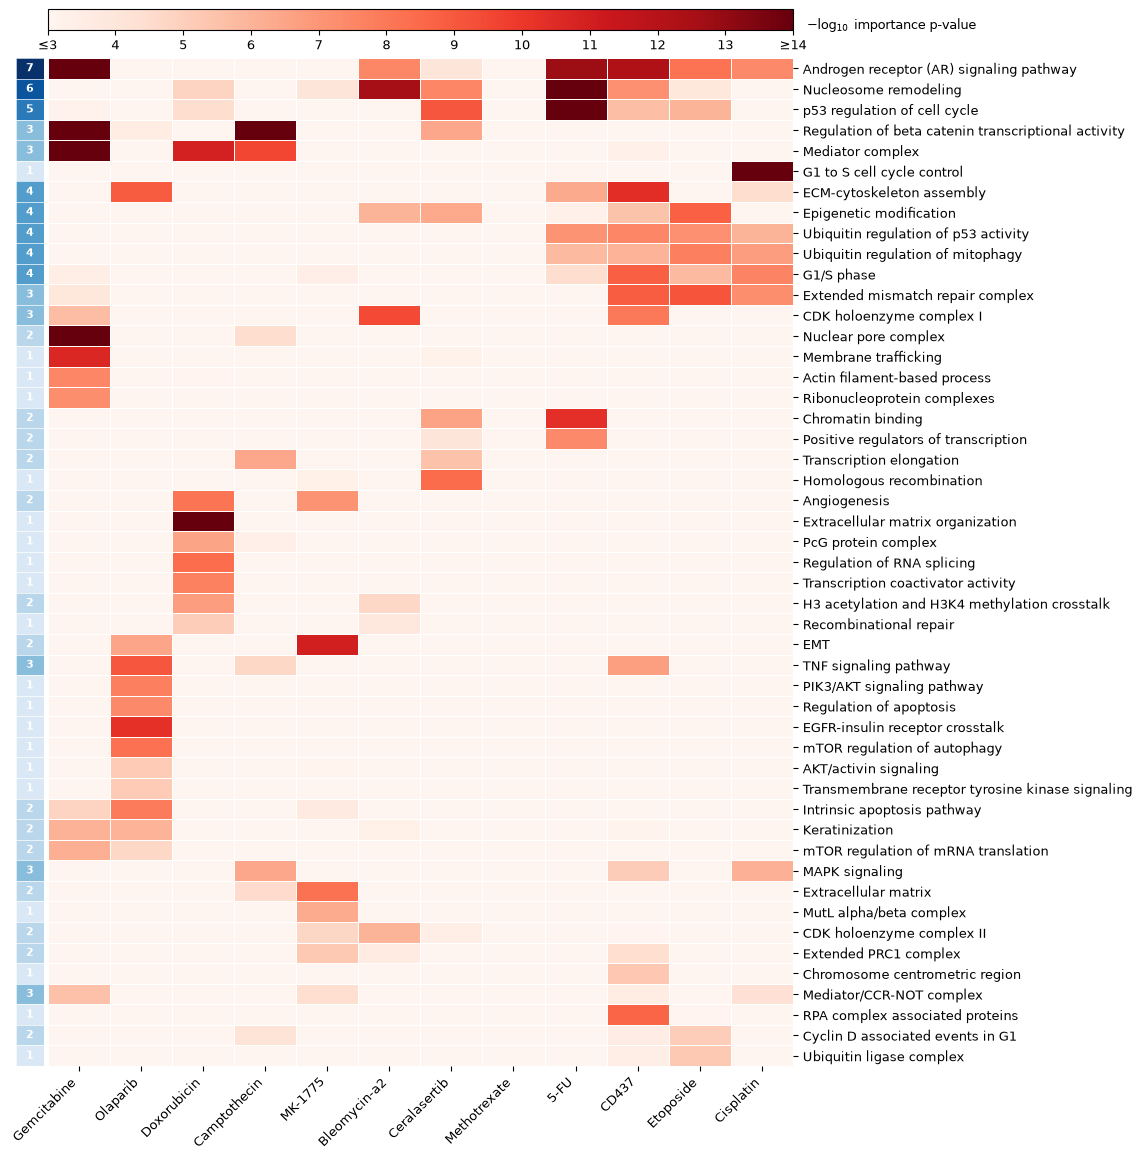

Saved SVG to: nest_system_importance_heatmap.svg


In [8]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict
from matplotlib.colors import Normalize


def plot_system_importance_heatmap_by_drug(
    importance_pvals,
    updated_important_systems,
    name_to_new_name,
    drugs=None,
    out_svg="nest_system_importance_heatmap.svg",
    vmin_hm=3.0,
    vmax_hm=14.0,
    figsize=(14, 14),
    cmap="Reds",
    linewidths=0.5,
    row_cluster=True,
    col_cluster=True,
    hide_row_dendrogram=True,
    hide_col_dendrogram=True,
    y_fontsize=9,
    x_fontsize=9,
    x_rotation=45,
    colorbar_height=0.015,
    colorbar_pad=0.02,
    count_threshold=1e-4,
    count_band_cmap="Blues",
    count_band_width=0.022,
    count_band_pad=0.0025,
    count_text_fontsize=8,
    show=True
):
    """
    Plot a systems (rows) x drugs (columns) clustermap of capped -log10(p-values),
    with row labels mapped from current system names to preferred new names.

    Adds a vertical annotation band immediately to the left of the heatmap.
    Each band cell corresponds to a system row and reports the number of drugs
    for which that system is significant at p <= count_threshold. The band is
    color-coded on a blue scale and the count is printed in white.
    """

    # -----------------------------
    # Defaults
    # -----------------------------
    if drugs is None:
        drugs = [
            'Etoposide', 'Camptothecin', 'Gemcitabine', 'Cisplatin', 'CD437',
            'Olaparib', 'MK-1775', '5-FU', 'Ceralasertib', 'Bleomycin-a2',
            'Doxorubicin', 'Methotrexate'
        ]

    # -----------------------------
    # Validate inputs
    # -----------------------------
    if not isinstance(name_to_new_name, pd.DataFrame):
        raise ValueError("name_to_new_name must be a pandas DataFrame.")
    if not {"Current Name", "New Name"}.issubset(name_to_new_name.columns):
        raise ValueError("name_to_new_name must contain columns ['Current Name', 'New Name'].")

    if not isinstance(updated_important_systems, (list, tuple, pd.Series, np.ndarray)):
        raise ValueError("updated_important_systems must be a list-like object of system names.")

    # Clean systems while preserving order
    systems = list(dict.fromkeys([str(x).strip() for x in updated_important_systems if pd.notna(x)]))
    if len(systems) == 0:
        raise ValueError("No valid systems found in updated_important_systems.")

    # -----------------------------
    # Build mapping: Current Name -> New Name
    # -----------------------------
    current_to_new = (
        name_to_new_name
        .dropna(subset=["Current Name", "New Name"])
        .assign(**{
            "Current Name": lambda d: d["Current Name"].astype(str).str.strip(),
            "New Name": lambda d: d["New Name"].astype(str).str.strip()
        })
        .drop_duplicates(subset=["Current Name"], keep="first")
        .set_index("Current Name")["New Name"]
        .to_dict()
    )

    # -----------------------------
    # Build matrix of capped -log10(p) and raw p-values
    # -----------------------------
    cap = vmax_hm
    Z = np.zeros((len(systems), len(drugs)), dtype=float)
    raw_pvals = np.full((len(systems), len(drugs)), np.nan, dtype=float)

    for j, sys_name in enumerate(systems):
        for i, drug in enumerate(drugs):
            p = importance_pvals.get(drug, {}).get(sys_name, np.nan)

            try:
                p = float(p)
            except (TypeError, ValueError):
                p = np.nan

            raw_pvals[j, i] = p

            if np.isnan(p):
                Z[j, i] = 0.0
            elif p <= 0:
                Z[j, i] = cap + 0.01
            else:
                val = -np.log10(p)
                Z[j, i] = val if val <= cap else (cap + 0.01)

    heat_df = pd.DataFrame(Z, index=systems, columns=drugs)
    raw_pval_df = pd.DataFrame(raw_pvals, index=systems, columns=drugs)

    # Count number of significant drugs per system
    sig_counts = pd.Series(
        {
            sys_name: int(np.sum(
                pd.to_numeric(raw_pval_df.loc[sys_name], errors="coerce") <= count_threshold
            ))
            for sys_name in systems
        }
    )

    # -----------------------------
    # Plot clustermap
    # -----------------------------
    figsize_tuple = (float(figsize[0]), float(figsize[1]))

    g = sns.clustermap(
        heat_df,
        cmap=cmap,
        vmin=vmin_hm,
        vmax=vmax_hm,
        figsize=figsize_tuple,
        linewidths=linewidths,
        row_cluster=row_cluster,
        col_cluster=col_cluster,
        cbar_pos=None
    )

    if hide_col_dendrogram and hasattr(g, "ax_col_dendrogram"):
        g.ax_col_dendrogram.set_visible(False)
    if hide_row_dendrogram and hasattr(g, "ax_row_dendrogram"):
        g.ax_row_dendrogram.set_visible(False)

    # -----------------------------
    # Relabel y-ticks using clustered row order
    # -----------------------------
    if row_cluster and getattr(g, "dendrogram_row", None) is not None:
        row_order = g.dendrogram_row.reordered_ind
    else:
        row_order = list(range(len(heat_df.index)))

    ordered_current_names = [heat_df.index[i] for i in row_order]
    ordered_new_names = [current_to_new.get(n, n) for n in ordered_current_names]

    g.ax_heatmap.set_yticks(np.arange(len(ordered_new_names)) + 0.5)
    g.ax_heatmap.set_yticklabels(ordered_new_names, fontsize=y_fontsize)

    xlabels = [t.get_text() for t in g.ax_heatmap.get_xmajorticklabels()]
    g.ax_heatmap.set_xticks(np.arange(len(xlabels)) + 0.5)
    g.ax_heatmap.set_xticklabels(
        xlabels,
        fontsize=x_fontsize,
        rotation=x_rotation,
        ha="right"
    )

    # -----------------------------
    # Add vertical count band to left of heatmap
    # -----------------------------
    ordered_counts = sig_counts.loc[ordered_current_names].to_numpy()
    heatmap_pos = g.ax_heatmap.get_position()
    fig = g.fig

    band_x = max(0.01, heatmap_pos.x0 - count_band_pad - count_band_width)
    band_y = heatmap_pos.y0
    band_h = heatmap_pos.height

    ax_band = fig.add_axes([band_x, band_y, count_band_width, band_h])

    count_mat = ordered_counts.reshape(-1, 1)
    vmax_count = max(1, int(np.nanmax(count_mat)))

    ax_band.imshow(
        count_mat,
        aspect="auto",
        cmap=count_band_cmap,
        norm=Normalize(vmin=0, vmax=vmax_count),
        origin="upper",
        interpolation="nearest"
    )

    # draw cell borders so band matches heatmap style
    n_rows = len(ordered_counts)
    for y in range(n_rows + 1):
        ax_band.plot([-0.5, 0.5], [y - 0.5, y - 0.5], color="white", lw=linewidths, clip_on=False)
    ax_band.plot([-0.5, -0.5], [-0.5, n_rows - 0.5], color="white", lw=linewidths, clip_on=False)
    ax_band.plot([0.5, 0.5], [-0.5, n_rows - 0.5], color="white", lw=linewidths, clip_on=False)

    # add white text counts
    for y, val in enumerate(ordered_counts):
        ax_band.text(
            0,
            y,
            str(int(val)),
            ha="center",
            va="center",
            color="white",
            fontsize=count_text_fontsize,
            fontweight="bold"
        )

    ax_band.set_xlim(-0.5, 0.5)
    ax_band.set_ylim(n_rows - 0.5, -0.5)
    ax_band.set_xticks([])
    ax_band.set_yticks([])
    for spine in ax_band.spines.values():
        spine.set_visible(False)

    # -----------------------------
    # Custom horizontal colorbar above heatmap
    # -----------------------------
    cbar_y = min(heatmap_pos.y1 + colorbar_pad, 0.98 - colorbar_height)
    cax = fig.add_axes([heatmap_pos.x0, cbar_y, heatmap_pos.width, colorbar_height])

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin_hm, vmax=vmax_hm))
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cax, orientation="horizontal")

    ticks = np.arange(int(vmin_hm), int(vmax_hm) + 1, 1)
    cbar.set_ticks(ticks)

    tick_labels = [str(t) for t in ticks]
    if len(tick_labels) > 0:
        tick_labels[0] = f"\u2264{int(vmin_hm)}"
        tick_labels[-1] = f"\u2265{int(vmax_hm)}"
    cbar.ax.set_xticklabels(tick_labels, fontsize=9)

    cbar.ax.set_ylabel(
        r"$-\log_{10}$ importance p-value",
        rotation=0,
        labelpad=10,
        va="center",
        ha="left",
        fontsize=9
    )
    cbar.ax.yaxis.set_label_position("right")

    # -----------------------------
    # Save / show
    # -----------------------------
    plt.rcParams["svg.fonttype"] = "none"
    g.fig.savefig(out_svg, format="svg", bbox_inches="tight")

    if show:
        plt.show()

    print(f"Saved SVG to: {out_svg}")

    return {
        "heat_df_current_names": heat_df,
        "raw_pval_df_current_names": raw_pval_df,
        "sig_counts_by_system": sig_counts,
        "figure": g.fig,
        "clustergrid": g,
        "ordered_current_names": ordered_current_names,
        "ordered_display_names": ordered_new_names,
        "drugs": drugs
    }

pcol = "p_bonferroni_pearson"
importance_pvals = {}
for drug, sub in importance_df_semi[["drug", "system", pcol]].dropna(subset=[pcol]).groupby("drug"):
    importance_pvals[drug] = dict(zip(sub["system"], sub[pcol].astype(float)))

result = plot_system_importance_heatmap_by_drug(
    importance_pvals=importance_pvals,
    updated_important_systems=updated_important_systems,
    name_to_new_name=name_to_new_name,
    figsize=(14, 14),
    out_svg="nest_system_importance_heatmap.svg",
    vmin_hm=3.0,
    vmax_hm=14.0,
    cmap="Reds",
    count_threshold=1e-4,
    count_band_cmap="Blues",
    count_band_width=0.02,
    count_text_fontsize=8
)

## iv. Create heatmap showing genes contained by important systems (Supplementary Fig. 5d)

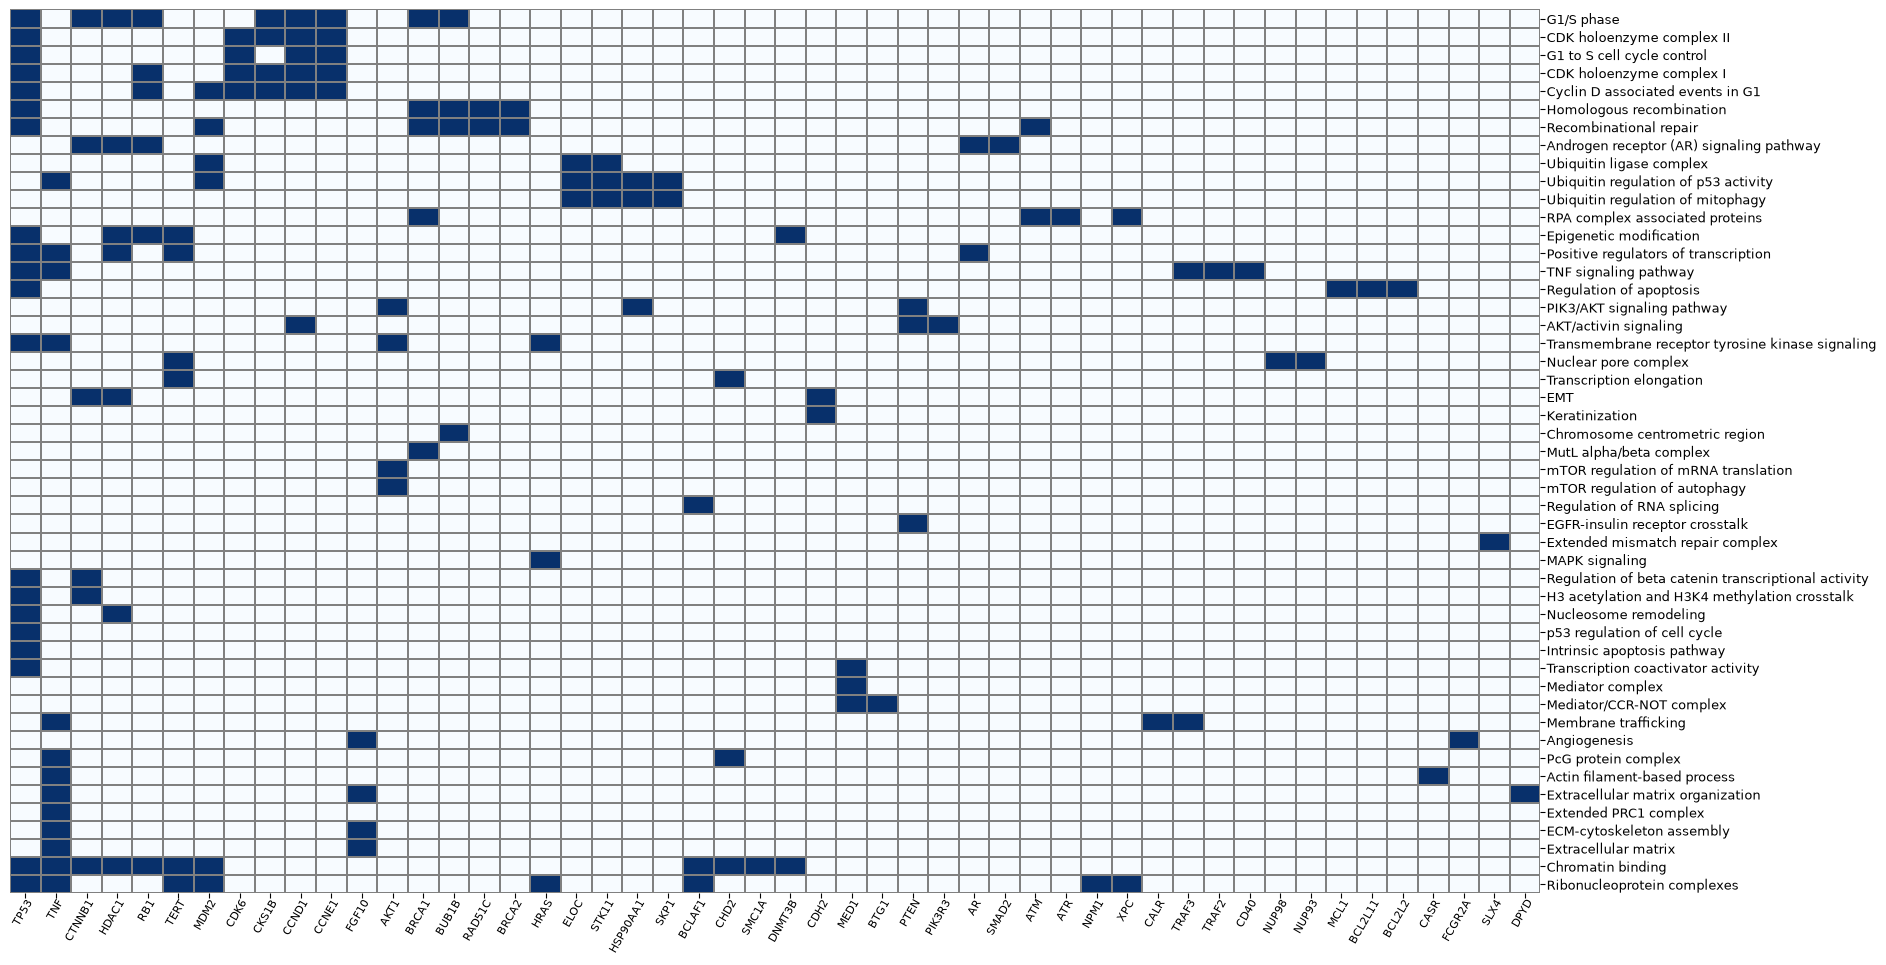

Saved SVG to: nest_system_gene_importance_heatmap_binary_50x50.svg


In [9]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


def plot_system_gene_importance_heatmap_with_nonimportant_bucket(
    updated_important_systems,
    important_genes,
    name_to_new_name,
    imp_genes,
    system_to_genes,  # dict[old_system_name] -> list of member genes
    out_svg="nest_system_gene_importance_heatmap_binary_with_nonimportant_bucket.svg",
    figsize=(18, 10),
    row_cluster=True,
    col_cluster=True,
    gene_fontsize=6,
    top_n_genes=50,
    nonimportant_row_label="System not in important list",
):
    """
    Systems (rows) x Genes (columns) binary membership heatmap with:
      - ALL important systems (rows)
      - PLUS one placeholder row for genes not belonging to any important system,
        BUT ONLY if at least one selected gene is not in any important system.

    Gene selection (columns):
      1) For each important system, collect that system's most important gene
         (smallest p_bonf_hmp among important_genes that are members of that system).
         This list is collected PER SYSTEM and duplicates are allowed at this step.
      2) Convert to unique genes while preserving order (for columns).
      3) Fill remaining slots up to top_n_genes using next most important genes overall
         (excluding already selected genes).

    Membership coloring:
      - Important system rows: 1 if selected gene is a member of that important system
      - Placeholder row: 1 if selected gene is NOT a member of ANY important system
    """

    # -----------------------------
    # Validate required columns
    # -----------------------------
    required_map_cols = {"Current Name", "New Name"}
    required_imp_cols = {"gene", "p_bonf_hmp"}

    missing_map_cols = required_map_cols - set(name_to_new_name.columns)
    missing_imp_cols = required_imp_cols - set(imp_genes.columns)

    if missing_map_cols:
        raise ValueError(f"name_to_new_name is missing required columns: {missing_map_cols}")
    if missing_imp_cols:
        raise ValueError(f"imp_genes is missing required columns: {missing_imp_cols}")

    if not isinstance(system_to_genes, dict):
        raise ValueError("system_to_genes must be a dictionary mapping OLD system names to lists of genes.")

    # -----------------------------
    # Clean inputs / preserve order
    # -----------------------------
    systems_input = list(dict.fromkeys([str(x).strip() for x in updated_important_systems if pd.notna(x)]))
    important_genes_input = list(dict.fromkeys([str(x).strip() for x in important_genes if pd.notna(x)]))

    if len(systems_input) == 0:
        raise ValueError("updated_important_systems is empty after cleaning.")
    if len(important_genes_input) == 0:
        raise ValueError("important_genes is empty after cleaning.")

    # -----------------------------
    # Build name mapping table (OLD/current -> preferred New Name)
    # -----------------------------
    map_df = (
        name_to_new_name.copy()
        .dropna(subset=["Current Name"])
        .assign(**{
            "Current Name": lambda d: d["Current Name"].astype(str).str.strip(),
            "New Name": lambda d: d["New Name"].astype(str).str.strip()
        })
        .drop_duplicates(subset=["Current Name"], keep="first")
        .set_index("Current Name")
    )
    current_to_new = map_df["New Name"].to_dict()

    # -----------------------------
    # Normalize system_to_genes keys/values
    # -----------------------------
    system_to_genes_clean = {}
    for k, v in system_to_genes.items():
        if k is None:
            continue
        try:
            if pd.isna(k):
                continue
        except Exception:
            pass

        sys_name = str(k).strip()
        if not sys_name:
            continue

        if isinstance(v, (list, tuple, set, np.ndarray, pd.Series)):
            genes = [str(x).strip() for x in v if pd.notna(x) and str(x).strip()]
        else:
            try:
                if pd.isna(v):
                    genes = []
                else:
                    vv = str(v).strip()
                    genes = [g.strip() for g in vv.split(",")] if "," in vv else ([vv] if vv else [])
                    genes = [g for g in genes if g]
            except Exception:
                vv = str(v).strip()
                genes = [g.strip() for g in vv.split(",")] if "," in vv else ([vv] if vv else [])
                genes = [g for g in genes if g]

        system_to_genes_clean[sys_name] = list(dict.fromkeys(genes))

    # -----------------------------
    # Gene p-value map (used for ranking)
    # -----------------------------
    imp_genes_clean = imp_genes.copy()
    imp_genes_clean["gene"] = imp_genes_clean["gene"].astype(str).str.strip()
    imp_genes_clean["p_bonf_hmp"] = pd.to_numeric(imp_genes_clean["p_bonf_hmp"], errors="coerce")
    imp_genes_clean = imp_genes_clean.dropna(subset=["gene", "p_bonf_hmp"]).copy()

    gene_to_p = (
        imp_genes_clean
        .groupby("gene", as_index=True)["p_bonf_hmp"]
        .min()
        .to_dict()
    )

    important_genes_rankable = [g for g in important_genes_input if g in gene_to_p and pd.notna(gene_to_p[g])]
    if len(important_genes_rankable) == 0:
        raise ValueError("No genes in important_genes have valid p_bonf_hmp values in imp_genes.")

    gene_order_rank = {g: i for i, g in enumerate(important_genes_input)}
    ranked_all_important_genes = sorted(
        important_genes_rankable,
        key=lambda g: (gene_to_p[g], gene_order_rank.get(g, 10**9))
    )

    # -----------------------------
    # Important system memberships
    # -----------------------------
    important_system_to_members = {
        sys_name: set(system_to_genes_clean.get(sys_name, []))
        for sys_name in systems_input
    }
    genes_in_any_important_system = set().union(*important_system_to_members.values()) if important_system_to_members else set()

    # -----------------------------
    # Step 1: collect most important gene PER system (duplicates allowed here)
    # -----------------------------
    representative_genes_per_system = []   # duplicates allowed
    system_representative_gene = {}
    systems_without_representative = []

    for sys_name in systems_input:
        members = important_system_to_members.get(sys_name, set())
        candidates = [g for g in ranked_all_important_genes if g in members]

        if len(candidates) == 0:
            systems_without_representative.append(sys_name)
            continue

        best_gene = candidates[0]
        system_representative_gene[sys_name] = best_gene
        representative_genes_per_system.append(best_gene)

    # Convert to unique genes for columns while preserving order
    representative_genes_unique = list(dict.fromkeys(representative_genes_per_system))

    # -----------------------------
    # Step 2: fill remaining slots with next best genes overall
    # -----------------------------
    selected_genes = representative_genes_unique.copy()
    selected_gene_set = set(selected_genes)

    for g in ranked_all_important_genes:
        if len(selected_genes) >= int(top_n_genes):
            break
        if g in selected_gene_set:
            continue
        selected_genes.append(g)
        selected_gene_set.add(g)

    if len(selected_genes) == 0:
        raise ValueError("Gene selection produced an empty set.")

    # In rare case unique representatives exceed top_n
    if len(selected_genes) > int(top_n_genes):
        selected_genes = selected_genes[:int(top_n_genes)]
        selected_gene_set = set(selected_genes)

    # -----------------------------
    # Determine whether placeholder row is needed
    # -----------------------------
    genes_not_in_any_important_system_selected = [
        g for g in selected_genes if g not in genes_in_any_important_system
    ]
    include_placeholder = len(genes_not_in_any_important_system_selected) > 0

    # -----------------------------
    # Rows = all important systems + optional placeholder
    # -----------------------------
    included_systems = systems_input.copy()
    placeholder_row = nonimportant_row_label

    if include_placeholder:
        row_names = included_systems + [placeholder_row]
    else:
        row_names = included_systems.copy()

    # -----------------------------
    # Build BINARY matrix
    # -----------------------------
    Z = np.zeros((len(row_names), len(selected_genes)), dtype=float)

    # important system rows
    for r, sys_name in enumerate(included_systems):
        members = important_system_to_members.get(sys_name, set())
        for c, gene in enumerate(selected_genes):
            Z[r, c] = 1.0 if gene in members else 0.0

    # optional placeholder row: 1 if gene not in ANY important system
    if include_placeholder:
        placeholder_r = len(row_names) - 1
        for c, gene in enumerate(selected_genes):
            Z[placeholder_r, c] = 1.0 if gene not in genes_in_any_important_system else 0.0

    heat_df = pd.DataFrame(Z, index=row_names, columns=selected_genes)

    # -----------------------------
    # Plot
    # -----------------------------
    g = sns.clustermap(
        heat_df,
        cmap="Blues",
        vmin=0, vmax=1,
        figsize=figsize,
        linewidths=0.05,
        linecolor="grey",
        row_cluster=row_cluster,
        col_cluster=col_cluster,
        cbar_pos=None,
        dendrogram_ratio=(0.001, 0.001)
    )

    # Hide dendrograms (clustering still applied)
    if hasattr(g, "ax_row_dendrogram"):
        g.ax_row_dendrogram.set_visible(False)
    if hasattr(g, "ax_col_dendrogram"):
        g.ax_col_dendrogram.set_visible(False)

    # -----------------------------
    # Relabel rows safely
    # -----------------------------
    if row_cluster and hasattr(g, "dendrogram_row") and g.dendrogram_row is not None:
        row_order = g.dendrogram_row.reordered_ind
    else:
        row_order = list(range(len(heat_df.index)))

    ordered_current_names = [heat_df.index[i] for i in row_order]

    def _display_row_name(rn: str) -> str:
        if rn == placeholder_row:
            return placeholder_row
        return current_to_new.get(rn, rn)

    ordered_display_names = [_display_row_name(n) for n in ordered_current_names]

    g.ax_heatmap.set_yticks(np.arange(len(ordered_display_names)) + 0.5)
    g.ax_heatmap.set_yticklabels(ordered_display_names, fontsize=9)

    # -----------------------------
    # Relabel columns safely + keep 60° angle
    # -----------------------------
    if col_cluster and hasattr(g, "dendrogram_col") and g.dendrogram_col is not None:
        col_order = g.dendrogram_col.reordered_ind
    else:
        col_order = list(range(len(heat_df.columns)))

    ordered_gene_names = [heat_df.columns[i] for i in col_order]

    g.ax_heatmap.set_xticks(np.arange(len(ordered_gene_names)) + 0.5)
    g.ax_heatmap.set_xticklabels(
        ordered_gene_names,
        fontsize=gene_fontsize,
        rotation=60,
        ha="right",
        rotation_mode="anchor"
    )

    g.ax_heatmap.tick_params(axis='x', pad=0)
    g.ax_heatmap.tick_params(axis='y', pad=1)

    # Ensure x tick labels are bottom only
    g.ax_heatmap.xaxis.set_ticks_position('bottom')
    g.ax_heatmap.xaxis.set_label_position('bottom')

    # -----------------------------
    # Save
    # -----------------------------
    plt.rcParams["svg.fonttype"] = "none"
    g.fig.savefig(out_svg, format="svg", bbox_inches="tight")

    plt.show()
    print(f"Saved SVG to: {out_svg}")

    return {
        "heat_df_binary_current_names_plus_placeholder": heat_df,
        "included_systems_current": included_systems,
        "included_systems_display": [current_to_new.get(s, s) for s in included_systems],
        "placeholder_row_label": placeholder_row if include_placeholder else None,
        "placeholder_row_included": include_placeholder,

        # Gene selection summaries
        "representative_genes_per_system_with_duplicates": representative_genes_per_system,
        "representative_genes_unique": representative_genes_unique,
        "system_representative_gene": system_representative_gene,
        "systems_without_representative_gene": systems_without_representative,

        "selected_genes": selected_genes,
        "selected_genes_not_in_any_important_system": genes_not_in_any_important_system_selected,

        "n_rows": int(heat_df.shape[0]),
        "n_cols": int(heat_df.shape[1]),
        "top_n_genes_requested": int(top_n_genes),
        "top_n_genes_used": int(len(selected_genes)),
        "n_important_systems": int(len(included_systems)),
        "n_systems_without_representative_gene": int(len(systems_without_representative)),
        "n_representative_genes_per_system_with_duplicates": int(len(representative_genes_per_system)),
        "n_unique_representative_genes": int(len(representative_genes_unique)),
        "n_selected_genes_not_in_any_important_system": int(len(genes_not_in_any_important_system_selected)),

        "figure": g.fig,
        "clustergrid": g
    }


# ---- usage ----
result = plot_system_gene_importance_heatmap_with_nonimportant_bucket(
    updated_important_systems=updated_important_systems,
    important_genes=important_genes,
    name_to_new_name=name_to_new_name,
    imp_genes=imp_genes,
    system_to_genes=system_to_genes,
    out_svg="nest_system_gene_importance_heatmap_binary_50x50.svg",
    figsize=(20, 10),
    gene_fontsize=8,
    top_n_genes=50
)

## v. Comparing Important Scores in RSi Model vs Non-RSi Model

In [10]:
rsi_important_systems = updated_important_systems
rsi_important_genes = important_genes

### Load in the Non-RSi Importance Dataframe

In [11]:
non_rsi_gene_importance_df = pd.read_csv("non_rsi_gene_semi_partial_importance_g2d.csv")
non_rsi_gene_importance_df.head()

,drug,gene,semi_partial_pearson,semi_partial_spearman,p_pearson,p_spearman,p_bonferroni_pearson,p_bonferroni_spearman,q_fdr_pearson,q_fdr_spearman,q_fdr_pearson_all,q_fdr_spearman_all
0,Daporinad,ABCB1,-0.045669,0.050877,1.832225e-01,1.374017e-01,1.000000e+00,1.000000,3.132233e-01,0.185441,2.968495e-01,0.183117
1,Daporinad,ABCC3,0.084275,0.071425,1.401018e-02,3.710363e-02,1.000000e+00,1.000000,5.239222e-02,0.058294,3.778143e-02,0.056601
2,Daporinad,ABL1,0.025235,0.083749,4.617488e-01,1.452769e-02,1.000000e+00,1.000000,6.231874e-01,0.025014,5.913290e-01,0.024424
3,Daporinad,ABL2,-0.228857,-0.129684,2.542544e-11,1.576311e-04,1.825547e-08,0.113179,9.127733e-09,0.000394,6.761284e-10,0.000390
4,Daporinad,ACTA2,0.068295,0.171101,4.646052e-02,6.016146e-07,1.000000e+00,0.000432,1.244726e-01,0.000003,1.005031e-01,0.000002


In [12]:
non_rsi_system_importance_df = pd.read_csv("non_rsi_system_semi_partial_importance_g2d.csv")
non_rsi_system_importance_df.head()

,drug,system,semi_partial_pearson,semi_partial_spearman,p_pearson,p_spearman,p_bonferroni_pearson,p_bonferroni_spearman,q_fdr_pearson,q_fdr_spearman,q_fdr_pearson_all,q_fdr_spearman_all
0,Daporinad,Cell,-0.162359,-0.085293,2.258708e-06,1.297979e-02,2.958908e-04,1.000000e+00,2.026880e-05,3.036343e-02,2.126161e-05,3.102065e-02
1,Daporinad,Signaling pathways,0.248685,0.239317,4.392042e-13,3.110845e-12,5.753575e-11,4.075207e-10,1.917858e-11,1.358402e-10,2.301430e-11,1.040478e-10
2,Daporinad,Chromatin binding,0.067626,0.124732,4.889131e-02,2.786336e-04,1.000000e+00,3.650100e-02,9.704185e-02,1.351889e-03,9.583185e-02,1.078847e-03
3,Daporinad,CDK holoenzyme complex II,0.042897,0.086215,2.115532e-01,1.199651e-02,1.000000e+00,1.000000e+00,2.979943e-01,2.965175e-02,3.143304e-01,2.919274e-02
4,Daporinad,MAPK and MAP2K activation,-0.046514,0.081440,1.754818e-01,1.763737e-02,1.000000e+00,1.000000e+00,2.594490e-01,3.726605e-02,2.705843e-01,4.035800e-02


### a. Score of Important Genes in RSi vs Non-RSi (Fig 4b,c)

In [13]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon, mannwhitneyu
from typing import Iterable, Dict, Any, Optional, Literal


def _add_sig_bracket(ax, x1, x2, y, h, text, lw=1.2, mid_tick=False, tick_frac=0.45):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y],
            color="black", linewidth=lw, clip_on=False)
    if mid_tick:
        xm = (x1 + x2) / 2
        ax.plot([xm, xm], [y + h, y + h - tick_frac * h],
                color="black", linewidth=lw, clip_on=False)
    ax.text((x1 + x2) / 2, y + h, text,
            ha="center", va="bottom", fontsize=10, color="black", clip_on=False)


def _format_p_for_bracket(p: float) -> str:
    if not np.isfinite(p):
        return r"$P = \mathrm{nan}$"

    if p < 1e-4:
        exp = int(np.floor(np.log10(p)))
        a = p / (10 ** exp)
        return rf"$P = {a:.0f}\times 10^{{{exp}}}$"

    if 1e-2 < p < 5e-2:
        return rf"$P = {p:.3f}$"
    if 1e-3 < p <= 1e-2:
        return rf"$P = {p:.4f}$"
    if 1e-4 < p <= 1e-3:
        return rf"$P = {p:.5f}$"

    return f"$P = {p:.4f}$"


def swarm_compare_abs_importance(
    important_items: Iterable[str],
    rsi_importance_df: pd.DataFrame,
    non_rsi_importance_df: pd.DataFrame,
    out_svg: str,
    analysis: Literal["gene", "system"] = "gene",
    score_col: str = "semi_partial_pearson",
    drug_col: str = "drug",
    aggregate: Literal["max", "mean"] = "max",
    test: Literal["wilcoxon", "mannwhitney"] = "wilcoxon",
    alternative: str = "greater",
    zero_method: str = "pratt",
    figsize=(5, 5),
    title: Optional[str] = None,
    make_plot: bool = True,
    rsi_label: str = "RSi drug scores",
    non_rsi_label: str = "Non-RSi drug scores",
    median_halfwidth: float = 0.35,
    y_top: float = 0.5
) -> Dict[str, Any]:

    if analysis not in {"gene", "system"}:
        raise ValueError("analysis must be 'gene' or 'system'.")
    if aggregate not in {"max", "mean"}:
        raise ValueError("aggregate must be 'max' or 'mean'.")

    item_col = "gene" if analysis == "gene" else "system"

    required = {item_col, drug_col, score_col}
    for df_name, df in [("rsi_importance_df", rsi_importance_df),
                        ("non_rsi_importance_df", non_rsi_importance_df)]:
        missing = required - set(df.columns)
        if missing:
            raise KeyError(f"{df_name} missing required column(s): {missing}")

    items = sorted(set(map(str, important_items)))
    if len(items) == 0:
        raise ValueError("important_items is empty.")

    # --- slim + clean ---
    rsi = rsi_importance_df[[item_col, drug_col, score_col]].dropna().copy()
    non = non_rsi_importance_df[[item_col, drug_col, score_col]].dropna().copy()
    rsi[item_col] = rsi[item_col].astype(str)
    non[item_col] = non[item_col].astype(str)

    rsi = rsi[rsi[item_col].isin(items)]
    non = non[non[item_col].isin(items)]

    rsi["abs_score"] = pd.to_numeric(rsi[score_col], errors="coerce").abs()
    non["abs_score"] = pd.to_numeric(non[score_col], errors="coerce").abs()
    rsi = rsi.dropna(subset=["abs_score"])
    non = non.dropna(subset=["abs_score"])

    # --- per-item aggregation across drugs ---
    agg_func = aggregate
    agg_label = f"{aggregate}_abs_score"

    rsi_agg = (
        rsi.groupby(item_col, as_index=False)["abs_score"]
        .agg(agg_func)
        .rename(columns={"abs_score": "agg_abs_score_rsi"})
    )
    non_agg = (
        non.groupby(item_col, as_index=False)["abs_score"]
        .agg(agg_func)
        .rename(columns={"abs_score": "agg_abs_score_nonrsi"})
    )

    merged = pd.merge(rsi_agg, non_agg, on=item_col, how="inner").dropna()
    if merged.empty:
        raise ValueError(f"No overlap between provided {analysis}s and both importance dataframes.")

    x = merged["agg_abs_score_rsi"].to_numpy(dtype=float)
    y = merged["agg_abs_score_nonrsi"].to_numpy(dtype=float)

    med_x = float(np.median(x))
    med_y = float(np.median(y))

    # --- choose test ---
    test = str(test).lower().strip()
    stat = np.nan
    p = np.nan
    test_name = None

    try:
        if test in {"wilcoxon", "paired_wilcoxon", "paired"}:
            test_name = "paired Wilcoxon"
            stat, p = wilcoxon(x, y, alternative=alternative, zero_method=zero_method)
        elif test in {"mannwhitney", "mwu", "mann-whitney", "mannwhitneyu"}:
            test_name = "Mann–Whitney U"
            stat, p = mannwhitneyu(x, y, alternative=alternative)
        else:
            raise ValueError("test must be one of: 'wilcoxon' or 'mannwhitney'")
    except ValueError:
        stat, p = np.nan, np.nan

    p_label = _format_p_for_bracket(float(p) if np.isfinite(p) else np.nan)

    df_plot = pd.DataFrame({
        "value": np.concatenate([x, y]),
        "Model Type": ([rsi_label] * len(x)) + ([non_rsi_label] * len(y))
    })

    if make_plot:
        fig, ax = plt.subplots(figsize=figsize)

        palette = {rsi_label: "#1f77b4", non_rsi_label: "#ff7f0e"}

        sns.swarmplot(
            data=df_plot, x="Model Type", y="value",
            order=[rsi_label, non_rsi_label],
            palette=palette,
            ax=ax, size=8, edgecolor="black", linewidth=0.5, alpha=0.7,
            warn_thresh=0.1
        )

        x_left, x_right = 0, 1

        ax.tick_params(axis="x", labelsize=11)

        # centered median lines
        ax.plot([x_left - median_halfwidth, x_left + median_halfwidth], [med_x, med_x],
                color="black", linestyle="--", linewidth=2.7, solid_capstyle="butt", zorder=3)
        ax.plot([x_right - median_halfwidth, x_right + median_halfwidth], [med_y, med_y],
                color="black", linestyle="--", linewidth=2.7, solid_capstyle="butt", zorder=3)

        ax.set_ylabel(
            f"Raw {analysis} importance score\n({aggregate} across all drugs)",
            fontsize=11
        )
        ax.set_xlabel("")
        ax.set_title(title or "", fontsize=11, y=1.04)

        ax.grid(False)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        ax.set_xlim(-0.5, 1.5)

        ticks = np.arange(0.0, y_top + 1e-12, 0.05)
        ax.set_ylim(0.0, y_top)
        ax.set_yticks(ticks)
        ax.set_yticklabels([f"{t:.2f}" for t in ticks])

        h = 0.02 * y_top
        pad = 0.02 * y_top
        y0 = y_top - (h + pad)

        _add_sig_bracket(ax, x_left, x_right, y0, h, p_label, lw=1.2)

        plt.tight_layout()

        plt.rcParams["svg.fonttype"] = "none"
        fig.savefig(out_svg, format="svg", bbox_inches="tight")
        print(f"Saved SVG to: {out_svg}")

        plt.show()

    return {
        "analysis": analysis,
        "item_col": item_col,
        "aggregate": aggregate,
        "n_items_used": int(len(merged)),
        "median_rsi": med_x,
        "median_nonrsi": med_y,
        "test": test,
        "test_name": test_name,
        "statistic": float(stat) if np.isfinite(stat) else np.nan,
        "p_value": float(p) if np.isfinite(p) else np.nan,
        "p_label": p_label,
        "alternative": alternative,
        "zero_method": zero_method if test.startswith("wil") else None,
        f"used_{analysis}s": merged[item_col].tolist(),
        "per_item_table": merged,
    }


# Optional backward-compatible alias
def swarm_compare_max_abs_importance(*args, aggregate: Literal["max", "mean"] = "max", **kwargs):
    return swarm_compare_abs_importance(*args, aggregate=aggregate, **kwargs)

#### Important Genes (Fig. 4b)

Saved SVG to: rsi_vs_nonrsi_genes.svg


/var/folders/xn/6msch0w517d5fc96lf16x1wc0000gp/T/ipykernel_2856/201213721.py:147: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(
/opt/miniconda3/envs/jupyter/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 29.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


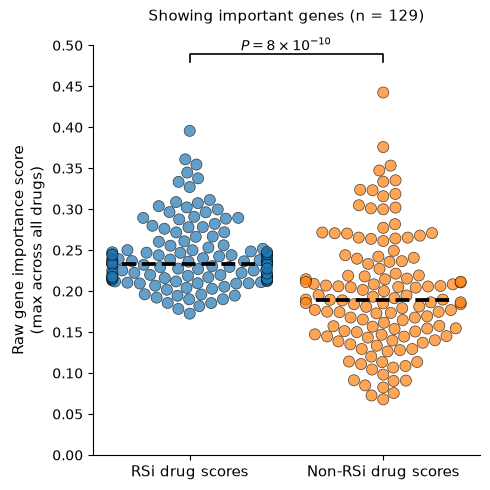

In [14]:
out_gene = swarm_compare_max_abs_importance(important_items=rsi_important_genes,
                                                   rsi_importance_df=gene_importance_df,
                                                   non_rsi_importance_df=non_rsi_gene_importance_df,
                                                   title="Showing important genes (n = "+str(len(rsi_important_genes))+")",
                                                   analysis="gene",
                                                   aggregate="max",
                                                   test="wilcoxon",
                                                   y_top=0.5,
                                                   score_col="semi_partial_pearson",
                                                   alternative="greater",
                                                   out_svg="rsi_vs_nonrsi_genes.svg"
                                                  )

#### Important Systems (Fig. 4c)

/var/folders/xn/6msch0w517d5fc96lf16x1wc0000gp/T/ipykernel_2856/201213721.py:147: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(


Saved SVG to: rsi_vs_nonrsi_systems.svg


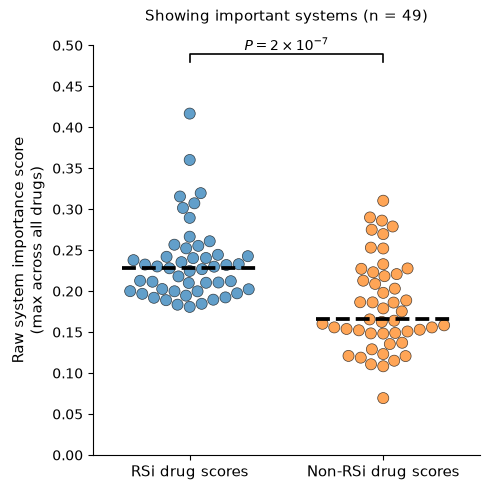

In [15]:
out_sys = swarm_compare_max_abs_importance(important_items=rsi_important_systems,
                                                  rsi_importance_df=importance_df_semi,
                                                  non_rsi_importance_df=non_rsi_system_importance_df,
                                                  title="Showing important systems (n = "+str(len(rsi_important_systems))+")",
                                                  analysis="system",
                                                  aggregate="max",
                                                  test="wilcoxon",
                                                  y_top=0.5,
                                                  score_col="semi_partial_pearson",
                                                  alternative="greater",
                                                  out_svg="rsi_vs_nonrsi_systems.svg"
                                                 )

### b. Importance Score Distribution of ALL Systems/Genes (Supplementary Fig. 5b,c)

In [16]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

from scipy.stats import wilcoxon
from typing import Iterable, Dict, Any, Optional, Literal


def _add_sig_bracket(ax, x1, x2, y, h, text, lw=1.2, mid_tick=False, tick_frac=0.45):
    ax.plot(
        [x1, x1, x2, x2],
        [y, y + h, y + h, y],
        color="black",
        linewidth=lw,
        clip_on=False,
    )

    if mid_tick:
        xm = (x1 + x2) / 2
        ax.plot(
            [xm, xm],
            [y + h, y + h - tick_frac * h],
            color="black",
            linewidth=lw,
            clip_on=False,
        )

    ax.text(
        (x1 + x2) / 2,
        y + h,
        text,
        ha="center",
        va="bottom",
        fontsize=10,
        color="black",
        clip_on=False,
    )


def _format_raw_p_for_bracket(p: float) -> str:
    """
    Always show raw p-value above bracket.

    Rules:
      - show raw p-value even if not significant
      - if p > 0.05, round to nearest hundredth
      - otherwise show more precision / scientific notation when very small
    """
    if not np.isfinite(p):
        return "P = nan"

    if p > 0.05:
        return f"P = {p:.2f}"
    if p < 1e-4:
        return f"P = {p:.1e}"
    return f"P = {p:.4f}"


def _recolor_swarm_points_red_if_important(
    ax: plt.Axes,
    df_long: pd.DataFrame,
    item_col: str,
    x_col: str,
    y_col: str,
    order: list,
    important_items: set,
    default_palette: Dict[str, str],
    important_color: str = "red",
):
    """
    Recolor already-drawn swarm points in-place.

    This preserves seaborn's original swarm positions and avoids overplotting.
    """

    collections = [c for c in ax.collections if hasattr(c, "get_offsets")]

    if len(collections) == 0:
        return

    df_tmp = df_long.copy()
    df_tmp[item_col] = df_tmp[item_col].astype(str)

    group_rows = {
        g: df_tmp[df_tmp[x_col] == g][[item_col, y_col]].reset_index(drop=True)
        for g in order
    }

    default_rgba = {
        g: np.array(plt.matplotlib.colors.to_rgba(default_palette[g]))
        for g in order
    }

    important_rgba = np.array(plt.matplotlib.colors.to_rgba(important_color))

    for coll in collections:
        offs = coll.get_offsets()

        if offs is None or len(offs) == 0:
            continue

        offs = np.asarray(offs, dtype=float)
        xs = offs[:, 0]
        ys = offs[:, 1]

        x_med = float(np.median(xs))
        grp = min(order, key=lambda g: abs(x_med - order.index(g)))

        sub = group_rows.get(grp, None)

        if sub is None or len(sub) != len(ys):
            continue

        point_order = np.argsort(ys, kind="mergesort")
        row_order = np.argsort(sub[y_col].to_numpy(dtype=float), kind="mergesort")

        face = np.tile(default_rgba[grp], (len(ys), 1))
        sub_items_sorted = sub[item_col].to_numpy()[row_order]

        for k, item_name in enumerate(sub_items_sorted):
            if item_name in important_items:
                face[point_order[k]] = important_rgba

        coll.set_facecolors(face)


def swarm_all_items_highlight_important_paired_wilcoxon_formatted(
    important_items: Iterable[str],
    rsi_importance_df: pd.DataFrame,
    non_rsi_importance_df: pd.DataFrame,
    system_to_genes: Dict[str, Iterable[str]],
    out_svg: str,
    analysis: Literal["gene", "system"] = "gene",
    score_col: str = "semi_partial_pearson",
    drug_col: str = "drug",
    zero_method: str = "pratt",
    figsize=(5, 5),
    title: Optional[str] = None,
    make_plot: bool = True,
    rsi_label: str = "RSi drug scores",
    non_rsi_label: str = "Non-RSi drug scores",
    median_halfwidth: float = 0.35,
    max_genes_per_system: int = 100,
    y_top: Optional[float] = 0.50,
    y_tick_step: float = 0.05,
    swarm_size_base: float = 6.5,

    # New option
    color_important: bool = True,
    important_color: str = "red",

    # Legend options used only when color_important=True
    show_highlight_legend: bool = True,
    highlight_legend_anchor=(0.5, 0.965),
    highlight_legend_fontsize: float = 10,
) -> Dict[str, Any]:
    """
    Plot all genes/systems as paired RSI vs non-RSI swarm distributions using
    per-item max |score| across drugs.

    If color_important=True:
        important genes/systems are recolored red.

    If color_important=False:
        all points keep their base model colors.
    """

    # -----------------------------
    # Validate analysis
    # -----------------------------
    if analysis not in {"gene", "system"}:
        raise ValueError("analysis must be 'gene' or 'system'.")

    item_col = "gene" if analysis == "gene" else "system"

    # -----------------------------
    # Validate columns
    # -----------------------------
    needed = {item_col, drug_col, score_col}

    for name, df in [
        ("rsi_importance_df", rsi_importance_df),
        ("non_rsi_importance_df", non_rsi_importance_df),
    ]:
        missing = needed - set(df.columns)

        if missing:
            raise KeyError(f"{name} missing required column(s): {missing}")

    if not isinstance(system_to_genes, dict):
        raise ValueError("system_to_genes must be a dict mapping system -> iterable of genes.")

    # -----------------------------
    # Normalize system_to_genes + compute allowed systems/genes
    # -----------------------------
    system_to_genes_clean = {}
    allowed_systems = set()
    genes_in_small_systems = set()

    for sys_name, genes in system_to_genes.items():
        if pd.isna(sys_name):
            continue

        s = str(sys_name).strip()

        if isinstance(genes, (list, tuple, set, np.ndarray, pd.Series)):
            gene_list = [
                str(g).strip()
                for g in genes
                if pd.notna(g) and str(g).strip()
            ]

        elif genes is None or (isinstance(genes, float) and np.isnan(genes)):
            gene_list = []

        else:
            gs = str(genes).strip()
            gene_list = (
                [g.strip() for g in gs.split(",")]
                if "," in gs
                else ([gs] if gs else [])
            )
            gene_list = [g for g in gene_list if g]

        gene_list = list(dict.fromkeys(gene_list))
        system_to_genes_clean[s] = gene_list

        if len(gene_list) <= max_genes_per_system:
            allowed_systems.add(s)
            genes_in_small_systems.update(gene_list)

    # -----------------------------
    # Important item set
    # -----------------------------
    important = {
        str(x)
        for x in important_items
        if x is not None and str(x).strip()
    }

    # -----------------------------
    # Prep helper
    # -----------------------------
    def _prep(df: pd.DataFrame) -> pd.DataFrame:
        d = df[[item_col, drug_col, score_col]].dropna().copy()

        d[item_col] = d[item_col].astype(str)
        d[drug_col] = d[drug_col].astype(str)
        d[score_col] = pd.to_numeric(d[score_col], errors="coerce")

        d = d.dropna(subset=[score_col])

        if analysis == "gene":
            d = d[d[item_col].isin(genes_in_small_systems)].copy()
        else:
            d = d[d[item_col].isin(allowed_systems)].copy()

        d["abs_score"] = d[score_col].abs()

        return d

    rsi = _prep(rsi_importance_df)
    non = _prep(non_rsi_importance_df)

    if rsi.empty or non.empty:
        raise ValueError(
            "No rows remain after applying filtering criteria "
            "(including <= max_genes_per_system filter)."
        )

    # -----------------------------
    # Per-item best across drugs = max abs(score)
    # -----------------------------
    rsi_best = rsi.loc[
        rsi.groupby(item_col)["abs_score"].idxmax(),
        [item_col, drug_col, score_col, "abs_score"],
    ].copy()

    rsi_best = rsi_best.rename(
        columns={
            drug_col: "rsi_best_drug",
            score_col: "rsi_best_score_signed",
            "abs_score": "rsi_max_abs",
        }
    )

    non_best = non.loc[
        non.groupby(item_col)["abs_score"].idxmax(),
        [item_col, drug_col, score_col, "abs_score"],
    ].copy()

    non_best = non_best.rename(
        columns={
            drug_col: "nonrsi_best_drug",
            score_col: "nonrsi_best_score_signed",
            "abs_score": "nonrsi_max_abs",
        }
    )

    # Paired universe
    merged = pd.merge(rsi_best, non_best, on=item_col, how="inner").dropna()

    if merged.empty:
        raise ValueError(
            "No overlapping items between RSI and non-RSI models after aggregation/filtering."
        )

    merged["is_important"] = merged[item_col].isin(important)

    # -----------------------------
    # Paired Wilcoxon across all items
    # -----------------------------
    x = merged["rsi_max_abs"].to_numpy(dtype=float)
    y = merged["nonrsi_max_abs"].to_numpy(dtype=float)

    try:
        stat_all, p_all = wilcoxon(
            x,
            y,
            alternative="greater",
            zero_method=zero_method,
        )
    except ValueError:
        stat_all, p_all = np.nan, np.nan

    p_label = _format_raw_p_for_bracket(
        float(p_all) if np.isfinite(p_all) else np.nan
    )

    # -----------------------------
    # Important-only Wilcoxon, returned only
    # -----------------------------
    imp_pairs = merged[merged["is_important"]].copy()

    if len(imp_pairs) >= 1:
        try:
            stat_imp, p_imp = wilcoxon(
                imp_pairs["rsi_max_abs"].to_numpy(dtype=float),
                imp_pairs["nonrsi_max_abs"].to_numpy(dtype=float),
                alternative="two-sided",
                zero_method=zero_method,
            )
        except ValueError:
            stat_imp, p_imp = np.nan, np.nan
    else:
        stat_imp, p_imp = np.nan, np.nan

    med_rsi_all = float(np.median(x))
    med_non_all = float(np.median(y))

    # -----------------------------
    # Long table for plotting
    # -----------------------------
    df_long = pd.concat(
        [
            pd.DataFrame(
                {
                    item_col: merged[item_col].values,
                    "Model Type": rsi_label,
                    "value": merged["rsi_max_abs"].values,
                    "is_important": merged["is_important"].values,
                }
            ),
            pd.DataFrame(
                {
                    item_col: merged[item_col].values,
                    "Model Type": non_rsi_label,
                    "value": merged["nonrsi_max_abs"].values,
                    "is_important": merged["is_important"].values,
                }
            ),
        ],
        ignore_index=True,
    )

    # -----------------------------
    # Plot
    # -----------------------------
    if make_plot:
        fig, ax = plt.subplots(figsize=figsize)

        order = [rsi_label, non_rsi_label]
        palette_base = {
            rsi_label: "#1f77b4",
            non_rsi_label: "#ff7f0e",
        }

        sns.swarmplot(
            data=df_long,
            x="Model Type",
            y="value",
            order=order,
            palette=palette_base,
            ax=ax,
            size=swarm_size_base,
            edgecolor="black",
            linewidth=0.5,
            alpha=0.65,
            warn_thresh=0.1,
        )

        # Optional recoloring of important items
        if color_important:
            _recolor_swarm_points_red_if_important(
                ax=ax,
                df_long=df_long,
                item_col=item_col,
                x_col="Model Type",
                y_col="value",
                order=order,
                important_items=important,
                default_palette=palette_base,
                important_color=important_color,
            )

        x_left, x_right = 0, 1

        # Centered median lines
        ax.plot(
            [x_left - median_halfwidth, x_left + median_halfwidth],
            [med_rsi_all, med_rsi_all],
            color="black",
            linestyle="--",
            linewidth=2.7,
            solid_capstyle="butt",
            zorder=3,
        )

        ax.plot(
            [x_right - median_halfwidth, x_right + median_halfwidth],
            [med_non_all, med_non_all],
            color="black",
            linestyle="--",
            linewidth=2.7,
            solid_capstyle="butt",
            zorder=3,
        )

        pretty = "gene" if analysis == "gene" else "system"

        ax.set_ylabel(
            f"Raw {pretty} importance score\n(max across all 12 drugs)",
            fontsize=11,
        )

        ax.set_xlabel("")
        ax.set_title(title or "", fontsize=11, y=1.03)

        ax.tick_params(axis="x", labelsize=11)
        ax.grid(False)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        ax.set_xlim(-0.5, 1.5)

        # Y-axis limits/ticks
        if y_top is None:
            ymax_data = (
                float(np.nanmax(df_long["value"].to_numpy(dtype=float)))
                if len(df_long)
                else 0.5
            )

            y_top_use = max(
                0.5,
                np.ceil((ymax_data * 1.08) / y_tick_step) * y_tick_step,
            )
        else:
            y_top_use = float(y_top)

        ticks = np.arange(0.0, y_top_use + 1e-12, y_tick_step)

        ax.set_ylim(0.0, y_top_use)
        ax.set_yticks(ticks)
        ax.set_yticklabels([f"{t:.2f}" for t in ticks])

        # Significance bracket
        h = 0.02 * y_top_use
        pad = 0.02 * y_top_use
        y0 = y_top_use - (h + pad)

        _add_sig_bracket(
            ax,
            x_left,
            x_right,
            y0,
            h,
            p_label,
            lw=1.2,
        )

        # Optional legend for important highlighted points
        if color_important and show_highlight_legend:
            highlight_label = (
                "RSi important gene"
                if analysis == "gene"
                else "RSi important system"
            )

            important_point_handle = mlines.Line2D(
                [],
                [],
                color=important_color,
                marker="o",
                linestyle="None",
                markeredgecolor="grey",
                markersize=7,
                label=highlight_label,
            )

            ax.legend(
                handles=[important_point_handle],
                loc="center",
                bbox_to_anchor=highlight_legend_anchor,
                bbox_transform=ax.transAxes,
                frameon=False,
                fontsize=highlight_legend_fontsize,
                handletextpad=0.4,
                borderpad=0.0,
            )

        plt.tight_layout()

        plt.rcParams["svg.fonttype"] = "none"
        fig.savefig(out_svg, format="svg", bbox_inches="tight")
        print(f"Saved SVG to: {out_svg}")

        plt.show()

    return {
        "analysis": analysis,
        "item_col": item_col,
        "filter_max_genes_per_system": int(max_genes_per_system),
        "color_important": bool(color_important),
        "n_all_items_used": int(len(merged)),
        "n_important_items_used": int(len(imp_pairs)),
        "n_highlighted_points_total": int(df_long["is_important"].sum()) if color_important else 0,
        "median_rsi_all": med_rsi_all,
        "median_nonrsi_all": med_non_all,

        # All-items test, shown on bracket
        "test_name": "paired Wilcoxon",
        "alternative": "greater",
        "zero_method": zero_method,
        "wilcoxon_stat_all": float(stat_all) if np.isfinite(stat_all) else np.nan,
        "p_value_all": float(p_all) if np.isfinite(p_all) else np.nan,
        "p_label_bracket": p_label,

        # Important-only test, returned only
        "wilcoxon_stat_important": float(stat_imp) if np.isfinite(stat_imp) else np.nan,
        "p_value_important": float(p_imp) if np.isfinite(p_imp) else np.nan,

        "per_item_table": merged,
        "plot_table_long": df_long,
    }

#### All genes contained in 124 NeST systems (Supplemnetary Fig. 5c)

/var/folders/xn/6msch0w517d5fc96lf16x1wc0000gp/T/ipykernel_2856/1835607887.py:390: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(
/opt/miniconda3/envs/jupyter/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 11.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/miniconda3/envs/jupyter/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 35.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/miniconda3/envs/jupyter/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 36.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


Saved SVG to: all_genes_rsi_vs_nonrsi_swarm.svg


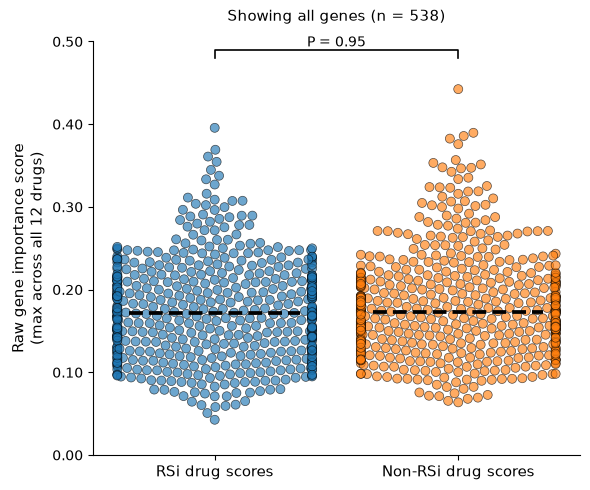

In [17]:
res_gene = swarm_all_items_highlight_important_paired_wilcoxon_formatted(
    important_items=important_genes,
    rsi_importance_df=gene_importance_df,
    non_rsi_importance_df=non_rsi_gene_importance_df,
    system_to_genes=system_to_genes,
    out_svg="all_genes_rsi_vs_nonrsi_swarm.svg",
    analysis="gene",
    score_col="semi_partial_pearson",
    figsize=(6, 5),
    max_genes_per_system=100,
    y_top=0.5,
    y_tick_step= 0.1,
    highlight_legend_anchor=(0.5, 0.9),
    color_important=False,
    title="Showing all genes (n = 538)"
)

#### All systems containing <100 genes (n = 124)

Saved SVG to: all_systems_rsi_vs_nonrsi_swarm.svg


/var/folders/xn/6msch0w517d5fc96lf16x1wc0000gp/T/ipykernel_2856/1835607887.py:390: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(


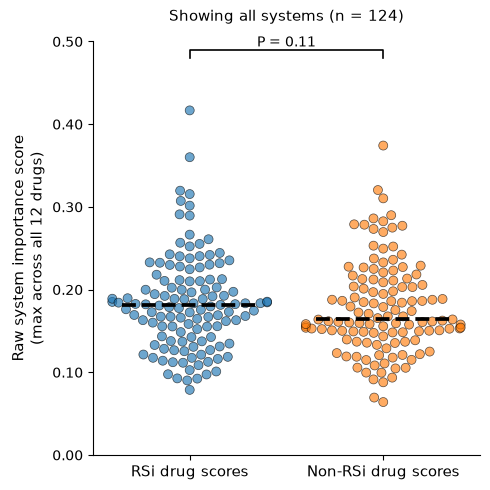

In [18]:
res_sys = swarm_all_items_highlight_important_paired_wilcoxon_formatted(
    important_items=updated_important_systems,
    rsi_importance_df=importance_df_semi,
    non_rsi_importance_df=non_rsi_system_importance_df,
    system_to_genes=system_to_genes,
    out_svg="all_systems_rsi_vs_nonrsi_swarm.svg",
    analysis="system",
    score_col="semi_partial_pearson",
    figsize=(5, 5),
    max_genes_per_system=100,
    y_top=0.50,
    y_tick_step= 0.1,
    highlight_legend_anchor=(0.5, 0.9),
    color_important=False,
    title="Showing all systems (n = 124)",
)

## vi. RSi Drug-Specific and Shared Mechanisms (Fig. 4d)

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_pairwise_system_importance_scatter(
    important_systems,
    drug1,
    drug2,
    importance_df_semi,
    score_col="semi_partial_pearson",
    pval_col="p_bonferroni_pearson",
    drug_col="drug",
    system_col="system",
    importance_threshold=1e-4,
    out_svg="pairwise_system_importance_scatter.svg",
    figsize=(6.5, 6.5),
    point_size=60,
    point_alpha=0.75,
    color_drug1_only="#d62728",   # red
    color_drug2_only="#1f77b4",   # blue
    color_both="#7b3fb3",         # purple
    color_neither="#bdbdbd",      # gray
    point_edgecolor="white",
    point_linewidth=0.9,
    x_label=None,
    y_label=None,
    title=None,
    show=True
):
    """
    Plot absolute system importance scores for drug1 vs drug2 using values from `score_col`.

    Point coloring is determined by significance in `pval_col`:
      - red    : important for drug1 only
      - blue   : important for drug2 only
      - purple : important for both drugs
      - gray   : important for neither drug

    Importance is defined as p <= importance_threshold.
    """

    # -----------------------------
    # Validate inputs
    # -----------------------------
    if not isinstance(importance_df_semi, pd.DataFrame):
        raise ValueError("importance_df_semi must be a pandas DataFrame.")

    required_cols = {drug_col, system_col, score_col, pval_col}
    missing = required_cols - set(importance_df_semi.columns)
    if missing:
        raise ValueError(f"importance_df_semi is missing required columns: {sorted(missing)}")

    if not isinstance(important_systems, (list, tuple, set, pd.Series, np.ndarray)):
        raise ValueError("important_systems must be a list-like object.")

    systems = list(dict.fromkeys([str(x).strip() for x in important_systems if pd.notna(x)]))
    if len(systems) == 0:
        raise ValueError("No valid systems found in important_systems.")

    # -----------------------------
    # Subset and clean
    # -----------------------------
    df = importance_df_semi.copy()

    df[drug_col] = df[drug_col].astype(str).str.strip()
    df[system_col] = df[system_col].astype(str).str.strip()
    df[score_col] = pd.to_numeric(df[score_col], errors="coerce")
    df[pval_col] = pd.to_numeric(df[pval_col], errors="coerce")

    df = df[df[system_col].isin(systems)]
    df = df[df[drug_col].isin([drug1, drug2])]

    if df.empty:
        raise ValueError("No rows remain after filtering for the provided systems and drugs.")

    # -----------------------------
    # Build per-drug tables
    # -----------------------------
    d1 = (
        df[df[drug_col] == drug1][[system_col, score_col, pval_col]]
        .drop_duplicates(subset=[system_col], keep="first")
        .rename(columns={
            score_col: f"{drug1}_score",
            pval_col: f"{drug1}_pval"
        })
        .copy()
    )

    d2 = (
        df[df[drug_col] == drug2][[system_col, score_col, pval_col]]
        .drop_duplicates(subset=[system_col], keep="first")
        .rename(columns={
            score_col: f"{drug2}_score",
            pval_col: f"{drug2}_pval"
        })
        .copy()
    )

    merged = pd.merge(d1, d2, on=system_col, how="outer")

    merged[f"{drug1}_abs"] = merged[f"{drug1}_score"].abs()
    merged[f"{drug2}_abs"] = merged[f"{drug2}_score"].abs()

    # Fill missing scores with 0 so systems present for one drug but not the other still appear
    merged[f"{drug1}_abs"] = merged[f"{drug1}_abs"].fillna(0.0)
    merged[f"{drug2}_abs"] = merged[f"{drug2}_abs"].fillna(0.0)

    # Importance flags: important means p <= threshold
    merged[f"{drug1}_important"] = merged[f"{drug1}_pval"].le(importance_threshold).fillna(False)
    merged[f"{drug2}_important"] = merged[f"{drug2}_pval"].le(importance_threshold).fillna(False)

    # Keep only requested systems in original order where possible
    merged["__order"] = pd.Categorical(merged[system_col], categories=systems, ordered=True)
    merged = merged.sort_values("__order").drop(columns="__order").reset_index(drop=True)

    if merged.empty:
        raise ValueError("No merged system-level scores were available for plotting.")

    # -----------------------------
    # Assign colors by importance pattern
    # -----------------------------
    def assign_color(row):
        d1_imp = bool(row[f"{drug1}_important"])
        d2_imp = bool(row[f"{drug2}_important"])

        if d1_imp and d2_imp:
            return color_both
        elif d1_imp and not d2_imp:
            return color_drug1_only
        elif (not d1_imp) and d2_imp:
            return color_drug2_only
        else:
            return color_neither

    merged["point_color"] = merged.apply(assign_color, axis=1)

    # -----------------------------
    # Top 10 systems by absolute score for each drug
    # -----------------------------
    top10_drug1 = (
        merged[[system_col, f"{drug1}_abs", f"{drug1}_pval", f"{drug1}_important"]]
        .sort_values(f"{drug1}_abs", ascending=False)
        .head(10)
        .reset_index(drop=True)
    )

    top10_drug2 = (
        merged[[system_col, f"{drug2}_abs", f"{drug2}_pval", f"{drug2}_important"]]
        .sort_values(f"{drug2}_abs", ascending=False)
        .head(10)
        .reset_index(drop=True)
    )

    top10_drug1_systems = top10_drug1[system_col].tolist()
    top10_drug2_systems = top10_drug2[system_col].tolist()
    shared_top10_systems = [s for s in top10_drug1_systems if s in set(top10_drug2_systems)]

    # -----------------------------
    # Plot
    # -----------------------------
    plot_df = merged[
        np.isfinite(merged[f"{drug1}_abs"].to_numpy(dtype=float)) &
        np.isfinite(merged[f"{drug2}_abs"].to_numpy(dtype=float))
    ].copy()

    if plot_df.empty:
        raise ValueError("No finite values available for plotting.")

    x = plot_df[f"{drug1}_abs"].to_numpy(dtype=float)
    y = plot_df[f"{drug2}_abs"].to_numpy(dtype=float)
    c = plot_df["point_color"].tolist()

    fig, ax = plt.subplots(figsize=figsize)

    ax.scatter(
        x,
        y,
        s=point_size,
        alpha=point_alpha,
        c=c,
        edgecolor=point_edgecolor,
        linewidth=point_linewidth
    )

    # fixed tick range to 0.30, but leave a little extra axis line beyond it
    tick_max = 0.30
    axis_buffer = 0.025
    axis_max = tick_max + axis_buffer

    # equality line (y = x)
    ax.plot(
        [0, axis_max],
        [0, axis_max],
        linestyle="--",
        linewidth=1.2,
        color="black"
    )

    ax.set_xlim(0, axis_max)
    ax.set_ylim(0, axis_max)

    ticks = np.arange(0, tick_max + 0.001, 0.05)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)

    ax.set_xlabel(
        x_label if x_label is not None else f"|{drug1}| system importance",
        fontsize=11
    )
    ax.set_ylabel(
        y_label if y_label is not None else f"|{drug2}| system importance",
        fontsize=11
    )

    if title is not None:
        ax.set_title(title, fontsize=12)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.rcParams["svg.fonttype"] = "none"
    fig.savefig(out_svg, format="svg", bbox_inches="tight")

    if show:
        plt.show()

    # -----------------------------
    # Reporting
    # -----------------------------
    print(f"Saved SVG to: {out_svg}")

    print(f"\nTop 10 systems for {drug1} by absolute {score_col}:")
    for i, (_, row) in enumerate(top10_drug1.iterrows(), start=1):
        imp_flag = "important" if row[f"{drug1}_important"] else "not important"
        print(
            f"{i:>2}. {row[system_col]}: "
            f"{row[f'{drug1}_abs']:.6f} "
            f"(p={row[f'{drug1}_pval']:.3e}, {imp_flag})"
        )

    print(f"\nTop 10 systems for {drug2} by absolute {score_col}:")
    for i, (_, row) in enumerate(top10_drug2.iterrows(), start=1):
        imp_flag = "important" if row[f"{drug2}_important"] else "not important"
        print(
            f"{i:>2}. {row[system_col]}: "
            f"{row[f'{drug2}_abs']:.6f} "
            f"(p={row[f'{drug2}_pval']:.3e}, {imp_flag})"
        )

    print(f"\nShared systems in both top 10 lists ({len(shared_top10_systems)}):")
    if len(shared_top10_systems) == 0:
        print("None")
    else:
        for i, s in enumerate(shared_top10_systems, start=1):
            print(f"{i:>2}. {s}")

    # category counts
    n_drug1_only = int(((merged[f"{drug1}_important"]) & (~merged[f"{drug2}_important"])).sum())
    n_drug2_only = int(((~merged[f"{drug1}_important"]) & (merged[f"{drug2}_important"])).sum())
    n_both = int(((merged[f"{drug1}_important"]) & (merged[f"{drug2}_important"])).sum())
    n_neither = int(((~merged[f"{drug1}_important"]) & (~merged[f"{drug2}_important"])).sum())

    print("\nCounts by importance category:")
    print(f"{drug1} only: {n_drug1_only}")
    print(f"{drug2} only: {n_drug2_only}")
    print(f"Both: {n_both}")
    print(f"Neither: {n_neither}")

    return {
        "merged_scores": merged,
        "top10_drug1": top10_drug1,
        "top10_drug2": top10_drug2,
        "shared_top10_systems": shared_top10_systems,
        "figure": fig,
        "axis": ax
    }

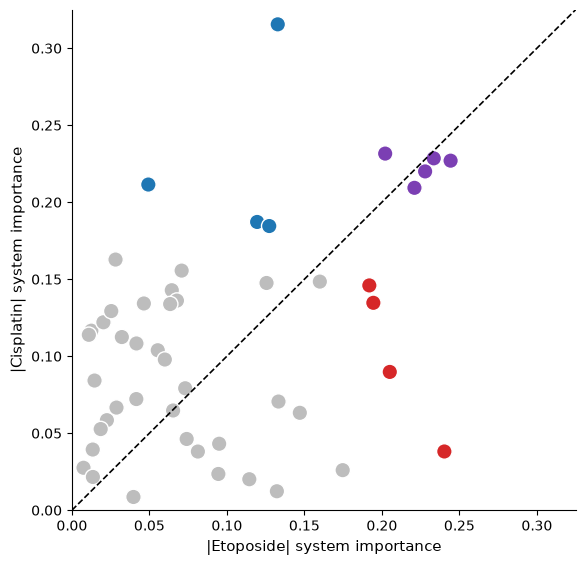

Saved SVG to: etoposide_vs_cisplatin_system_importance.svg

Top 10 systems for Etoposide by absolute semi_partial_pearson:
 1. Extended mismatch repair complex: 0.244332 (p=7.764e-10, important)
 2. Epigenetic modification: 0.240301 (p=1.704e-09, important)
 3. Transcription factor (TF) binding: 0.233461 (p=6.364e-09, important)
 4. Ubiquitin regulation of mitophagy: 0.227899 (p=1.802e-08, important)
 5. Ubiquitin regulation of p53 activity: 0.221002 (p=6.337e-08, important)
 6. p53 regulation of cell cycle: 0.205094 (p=1.001e-06, important)
 7. G1/S phase: 0.202128 (p=1.632e-06, important)
 8. Culin-RIng uniqutin ligase complex: 0.194485 (p=5.653e-06, important)
 9. Cyclin D associated events in G1: 0.191894 (p=8.515e-06, important)
10. Histone deacetylase binding: 0.174718 (p=1.130e-04, not important)

Top 10 systems for Cisplatin by absolute semi_partial_pearson:
 1. G1 to S cell cycle control: 0.315511 (p=0.000e+00, important)
 2. G1/S phase: 0.231581 (p=2.332e-08, important)
 3. T

In [20]:
# Example call
result = plot_pairwise_system_importance_scatter(
    important_systems=updated_important_systems,
    drug1="Etoposide",
    drug2="Cisplatin",
    importance_df_semi=importance_df_semi,
    score_col="semi_partial_pearson",
    pval_col="p_bonferroni_pearson",
    importance_threshold=1e-4,
    out_svg="etoposide_vs_cisplatin_system_importance.svg",
    figsize=(6.5, 6.5),
    point_size=125,
    point_alpha=1,
    point_linewidth=1,
    show=True
)

# 2. Validating DRPT Gene and Pathway Determinants of Response with Genome-Wide CRISPR Screens

## Load in the Olivieri Dataset

In [21]:
crispr_df = pd.read_csv("rsi_crispr_screens.csv")
crispr_df.head()

,Gene,Cisplatin-1,CPT-1,Etoposide,HU-chronic,IR,Doxorubicin,H2O2,MMS,Pyridostatin,...,Gemcitabine,illudinS,MLN4924,MNNG,KBrO3,CD437,CPT-2,BPDE,HU-acute,PladB
0,A1BG,-2.20,0.96,-0.49,-1.52,0.03,-0.15,1.55,-0.07,-0.81,...,0.70,-0.28,0.98,-0.44,1.32,0.85,0.33,-0.62,0.44,-0.12
1,A1CF,1.70,1.73,0.92,1.70,1.96,1.01,0.07,-0.34,0.66,...,-0.36,1.02,0.45,0.63,-0.05,1.07,-0.31,1.01,0.03,-0.51
2,A2M,-0.36,-1.87,-0.97,0.00,0.84,-0.42,0.86,0.07,-0.33,...,-1.01,0.52,-0.40,-0.84,-0.84,1.10,-1.06,-0.51,-0.86,-0.25
3,A2ML1,0.85,-1.51,-0.81,0.88,-0.50,-0.64,-1.18,-0.94,-0.80,...,0.79,0.30,-0.02,-0.63,0.09,0.62,0.30,-1.42,-2.15,-0.33
4,A3GALT2,0.98,1.22,1.75,0.67,-0.50,1.26,1.63,1.65,-0.49,...,0.77,0.92,0.76,0.22,0.83,0.35,-0.20,1.97,1.87,1.73


## ii. Validation of important systems

### a. ORA Analysis for Systems Enriched with CRISPR Drug Sensitivity

In [22]:
import numpy as np
import pandas as pd

from typing import Dict, Iterable, Any, List, Optional
from scipy.stats import hypergeom


# ============================================================
# Helpers
# ============================================================

def _normalize_gene_list(x) -> List[str]:
    """
    Robustly coerce a system's gene container to a clean unique list[str].
    Matches your original ORA behavior.
    """
    if x is None:
        return []

    if isinstance(x, (list, tuple, set, np.ndarray, pd.Series)):
        genes = [
            str(g).strip()
            for g in x
            if pd.notna(g) and str(g).strip()
        ]
    else:
        s = str(x).strip()
        if not s:
            return []

        genes = [g.strip() for g in s.split(",")] if "," in s else [s]
        genes = [g for g in genes if g]

    # Preserve order while removing duplicates
    return list(dict.fromkeys(genes))


def _prepare_systems(
    system_to_genes: Dict[str, Iterable[Any]],
    max_system_genes: int = 100,
) -> Dict[str, List[str]]:
    """
    Clean system_to_genes and retain only systems with <= max_system_genes genes.
    Matches your original ORA behavior.
    """
    cleaned = {}

    for sys_name, genes in system_to_genes.items():
        if pd.isna(sys_name):
            continue

        s = str(sys_name).strip()
        if not s:
            continue

        glist = _normalize_gene_list(genes)

        if len(glist) <= int(max_system_genes):
            cleaned[s] = glist

    return cleaned


def _bh_fdr(pvals: np.ndarray) -> np.ndarray:
    """
    Benjamini-Hochberg FDR correction.
    Matches your original ORA behavior.
    """
    pvals = np.asarray(pvals, dtype=float)
    q = np.full_like(pvals, np.nan, dtype=float)

    mask = np.isfinite(pvals)
    if mask.sum() == 0:
        return q

    p = pvals[mask]
    m = len(p)

    order = np.argsort(p)
    p_sorted = p[order]

    q_sorted = p_sorted * m / np.arange(1, m + 1)
    q_sorted = np.minimum.accumulate(q_sorted[::-1])[::-1]
    q_sorted = np.clip(q_sorted, 0, 1)

    q_unsorted = np.empty_like(p_sorted)
    q_unsorted[order] = q_sorted

    q[mask] = q_unsorted

    return q


def _resolve_top_k(
    n_ranked: int,
    top_k: Optional[int] = None,
    top_frac: Optional[float] = None,
    min_hits: int = 10,
) -> int:
    """
    Resolve ORA hit-list size.
    Matches your original ORA behavior.

    Preference:
      1. top_k if provided
      2. top_frac if provided
      3. default to 10%

    Uses floor, not ceiling.
    """
    if n_ranked <= 0:
        return 0

    if top_k is not None:
        k = int(top_k)

    elif top_frac is not None:
        if not (0 < float(top_frac) <= 1):
            raise ValueError("top_frac must be in (0, 1].")

        k = int(np.floor(float(top_frac) * n_ranked))

    else:
        k = int(np.floor(0.10 * n_ranked))

    k = max(int(min_hits), k)
    k = min(k, n_ranked)

    return int(k)


# ============================================================
# Single-drug ORA for ALL systems
# ============================================================

def _ora_single_drug_absz_all_systems(
    crispr_df: pd.DataFrame,
    drug: str,
    systems_small: Dict[str, List[str]],
    crispr_gene_col: str = "Gene",
    top_k: Optional[int] = None,
    top_frac: Optional[float] = 0.10,
    min_hits: int = 10,
    min_system_overlap: int = 3,
) -> pd.DataFrame:
    """
    ORA per drug using abs(CRISPR z-score) ranking and a top-hit list.

    This version mirrors your original _ora_single_drug_absz(...) logic,
    except it does NOT skip systems with low overlap.

    Instead:
      - every eligible system is returned
      - systems with N < min_system_overlap receive p_overrepresentation = 1.0
      - systems with N = 0 receive p_overrepresentation = 1.0
      - BH-FDR is computed across ALL eligible systems

    Hypergeometric test:
      X ~ Hypergeom(M, N, K)

    where:
      M = number of ranked genes in the drug-specific universe
      N = number of genes from this system present in the universe
      K = number of top-hit genes
      x = observed system genes among top-hit genes

    p-value:
      P(X >= x) = hypergeom.sf(x - 1, M, N, K)
    """
    if crispr_gene_col not in crispr_df.columns:
        raise KeyError(f"crispr_df missing gene column '{crispr_gene_col}'")

    if drug not in crispr_df.columns:
        raise KeyError(f"crispr_df missing drug column '{drug}'")

    # Universe = genes in eligible systems
    universe_718 = set()
    for glist in systems_small.values():
        universe_718.update(map(str, glist))

    # Build ranked list for this drug, restricted to universe
    d = crispr_df[[crispr_gene_col, drug]].copy()
    d.columns = ["gene", "z"]

    d["gene"] = d["gene"].astype(str).str.strip()
    d["z"] = pd.to_numeric(d["z"], errors="coerce")

    d = d.dropna(subset=["gene", "z"])
    d = d[d["gene"].isin(universe_718)].copy()

    # Deduplicate genes by strongest absolute z-score
    d["abs_z"] = d["z"].abs()
    d = (
        d.sort_values("abs_z", ascending=False)
         .drop_duplicates(subset=["gene"], keep="first")
    )

    if d.empty:
        raise ValueError(
            f"No usable CRISPR rows for drug '{drug}' after filtering to system-gene universe."
        )

    d = d.sort_values("abs_z", ascending=False).reset_index(drop=True)

    ranked_genes = d["gene"].tolist()
    ranked_gene_set = set(ranked_genes)

    M = len(ranked_genes)

    if M < 5:
        raise ValueError(f"Too few ranked genes ({M}) for ORA on drug '{drug}'.")

    K = _resolve_top_k(
        n_ranked=M,
        top_k=top_k,
        top_frac=top_frac,
        min_hits=min_hits,
    )

    hit_genes = set(ranked_genes[:K])

    rows = []

    for system_name, system_genes in systems_small.items():
        sys_set = set(map(str, system_genes))

        overlap_universe = sys_set & ranked_gene_set
        N = len(overlap_universe)

        x = len(overlap_universe & hit_genes)

        # Difference from your old function:
        # Instead of skipping N < min_system_overlap, keep the row with p=1.
        if N < int(min_system_overlap):
            p_over = 1.0
            expected = K * (N / M) if M > 0 else np.nan
            fold_enrichment = np.nan

        else:
            # One-sided enrichment p-value: P(X >= x)
            # X ~ Hypergeom(M, N, K)
            p_over = hypergeom.sf(x - 1, M, N, K) if x > 0 else 1.0

            expected = K * (N / M)
            fold_enrichment = (x / expected) if expected > 0 else np.nan

        rows.append({
            "drug": str(drug),
            "system": str(system_name),
            "universe_size_M": int(M),
            "top_hits_K": int(K),
            "system_size_in_universe_N": int(N),
            "observed_hits_x": int(x),
            "expected_hits": float(expected) if np.isfinite(expected) else np.nan,
            "fold_enrichment": float(fold_enrichment) if np.isfinite(fold_enrichment) else np.nan,
            "p_overrepresentation": float(p_over),
            "tested_for_enrichment": bool(N >= int(min_system_overlap)),
            "hit_genes_in_system": sorted(overlap_universe & hit_genes),
            "all_system_genes_in_universe": sorted(overlap_universe),
        })

    res = pd.DataFrame(rows)

    # BH FDR per drug across ALL eligible systems
    res["fdr_bh"] = _bh_fdr(
        res["p_overrepresentation"].to_numpy(dtype=float)
    )

    # Placeholder; caller overwrites using requested fdr_alpha
    res["is_significant"] = res["fdr_bh"] < 0.10

    res = (
        res.sort_values(
            ["fdr_bh", "p_overrepresentation", "fold_enrichment", "observed_hits_x"],
            ascending=[True, True, False, False],
            na_position="last",
        )
        .reset_index(drop=True)
    )

    return res


# ============================================================
# Main ORA API across multiple drugs for ALL systems
# ============================================================

def find_crispr_enriched_systems_ora_all_systems(
    crispr_df: pd.DataFrame,
    system_to_genes: Dict[str, Iterable[Any]],
    genotoxic_agents: List[str],
    crispr_gene_col: str = "Gene",
    max_system_genes: int = 100,
    # ORA hit-list definition
    top_k: Optional[int] = None,
    top_frac: Optional[float] = 0.10,
    min_hits: int = 10,
    # System testing constraints
    min_system_overlap: int = 3,
    # Significance
    fdr_alpha: float = 0.10,
    verbose: bool = True,
) -> Dict[str, Any]:
    """
    CRISPR ORA returning p/FDR for ALL eligible systems per drug.

    This mirrors find_crispr_enriched_systems_ora(...), except:
      - systems with low overlap are retained
      - low-overlap systems get p=1
      - BH-FDR is computed across all eligible systems per drug

    This is useful for complete system-level FDR waterfalls.
    """
    if not isinstance(crispr_df, pd.DataFrame):
        raise ValueError("crispr_df must be a pandas DataFrame.")

    if not isinstance(system_to_genes, dict):
        raise ValueError("system_to_genes must be a dict mapping system -> iterable of genes.")

    if not isinstance(genotoxic_agents, (list, tuple, pd.Series, np.ndarray)) or len(genotoxic_agents) == 0:
        raise ValueError("genotoxic_agents must be a non-empty list-like.")

    if fdr_alpha <= 0 or fdr_alpha >= 1:
        raise ValueError("fdr_alpha must be between 0 and 1.")

    systems_small = _prepare_systems(
        system_to_genes,
        max_system_genes=max_system_genes,
    )

    if len(systems_small) == 0:
        raise ValueError(f"No systems with <= {max_system_genes} genes found.")

    requested_agents = [str(x) for x in genotoxic_agents]

    missing = [d for d in requested_agents if d not in crispr_df.columns]
    if missing:
        raise KeyError(f"These genotoxic agents are not columns in crispr_df: {missing}")

    results_by_drug: Dict[str, pd.DataFrame] = {}
    all_parts = []

    for drug in requested_agents:
        res_drug = _ora_single_drug_absz_all_systems(
            crispr_df=crispr_df,
            drug=drug,
            systems_small=systems_small,
            crispr_gene_col=crispr_gene_col,
            top_k=top_k,
            top_frac=top_frac,
            min_hits=min_hits,
            min_system_overlap=min_system_overlap,
        )

        if len(res_drug):
            res_drug = res_drug.copy()
            res_drug["is_significant"] = res_drug["fdr_bh"] < float(fdr_alpha)

        results_by_drug[drug] = res_drug
        all_parts.append(res_drug)

        if verbose:
            n_sig = int(res_drug["is_significant"].sum()) if len(res_drug) else 0
            tested_all = int(len(res_drug))
            tested_enrichment = int(res_drug["tested_for_enrichment"].sum()) if len(res_drug) else 0
            K_display = int(res_drug["top_hits_K"].iloc[0]) if len(res_drug) else np.nan
            M_display = int(res_drug["universe_size_M"].iloc[0]) if len(res_drug) else np.nan

            print(
                f"[{drug}] M={M_display}, K={K_display}, "
                f"systems in FDR={tested_all}, "
                f"tested for enrichment={tested_enrichment}, "
                f"significant (FDR<{fdr_alpha})={n_sig}"
            )

    if len(all_parts) == 0:
        all_results_long = pd.DataFrame(columns=[
            "drug", "system", "universe_size_M", "top_hits_K",
            "system_size_in_universe_N", "observed_hits_x",
            "expected_hits", "fold_enrichment", "p_overrepresentation",
            "tested_for_enrichment", "fdr_bh", "is_significant",
            "hit_genes_in_system", "all_system_genes_in_universe"
        ])

        sig_any = []

        summary = pd.DataFrame(columns=[
            "system", "n_significant_drugs", "significant_drugs",
            "min_fdr", "min_p", "max_fold_enrichment", "max_observed_hits"
        ])

    else:
        all_results_long = pd.concat(all_parts, ignore_index=True)

        sig_rows = all_results_long[all_results_long["is_significant"]].copy()
        sig_any = sorted(sig_rows["system"].astype(str).unique().tolist())

        if len(sig_rows):
            summary = (
                sig_rows.groupby("system", as_index=False)
                .agg(
                    n_significant_drugs=("drug", "nunique"),
                    significant_drugs=("drug", lambda s: sorted(map(str, s.unique()))),
                    min_fdr=("fdr_bh", "min"),
                    min_p=("p_overrepresentation", "min"),
                    max_fold_enrichment=("fold_enrichment", "max"),
                    max_observed_hits=("observed_hits_x", "max"),
                )
                .sort_values(
                    ["n_significant_drugs", "min_fdr", "max_fold_enrichment", "max_observed_hits"],
                    ascending=[False, True, False, False]
                )
                .reset_index(drop=True)
            )
        else:
            summary = pd.DataFrame(columns=[
                "system", "n_significant_drugs", "significant_drugs",
                "min_fdr", "min_p", "max_fold_enrichment", "max_observed_hits"
            ])

    return {
        "results_by_drug": results_by_drug,
        "all_results_long": all_results_long,
        "significant_systems_any_drug": sig_any,
        "significant_summary": summary,
        "eligible_systems": systems_small,
        "params": {
            "analysis_type": "ORA (hypergeometric overrepresentation)",
            "ranking_metric": "abs(CRISPR z-score)",
            "hits_definition": {
                "top_k": top_k,
                "top_frac": top_frac,
                "min_hits": int(min_hits),
            },
            "fdr_scope": "per drug across ALL eligible systems",
            "fdr_alpha": float(fdr_alpha),
            "max_system_genes": int(max_system_genes),
            "min_system_overlap": int(min_system_overlap),
            "crispr_gene_col": str(crispr_gene_col),
            "low_overlap_behavior": "retained with p_overrepresentation=1.0",
        }
    }


# ============================================================
# Sweep ORA over top_frac cutoffs for ALL systems
# ============================================================

def sweep_ora_top_frac_and_union_all_systems(
    crispr_df: pd.DataFrame,
    system_to_genes: Dict[str, Iterable[Any]],
    genotoxic_agents: List[str],
    top_fracs: Iterable[float] = (0.05, 0.10, 0.15, 0.20),
    crispr_gene_col: str = "Gene",
    max_system_genes: int = 100,
    min_hits: int = 10,
    min_system_overlap: int = 3,
    fdr_alpha: float = 0.10,
    verbose: bool = True,
) -> Dict[str, Any]:
    """
    Sweep ORA over multiple top_frac cutoffs and return:
      - per-cutoff ORA outputs
      - union of significant systems across cutoffs and drugs
      - stability summary

    This version keeps all eligible systems in the FDR table.
    """
    top_fracs = [float(x) for x in top_fracs]

    if len(top_fracs) == 0:
        raise ValueError("top_fracs must be non-empty.")

    for tf in top_fracs:
        if not (0 < tf <= 1):
            raise ValueError(f"Invalid top_frac={tf}. Must be in (0,1].")

    sweep_results: Dict[float, Dict[str, Any]] = {}
    all_sig_union = set()
    long_sig_rows = []
    per_frac_summary_rows = []

    for tf in top_fracs:
        if verbose:
            print(f"\n=== Running ORA sweep across ALL systems at top_frac = {tf:.2f} ===")

        ora_out = find_crispr_enriched_systems_ora_all_systems(
            crispr_df=crispr_df,
            system_to_genes=system_to_genes,
            genotoxic_agents=genotoxic_agents,
            crispr_gene_col=crispr_gene_col,
            max_system_genes=max_system_genes,
            top_k=None,
            top_frac=tf,
            min_hits=min_hits,
            min_system_overlap=min_system_overlap,
            fdr_alpha=fdr_alpha,
            verbose=verbose,
        )

        sweep_results[tf] = ora_out

        sig_systems_tf = set(
            map(str, ora_out.get("significant_systems_any_drug", []))
        )

        all_sig_union.update(sig_systems_tf)

        all_long = ora_out.get("all_results_long", pd.DataFrame()).copy()

        if len(all_long):
            all_long["top_frac"] = tf

            sig_long = all_long[all_long["is_significant"]].copy()
            if len(sig_long):
                long_sig_rows.append(sig_long)

            per_frac_summary_rows.append({
                "top_frac": tf,
                "n_significant_systems_any_drug": len(sig_systems_tf),
                "n_significant_system_drug_hits": int(all_long["is_significant"].sum()),
                "n_tested_system_drug_rows": int(len(all_long)),
                "n_tested_drugs": int(all_long["drug"].nunique()),
                "n_tested_systems_union": int(all_long["system"].nunique()),
                "n_system_drug_rows_tested_for_enrichment": int(all_long["tested_for_enrichment"].sum()),
            })

        else:
            per_frac_summary_rows.append({
                "top_frac": tf,
                "n_significant_systems_any_drug": 0,
                "n_significant_system_drug_hits": 0,
                "n_tested_system_drug_rows": 0,
                "n_tested_drugs": 0,
                "n_tested_systems_union": 0,
                "n_system_drug_rows_tested_for_enrichment": 0,
            })

    union_systems_sorted = sorted(all_sig_union)

    if len(long_sig_rows):
        sig_all = pd.concat(long_sig_rows, ignore_index=True)

        sig_all = sig_all.drop_duplicates(
            subset=["top_frac", "drug", "system"]
        )

        stability_summary = (
            sig_all.groupby("system", as_index=False)
            .agg(
                n_cutoffs_significant=("top_frac", "nunique"),
                cutoffs_significant=("top_frac", lambda s: sorted({float(x) for x in s})),
                n_drugs_significant=("drug", "nunique"),
                drugs_significant=("drug", lambda s: sorted(map(str, pd.unique(s)))),
                total_sig_system_drug_cutoff_hits=("system", "size"),
                best_fdr=("fdr_bh", "min"),
                best_p=("p_overrepresentation", "min"),
                max_fold_enrichment=("fold_enrichment", "max"),
                max_observed_hits=("observed_hits_x", "max"),
            )
            .sort_values(
                ["n_cutoffs_significant", "n_drugs_significant", "best_fdr", "max_fold_enrichment"],
                ascending=[False, False, True, False]
            )
            .reset_index(drop=True)
        )

        cutoff_drugcount_matrix = (
            sig_all.groupby(["system", "top_frac"])["drug"]
            .nunique()
            .unstack(fill_value=0)
            .reindex(columns=sorted(top_fracs), fill_value=0)
            .sort_index()
        )

        cutoff_presence_matrix = (cutoff_drugcount_matrix > 0).astype(int)

    else:
        sig_all = pd.DataFrame(columns=[
            "top_frac", "drug", "system", "fdr_bh",
            "p_overrepresentation", "fold_enrichment",
            "observed_hits_x"
        ])

        stability_summary = pd.DataFrame(columns=[
            "system", "n_cutoffs_significant", "cutoffs_significant",
            "n_drugs_significant", "drugs_significant",
            "total_sig_system_drug_cutoff_hits", "best_fdr",
            "best_p", "max_fold_enrichment", "max_observed_hits"
        ])

        cutoff_drugcount_matrix = pd.DataFrame()
        cutoff_presence_matrix = pd.DataFrame()

    per_frac_summary = (
        pd.DataFrame(per_frac_summary_rows)
        .sort_values("top_frac")
        .reset_index(drop=True)
    )

    if verbose:
        print("\n=== Sweep complete ===")
        print(
            f"Union of significant systems across cutoffs {top_fracs}: "
            f"{len(union_systems_sorted)} systems"
        )

        if len(union_systems_sorted):
            print(union_systems_sorted)

    return {
        "top_fracs_tested": top_fracs,
        "ora_outputs_by_top_frac": sweep_results,
        "union_significant_systems": union_systems_sorted,
        "n_union_significant_systems": len(union_systems_sorted),
        "per_cutoff_summary": per_frac_summary,
        "significant_rows_long": sig_all,
        "stability_summary": stability_summary,
        "cutoff_drugcount_matrix": cutoff_drugcount_matrix,
        "cutoff_presence_matrix": cutoff_presence_matrix,
        "params": {
            "max_system_genes": int(max_system_genes),
            "min_hits": int(min_hits),
            "min_system_overlap": int(min_system_overlap),
            "fdr_alpha": float(fdr_alpha),
            "crispr_gene_col": str(crispr_gene_col),
            "low_overlap_behavior": "retained with p_overrepresentation=1.0",
        }
    }

In [23]:
genotoxic_agents_to_test = list(set(list(crispr_df.columns)).difference({"Gene"}))

sweep_out_all_systems = sweep_ora_top_frac_and_union_all_systems(
    crispr_df=crispr_df,
    system_to_genes=system_to_genes,
    genotoxic_agents=genotoxic_agents_to_test,
    top_fracs=[
        0.05, 0.10, 0.15, 0.20, 0.25,
        0.30, 0.35, 0.40, 0.45, 0.50,
        0.55, 0.60, 0.65, 0.70, 0.75,
        0.80, 0.85, 0.90
    ],
    crispr_gene_col="Gene",
    max_system_genes=100,
    min_hits=3,
    min_system_overlap=1,
    fdr_alpha=0.10,
    verbose=False,
)

crispr_systems_all = sweep_out_all_systems["union_significant_systems"]
print("CRISPR significant systems:", crispr_systems_all)

CRISPR significant systems: ['BAF (SWI/SNF) complex', 'Beta-catenin', 'CDK holoenzyme complex I', 'Checkpoint-regulated DNA repair', 'Chromatin binding', 'Cohesin', 'Culin-RIng uniqutin ligase complex', 'Epigenetic modification', 'Extended cohesin complex', 'Extended mismatch repair complex', 'Fas', 'Foxo signaling', 'G1 to S cell cycle control', 'G1/S phase', 'H3 acetylation and H3K4 methylation crosstalk', 'Homologous recombination', 'Homologous recombination (HR) and Fanconi Anemia repair', 'Integrator-PP2A complex', 'Mismatch and excision repair', 'MutL alpha/beta complex', 'MutS homologs', 'Nucleolus', 'Polybromo- and BAF containing complex', 'Protein Transport', 'RNA metabolism', 'RNA processing 1', 'RNA processing 2', 'RPA complex associated proteins', 'Regulation of TP53 Activity', 'Resolution of D-loop structures', 'Ribosome biogenesis', 'Transcription elongation', 'Ubiquitin regulation of mitophagy', 'Ubiquitin regulation of p53 activity', 'Ubiquitin/Proteasome System']


### b. Waterfall plot of CRISPR enrichment FDR for each NeST system (Fig. 5b)

,waterfall_rank,system,best_fdr,best_drug,best_top_frac,best_fold_enrichment
0,1,Homologous recombination (HR) and Fanconi Anem...,1.140467e-12,Cisplatin-2,0.10,6.840000
1,2,Extended mismatch repair complex,3.910409e-06,MNNG,0.05,14.224000
2,3,Resolution of D-loop structures,3.777862e-05,Cisplatin-2,0.05,13.440000
3,4,RPA complex associated proteins,4.353969e-05,Cisplatin-3,0.10,10.120000
4,5,Mismatch and excision repair,1.072925e-04,MNNG,0.25,2.580645
5,6,Homologous recombination,2.506369e-04,Cisplatin-2,0.05,10.080000
6,7,MutS homologs,9.215850e-04,MNNG,0.05,16.256000
7,8,Ubiquitin regulation of mitophagy,1.301311e-03,Trabectedin,0.20,5.019802
8,9,Ribosome biogenesis,1.304843e-03,Calicheamicin,0.05,9.360000
9,10,Chromatin binding,2.691387e-03,CD437,0.40,1.519353


Saved SVG to: crispr_fdr_waterfall.svg


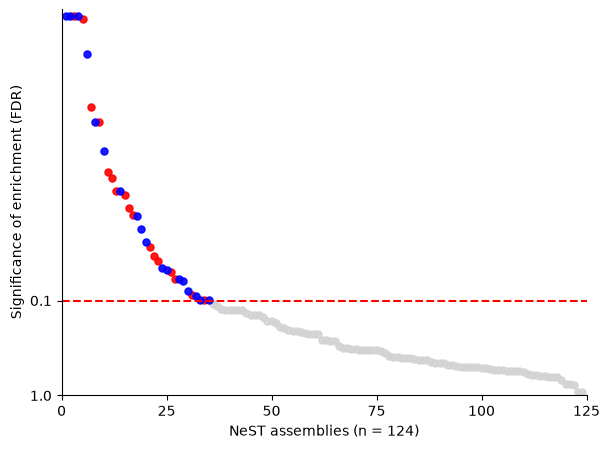

(<Figure size 620x460 with 1 Axes>,
 <Axes: xlabel='NeST assemblies (n = 124)', ylabel='Significance of enrichment (FDR)'>)

In [24]:
from typing import Dict, Any, Optional
from typing import Iterable, Optional

def summarize_best_fdr_across_sweep_and_drugs(
    sweep_out: Dict[str, Any],
    fdr_alpha: float = 0.10,
) -> Dict[str, Any]:
    """
    From sweep_out (produced by sweep_ora_top_frac_and_union_all_systems),
    compute per-system "best" (minimum) FDR across all (top_frac x drug) tests.

    Returns:
      - best_fdr_table: one row per system with best_fdr, best_p, best_drug, best_top_frac, etc.
      - long_all: concatenated long table across all sweeps/drugs/systems
    """
    by_tf = sweep_out.get("ora_outputs_by_top_frac", {})
    if not by_tf:
        raise ValueError("sweep_out does not contain 'ora_outputs_by_top_frac'. Did you run the sweep?")

    long_parts = []
    for tf, ora_out in by_tf.items():
        all_long = ora_out.get("all_results_long", None)
        if all_long is None or len(all_long) == 0:
            continue
        tmp = all_long.copy()
        tmp["top_frac"] = float(tf)
        long_parts.append(tmp)

    if len(long_parts) == 0:
        raise ValueError("No long ORA tables found inside sweep_out.")

    long_all = pd.concat(long_parts, ignore_index=True)

    # Ensure numeric
    long_all["fdr_bh"] = pd.to_numeric(long_all["fdr_bh"], errors="coerce")
    long_all["p_overrepresentation"] = pd.to_numeric(long_all["p_overrepresentation"], errors="coerce")

    # Best = minimum FDR per system across all drugs and cutoffs
    best_idx = long_all.groupby("system")["fdr_bh"].idxmin()
    best_rows = long_all.loc[best_idx].copy()

    best_rows = best_rows.rename(columns={
        "fdr_bh": "best_fdr",
        "p_overrepresentation": "best_p",
        "drug": "best_drug",
        "top_frac": "best_top_frac",
        "observed_hits_x": "best_observed_hits_x",
        "system_size_in_universe_N": "best_system_size_in_universe_N",
        "universe_size_M": "best_universe_size_M",
        "top_hits_K": "best_top_hits_K",
        "fold_enrichment": "best_fold_enrichment",
    })

    # Robustness summaries (optional but useful)
    sig_mask = long_all["fdr_bh"] < float(fdr_alpha)
    sig = long_all[sig_mask].copy()

    if len(sig):
        robustness = (
            sig.groupby("system", as_index=False)
            .agg(
                n_significant_hits=("system", "size"),                 # total drug×cutoff significant hits
                n_drugs_significant=("drug", "nunique"),
                drugs_significant=("drug", lambda s: sorted(map(str, pd.unique(s)))),
                n_cutoffs_significant=("top_frac", "nunique"),
                cutoffs_significant=("top_frac", lambda s: sorted({float(x) for x in s})),
            )
        )
        best_table = best_rows.merge(robustness, on="system", how="left")
    else:
        best_table = best_rows.copy()
        best_table["n_significant_hits"] = 0
        best_table["n_drugs_significant"] = 0
        best_table["drugs_significant"] = best_table["system"].map(lambda _: [])
        best_table["n_cutoffs_significant"] = 0
        best_table["cutoffs_significant"] = best_table["system"].map(lambda _: [])

    # Fill NaNs for systems never significant anywhere
    best_table["n_significant_hits"] = best_table["n_significant_hits"].fillna(0).astype(int)
    best_table["n_drugs_significant"] = best_table["n_drugs_significant"].fillna(0).astype(int)
    best_table["n_cutoffs_significant"] = best_table["n_cutoffs_significant"].fillna(0).astype(int)
    best_table["drugs_significant"] = best_table["drugs_significant"].apply(lambda x: x if isinstance(x, list) else [])
    best_table["cutoffs_significant"] = best_table["cutoffs_significant"].apply(lambda x: x if isinstance(x, list) else [])

    # Waterfall ordering by best FDR (ascending = best at top)
    best_table = best_table.sort_values(["best_fdr", "best_p"], ascending=[True, True]).reset_index(drop=True)
    best_table["waterfall_rank"] = np.arange(1, len(best_table) + 1)

    return {
        "best_fdr_table": best_table,
        "long_all": long_all,
        "params": {
            "best_definition": "min FDR across all (drug × top_frac)",
            "fdr_alpha": float(fdr_alpha),
        }
    }

def plot_fdr_waterfall_like_example(
    df: pd.DataFrame,
    fdr_col: str = "fdr_bh",
    rank_col: str = "waterfall_rank",
    system_col: str = "system",
    fdr_alpha: float = 0.10,
    important_systems: Optional[Iterable[str]] = None,
    figsize=(6.2, 4.6),
    point_size=26,
    alpha_points=0.9,
    log_floor: float = 1e-4,      # lower bound for plotting (avoid 0 on log scale)
    top_pad_factor: float = 0.85, # smaller => more headroom above smallest point
    nonsig_color: str = "lightgray",
    sig_color: str = "red",
    important_sig_color: str = "blue",
    sig_line_color: str = "red",
    # optional saving
    out_svg: str | None = None,
    dpi: int = 300,
    show: bool = True,
):
    """
    Waterfall plot styled like the example:
      - log y-scale with ONLY ticks at 0.1 and 1.0 (no minor ticks)
      - inverted y-axis (small FDR at top)
      - red threshold line at fdr_alpha
      - non-significant points light gray
      - enriched points red
      - important + enriched points blue
      - important but not enriched points remain gray
      - x-axis ticks at 0,25,50,75,100,125
      - optional SVG saving via out_svg
    """
    d = df.copy()

    if system_col not in d.columns:
        raise KeyError(f"df missing required system column '{system_col}'")

    # ensure rank exists
    if rank_col not in d.columns:
        d = d.sort_values(fdr_col, ascending=True).reset_index(drop=True)
        d[rank_col] = np.arange(1, len(d) + 1)

    x = d[rank_col].to_numpy(dtype=float)
    y = pd.to_numeric(d[fdr_col], errors="coerce").to_numpy(dtype=float)
    systems = d[system_col].astype(str).str.strip().to_numpy()

    # clamp for log scale safety
    y = np.clip(y, log_floor, 1.0)

    important_systems_set = set() if important_systems is None else {
        str(s).strip() for s in important_systems if pd.notna(s) and str(s).strip()
    }

    is_enriched = np.isfinite(y) & (y < float(fdr_alpha))
    is_important = np.array([s in important_systems_set for s in systems], dtype=bool)

    # categories
    mask_blue = is_enriched & is_important          # important + enriched
    mask_red = is_enriched & ~is_important          # enriched only
    mask_grey = ~is_enriched                        # all non-enriched stay grey

    fig, ax = plt.subplots(figsize=figsize)

    # plot in layers
    ax.scatter(x[mask_grey], y[mask_grey], s=point_size, alpha=alpha_points, c=nonsig_color)
    ax.scatter(x[mask_red], y[mask_red], s=point_size, alpha=alpha_points, c=sig_color)
    ax.scatter(x[mask_blue], y[mask_blue], s=point_size, alpha=alpha_points, c=important_sig_color)

    # threshold line
    ax.axhline(fdr_alpha, linestyle="--", linewidth=1.5, color=sig_line_color)

    # log scaling gives the “non-proportional” look
    ax.set_yscale("log")

    # ONLY label 0.1 and 1.0; remove minor ticks entirely
    ax.set_yticks([0.1, 1.0])
    ax.set_yticklabels(["0.1", "1.0"])
    ax.minorticks_off()
    ax.tick_params(which="minor", left=False, bottom=False)

    # invert so small FDRs are at the top
    ax.invert_yaxis()

    # y-limits: bottom at 1; top near the smallest observed (with padding)
    ymin = float(np.nanmin(y[np.isfinite(y)])) if np.isfinite(y).any() else log_floor
    ymin = max(ymin, log_floor)
    ax.set_ylim(1.0, ymin * top_pad_factor)

    # x-axis ticks: 0..125 in increments of 25
    ax.set_xlim(0, 125)
    ax.set_xticks([0, 25, 50, 75, 100, 125])

    ax.set_xlabel("NeST assemblies (n = 124)")
    ax.set_ylabel("Significance of enrichment (FDR)")

    # clean frame similar to paper plots
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    # save SVG if requested
    if out_svg is not None:
        plt.rcParams["svg.fonttype"] = "none"  # keep text editable
        fig.savefig(out_svg, format="svg", bbox_inches="tight", dpi=dpi)
        print(f"Saved SVG to: {out_svg}")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return fig, ax

best_out = summarize_best_fdr_across_sweep_and_drugs(sweep_out_all_systems, fdr_alpha=0.10)

best_fdr_124 = best_out["best_fdr_table"]  # <- one row per system (should be 124)
display(best_fdr_124[["waterfall_rank","system","best_fdr","best_drug","best_top_frac","best_fold_enrichment"]].head(50))

plot_fdr_waterfall_like_example(
    best_fdr_124,
    fdr_col="best_fdr",
    system_col="system",
    fdr_alpha=0.10,
    important_systems=important_systems,
    out_svg="crispr_fdr_waterfall.svg"
)

### CRISPR Enrichment FDR vs System Importance Score (Fig. 5c)

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import pearsonr, spearmanr
from matplotlib.ticker import MultipleLocator, FormatStrFormatter
from typing import Iterable, Dict, Any, Optional, Literal


def scatter_best_fdr_124_vs_importance(
    best_fdr_124: pd.DataFrame,
    importance_df: pd.DataFrame,
    system_to_genes: Dict[str, Iterable[str]],
    out_svg: str,
    important_systems: Optional[Iterable[str]] = None,
    score_col: str = "semi_partial_pearson",
    system_col: str = "system",
    drug_col: str = "drug",
    aggregate: Literal["mean", "max"] = "mean",
    use_abs: bool = True,
    max_system_genes: int = 100,
    figsize=(6.2, 6.2),
    title: Optional[str] = None,
    make_plot: bool = True,
    color_important: bool = False,
    important_color: str = "#d62728",
    other_color: str = "#bdbdbd",
    point_size: float = 42,
    point_alpha: float = 0.85,
    annotate_corr: bool = True,
    legend_loc: str = "lower right",
    x_axis_top: Optional[float] = None,
    y_axis_top: Optional[float] = None,
    y_bottom_margin: float = 0.05,
    y_tick_interval: float = 0.1,
    fdr_floor: float = 1e-300,
    fdr_transform: Literal["raw", "neglog10"] = "neglog10",
    top_n: int = 20,
    top_by: Literal["importance", "crispr", "combined"] = "importance",
    # Regression line options
    show_best_fit: bool = True,
    show_ci: bool = True,
    ci_level: float = 0.95,
    fit_line_color: str = "black",
    ci_alpha: float = 0.18,
) -> Dict[str, Any]:
    """
    Scatter plot comparing model-derived mean/max system importance against
    either raw best_fdr or -log10(best_fdr).

    x-axis:
        Aggregated system importance across drugs.

    y-axis:
        If fdr_transform="neglog10":
            -log10(best_fdr)
        If fdr_transform="raw":
            best_fdr

    Expected best_fdr_124 columns:
        - system
        - best_fdr

    Notes
    -----
    y_tick_interval controls the y-axis major tick spacing.
    By default, y-axis ticks increase by 0.1.
    """

    # ----------------------------
    # Validate inputs
    # ----------------------------
    if aggregate not in {"mean", "max"}:
        raise ValueError("aggregate must be either 'mean' or 'max'.")

    if top_by not in {"importance", "crispr", "combined"}:
        raise ValueError("top_by must be one of: 'importance', 'crispr', or 'combined'.")

    if fdr_transform not in {"raw", "neglog10"}:
        raise ValueError("fdr_transform must be either 'raw' or 'neglog10'.")

    if not (0 < ci_level < 1):
        raise ValueError("ci_level must be between 0 and 1.")

    if y_bottom_margin < 0:
        raise ValueError("y_bottom_margin must be >= 0.")

    if y_tick_interval <= 0:
        raise ValueError("y_tick_interval must be > 0.")

    required_importance_cols = {system_col, drug_col, score_col}
    missing = required_importance_cols - set(importance_df.columns)
    if missing:
        raise KeyError(f"importance_df missing required column(s): {missing}")

    required_fdr_cols = {"system", "best_fdr"}
    missing_fdr = required_fdr_cols - set(best_fdr_124.columns)
    if missing_fdr:
        raise KeyError(f"best_fdr_124 missing required column(s): {missing_fdr}")

    # ----------------------------
    # Build eligible system universe
    # ----------------------------
    eligible_systems = []

    for system, genes in system_to_genes.items():
        if genes is None:
            continue

        genes_clean = [
            str(g).strip()
            for g in genes
            if pd.notna(g) and str(g).strip()
        ]

        unique_genes = sorted(set(genes_clean))

        if len(unique_genes) < int(max_system_genes):
            eligible_systems.append(str(system))

    eligible_systems = sorted(set(eligible_systems))

    if len(eligible_systems) == 0:
        raise ValueError(
            f"No eligible systems found after filtering to systems with < {max_system_genes} genes."
        )

    # ----------------------------
    # Aggregate importance across drugs
    # ----------------------------
    imp = importance_df[[system_col, drug_col, score_col]].copy()

    imp[system_col] = imp[system_col].astype(str)
    imp[drug_col] = imp[drug_col].astype(str)
    imp["importance_score_raw"] = pd.to_numeric(imp[score_col], errors="coerce")

    imp = imp.dropna(subset=["importance_score_raw"])
    imp = imp[imp[system_col].isin(eligible_systems)].copy()

    if use_abs:
        imp["importance_score"] = imp["importance_score_raw"].abs()
    else:
        imp["importance_score"] = imp["importance_score_raw"]

    if imp.empty:
        raise ValueError("No eligible systems remain in importance_df after filtering.")

    imp_agg = (
        imp.groupby(system_col, as_index=False)["importance_score"]
        .agg(aggregate)
        .rename(columns={
            system_col: "system",
            "importance_score": f"{aggregate}_importance_score",
        })
    )

    importance_score_col = f"{aggregate}_importance_score"

    # ----------------------------
    # Prepare best FDR dataframe
    # ----------------------------
    fdr_df = best_fdr_124[["system", "best_fdr"]].copy()

    fdr_df["system"] = fdr_df["system"].astype(str)
    fdr_df["best_fdr"] = pd.to_numeric(fdr_df["best_fdr"], errors="coerce")

    fdr_df = fdr_df[fdr_df["system"].isin(eligible_systems)].copy()

    # If duplicate systems exist, keep the smallest/best FDR
    fdr_df = (
        fdr_df.dropna(subset=["best_fdr"])
        .groupby("system", as_index=False)
        .agg(best_fdr=("best_fdr", "min"))
    )

    if fdr_df.empty:
        raise ValueError("No eligible systems remain in best_fdr_124 after filtering.")

    # ----------------------------
    # Choose FDR transform
    # ----------------------------
    fdr_df["best_fdr_clipped"] = fdr_df["best_fdr"].clip(lower=float(fdr_floor))

    if fdr_transform == "neglog10":
        y_col = "neg_log10_best_fdr"
        y_label = r"$-\log_{10}$(best CRISPR ORA FDR)"
        fdr_df[y_col] = -np.log10(fdr_df["best_fdr_clipped"])
        crispr_rank_ascending = False
        crispr_sort_ascending = False
        crispr_sort_label = "-log10(best CRISPR ORA FDR)"
    else:
        y_col = "best_fdr"
        y_label = "Best CRISPR ORA FDR"
        crispr_rank_ascending = True
        crispr_sort_ascending = True
        crispr_sort_label = "raw best CRISPR ORA FDR"

    # ----------------------------
    # Merge importance and FDR tables
    # ----------------------------
    merged = pd.merge(
        imp_agg,
        fdr_df,
        on="system",
        how="inner",
    ).dropna(subset=[importance_score_col, y_col])

    if merged.empty:
        raise ValueError(
            "No overlapping eligible systems found between importance_df and best_fdr_124."
        )

    important_set = set(map(str, important_systems)) if important_systems is not None else set()
    merged["is_important"] = merged["system"].isin(important_set)

    # Helpful ranks
    merged["importance_rank"] = merged[importance_score_col].rank(
        ascending=False,
        method="average",
    )

    merged["crispr_rank"] = merged[y_col].rank(
        ascending=crispr_rank_ascending,
        method="average",
    )

    merged["combined_mean_rank"] = merged[
        ["importance_rank", "crispr_rank"]
    ].mean(axis=1)

    # ----------------------------
    # Correlations
    # ----------------------------
    x = merged[importance_score_col].to_numpy(dtype=float)
    y = merged[y_col].to_numpy(dtype=float)

    if len(merged) >= 2:
        pearson_r, pearson_p = pearsonr(x, y)
        spearman_rho, spearman_p = spearmanr(x, y)
    else:
        pearson_r, pearson_p = np.nan, np.nan
        spearman_rho, spearman_p = np.nan, np.nan

    # ----------------------------
    # Plot
    # ----------------------------
    if make_plot:
        fig, ax = plt.subplots(figsize=figsize)

        if color_important:
            bg = merged[~merged["is_important"]]
            imp_systems = merged[merged["is_important"]]

            if len(bg) > 0:
                ax.scatter(
                    bg[importance_score_col],
                    bg[y_col],
                    s=point_size,
                    color=other_color,
                    edgecolor="black",
                    linewidth=0.35,
                    alpha=point_alpha,
                    label=f"Other eligible systems (n = {len(bg)})",
                    zorder=2,
                )

            if len(imp_systems) > 0:
                ax.scatter(
                    imp_systems[importance_score_col],
                    imp_systems[y_col],
                    s=point_size,
                    color=important_color,
                    edgecolor="black",
                    linewidth=0.45,
                    alpha=point_alpha,
                    label=f"Important systems (n = {len(imp_systems)})",
                    zorder=3,
                )

        else:
            ax.scatter(
                merged[importance_score_col],
                merged[y_col],
                s=point_size,
                color=other_color,
                edgecolor="black",
                linewidth=0.35,
                alpha=point_alpha,
                label=f"Eligible systems (n = {len(merged)})",
                zorder=2,
            )

        # ----------------------------
        # Best-fit line with 95% CI
        # ----------------------------
        if show_best_fit and len(merged) >= 3:
            x_fit = np.asarray(x, dtype=float)
            y_fit = np.asarray(y, dtype=float)

            finite_mask = np.isfinite(x_fit) & np.isfinite(y_fit)
            x_fit = x_fit[finite_mask]
            y_fit = y_fit[finite_mask]

            if len(x_fit) >= 3 and np.nanstd(x_fit) > 0:
                slope, intercept = np.polyfit(x_fit, y_fit, deg=1)

                x_line = np.linspace(np.min(x_fit), np.max(x_fit), 200)
                y_line = intercept + slope * x_line

                ax.plot(
                    x_line,
                    y_line,
                    linestyle="--",
                    linewidth=1.6,
                    color=fit_line_color,
                    alpha=0.95,
                    label="Best fit",
                    zorder=4,
                )

                if show_ci:
                    # 95% CI for the mean fitted line.
                    # Uses normal approximation; fine for n around 124.
                    z_value = 1.96 if np.isclose(ci_level, 0.95) else 1.96

                    n = len(x_fit)
                    x_mean = np.mean(x_fit)
                    sxx = np.sum((x_fit - x_mean) ** 2)

                    y_hat = intercept + slope * x_fit
                    residuals = y_fit - y_hat
                    residual_se = np.sqrt(np.sum(residuals ** 2) / (n - 2))

                    mean_pred_se = residual_se * np.sqrt(
                        (1 / n) + ((x_line - x_mean) ** 2 / sxx)
                    )

                    ci = z_value * mean_pred_se

                    ax.fill_between(
                        x_line,
                        y_line - ci,
                        y_line + ci,
                        color=fit_line_color,
                        alpha=ci_alpha,
                        linewidth=0,
                        label="95% CI",
                        zorder=1,
                    )

        # ----------------------------
        # Axis limits
        # ----------------------------
        if x_axis_top is not None:
            x_min, x_max = 0.0, float(x_axis_top)
        else:
            x_min = 0.0 if use_abs else np.nanmin(x)
            x_pad = 0.05 * np.nanmax(x) if np.nanmax(x) > 0 else 0.05
            x_max = np.nanmax(x) + x_pad

        if y_axis_top is not None:
            y_data_max = float(y_axis_top)

            if fdr_transform == "raw":
                y_data_min = np.nanmin(y)
                y_range = y_data_max - y_data_min

                if y_range <= 0:
                    y_range = 1.0

                y_min = y_data_min - y_bottom_margin * y_range
                y_max = y_data_max

            else:
                y_range = y_data_max

                if y_range <= 0:
                    y_range = 1.0

                y_min = -y_bottom_margin * y_range
                y_max = y_data_max

        else:
            if fdr_transform == "raw":
                y_data_min = np.nanmin(y)
                y_data_max = np.nanmax(y)
                y_range = y_data_max - y_data_min

                if y_range <= 0:
                    y_range = 1.0

                y_min = y_data_min - y_bottom_margin * y_range
                y_max = min(1.0, y_data_max + 0.05 * y_range)

            else:
                y_data_max = np.nanmax(y)
                y_pad = 0.05 * y_data_max if y_data_max > 0 else 0.05

                y_max = y_data_max + y_pad

                # Let y-axis start slightly below 0 so points near y=0
                # do not sit directly on the x-axis.
                y_min = -y_bottom_margin * y_max

        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)

        # ----------------------------
        # Force y-axis tick intervals
        # ----------------------------
        ax.yaxis.set_major_locator(MultipleLocator(y_tick_interval))
        ax.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))

        abs_prefix = "absolute " if use_abs else ""

        ax.set_xlabel(
            f"{aggregate.capitalize()} {abs_prefix}system importance\n(across all drugs)",
            fontsize=11,
        )

        ax.set_ylabel(y_label, fontsize=11)

        if title is not None:
            ax.set_title(title, fontsize=11)

        if annotate_corr:
            text = (
                f"Spearman ρ = {spearman_rho:.3f}\n"
                f"P = {spearman_p:.2e}\n"
                f"Eligible systems shown = {len(merged)}"
            )

            ax.text(
                0.03,
                0.97,
                text,
                transform=ax.transAxes,
                ha="left",
                va="top",
                fontsize=10,
                bbox=dict(
                    boxstyle="round,pad=0.25",
                    facecolor="white",
                    alpha=0.85,
                    edgecolor="none",
                ),
            )

        ax.grid(False)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        # Uncomment if you want the legend shown.
        # ax.legend(frameon=False, loc=legend_loc, fontsize=9)

        plt.tight_layout()
        plt.rcParams["svg.fonttype"] = "none"
        fig.savefig(out_svg, format="svg", bbox_inches="tight")
        print(f"Saved SVG to: {out_svg}")

        plt.show()

    # ----------------------------
    # Print top N systems
    # ----------------------------
    if top_by == "importance":
        sort_col = importance_score_col
        ascending = False
        sort_label = f"{aggregate} {'absolute ' if use_abs else ''}importance"

    elif top_by == "crispr":
        sort_col = y_col
        ascending = crispr_sort_ascending
        sort_label = crispr_sort_label

    else:
        sort_col = "combined_mean_rank"
        ascending = True
        sort_label = "combined mean rank of importance and CRISPR enrichment"

    top_table = (
        merged.sort_values(sort_col, ascending=ascending)
        .head(top_n)
        [
            [
                "system",
                importance_score_col,
                "best_fdr",
                y_col,
                "importance_rank",
                "crispr_rank",
                "combined_mean_rank",
                "is_important",
            ]
        ]
        .reset_index(drop=True)
    )

    formatters = {
        importance_score_col: "{:.6f}".format,
        "best_fdr": "{:.3e}".format,
        "importance_rank": "{:.1f}".format,
        "crispr_rank": "{:.1f}".format,
        "combined_mean_rank": "{:.1f}".format,
    }

    if y_col != "best_fdr":
        formatters[y_col] = "{:.6f}".format

    return {
        "aggregate": aggregate,
        "use_abs": use_abs,
        "fdr_transform": fdr_transform,
        "y_col": y_col,
        "max_system_genes": int(max_system_genes),
        "n_eligible_systems_lt_max": len(eligible_systems),
        "n_systems_used_in_plot": int(len(merged)),
        "n_important_systems_shown": int(merged["is_important"].sum()),
        "pearson_r": float(pearson_r) if np.isfinite(pearson_r) else np.nan,
        "pearson_p": float(pearson_p) if np.isfinite(pearson_p) else np.nan,
        "spearman_rho": float(spearman_rho) if np.isfinite(spearman_rho) else np.nan,
        "spearman_p": float(spearman_p) if np.isfinite(spearman_p) else np.nan,
        "top_table": top_table,
        "merged_table": merged.sort_values(
            y_col,
            ascending=crispr_sort_ascending,
        ).reset_index(drop=True),
        "importance_table": imp_agg,
        "fdr_table": fdr_df.sort_values(
            y_col,
            ascending=crispr_sort_ascending,
        ).reset_index(drop=True),
    }

Saved SVG to: crispr_best_fdr_124_raw_vs_mean_system_importance.svg


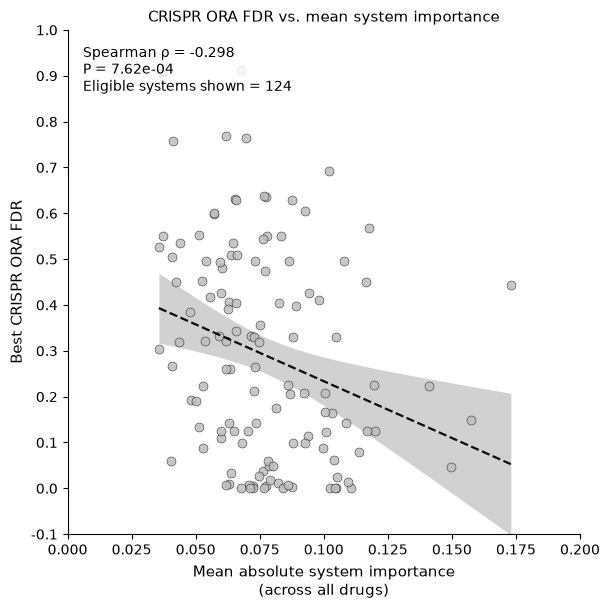

In [26]:
out_crispr_vs_importance_124_raw = scatter_best_fdr_124_vs_importance(
    best_fdr_124=best_fdr_124,
    importance_df=importance_df_semi,
    system_to_genes=system_to_genes,
    important_systems=rsi_important_systems,
    score_col="semi_partial_pearson",
    system_col="system",
    drug_col="drug",
    aggregate="mean",
    use_abs=True,
    fdr_transform="raw",
    max_system_genes=100,
    color_important=False,
    x_axis_top=0.2,
    y_axis_top=1.0,
    y_bottom_margin=0.1,
    show_best_fit=True,
    show_ci=True,
    top_n=50,
    top_by="importance",
    title="CRISPR ORA FDR vs. mean system importance",
    out_svg="crispr_best_fdr_124_raw_vs_mean_system_importance.svg",
)

### c. Percent Enriched Bar Plot with Proportional Z-Test (Fig. 5d)

Number of eligible systems: 124
Saved SVG to: crispr_enrichment_proportion_barplot.svg


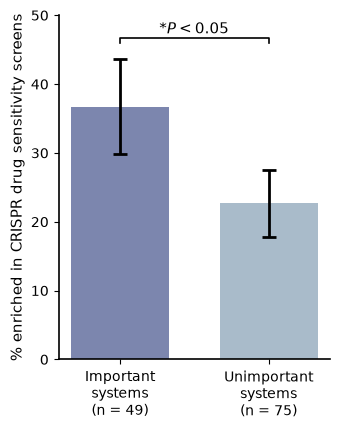

CRISPR z-test: {'x1': 18, 'n1': 49, 'p1': 0.3673469387755102, 'x2': 17, 'n2': 75, 'p2': 0.22666666666666666, 'p_pool': 0.28225806451612906, 'se_pooled': 0.08267791410527223, 'z': 1.7015459767129348, 'p_value': 0.04442025602979449, 'alternative': 'greater'}
CRISPR % important vs non-important: 36.734693877551024 22.666666666666664


In [27]:
import numpy as np
import matplotlib.pyplot as plt

from math import erf, sqrt
from typing import Iterable, Dict, Any, Optional, Tuple


# -----------------------------
# Helpers
# -----------------------------
def _norm_cdf(z: float) -> float:
    """Standard normal CDF using erf."""
    return 0.5 * (1.0 + erf(z / sqrt(2.0)))


def two_proportion_ztest(
    x1: int,
    n1: int,
    x2: int,
    n2: int,
    alternative: str = "two-sided",
) -> Dict[str, float]:
    """
    Two-sample z-test for proportions.

    Parameters
    ----------
    x1, n1 : int
        Successes and total in group 1.

    x2, n2 : int
        Successes and total in group 2.

    alternative : {'two-sided', 'greater', 'less'}
        - two-sided: p1 != p2
        - greater:   p1 > p2
        - less:      p1 < p2
    """
    if n1 <= 0 or n2 <= 0:
        raise ValueError("n1 and n2 must be > 0.")

    if x1 < 0 or x2 < 0 or x1 > n1 or x2 > n2:
        raise ValueError("x1/x2 must satisfy 0 <= x <= n.")

    p1 = x1 / n1
    p2 = x2 / n2
    p_pool = (x1 + x2) / (n1 + n2)

    se_pooled = np.sqrt(p_pool * (1 - p_pool) * (1 / n1 + 1 / n2))

    if se_pooled == 0:
        z = np.nan
        pval = np.nan
    else:
        z = (p1 - p2) / se_pooled

        alt = alternative.lower().strip()

        if alt == "two-sided":
            pval = 2 * (1 - _norm_cdf(abs(z)))
        elif alt == "greater":
            pval = 1 - _norm_cdf(z)
        elif alt == "less":
            pval = _norm_cdf(z)
        else:
            raise ValueError("alternative must be 'two-sided', 'greater', or 'less'.")

    return {
        "x1": int(x1),
        "n1": int(n1),
        "p1": float(p1),
        "x2": int(x2),
        "n2": int(n2),
        "p2": float(p2),
        "p_pool": float(p_pool),
        "se_pooled": float(se_pooled) if np.isfinite(se_pooled) else np.nan,
        "z": float(z) if np.isfinite(z) else np.nan,
        "p_value": float(pval) if np.isfinite(pval) else np.nan,
        "alternative": alternative,
    }


def _proportion_sem(x: int, n: int) -> float:
    """Standard error of a sample proportion for display error bars."""
    if n <= 0:
        return np.nan

    p = x / n
    return float(np.sqrt(p * (1 - p) / n))


def _format_p_for_bracket(p: float) -> str:
    """Paper-like significance annotation text."""
    if not np.isfinite(p):
        return "P = nan"

    if p < 0.001:
        return r"***$P < 0.001$"
    if p < 0.01:
        return r"**$P < 0.01$"
    if p < 0.05:
        return r"*$P < 0.05$"

    if p >= 0.1:
        return f"P = {p:.2f}"
    if p >= 0.01:
        return f"P = {p:.3f}"

    return f"P = {p:.2e}"


def _add_sig_bracket(
    ax,
    x1,
    x2,
    y,
    h,
    text,
    lw: float = 1.2,
    fontsize: float = 11,
):
    ax.plot(
        [x1, x1, x2, x2],
        [y, y + h, y + h, y],
        color="black",
        linewidth=lw,
        clip_on=False,
    )

    ax.text(
        (x1 + x2) / 2,
        y + h,
        text,
        ha="center",
        va="bottom",
        fontsize=fontsize,
        color="black",
        clip_on=False,
    )


# -----------------------------
# Core CRISPR-only analysis + plot function
# -----------------------------
def plot_crispr_enriched_system_proportion_comparison(
    all_systems: Iterable[str],
    updated_important_systems: Iterable[str],
    crispr_systems: Iterable[str],
    out_svg: Optional[str] = "crispr_enrichment_proportion_barplot.svg",
    figsize: Tuple[float, float] = (3.5, 4.4),
    bar_colors: Tuple[str, str] = ("#7C86AE", "#A9BBCA"),
    y_label: str = "% enriched in CRISPR drug sensitivity screens",
    title: Optional[str] = None,
    important_label: str = "Important\nsystems",
    nonimportant_label: str = "Unimportant\nsystems",
    y_top: Optional[float] = 50,
    y_tick_step: float = 10.0,
    alternative: str = "greater",
    bracket_lw: float = 1.2,
    capsize: float = 5,
    show: bool = True,
) -> Dict[str, Any]:
    """
    Compare the percentage of CRISPR-enriched systems between important and
    non-important systems.

    Success = membership in crispr_systems.

    Groups
    ------
    1. updated_important_systems
    2. all_systems - updated_important_systems

    Error bars
    ----------
    SEM of the proportion for each bar.

    Test
    ----
    Two-proportion z-test using pooled SE under H0.
    """

    # -----------------------------
    # Normalize sets
    # -----------------------------
    A_all = {
        str(s).strip()
        for s in all_systems
        if s is not None and str(s).strip()
    }

    A_imp = {
        str(s).strip()
        for s in updated_important_systems
        if s is not None and str(s).strip()
    }

    A_crispr = {
        str(s).strip()
        for s in crispr_systems
        if s is not None and str(s).strip()
    }

    # Restrict important and CRISPR-enriched systems to the analysis universe
    A_imp = A_imp & A_all
    A_crispr = A_crispr & A_all

    A_non = A_all - A_imp

    n1 = len(A_imp)
    n2 = len(A_non)

    if n1 == 0 or n2 == 0:
        raise ValueError("Need both important and non-important system groups to be non-empty.")

    x1 = len(A_imp & A_crispr)
    x2 = len(A_non & A_crispr)

    p1 = x1 / n1
    p2 = x2 / n2

    # -----------------------------
    # Two-proportion z-test
    # -----------------------------
    zres = two_proportion_ztest(
        x1=x1,
        n1=n1,
        x2=x2,
        n2=n2,
        alternative=alternative,
    )

    pval = zres["p_value"]

    # -----------------------------
    # Error bars in percent units
    # -----------------------------
    se1_pct = 100.0 * _proportion_sem(x1, n1)
    se2_pct = 100.0 * _proportion_sem(x2, n2)

    h1 = 100.0 * p1
    h2 = 100.0 * p2

    xlabels = [
        f"{important_label}\n(n = {n1})",
        f"{nonimportant_label}\n(n = {n2})",
    ]

    # -----------------------------
    # Plot
    # -----------------------------
    fig = None
    ax = None

    if show or out_svg is not None:
        fig, ax = plt.subplots(figsize=figsize)

        xs = np.array([0, 1], dtype=float)
        heights = np.array([h1, h2], dtype=float)
        errs = np.array([se1_pct, se2_pct], dtype=float)

        ax.bar(
            xs,
            heights,
            yerr=errs,
            width=0.66,
            color=[bar_colors[0], bar_colors[1]],
            edgecolor="none",
            capsize=capsize,
            error_kw=dict(
                elinewidth=2,
                capthick=2,
                ecolor="black",
            ),
        )

        ax.set_ylabel(y_label, fontsize=11)
        ax.set_xlabel("")
        ax.set_xticks(xs)
        ax.set_xticklabels(xlabels, fontsize=10)
        ax.tick_params(axis="y", labelsize=10)

        ax.grid(False)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_linewidth(1.2)
        ax.spines["bottom"].set_linewidth(1.2)

        # y-axis range and ticks
        if y_top is None:
            ymax_data = float(np.nanmax(heights + errs)) if len(heights) else 10.0
            y_top_use = float(np.ceil((ymax_data * 1.20) / y_tick_step) * y_tick_step)
            y_top_use = max(y_top_use, y_tick_step)
        else:
            y_top_use = float(y_top)

        ax.set_ylim(0, y_top_use)

        ticks = np.arange(0, y_top_use + 1e-12, y_tick_step)
        ax.set_yticks(ticks)
        ax.set_yticklabels([
            f"{int(t)}" if abs(t - round(t)) < 1e-9 else f"{t:g}"
            for t in ticks
        ])

        # Significance bracket
        p_text = _format_p_for_bracket(pval)
        y_range = ax.get_ylim()[1] - ax.get_ylim()[0]

        h_br = 0.015 * y_range
        y_br = max(heights + errs) + 0.1 * y_range
        y_br = min(y_br, ax.get_ylim()[1] - 0.08 * y_range)

        _add_sig_bracket(
            ax,
            0,
            1,
            y_br,
            h_br,
            p_text,
            lw=bracket_lw,
            fontsize=11,
        )

        if title is not None:
            ax.set_title(title, fontsize=11, y=1.03)

        plt.tight_layout()

        if out_svg is not None:
            plt.rcParams["svg.fonttype"] = "none"
            fig.savefig(out_svg, format="svg", bbox_inches="tight")
            print(f"Saved SVG to: {out_svg}")

        if show:
            plt.show()
        else:
            plt.close(fig)

    return {
        "analysis_name": "CRISPR",
        "all_systems_n": len(A_all),
        "important_systems_n": n1,
        "nonimportant_systems_n": n2,
        "crispr_systems_n_within_all": len(A_crispr),

        "important_crispr_count": x1,
        "nonimportant_crispr_count": x2,

        "important_proportion": p1,
        "nonimportant_proportion": p2,
        "important_percent": h1,
        "nonimportant_percent": h2,
        "important_sem_percent": se1_pct,
        "nonimportant_sem_percent": se2_pct,

        "z_test": zres,

        "important_crispr_systems": sorted(A_imp & A_crispr),
        "nonimportant_crispr_systems": sorted(A_non & A_crispr),
        "important_not_crispr_systems": sorted(A_imp - A_crispr),
        "nonimportant_not_crispr_systems": sorted(A_non - A_crispr),

        "figure": fig,
        "ax": ax,
    }


# -----------------------------
# Example usage
# -----------------------------

all_systems = []

for sys in system_to_genes.keys():
    if len(system_to_genes[sys]) <= 100:
        all_systems.append(sys)

print("Number of eligible systems:", len(all_systems))

results = plot_crispr_enriched_system_proportion_comparison(
    all_systems=all_systems,
    updated_important_systems=updated_important_systems,
    crispr_systems=crispr_systems_all,
    out_svg="crispr_enrichment_proportion_barplot.svg",
    figsize=(3.5, 4.4),
    y_label="% enriched in CRISPR drug sensitivity screens",
    title=None,
    important_label="Important\nsystems",
    nonimportant_label="Unimportant\nsystems",
    y_top=50,
    y_tick_step=10.0,
    alternative="greater",
    show=True,
)

print("CRISPR z-test:", results["z_test"])
print(
    "CRISPR % important vs non-important:",
    results["important_percent"],
    results["nonimportant_percent"],
)

### d. CRISPR enriched importance in RSi-model vs non-RSi model (Fig. 5e)

/var/folders/xn/6msch0w517d5fc96lf16x1wc0000gp/T/ipykernel_2856/201213721.py:147: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(


Saved SVG to: rsi_vs_nonrsi_crispr_systems.svg


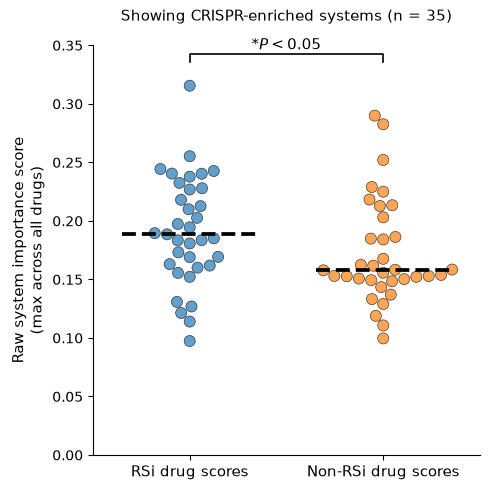

In [28]:
out_sys = swarm_compare_max_abs_importance(important_items=crispr_systems_all,
                                           rsi_importance_df=importance_df_semi,
                                           non_rsi_importance_df=non_rsi_system_importance_df,
                                           title="Showing CRISPR-enriched systems (n = 35)",
                                           analysis="system",
                                           aggregate="max",
                                           test="wilcoxon",
                                           score_col="semi_partial_pearson",
                                           alternative="greater",
                                           y_top = 0.35,
                                           out_svg="rsi_vs_nonrsi_crispr_systems.svg"
                                          )

## ii. Validation of Important Genes (Fig. 5f-h)

### a. Correlation of importance and crispr Z-scores (Fig. 5f)

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr, t
from typing import Dict, Iterable, Any, List, Optional


def correlate_importance_vs_crispr_small_system_genes(
    importance_df: pd.DataFrame,                  # cols: ['drug','gene','semi_partial_pearson', ...]
    crispr_df: pd.DataFrame,                      # cols: ['Gene', '<Drug1>', '<Drug2>', ...]
    genotoxic_agents: List[str],                  # CRISPR columns to aggregate across
    system_to_genes: Dict[str, Iterable[Any]],    # system -> genes
    important_genes: Optional[Iterable[str]] = None,
    max_system_genes: int = 100,
    gene_col_imp: str = "gene",
    drug_col_imp: str = "drug",
    score_col_imp: str = "semi_partial_pearson",
    gene_col_crispr: str = "Gene",
    corr_method: str = "spearman",                # one of {'spearman', 'pearson'}
    importance_agg: str = "mean_abs",              # one of {'max_abs', 'mean_abs'}
    crispr_agg: str = "mean_abs",                 # one of {'max_abs', 'mean_abs'}
    crispr_transform: str = "log_post_agg",       # one of {'none', 'log_post_agg'}
    crispr_log_base: float = 10.0,
    crispr_log_eps: float = 1e-6,
    make_plot: bool = True,
    figsize=(5.4, 4.4),
    point_size: int = 18,
    alpha: float = 0.65,
    line_width: float = 2.0,
    ci_alpha: float = 0.20,
    all_point_color: str = "lightgray",
    important_point_color: str = "lightgray",
    fit_line_color: str = "black",
    fit_line_style: str = "--",
    point_edgecolor: str = "white",
    point_edgewidth: float = 0.4,
    # NEW: axis controls
    x_min: Optional[float] = None,
    x_max: Optional[float] = 0.16,
    y_min: float = -0.50,
    y_max: float = 0.75,
    y_tick_step: float = 0.25,
    # save controls
    out_svg: Optional[str] = None,
    dpi: int = 300,
    show: bool = True,
) -> Dict[str, Any]:
    """
    Across ALL drugs / ALL genes:
      1) Aggregate importance_df to one value per gene using |semi_partial_pearson| across all drugs
         by either max or mean.
      2) For CRISPR:
            - take abs(z) across selected genotoxic agents
            - aggregate across agents by either max or mean
            - optionally log-transform the aggregated value
      3) Restrict to genes in >=1 system with size <= max_system_genes.
      4) Correlate the two per-gene aggregated quantities (Spearman or Pearson).
      5) Plot scatter + OLS best-fit line + 95% CI band.

    Axis controls:
      - x_max lets you cap the x-axis (default 0.16)
      - y-axis defaults to [-0.50, 0.75] with ticks every 0.25
    """

    # --- sanity checks ---
    needed_imp = {gene_col_imp, drug_col_imp, score_col_imp}
    missing_imp = needed_imp - set(importance_df.columns)
    if missing_imp:
        raise KeyError(f"importance_df missing required columns: {missing_imp}")

    if gene_col_crispr not in crispr_df.columns:
        raise KeyError(f"crispr_df missing gene column '{gene_col_crispr}'")

    if not isinstance(genotoxic_agents, (list, tuple, np.ndarray, pd.Series)) or len(genotoxic_agents) == 0:
        raise ValueError("genotoxic_agents must be a non-empty list-like of CRISPR column names.")

    genotoxic_agents = [str(c) for c in genotoxic_agents]
    missing_agents = [c for c in genotoxic_agents if c not in crispr_df.columns]
    if missing_agents:
        raise KeyError(f"crispr_df missing requested genotoxic agent column(s): {missing_agents}")

    corr_method = str(corr_method).strip().lower()
    if corr_method not in {"spearman", "pearson"}:
        raise ValueError("corr_method must be one of {'spearman', 'pearson'}")

    importance_agg = str(importance_agg).strip().lower()
    if importance_agg not in {"max_abs", "mean_abs"}:
        raise ValueError("importance_agg must be one of {'max_abs', 'mean_abs'}")

    crispr_agg = str(crispr_agg).strip().lower()
    if crispr_agg not in {"max_abs", "mean_abs"}:
        raise ValueError("crispr_agg must be one of {'max_abs', 'mean_abs'}")

    crispr_transform = str(crispr_transform).strip().lower()
    if crispr_transform not in {"none", "log_post_agg"}:
        raise ValueError("crispr_transform must be one of {'none', 'log_post_agg'}")

    if crispr_log_base <= 0 or crispr_log_base == 1:
        raise ValueError("crispr_log_base must be positive and not equal to 1.")
    if crispr_log_eps <= 0:
        raise ValueError("crispr_log_eps must be > 0.")

    if y_tick_step <= 0:
        raise ValueError("y_tick_step must be > 0.")
    if y_max <= y_min:
        raise ValueError("y_max must be greater than y_min.")
    if x_min is not None and x_max is not None and x_max <= x_min:
        raise ValueError("x_max must be greater than x_min.")

    important_gene_set = set()
    if important_genes is not None:
        important_gene_set = {
            str(g).strip() for g in important_genes
            if pd.notna(g) and str(g).strip()
        }

    # --- build set of genes that appear in at least one 'small' system ---
    small_gene_set = set()
    for _, genes in system_to_genes.items():
        try:
            glist = list(genes)
        except Exception:
            continue
        if len(glist) <= int(max_system_genes):
            for g in glist:
                if g is None:
                    continue
                gs = str(g).strip()
                if gs:
                    small_gene_set.add(gs)

    # --- importance aggregation across ALL drugs ---
    imp = importance_df[[gene_col_imp, score_col_imp]].copy()
    imp[gene_col_imp] = imp[gene_col_imp].astype(str).str.strip()
    imp[score_col_imp] = pd.to_numeric(imp[score_col_imp], errors="coerce")
    imp = imp.dropna(subset=[gene_col_imp, score_col_imp])
    imp = imp[imp[gene_col_imp] != ""].copy()

    imp["abs_importance"] = imp[score_col_imp].abs()

    if importance_agg == "max_abs":
        imp_gene = (
            imp.groupby(gene_col_imp, as_index=False)["abs_importance"]
            .max()
            .rename(columns={gene_col_imp: "gene", "abs_importance": "importance_value"})
        )
    else:  # mean_abs
        imp_gene = (
            imp.groupby(gene_col_imp, as_index=False)["abs_importance"]
            .mean()
            .rename(columns={gene_col_imp: "gene", "abs_importance": "importance_value"})
        )

    # --- CRISPR aggregation across selected agents ---
    cr = crispr_df[[gene_col_crispr] + genotoxic_agents].copy()
    cr[gene_col_crispr] = cr[gene_col_crispr].astype(str).str.strip()
    cr = cr[cr[gene_col_crispr] != ""].copy()

    for c in genotoxic_agents:
        cr[c] = pd.to_numeric(cr[c], errors="coerce")

    abs_mat = cr[genotoxic_agents].abs()

    if crispr_agg == "max_abs":
        cr["crispr_value_raw"] = abs_mat.max(axis=1, skipna=True)
    else:  # mean_abs
        cr["crispr_value_raw"] = abs_mat.mean(axis=1, skipna=True)

    cr = cr.dropna(subset=["crispr_value_raw"]).copy()

    if crispr_transform == "log_post_agg":
        safe_vals = np.maximum(cr["crispr_value_raw"].to_numpy(dtype=float), float(crispr_log_eps))
        if np.isclose(crispr_log_base, np.e):
            cr["crispr_value"] = np.log(safe_vals)
        else:
            cr["crispr_value"] = np.log(safe_vals) / np.log(crispr_log_base)
    else:
        cr["crispr_value"] = cr["crispr_value_raw"].astype(float)

    cr_gene = (
        cr.groupby(gene_col_crispr, as_index=False)["crispr_value"]
        .max()
        .rename(columns={gene_col_crispr: "gene"})
    )

    # --- gene universe filter: importance genes ∩ crispr genes ∩ small system genes ---
    U = set(imp_gene["gene"].unique())
    U &= set(cr_gene["gene"].unique())
    U &= small_gene_set

    if len(U) < 3:
        raise ValueError(
            f"Not enough genes after filtering (need >=3, got {len(U)}). "
            f"Check gene naming consistency, CRISPR columns, and system_to_genes coverage."
        )

    imp_f = imp_gene[imp_gene["gene"].isin(U)].copy()
    cr_f = cr_gene[cr_gene["gene"].isin(U)].copy()

    merged = pd.merge(imp_f, cr_f, on="gene", how="inner").dropna()

    if len(merged) < 3:
        raise ValueError("Not enough overlapping genes after merge (need >=3).")

    merged["is_important_gene"] = merged["gene"].astype(str).isin(important_gene_set)

    x = merged["importance_value"].to_numpy(dtype=float)
    y = merged["crispr_value"].to_numpy(dtype=float)

    # Guard against constant vectors
    if np.allclose(np.nanstd(x), 0) or np.allclose(np.nanstd(y), 0):
        r_val, pval = np.nan, np.nan
    else:
        if corr_method == "spearman":
            r_val, pval = spearmanr(x, y)
        else:
            r_val, pval = pearsonr(x, y)

    out = {
        "analysis": "global_gene_level_correlation",
        "corr_method": corr_method,
        "importance_aggregation": importance_agg,
        "crispr_aggregation": crispr_agg,
        "crispr_transform": crispr_transform,
        "crispr_log_base": float(crispr_log_base),
        "crispr_log_eps": float(crispr_log_eps),
        "genotoxic_agents": list(genotoxic_agents),
        "n_genotoxic_agents": int(len(genotoxic_agents)),
        "n_genes": int(len(merged)),
        "n_important_genes_plotted": int(merged["is_important_gene"].sum()),
        "correlation_r": float(r_val) if np.isfinite(r_val) else np.nan,
        "correlation_p": float(pval) if np.isfinite(pval) else np.nan,
        "spearman_rho" if corr_method == "spearman" else "pearson_r":
            float(r_val) if np.isfinite(r_val) else np.nan,
        "spearman_p" if corr_method == "spearman" else "pearson_p":
            float(pval) if np.isfinite(pval) else np.nan,
        "max_system_genes": int(max_system_genes),
        "merged": merged,
    }

    if make_plot:
        fig, ax = plt.subplots(figsize=figsize)

        # all genes in grey
        base_df = merged[~merged["is_important_gene"]]
        ax.scatter(
            base_df["importance_value"].to_numpy(dtype=float),
            base_df["crispr_value"].to_numpy(dtype=float),
            s=point_size,
            alpha=alpha,
            color=all_point_color,
            edgecolors=point_edgecolor,
            linewidths=point_edgewidth
        )

        # important genes in red
        imp_plot_df = merged[merged["is_important_gene"]]
        if len(imp_plot_df):
            ax.scatter(
                imp_plot_df["importance_value"].to_numpy(dtype=float),
                imp_plot_df["crispr_value"].to_numpy(dtype=float),
                s=point_size,
                alpha=alpha,
                color=important_point_color,
                edgecolors=point_edgecolor,
                linewidths=point_edgewidth
            )

        # ----- OLS best-fit line + 95% CI band -----
        if len(merged) >= 3 and not np.allclose(np.nanstd(x), 0):
            x_mean = np.mean(x)
            y_mean = np.mean(y)
            sxx = np.sum((x - x_mean) ** 2)

            if sxx > 0:
                slope = np.sum((x - x_mean) * (y - y_mean)) / sxx
                intercept = y_mean - slope * x_mean

                x_grid = np.linspace(np.min(x), np.max(x), 200)
                y_fit = intercept + slope * x_grid

                y_hat = intercept + slope * x
                resid = y - y_hat
                n = len(x)
                dof = n - 2

                if dof > 0:
                    s_err = np.sqrt(np.sum(resid ** 2) / dof)
                    tcrit = t.ppf(0.975, dof)
                    se_mean = s_err * np.sqrt((1 / n) + ((x_grid - x_mean) ** 2 / sxx))
                    ci_lower = y_fit - tcrit * se_mean
                    ci_upper = y_fit + tcrit * se_mean

                    ax.plot(
                        x_grid, y_fit,
                        linewidth=line_width,
                        color=fit_line_color,
                        linestyle=fit_line_style
                    )
                    ax.fill_between(x_grid, ci_lower, ci_upper, alpha=ci_alpha)
                else:
                    ax.plot(
                        x_grid, y_fit,
                        linewidth=line_width,
                        color=fit_line_color,
                        linestyle=fit_line_style
                    )

        imp_label = "Max" if importance_agg == "max_abs" else "Mean"
        cr_label = "Max" if crispr_agg == "max_abs" else "Mean"

        ax.set_xlabel(f"{imp_label} |semi_partial_pearson| across all drugs")

        if crispr_transform == "log_post_agg":
            if np.isclose(crispr_log_base, np.e):
                ylab = rf"log({cr_label} |CRISPR z-score| across selected genotoxic agents)"
            else:
                base_str = str(int(crispr_log_base)) if float(crispr_log_base).is_integer() else str(crispr_log_base)
                ylab = rf"log$_{{{base_str}}}$({cr_label} |CRISPR z-score| across selected genotoxic agents)"
        else:
            ylab = f"{cr_label} |CRISPR z-score| across selected genotoxic agents"

        ax.set_ylabel("")

        method_label = "Spearman" if corr_method == "spearman" else "Pearson"
        r_text = "rho" if corr_method == "spearman" else "r"
        p_text = "nan" if not np.isfinite(pval) else f"{pval:.2e}"
        r_display = "nan" if not np.isfinite(r_val) else f"{r_val:.2f}"

        ax.set_title(
            f"{method_label}({r_text}) = {r_display}, p = {p_text}\n"
            f"(n={len(merged)} genes; {len(genotoxic_agents)} agents)"
        )

        # axis controls
        if x_min is not None or x_max is not None:
            current_xmin, current_xmax = ax.get_xlim()
            ax.set_xlim(
                x_min if x_min is not None else current_xmin,
                x_max if x_max is not None else current_xmax
            )

        ax.set_ylim(y_min, y_max)
        y_ticks = np.arange(y_min, y_max + 1e-12, y_tick_step)
        ax.set_yticks(y_ticks)
        ax.set_yticklabels([f"{v:.2f}" for v in y_ticks])

        ax.grid(False)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        plt.tight_layout()

        # ---- save SVG ----
        if out_svg is not None:
            plt.rcParams["svg.fonttype"] = "none"
            fig.savefig(out_svg, format="svg", bbox_inches="tight", dpi=dpi)
            print(f"Saved SVG to: {out_svg}")

        if show:
            plt.show()
        else:
            plt.close(fig)

    return out

Saved SVG to: importance_vs_crispr_scatter.svg


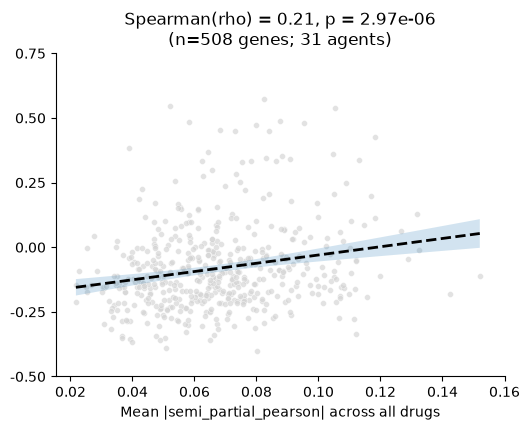

In [30]:
genotoxic_agents_to_test = [
    c for c in crispr_df.columns
    if c != "Gene"
]

out = correlate_importance_vs_crispr_small_system_genes(
    importance_df=gene_importance_df,
    crispr_df=crispr_df,
    genotoxic_agents=genotoxic_agents_to_test,
    system_to_genes=system_to_genes,
    important_genes=important_genes,
    x_max=0.16,
    y_min=-0.50,
    y_max=0.75,
    y_tick_step=0.25,
    out_svg="importance_vs_crispr_scatter.svg"
)

### b. Crispr Z-Scores of Important Genes vs Non-Important Genes (Fig. 5g)

In [31]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from typing import Dict, Iterable, Any, Optional, List, Set, Tuple


def _genes_in_small_systems(system_to_genes: Dict[str, Iterable[Any]], max_system_genes: int) -> Set[str]:
    small = set()
    for _, genes in system_to_genes.items():
        try:
            glist = list(genes)
        except Exception:
            continue
        if len(glist) <= int(max_system_genes):
            for g in glist:
                if g is None:
                    continue
                gs = str(g).strip()
                if gs:
                    small.add(gs)
    return small


def _add_sig_bracket(ax, x1, x2, y, h, text, lw=1.2, mid_tick=False, tick_frac=0.45):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y],
            color="black", linewidth=lw, clip_on=False)
    if mid_tick:
        xm = (x1 + x2) / 2
        ax.plot([xm, xm], [y + h, y + h - tick_frac * h],
                color="black", linewidth=lw, clip_on=False)
    ax.text((x1 + x2) / 2, y + h, text,
            ha="center", va="bottom", fontsize=10, color="black", clip_on=False)


def _format_raw_p_two_sig_digits(p: float) -> str:
    if not np.isfinite(p):
        return r"$P = \mathrm{nan}$"

    if p < 1e-3:
        exp = int(np.floor(np.log10(p)))
        a = p / (10 ** exp)
        return rf"$P = {a:.0f}\times 10^{{{exp}}}$"

    if 1e-2 < p < 5e-2:
        return f"P = {p:.3f}"
    if 1e-3 < p <= 1e-2:
        return f"P = {p:.4f}"

    return f"P = {p:.4f}"


def _recolor_swarm_points_by_gene_sets(
    ax: plt.Axes,
    df_plot: pd.DataFrame,
    x_col: str,
    y_col: str,
    gene_col: str,
    order: list,
    default_palette: Dict[str, str],
    important_genes: Set[str],
    bottom_genes: Set[str],
    important_color: str = "red",
    bottom_color: str = "green",
):
    collections = [c for c in ax.collections if hasattr(c, "get_offsets")]
    if len(collections) == 0:
        return

    df_tmp = df_plot.copy()
    df_tmp[gene_col] = df_tmp[gene_col].astype(str)
    group_rows = {
        g: df_tmp[df_tmp[x_col] == g][[gene_col, y_col]].reset_index(drop=True)
        for g in order
    }

    default_rgba = {g: np.array(plt.matplotlib.colors.to_rgba(default_palette[g])) for g in order}
    imp_rgba = np.array(plt.matplotlib.colors.to_rgba(important_color))
    bot_rgba = np.array(plt.matplotlib.colors.to_rgba(bottom_color))

    for coll in collections:
        offs = coll.get_offsets()
        if offs is None or len(offs) == 0:
            continue

        offs = np.asarray(offs, dtype=float)
        xs = offs[:, 0]
        ys = offs[:, 1]

        x_med = float(np.median(xs))
        grp = min(order, key=lambda g: abs(x_med - order.index(g)))

        sub = group_rows.get(grp, None)
        if sub is None or len(sub) != len(ys):
            continue

        point_order = np.argsort(ys, kind="mergesort")
        row_order = np.argsort(sub[y_col].to_numpy(dtype=float), kind="mergesort")

        face = np.tile(default_rgba[grp], (len(ys), 1))
        sub_genes_sorted = sub[gene_col].to_numpy()[row_order]

        for k, gname in enumerate(sub_genes_sorted):
            if gname in important_genes:
                face[point_order[k]] = imp_rgba
            elif gname in bottom_genes:
                face[point_order[k]] = bot_rgba

        coll.set_facecolors(face)


def compare_crispr_maxabs_allimportant_vs_bottomN(
    drpt_important_genes_csv: str,
    crispr_df: pd.DataFrame,                 # first column 'Gene', other columns are genotoxic agents
    gene_importance_df: pd.DataFrame,        # columns include ['drug','gene',score_col]
    system_to_genes: Dict[str, Iterable[Any]],
    genotoxic_agents: List[str],             # which CRISPR columns to include in the per-gene aggregation
    bottom_n: int = 100,
    score_col: str = "semi_partial_pearson",
    max_system_genes: int = 100,
    important_gene_col: str = "gene",
    crispr_gene_col: str = "Gene",
    figsize: Tuple[float, float] = (5, 5),
    title: Optional[str] = None,
    make_plot: bool = True,
    out_svg: Optional[str] = None,
    x_tick_labels: Optional[List[str]] = None,
    y_label: Optional[str] = "Log10 Absolute Max CRISPR Z-score",
    y_top: Optional[float] = None,
    y_tick_step: Optional[float] = None,
    group_labels: Optional[Tuple[str, str]] = None,
    median_halfwidth: float = 0.35,
    swarm_size_base: float = 6.5,
    point_alpha: float = 1,
    point_edge_lw: float = 0.5,
    important_color: str = "red",
    bottom_color: str = "green",
    bracket_lw: float = 1.2,
    mwu_alternative: str = "greater",
    bottom_rank_agg: str = "max_abs",        # one of {'max_abs','mean_abs','median_abs'}
    crispr_agent_agg: str = "max_abs",       # one of {'max_abs','mean_abs'}
    log_base: float = 10.0,
    log_eps: float = 1e-6,
    # NEW
    top_n_important_to_report: int = 10,
    report_fontsize: int = 9,
):
    """
    Compare ALL important genes (from drpt_important_genes_csv) vs bottom-N least-important genes
    using per-gene aggregated absolute CRISPR z-score across selected genotoxic agents.

    Also reports the top N important genes with the highest mean absolute CRISPR score
    across the selected genotoxic agents.
    """

    # -----------------------------
    # Validate inputs
    # -----------------------------
    if crispr_gene_col not in crispr_df.columns:
        raise KeyError(f"crispr_df missing '{crispr_gene_col}' column")

    if not isinstance(genotoxic_agents, (list, tuple, np.ndarray, pd.Series)) or len(genotoxic_agents) == 0:
        raise ValueError("genotoxic_agents must be a non-empty list-like of CRISPR column names.")

    genotoxic_agents = [str(c) for c in genotoxic_agents]
    missing_agents = [c for c in genotoxic_agents if c not in crispr_df.columns]
    if missing_agents:
        raise KeyError(f"crispr_df missing requested genotoxic agent column(s): {missing_agents}")

    for col in ("drug", "gene", score_col):
        if col not in gene_importance_df.columns:
            raise KeyError(f"gene_importance_df missing required column '{col}'")

    if log_base <= 0 or log_base == 1:
        raise ValueError("log_base must be positive and not equal to 1.")
    if log_eps <= 0:
        raise ValueError("log_eps must be > 0.")

    bottom_rank_agg = str(bottom_rank_agg).lower().strip()
    if bottom_rank_agg not in {"max_abs", "mean_abs", "median_abs"}:
        raise ValueError("bottom_rank_agg must be one of {'max_abs','mean_abs','median_abs'}")

    crispr_agent_agg = str(crispr_agent_agg).lower().strip()
    if crispr_agent_agg not in {"max_abs", "mean_abs"}:
        raise ValueError("crispr_agent_agg must be one of {'max_abs','mean_abs'}")

    # -----------------------------
    # Small-system universe
    # -----------------------------
    small_genes = _genes_in_small_systems(system_to_genes, max_system_genes=max_system_genes)

    # -----------------------------
    # Load ALL important genes
    # -----------------------------
    imp_df = pd.read_csv(drpt_important_genes_csv)
    if important_gene_col not in imp_df.columns:
        raise KeyError(f"drpt_important_genes.csv missing column '{important_gene_col}'")

    imp_df[important_gene_col] = imp_df[important_gene_col].astype(str).str.strip()
    imp_genes_all = set(imp_df[important_gene_col].dropna().astype(str))
    imp_genes_all = {g for g in imp_genes_all if g} & small_genes

    if len(imp_genes_all) == 0:
        raise ValueError("No important genes remain after filtering to small-system genes.")

    # -----------------------------
    # Build per-gene aggregated |CRISPR z| across selected agents
    # -----------------------------
    cr = crispr_df[[crispr_gene_col] + genotoxic_agents].copy()
    cr = cr.rename(columns={crispr_gene_col: "gene"})
    cr["gene"] = cr["gene"].astype(str).str.strip()
    cr = cr[cr["gene"] != ""].copy()

    for c in genotoxic_agents:
        cr[c] = pd.to_numeric(cr[c], errors="coerce")

    if cr["gene"].duplicated().any():
        abs_cols = []
        for c in genotoxic_agents:
            ac = f"__abs__{c}"
            cr[ac] = cr[c].abs()
            abs_cols.append(ac)
        agg_dict = {ac: "max" for ac in abs_cols}
        cr = cr.groupby("gene", as_index=False).agg(agg_dict)
        cr = cr.rename(columns={f"__abs__{c}": c for c in genotoxic_agents})

        # main aggregation used in plot
        if crispr_agent_agg == "max_abs":
            cr["agg_abs_crispr_z"] = cr[genotoxic_agents].max(axis=1, skipna=True)
        else:
            cr["agg_abs_crispr_z"] = cr[genotoxic_agents].mean(axis=1, skipna=True)

        # NEW: always compute mean absolute CRISPR for reporting top genes
        cr["mean_abs_crispr_z"] = cr[genotoxic_agents].mean(axis=1, skipna=True)

    else:
        abs_mat = cr[genotoxic_agents].abs()

        if crispr_agent_agg == "max_abs":
            cr["agg_abs_crispr_z"] = abs_mat.max(axis=1, skipna=True)
        else:
            cr["agg_abs_crispr_z"] = abs_mat.mean(axis=1, skipna=True)

        # NEW
        cr["mean_abs_crispr_z"] = abs_mat.mean(axis=1, skipna=True)

    cr = cr.dropna(subset=["agg_abs_crispr_z"]).copy()

    # Restrict to small-system genes
    cr = cr[cr["gene"].isin(small_genes)].copy()

    if cr.empty:
        raise ValueError("No CRISPR genes remain after filtering to selected agents and small systems.")

    # -----------------------------
    # Group A: all important genes with CRISPR data
    # -----------------------------
    cr_imp = cr[cr["gene"].isin(imp_genes_all)].copy()
    if cr_imp.empty:
        raise ValueError(
            f"No important genes remain after intersecting with CRISPR data and small systems <= {max_system_genes}."
        )

    # NEW: top important genes by highest mean absolute CRISPR score
    top_important_report = (
        cr_imp[["gene", "mean_abs_crispr_z", "agg_abs_crispr_z"]]
        .sort_values(["mean_abs_crispr_z", "agg_abs_crispr_z", "gene"], ascending=[False, False, True])
        .head(int(top_n_important_to_report))
        .reset_index(drop=True)
    )

    # -----------------------------
    # Group B: bottom-N genes by aggregated DRPT importance across all drugs
    # -----------------------------
    gi = gene_importance_df[["drug", "gene", score_col]].dropna().copy()
    gi["gene"] = gi["gene"].astype(str).str.strip()
    gi[score_col] = pd.to_numeric(gi[score_col], errors="coerce")
    gi = gi.dropna(subset=[score_col])
    gi = gi[gi["gene"] != ""].copy()

    crispr_genes = set(cr["gene"])
    gi = gi[gi["gene"].isin(small_genes) & gi["gene"].isin(crispr_genes)].copy()

    if gi.empty:
        raise ValueError("No genes left in gene_importance_df after small-system + CRISPR filtering.")

    gi["abs_score"] = gi[score_col].abs()

    if bottom_rank_agg == "max_abs":
        gi_rank = gi.groupby("gene", as_index=False)["abs_score"].max()
    elif bottom_rank_agg == "mean_abs":
        gi_rank = gi.groupby("gene", as_index=False)["abs_score"].mean()
    else:
        gi_rank = gi.groupby("gene", as_index=False)["abs_score"].median()

    gi_rank = gi_rank.rename(columns={"abs_score": "importance_rank_score"})

    gi_bottom = gi_rank.sort_values("importance_rank_score", ascending=True)
    gi_bottom = gi_bottom[~gi_bottom["gene"].isin(imp_genes_all)]

    bottom_genes_list = gi_bottom["gene"].head(int(bottom_n)).tolist()
    bottom_genes_set = set(bottom_genes_list)

    if len(bottom_genes_set) < 2:
        raise ValueError(
            f"Bottom set too small after exclusions (got {len(bottom_genes_set)} genes). "
            f"Try reducing bottom_n or changing bottom_rank_agg."
        )

    cr_bottom = cr[cr["gene"].isin(bottom_genes_set)].copy()
    if cr_bottom["gene"].nunique() < 2:
        raise ValueError("Need at least 2 bottom genes with CRISPR data.")

    # -----------------------------
    # Transform values: log(aggregated absolute CRISPR z)
    # -----------------------------
    def _log_abs_val(arr: np.ndarray, base: float, eps: float) -> np.ndarray:
        a = np.asarray(arr, dtype=float)
        a = np.maximum(a, eps)
        if np.isclose(base, np.e):
            return np.log(a)
        return np.log(a) / np.log(base)

    data_imp = _log_abs_val(cr_imp["agg_abs_crispr_z"].to_numpy(dtype=float), base=log_base, eps=log_eps)
    data_bot = _log_abs_val(cr_bottom["agg_abs_crispr_z"].to_numpy(dtype=float), base=log_base, eps=log_eps)

    if data_imp.size < 2 or data_bot.size < 2:
        raise ValueError("Need at least 2 genes in each group for a stable MWU test.")

    # -----------------------------
    # MWU test
    # -----------------------------
    U, p = mannwhitneyu(data_imp, data_bot, alternative=mwu_alternative)
    p_label = _format_raw_p_two_sig_digits(float(p) if np.isfinite(p) else np.nan)

    med_imp = float(np.median(data_imp))
    med_bot = float(np.median(data_bot))

    # -----------------------------
    # Labels
    # -----------------------------
    if group_labels is None:
        label_imp = "All important genes"
        label_bot = f"Bottom {len(data_bot)} genes"
    else:
        if len(group_labels) != 2:
            raise ValueError("group_labels must be a tuple/list of length 2.")
        label_imp, label_bot = group_labels[0], group_labels[1]

    n_imp_points = int(len(data_imp))
    n_bot_points = int(len(data_bot))

    df_plot = pd.DataFrame({
        "gene": np.concatenate([
            cr_imp["gene"].to_numpy(dtype=object),
            cr_bottom["gene"].to_numpy(dtype=object)
        ]),
        "plot_value": np.concatenate([data_imp, data_bot]),
        "Group": ([label_imp] * len(data_imp)) + ([label_bot] * len(data_bot)),
    })

    out = {
        "genotoxic_agents_used": list(genotoxic_agents),
        "n_genotoxic_agents_used": int(len(genotoxic_agents)),
        "crispr_agent_agg": crispr_agent_agg,
        "max_system_genes": int(max_system_genes),
        "bottom_n_requested": int(bottom_n),
        "bottom_n_used": int(cr_bottom["gene"].nunique()),
        "n_bottom_points_used": n_bot_points,
        "n_important_points_used": n_imp_points,
        "n_important_genes_used": int(cr_imp["gene"].nunique()),
        "transform": f"log_{crispr_agent_agg}_crispr_z_across_selected_agents",
        "log_base": float(log_base),
        "log_eps": float(log_eps),
        "bottom_rank_agg": bottom_rank_agg,
        "mwu_U": float(U) if np.isfinite(U) else np.nan,
        "p_value": float(p) if np.isfinite(p) else np.nan,
        "p_label": p_label,
        "mwu_alternative": str(mwu_alternative),
        "median_important": med_imp,
        "median_bottom": med_bot,
        "important_genes_used": sorted(cr_imp["gene"].unique().tolist()),
        "bottom_genes_used": sorted(cr_bottom["gene"].unique().tolist()),
        "top_important_genes_by_mean_crispr": top_important_report.copy(),   # NEW
        "crispr_gene_table_used": cr.copy(),
        "importance_rank_table": gi_rank.copy(),
        "plot_table": df_plot.copy(),
    }

    # -----------------------------
    # Plot
    # -----------------------------
    if make_plot:
        # extra room below for gene list
        fig, ax = plt.subplots(figsize=figsize)
        fig.subplots_adjust(bottom=0.34)

        order = [label_imp, label_bot]
        palette_base = {label_imp: "#1f77b4", label_bot: "#ff7f0e"}

        sns.swarmplot(
            data=df_plot,
            x="Group", y="plot_value",
            order=order,
            palette=palette_base,
            ax=ax,
            size=swarm_size_base,
            edgecolor="black",
            linewidth=point_edge_lw,
            alpha=point_alpha,
            warn_thresh=0.1
        )

        _recolor_swarm_points_by_gene_sets(
            ax=ax,
            df_plot=df_plot.rename(columns={"Group": "_x", "plot_value": "_y", "gene": "_gene"}),
            x_col="_x",
            y_col="_y",
            gene_col="_gene",
            order=order,
            default_palette=palette_base,
            important_genes=set(cr_imp["gene"].astype(str).tolist()),
            bottom_genes=set(cr_bottom["gene"].astype(str).tolist()),
            important_color=important_color,
            bottom_color=bottom_color,
        )

        x_left, x_right = 0, 1
        ax.plot([x_left - median_halfwidth, x_left + median_halfwidth], [med_imp, med_imp],
                color="black", linestyle="--", linewidth=2.5, solid_capstyle="butt", zorder=3)
        ax.plot([x_right - median_halfwidth, x_right + median_halfwidth], [med_bot, med_bot],
                color="black", linestyle="--", linewidth=2.5, solid_capstyle="butt", zorder=3)

        ax.set_xlabel("")

        if y_label is None:
            if np.isclose(log_base, np.e):
                if crispr_agent_agg == "max_abs":
                    ylab = r"$\ln$(max |CRISPR Z-Score| across selected agents)"
                else:
                    ylab = r"$\ln$(mean |CRISPR Z-Score| across selected agents)"
            else:
                base_str = str(int(log_base)) if float(log_base).is_integer() else str(log_base)
                if crispr_agent_agg == "max_abs":
                    ylab = rf"$\log_{{{base_str}}}$(max |CRISPR Z-score| across selected agents)"
                else:
                    ylab = rf"$\log_{{{base_str}}}$(mean |CRISPR Z-score| across selected agents)"
        else:
            if y_label == "Log10 Absolute Max CRISPR Z-score":
                if np.isclose(log_base, np.e):
                    if crispr_agent_agg == "max_abs":
                        ylab = r"$\ln$(max |CRISPR Z-Score| across selected agents)"
                    else:
                        ylab = r"$\ln$(mean |CRISPR Z-Score| across selected agents)"
                else:
                    base_str = str(int(log_base)) if float(log_base).is_integer() else str(log_base)
                    if crispr_agent_agg == "max_abs":
                        ylab = rf"$\log_{{{base_str}}}$(|CRISPR z-score|)" + "\n(max across all genotoxic agents screened)"
                    else:
                        ylab = rf"$\log_{{{base_str}}}$(|CRISPR z-score|)" + "\n(mean across all genotoxic agents screened)"
            else:
                ylab = y_label

        ax.set_ylabel("")

        if x_tick_labels is not None:
            if len(x_tick_labels) != 2:
                raise ValueError("x_tick_labels must be length 2.")
            xticks_with_n = [
                f"{x_tick_labels[0]}\n(n = {n_imp_points})",
                f"{x_tick_labels[1]}\n(n = {n_bot_points})",
            ]
        else:
            xticks_with_n = [
                f"{label_imp}\n(n = {n_imp_points})",
                f"{label_bot}\n(n = {n_bot_points})",
            ]

        ax.set_xticks([0, 1])

        ax.grid(False)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.set_xlim(-0.5, 1.5)

        if y_top is None:
            ymin_data = float(np.nanmin(df_plot["plot_value"].to_numpy(dtype=float))) if len(df_plot) else -1.0
            ymax_data = float(np.nanmax(df_plot["plot_value"].to_numpy(dtype=float))) if len(df_plot) else 1.0
            yr = max(ymax_data - ymin_data, 1e-6)
            ymin_use = ymin_data - 0.08 * yr
            ymax_use = ymax_data + 0.20 * yr
            if y_tick_step is not None and y_tick_step > 0:
                ymin_use = np.floor(ymin_use / y_tick_step) * y_tick_step
                ymax_use = np.ceil(ymax_use / y_tick_step) * y_tick_step
        else:
            ymin_data = float(np.nanmin(df_plot["plot_value"].to_numpy(dtype=float))) if len(df_plot) else 0.0
            ymin_use = min(0.0, ymin_data - 0.05 * max(abs(ymin_data), 1.0))
            ymax_use = float(y_top)

        ax.set_ylim(ymin_use, ymax_use)

        if y_tick_step is not None and y_tick_step > 0:
            ticks = np.arange(
                np.floor(ymin_use / y_tick_step) * y_tick_step,
                ymax_use + 1e-12,
                y_tick_step
            )
            ax.set_yticks(ticks)
            if y_tick_step < 1:
                ax.set_yticklabels([f"{t:.2f}" for t in ticks])
            else:
                ax.set_yticklabels([f"{t:g}" for t in ticks])

        y_range = ax.get_ylim()[1] - ax.get_ylim()[0]
        h = 0.02 * y_range
        pad = 0.02 * y_range
        y0 = ax.get_ylim()[1] - (h + pad)
        _add_sig_bracket(ax, x_left, x_right, y0, h, p_label, lw=bracket_lw)

        leg = ax.get_legend()
        if leg is not None:
            leg.remove()

        if title is not None:
            ax.set_title(title, fontsize=11, y=1.04)

        # NEW: print top genes below plot
        if len(top_important_report):
            lines = [
                f"{i+1}. {row['gene']} ({row['mean_abs_crispr_z']:.3f})"
                for i, (_, row) in enumerate(top_important_report.iterrows())
            ]
            mid = int(np.ceil(len(lines) / 2))
            left_block = "\n".join(lines[:mid])
            right_block = "\n".join(lines[mid:])

            fig.text(
                0.06, 0.03,
                "Top important genes by mean |CRISPR|:\n" + left_block,
                ha="left", va="bottom", fontsize=report_fontsize, family="monospace"
            )
            if len(right_block) > 0:
                fig.text(
                    0.54, 0.03,
                    right_block,
                    ha="left", va="bottom", fontsize=report_fontsize, family="monospace"
                )

        plt.tight_layout(rect=[0, 0.16, 1, 1])

        if out_svg is not None:
            plt.rcParams["svg.fonttype"] = "none"
            fig.savefig(out_svg, format="svg", bbox_inches="tight")
            print(f"Saved SVG to: {out_svg}")

        plt.show()

    return out

Saved SVG to: crispr_allimportant_vs_bottomN_backup.svg


/var/folders/xn/6msch0w517d5fc96lf16x1wc0000gp/T/ipykernel_2856/1857415829.py:402: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(


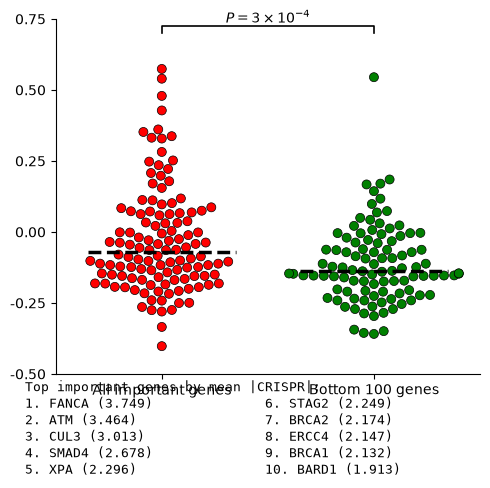

In [32]:
genotoxic_agents = list(set(list(crispr_df.columns)).difference({'Gene'}))

# Example usage:
stats_all = compare_crispr_maxabs_allimportant_vs_bottomN(
    drpt_important_genes_csv="drpt_rsi_important_genes.csv",
    crispr_df=crispr_df,
    gene_importance_df=gene_importance_df,
    system_to_genes=system_to_genes,
    genotoxic_agents=genotoxic_agents,
    bottom_n=100,
    score_col="semi_partial_pearson",
    max_system_genes=100,
    figsize=(5, 5),
    title="",
    x_tick_labels=["", ""],
    y_top=0.75,
    y_tick_step=0.25,
    out_svg="crispr_allimportant_vs_bottomN_backup.svg",
    important_color="red",
    bottom_color="green",
    mwu_alternative="greater",
    bottom_rank_agg="max_abs",   # or "mean_abs", "median_abs"
    log_base=10.0,
    log_eps=1e-6,
    crispr_agent_agg="mean_abs"
)

### c. Crispr Z-Scores of Important Genes vs Non-Important Genes for Specific Drug (Fig. 5h)

In [33]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from typing import Dict, Iterable, Any, Optional, List, Set, Tuple


def _genes_in_small_systems(system_to_genes: Dict[str, Iterable[Any]], max_system_genes: int) -> Set[str]:
    small = set()
    for _, genes in system_to_genes.items():
        try:
            glist = list(genes)
        except Exception:
            continue
        if len(glist) <= int(max_system_genes):
            for g in glist:
                if g is None:
                    continue
                gs = str(g).strip()
                if gs:
                    small.add(gs)
    return small


def _parse_drug_list_cell(x) -> Set[str]:
    """Parse 'important drugs' cell that is semicolon-separated. Robust to NaN."""
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return set()
    s = str(x).strip()
    if s == "":
        return set()
    return {t.strip() for t in s.split(";") if t.strip() != ""}


def _add_sig_bracket(ax, x1, x2, y, h, text, lw=1.2, mid_tick=False, tick_frac=0.45):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y],
            color="black", linewidth=lw, clip_on=False)
    if mid_tick:
        xm = (x1 + x2) / 2
        ax.plot([xm, xm], [y + h, y + h - tick_frac * h],
                color="black", linewidth=lw, clip_on=False)
    ax.text((x1 + x2) / 2, y + h, text,
            ha="center", va="bottom", fontsize=10, color="black", clip_on=False)


def _format_raw_p_two_sig_digits(p: float) -> str:
    
    if not np.isfinite(p):
        return r"$P = \mathrm{nan}$"

    if p < 1e-2:
        exp = int(np.floor(np.log10(p)))
        a = p / (10 ** exp)
        return rf"$P = {a:.0f}\times 10^{{{exp}}}$"

    if 1e-2 < p < 5e-2:
        return f"P = {p:.3f}"

    return f"P = {p:.4f}"


def _recolor_swarm_points_by_gene_sets(
    ax: plt.Axes,
    df_plot: pd.DataFrame,
    x_col: str,
    y_col: str,
    gene_col: str,
    order: list,
    default_palette: Dict[str, str],
    important_genes: Set[str],
    bottom_genes: Set[str],
    important_color: str = "red",
    bottom_color: str = "green",
):
    collections = [c for c in ax.collections if hasattr(c, "get_offsets")]
    if len(collections) == 0:
        return

    df_tmp = df_plot.copy()
    df_tmp[gene_col] = df_tmp[gene_col].astype(str)
    group_rows = {
        g: df_tmp[df_tmp[x_col] == g][[gene_col, y_col]].reset_index(drop=True)
        for g in order
    }

    default_rgba = {g: np.array(plt.matplotlib.colors.to_rgba(default_palette[g])) for g in order}
    imp_rgba = np.array(plt.matplotlib.colors.to_rgba(important_color))
    bot_rgba = np.array(plt.matplotlib.colors.to_rgba(bottom_color))

    for coll in collections:
        offs = coll.get_offsets()
        if offs is None or len(offs) == 0:
            continue

        offs = np.asarray(offs, dtype=float)
        xs = offs[:, 0]
        ys = offs[:, 1]

        x_med = float(np.median(xs))
        grp = min(order, key=lambda g: abs(x_med - order.index(g)))

        sub = group_rows.get(grp, None)
        if sub is None or len(sub) != len(ys):
            continue

        point_order = np.argsort(ys, kind="mergesort")
        row_order = np.argsort(sub[y_col].to_numpy(dtype=float), kind="mergesort")

        face = np.tile(default_rgba[grp], (len(ys), 1))
        sub_genes_sorted = sub[gene_col].to_numpy()[row_order]

        for k, gname in enumerate(sub_genes_sorted):
            if gname in important_genes:
                face[point_order[k]] = imp_rgba
            elif gname in bottom_genes:
                face[point_order[k]] = bot_rgba

        coll.set_facecolors(face)


def compare_crispr_abs_important_vs_bottomN(
    drpt_important_genes_csv: str,
    crispr_df: pd.DataFrame,                 # columns: 'Gene' + drug columns (z-scores)
    gene_importance_df: pd.DataFrame,        # columns include ['drug','gene',score_col]
    system_to_genes: Dict[str, Iterable[Any]],
    drug: str,
    bottom_n: int = 100,
    score_col: str = "semi_partial_pearson",
    max_system_genes: int = 100,
    important_gene_col: str = "gene",
    important_drugs_col: str = "sig_drugs",
    crispr_gene_col: str = "Gene",
    figsize: Tuple[float, float] = (5, 5),
    title: Optional[str] = None,
    make_plot: bool = True,
    out_svg: Optional[str] = None,
    x_tick_labels: Optional[List[str]] = None,
    y_label: Optional[str] = "Log10 Absolute CRISPR Z-score",
    y_top: Optional[float] = None,
    y_tick_step: Optional[float] = None,
    group_labels: Optional[Tuple[str, str]] = None,
    median_halfwidth: float = 0.35,
    swarm_size_base: float = 6.5,
    point_alpha: float = 0.65,
    point_edge_lw: float = 0.5,
    important_color: str = "red",
    bottom_color: str = "green",
    bracket_lw: float = 1.2,
    mwu_alternative: str = "greater",
    log_base: float = 10.0,
    log_eps: float = 1e-6,
    # NEW
    top_n_important_to_report: int = 10,
    report_fontsize: int = 9,
):
    """
    Compare IMPORTANT genes vs bottom-N least-important genes using CRISPR z-scores.

    Test + plot quantity:
        log_base(max(|z|, log_eps))

    Also reports the top N important genes with the highest absolute CRISPR score
    for the selected drug.
    """

    # ---- validate CRISPR ----
    if crispr_gene_col not in crispr_df.columns:
        raise KeyError(f"crispr_df missing '{crispr_gene_col}' column")
    if drug not in crispr_df.columns:
        raise KeyError(f"crispr_df missing drug column '{drug}'")

    # ---- validate importance df ----
    for col in ("drug", "gene", score_col):
        if col not in gene_importance_df.columns:
            raise KeyError(f"gene_importance_df missing required column '{col}'")

    if log_base <= 0 or log_base == 1:
        raise ValueError("log_base must be positive and not equal to 1.")
    if log_eps <= 0:
        raise ValueError("log_eps must be > 0.")

    # ---- small-system universe ----
    small_genes = _genes_in_small_systems(system_to_genes, max_system_genes=max_system_genes)

    # ---- load important genes CSV ----
    imp_df = pd.read_csv(drpt_important_genes_csv)
    if important_gene_col not in imp_df.columns:
        raise KeyError(f"drpt_important_genes.csv missing column '{important_gene_col}'")
    if important_drugs_col not in imp_df.columns:
        raise KeyError(f"drpt_important_genes.csv missing column '{important_drugs_col}'")

    imp_df[important_gene_col] = imp_df[important_gene_col].astype(str)
    imp_df["_drug_set"] = imp_df[important_drugs_col].apply(_parse_drug_list_cell)

    # Important-for-this-drug genes
    imp_genes = set(
        imp_df.loc[imp_df["_drug_set"].apply(lambda s: str(drug) in s), important_gene_col].astype(str)
    )
    imp_genes = imp_genes & small_genes

    # ---- tidy CRISPR for this drug ----
    cr = crispr_df[[crispr_gene_col, drug]].copy()
    cr.columns = ["gene", "crispr_z"]
    cr["gene"] = cr["gene"].astype(str)
    cr["crispr_z"] = pd.to_numeric(cr["crispr_z"], errors="coerce")
    cr = cr.dropna(subset=["crispr_z"])

    # Keep only genes in small systems
    cr = cr[cr["gene"].isin(small_genes)].copy()

    # absolute CRISPR z for reporting
    cr["abs_crispr_z"] = cr["crispr_z"].abs()

    # Group A: Important-for-drug genes with CRISPR data
    cr_imp = cr[cr["gene"].isin(imp_genes)].copy()
    if cr_imp.empty:
        raise ValueError(
            f"No IMPORTANT genes for drug='{drug}' after filtering "
            f"(small systems <= {max_system_genes} and CRISPR availability)."
        )

    # NEW: top important genes by highest absolute CRISPR score
    top_important_report = (
        cr_imp[["gene", "crispr_z", "abs_crispr_z"]]
        .sort_values(["abs_crispr_z", "gene"], ascending=[False, True])
        .head(int(top_n_important_to_report))
        .reset_index(drop=True)
    )

    # ---- Group B: bottom N by |importance score| for this drug ----
    gi = gene_importance_df.loc[
        gene_importance_df["drug"].astype(str) == str(drug),
        ["gene", score_col]
    ].dropna().copy()
    gi["gene"] = gi["gene"].astype(str)
    gi[score_col] = pd.to_numeric(gi[score_col], errors="coerce")
    gi = gi.dropna(subset=[score_col])

    crispr_genes = set(cr["gene"])
    gi = gi[gi["gene"].isin(small_genes) & gi["gene"].isin(crispr_genes)].copy()

    if gi.empty:
        raise ValueError(f"No genes left in gene_importance_df for drug='{drug}' after filters.")

    gi["abs_score"] = gi[score_col].abs()

    # bottom N = smallest |importance|
    gi_bottom = gi.sort_values("abs_score", ascending=True)

    # exclude important genes from bottom set
    gi_bottom = gi_bottom[~gi_bottom["gene"].isin(imp_genes)]

    bottom_genes_list = gi_bottom["gene"].head(int(bottom_n)).tolist()
    bottom_genes_set = set(map(str, bottom_genes_list))
    if len(bottom_genes_set) < 2:
        raise ValueError(
            f"Bottom set too small (got {len(bottom_genes_set)} genes). "
            f"Try reducing bottom_n or increasing available candidates."
        )

    cr_bottom = cr[cr["gene"].isin(bottom_genes_set)].copy()
    if cr_bottom["gene"].nunique() < 2:
        raise ValueError("Need at least 2 bottom genes with CRISPR data.")

    # ---- transform CRISPR values: log(|z|) with epsilon guard ----
    def _log_abs_z(arr: np.ndarray, base: float, eps: float) -> np.ndarray:
        a = np.asarray(arr, dtype=float)
        mag = np.abs(a)
        mag = np.maximum(mag, eps)
        if np.isclose(base, np.e):
            return np.log(mag)
        return np.log(mag) / np.log(base)

    data_imp = _log_abs_z(cr_imp["crispr_z"].to_numpy(dtype=float), base=log_base, eps=log_eps)
    data_bot = _log_abs_z(cr_bottom["crispr_z"].to_numpy(dtype=float), base=log_base, eps=log_eps)

    if data_imp.size < 2 or data_bot.size < 2:
        raise ValueError("Need at least 2 genes in each group for a stable MWU test.")

    # ---- MWU on transformed values ----
    U, p = mannwhitneyu(data_imp, data_bot, alternative=mwu_alternative)
    p_label = _format_raw_p_two_sig_digits(float(p) if np.isfinite(p) else np.nan)

    med_imp = float(np.median(data_imp))
    med_bot = float(np.median(data_bot))

    # Labels
    if group_labels is None:
        label_imp = "Important genes"
        label_bot = f"Bottom {len(data_bot)} genes"
    else:
        if len(group_labels) != 2:
            raise ValueError("group_labels must be a tuple/list of length 2.")
        label_imp, label_bot = group_labels[0], group_labels[1]

    n_imp_points = int(len(data_imp))
    n_bot_points = int(len(data_bot))

    # plotting dataframe WITH gene identity
    df_plot = pd.DataFrame({
        "gene": np.concatenate([cr_imp["gene"].to_numpy(dtype=object), cr_bottom["gene"].to_numpy(dtype=object)]),
        "plot_value": np.concatenate([data_imp, data_bot]),
        "Group": ([label_imp] * len(data_imp)) + ([label_bot] * len(data_bot)),
    })

    out = {
        "drug": str(drug),
        "max_system_genes": int(max_system_genes),
        "bottom_n_requested": int(bottom_n),
        "bottom_n_used": int(cr_bottom["gene"].nunique()),
        "n_bottom_points_used": n_bot_points,
        "n_important_points_used": n_imp_points,
        "n_important_genes_used": int(cr_imp["gene"].nunique()),
        "transform": "log_abs_z",
        "log_base": float(log_base),
        "log_eps": float(log_eps),
        "mwu_U": float(U) if np.isfinite(U) else np.nan,
        "p_value": float(p) if np.isfinite(p) else np.nan,
        "p_label": p_label,
        "mwu_alternative": str(mwu_alternative),
        "median_important": med_imp,
        "median_bottom": med_bot,
        "important_genes_used": sorted(cr_imp["gene"].unique().tolist()),
        "bottom_genes_used": sorted(cr_bottom["gene"].unique().tolist()),
        "top_important_genes_by_abs_crispr": top_important_report.copy(),   # NEW
        "plot_table": df_plot.copy(),
    }

    if make_plot:
        fig, ax = plt.subplots(figsize=figsize)
        fig.subplots_adjust(bottom=0.34)

        order = [label_imp, label_bot]
        palette_base = {label_imp: "#1f77b4", label_bot: "#ff7f0e"}

        sns.swarmplot(
            data=df_plot,
            x="Group", y="plot_value",
            order=order,
            palette=palette_base,
            ax=ax,
            size=swarm_size_base,
            edgecolor="black",
            linewidth=point_edge_lw,
            alpha=point_alpha,
            warn_thresh=0.1
        )

        _recolor_swarm_points_by_gene_sets(
            ax=ax,
            df_plot=df_plot.rename(columns={"Group": "_x", "plot_value": "_y", "gene": "_gene"}),
            x_col="_x",
            y_col="_y",
            gene_col="_gene",
            order=order,
            default_palette=palette_base,
            important_genes=set(cr_imp["gene"].astype(str).tolist()),
            bottom_genes=set(cr_bottom["gene"].astype(str).tolist()),
            important_color=important_color,
            bottom_color=bottom_color,
        )

        x_left, x_right = 0, 1
        ax.plot([x_left - median_halfwidth, x_left + median_halfwidth], [med_imp, med_imp],
                color="black", linestyle="--", linewidth=2.5, solid_capstyle="butt", zorder=3)
        ax.plot([x_right - median_halfwidth, x_right + median_halfwidth], [med_bot, med_bot],
                color="black", linestyle="--", linewidth=2.5, solid_capstyle="butt", zorder=3)

        ax.set_xlabel("")

        if y_label is None:
            if np.isclose(log_base, np.e):
                ylab = r"$\ln$(|CRISPR Z-Score|)"
            else:
                base_str = str(int(log_base)) if float(log_base).is_integer() else str(log_base)
                ylab = rf"$\log_{{{base_str}}}$(|CRISPR z-score|)" + "\n(only from doxorubicin screen)"
            ax.set_ylabel(ylab, fontsize=11)
        else:
            if y_label == "Log10 Absolute CRISPR Z-score":
                if np.isclose(log_base, np.e):
                    ylab = r"$\ln$(|CRISPR Z-Score|)"
                else:
                    base_str = str(int(log_base)) if float(log_base).is_integer() else str(log_base)
                    ylab = rf"$\log_{{{base_str}}}$(|CRISPR z-score|)" + "\n(only from doxorubicin screen)"
                ax.set_ylabel(ylab, fontsize=11)
            else:
                ax.set_ylabel(y_label, fontsize=11)

        if x_tick_labels is not None:
            if len(x_tick_labels) != 2:
                raise ValueError("x_tick_labels must be length 2.")
            xticks_with_n = [
                f"{x_tick_labels[0]}\n(n = {n_imp_points})",
                f"{x_tick_labels[1]}\n(n = {n_bot_points})",
            ]
        else:
            xticks_with_n = [
                f"{label_imp}\n(n = {n_imp_points})",
                f"{label_bot}\n(n = {n_bot_points})",
            ]

        ax.set_xticks([0, 1])
        ax.set_xticklabels(xticks_with_n, fontsize=11)

        ax.grid(False)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.set_xlim(-0.5, 1.5)

        if y_top is None:
            ymin_data = float(np.nanmin(df_plot["plot_value"].to_numpy(dtype=float))) if len(df_plot) else -1.0
            ymax_data = float(np.nanmax(df_plot["plot_value"].to_numpy(dtype=float))) if len(df_plot) else 1.0
            yr = max(ymax_data - ymin_data, 1e-6)
            ymin_use = ymin_data - 0.08 * yr
            ymax_use = ymax_data + 0.20 * yr
            if y_tick_step is not None and y_tick_step > 0:
                ymin_use = np.floor(ymin_use / y_tick_step) * y_tick_step
                ymax_use = np.ceil(ymax_use / y_tick_step) * y_tick_step
        else:
            ymin_data = float(np.nanmin(df_plot["plot_value"].to_numpy(dtype=float))) if len(df_plot) else 0.0
            ymin_use = min(0.0, ymin_data - 0.05 * max(abs(ymin_data), 1.0))
            ymax_use = float(y_top)

        ax.set_ylim(ymin_use, ymax_use)

        if y_tick_step is not None and y_tick_step > 0:
            ticks = np.arange(
                np.floor(ymin_use / y_tick_step) * y_tick_step,
                ymax_use + 1e-12,
                y_tick_step
            )
            ax.set_yticks(ticks)
            if y_tick_step < 1:
                ax.set_yticklabels([f"{t:.2f}" for t in ticks])
            else:
                ax.set_yticklabels([f"{t:g}" for t in ticks])

        y_range = ax.get_ylim()[1] - ax.get_ylim()[0]
        h = 0.02 * y_range
        pad = 0.02 * y_range
        y0 = ax.get_ylim()[1] - (h + pad)
        _add_sig_bracket(ax, x_left, x_right, y0, h, p_label, lw=bracket_lw)

        leg = ax.get_legend()
        if leg is not None:
            leg.remove()

        if title is not None:
            ax.set_title(title, fontsize=11, y=1.04)

        # NEW: print top genes below plot
        if len(top_important_report):
            lines = [
                f"{i+1}. {row['gene']} ({row['abs_crispr_z']:.3f})"
                for i, (_, row) in enumerate(top_important_report.iterrows())
            ]
            mid = int(np.ceil(len(lines) / 2))
            left_block = "\n".join(lines[:mid])
            right_block = "\n".join(lines[mid:])

            fig.text(
                0.06, 0.03,
                f"Top important genes by |CRISPR| for {drug}:\n" + left_block,
                ha="left", va="bottom", fontsize=report_fontsize, family="monospace"
            )
            if len(right_block) > 0:
                fig.text(
                    0.54, 0.03,
                    right_block,
                    ha="left", va="bottom", fontsize=report_fontsize, family="monospace"
                )

        plt.tight_layout(rect=[0, 0.16, 1, 1])

        if out_svg is not None:
            plt.rcParams["svg.fonttype"] = "none"
            fig.savefig(out_svg, format="svg", bbox_inches="tight")
            print(f"Saved SVG to: {out_svg}")

        plt.show()

    return out

Saved SVG to: crispr_important_vs_bottomN_doxo.svg


/var/folders/xn/6msch0w517d5fc96lf16x1wc0000gp/T/ipykernel_2856/1515878940.py:337: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(


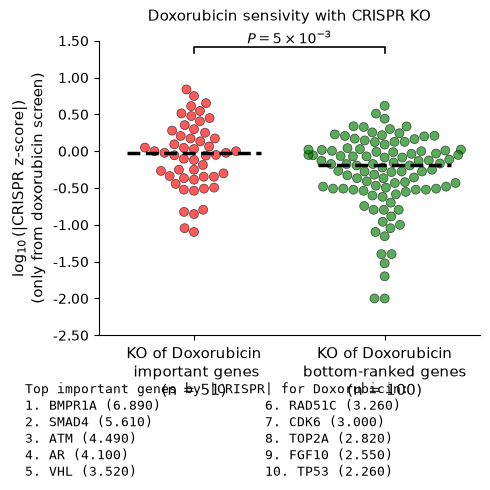

In [34]:
stats = compare_crispr_abs_important_vs_bottomN(
    drpt_important_genes_csv="drpt_rsi_important_genes.csv",
    crispr_df=crispr_df,
    gene_importance_df=gene_importance_df,
    system_to_genes=system_to_genes,
    drug="Doxorubicin",
    bottom_n=100,
    score_col="semi_partial_pearson",
    max_system_genes=100,
    figsize=(5, 5),
    title="Doxorubicin sensivity with CRISPR KO",
    x_tick_labels=["KO of Doxorubicin\n important genes", "KO of Doxorubicin\nbottom-ranked genes"],
    y_top=1.5,
    y_tick_step=0.5,
    out_svg="crispr_important_vs_bottomN_doxo.svg",
    important_color="red",
    bottom_color="green",
)

# 3. Epistasis among Pathway Determinants of Chemotherapy Response

This section analyzes the results from the system epistasis scoring analysis, notably to search for any relationship between importance scoring and epistasis.

## Load in model results dictionary (very large, contains embeddings)

In [35]:
with open("results_g2d.pkl", "rb") as handle:
    results = pickle.load(handle)

## i. General epistasis analysis among genes and systems (Fig. 6)

### a. Epistasis Scores of Important vs Unimportant (Fig. 6b)

In [36]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu


def _add_sig_bracket(ax, x1, x2, y, h, text, lw=1.2, mid_tick=False, tick_frac=0.45):
    ax.plot(
        [x1, x1, x2, x2],
        [y, y + h, y + h, y],
        color="black",
        linewidth=lw,
        clip_on=False
    )

    if mid_tick:
        xm = (x1 + x2) / 2
        ax.plot(
            [xm, xm],
            [y + h, y + h - tick_frac * h],
            color="black",
            linewidth=lw,
            clip_on=False
        )

    ax.text(
        (x1 + x2) / 2,
        y + h,
        text,
        ha="center",
        va="bottom",
        fontsize=10,
        color="black",
        clip_on=False
    )


def _format_p_for_bracket(p: float) -> str:

    if not np.isfinite(p):
        return r"$P = \mathrm{nan}$"

    if p < 1e-4:
        exp = int(np.floor(np.log10(p)))
        a = p / (10 ** exp)
        return rf"$P = {a:.0f}\times 10^{{{exp}}}$"

    if 1e-2 < p < 5e-2:
        return rf"$P = {p:.3f}$"

    if 1e-3 < p <= 1e-2:
        return rf"$P = {p:.4f}$"

    if 1e-4 < p <= 1e-3:
        return rf"$P = {p:.5f}$"

    return f"$P = {p:.4f}$"


def swarm_epistasis_scores_rsi_important_vs_unimportant(
    epistasis_csv,
    rsi_important_systems,
    epistasis_score_col="epistasis_score_mean_neglog10p",
    system_col="system",
    drug_col="drug",
    aggregate="mean",  # "mean" or "max"
    alternative="greater",
    figsize=(5, 5),
    important_label="RSi important",
    unimportant_label="RSi unimportant",
    important_color="#7C86AE",
    unimportant_color="#A9BBCA",
    point_size=8,
    point_alpha=0.7,
    median_halfwidth=0.35,

    # NEW:
    y_min=None,
    y_max=None,
    y_tick_step=None,

    ylabel=None,
    title=None,
    out_svg="rsi_important_vs_unimportant_epistasis_swarm.svg",
    make_plot=True,
    show=True,
):
    """
    Compare epistasis scores between RSi-important and RSi-unimportant systems.

    New options:
        y_min
        y_max
        y_tick_step
    """

    if aggregate not in {"mean", "max"}:
        raise ValueError("aggregate must be 'mean' or 'max'.")

    rsi_important_systems = set(map(str, rsi_important_systems))

    df = pd.read_csv(epistasis_csv).copy()

    required = {epistasis_score_col, system_col, drug_col}
    missing = required - set(df.columns)

    if missing:
        raise ValueError(f"Missing columns from input file: {missing}")

    df[system_col] = df[system_col].astype(str)

    df[epistasis_score_col] = pd.to_numeric(
        df[epistasis_score_col],
        errors="coerce"
    )

    df = df.dropna(subset=[
        epistasis_score_col,
        system_col,
        drug_col
    ])

    # Aggregate across drugs per system
    system_df = (
        df.groupby(system_col, as_index=False)
        .agg(
            epistasis_score=(epistasis_score_col, aggregate),
            n_drugs=(drug_col, "nunique"),
            drugs=(drug_col, lambda x: ",".join(sorted(map(str, set(x)))))
        )
    )

    system_df["rsi_important"] = (
        system_df[system_col].isin(rsi_important_systems)
    )

    system_df["Group"] = np.where(
        system_df["rsi_important"],
        important_label,
        unimportant_label
    )

    group1 = system_df.loc[
        system_df["Group"] == important_label,
        "epistasis_score"
    ].to_numpy(dtype=float)

    group2 = system_df.loc[
        system_df["Group"] == unimportant_label,
        "epistasis_score"
    ].to_numpy(dtype=float)

    if len(group1) == 0 or len(group2) == 0:
        raise ValueError(
            f"Need both groups non-empty. "
            f"{important_label}: n={len(group1)}, "
            f"{unimportant_label}: n={len(group2)}"
        )

    stat, p = mannwhitneyu(
        group1,
        group2,
        alternative=alternative
    )

    p_label = _format_p_for_bracket(float(p))

    med1 = float(np.median(group1))
    med2 = float(np.median(group2))

    plot_df = system_df[
        [system_col, "epistasis_score", "Group", "n_drugs", "drugs"]
    ].copy()

    plot_df = plot_df.rename(columns={"epistasis_score": "value"})

    order = [important_label, unimportant_label]

    palette = {
        important_label: important_color,
        unimportant_label: unimportant_color,
    }

    fig, ax = None, None

    if make_plot:

        fig, ax = plt.subplots(figsize=figsize)

        sns.swarmplot(
            data=plot_df,
            x="Group",
            y="value",
            order=order,
            palette=palette,
            ax=ax,
            size=point_size,
            edgecolor="black",
            linewidth=0.5,
            alpha=point_alpha,
            warn_thresh=0.1
        )

        x_left, x_right = 0, 1

        ax.tick_params(axis="x", labelsize=11)

        # Median lines
        ax.plot(
            [x_left - median_halfwidth, x_left + median_halfwidth],
            [med1, med1],
            color="black",
            linestyle="--",
            linewidth=2.7,
            solid_capstyle="butt",
            zorder=3
        )

        ax.plot(
            [x_right - median_halfwidth, x_right + median_halfwidth],
            [med2, med2],
            color="black",
            linestyle="--",
            linewidth=2.7,
            solid_capstyle="butt",
            zorder=3
        )

        if ylabel is None:
            ylabel = f"{aggregate.capitalize()} epistasis score across drugs"

        ax.set_ylabel(ylabel, fontsize=11)
        ax.set_xlabel("")
        ax.set_title(title or "", fontsize=11, y=1.04)

        ax.grid(False)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        ax.set_xlim(-0.5, 1.5)

        # ---------------------------------
        # NEW: Manual y-axis control
        # ---------------------------------

        values = plot_df["value"].to_numpy(dtype=float)

        data_min = float(np.nanmin(values))
        data_max = float(np.nanmax(values))

        if y_min is None:
            y_min_use = min(0.0, data_min * 0.95)
        else:
            y_min_use = float(y_min)

        if y_max is None:
            y_max_use = data_max * 1.22
        else:
            y_max_use = float(y_max)

        ax.set_ylim(y_min_use, y_max_use)

        if y_tick_step is not None:

            ticks = np.arange(
                y_min_use,
                y_max_use + 1e-12,
                float(y_tick_step)
            )

            ax.set_yticks(ticks)

            ax.set_yticklabels(
                [f"{t:.2f}" for t in ticks]
            )

        # ---------------------------------
        # Significance bracket
        # ---------------------------------

        y_span = y_max_use - y_min_use

        h = 0.02 * y_span
        pad = 0.02 * y_span

        y0 = y_max_use - (h + pad)

        _add_sig_bracket(
            ax,
            x_left,
            x_right,
            y0,
            h,
            p_label,
            lw=1.2
        )

        # X labels
        ax.set_xticklabels(
            [
                f"{important_label}\n(n={len(group1)})",
                f"{unimportant_label}\n(n={len(group2)})",
            ],
            fontsize=11
        )

        plt.tight_layout()

        if out_svg is not None:

            plt.rcParams["svg.fonttype"] = "none"

            fig.savefig(
                out_svg,
                format="svg",
                bbox_inches="tight"
            )

            print(f"Saved SVG to: {out_svg}")

        if show:
            plt.show()

    # ---------------------------------
    # Top systems
    # ---------------------------------

    top10_important = (
        system_df[system_df["rsi_important"]]
        .sort_values("epistasis_score", ascending=False)
        .head(10)
        [[system_col, "epistasis_score", "n_drugs", "drugs"]]
        .reset_index(drop=True)
    )

    top10_unimportant = (
        system_df[~system_df["rsi_important"]]
        .sort_values("epistasis_score", ascending=False)
        .head(10)
        [[system_col, "epistasis_score", "n_drugs", "drugs"]]
        .reset_index(drop=True)
    )

    print(
        f"{important_label}: "
        f"n={len(group1)}, "
        f"median={med1:.4f}, "
        f"mean={np.mean(group1):.4f}"
    )

    print(
        f"{unimportant_label}: "
        f"n={len(group2)}, "
        f"median={med2:.4f}, "
        f"mean={np.mean(group2):.4f}"
    )

    print(f"Mann–Whitney U ({alternative}) p-value: {p:.4e}")

    print("\nTop 10 RSi-important systems by epistasis score:")
    print(top10_important.to_string(index=False))

    print("\nTop 10 RSi-unimportant systems by epistasis score:")
    print(top10_unimportant.to_string(index=False))

    return {
        "system_df": system_df,
        "plot_df": plot_df,
        "group1_scores": group1,
        "group2_scores": group2,
        "median_important": med1,
        "median_unimportant": med2,
        "test": "Mann–Whitney U",
        "alternative": alternative,
        "statistic": float(stat),
        "p_value": float(p),
        "p_label": p_label,
        "top10_important": top10_important,
        "top10_unimportant": top10_unimportant,
        "figure": fig,
        "axis": ax,
    }

Saved SVG to: rsi_important_vs_unimportant_mean_epistasis_swarm.svg


/var/folders/xn/6msch0w517d5fc96lf16x1wc0000gp/T/ipykernel_2856/803276879.py:191: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(
/var/folders/xn/6msch0w517d5fc96lf16x1wc0000gp/T/ipykernel_2856/803276879.py:301: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(


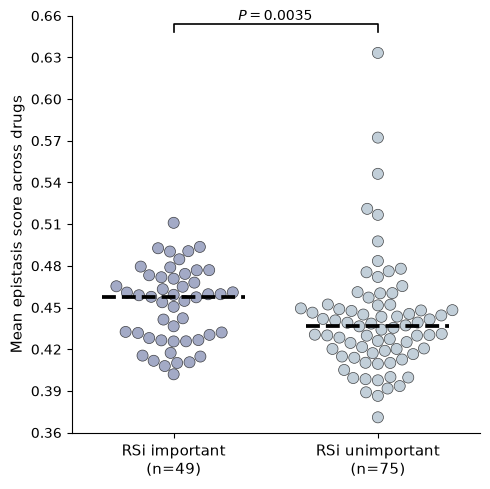

RSi important: n=49, median=0.4577, mean=0.4516
RSi unimportant: n=75, median=0.4365, mean=0.4410
Mann–Whitney U (greater) p-value: 3.5353e-03

Top 10 RSi-important systems by epistasis score:
                                             system  epistasis_score  n_drugs                                                                                                                       drugs
                               Apoptosis Regulation         0.510935       12 5-FU,Bleomycin-a2,CD437,Camptothecin,Ceralasertib,Cisplatin,Doxorubicin,Etoposide,Gemcitabine,MK-1775,Methotrexate,Olaparib
                                                Fas         0.493605       12 5-FU,Bleomycin-a2,CD437,Camptothecin,Ceralasertib,Cisplatin,Doxorubicin,Etoposide,Gemcitabine,MK-1775,Methotrexate,Olaparib
                mTOR regulation of mRNA translation         0.492649       12 5-FU,Bleomycin-a2,CD437,Camptothecin,Ceralasertib,Cisplatin,Doxorubicin,Etoposide,Gemcitabine,MK-1775,Methotrexate,Olaparib

In [37]:
out = swarm_epistasis_scores_rsi_important_vs_unimportant(
    epistasis_csv="system_epistasis_scores_stringent.csv",
    rsi_important_systems=rsi_important_systems,
    epistasis_score_col="epistasis_score_mean_neglog10p",
    aggregate="mean",
    y_max=0.66,
    y_min=0.36,
    y_tick_step=0.03,
    out_svg="rsi_important_vs_unimportant_mean_epistasis_swarm.svg"
)

### b. Mean Importance Score vs Mean Epistasis (Fig. 6c)

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _rankdata_average(x):
    """Simple scipy-free average-rank implementation."""
    x = np.asarray(x)

    order = np.argsort(x)
    ranks = np.empty(len(x), dtype=float)
    sorted_x = x[order]

    i = 0
    while i < len(x):
        j = i
        while j + 1 < len(x) and sorted_x[j + 1] == sorted_x[i]:
            j += 1

        avg_rank = (i + j) / 2.0 + 1.0
        ranks[order[i:j + 1]] = avg_rank
        i = j + 1

    return ranks


def _pearson_corr(x, y):
    return np.corrcoef(x, y)[0, 1]


def _spearman_corr(x, y):
    rx = _rankdata_average(x)
    ry = _rankdata_average(y)
    return np.corrcoef(rx, ry)[0, 1]


def _correlation(x, y, method="spearman"):
    method = str(method).lower().strip()

    if method == "spearman":
        return _spearman_corr(x, y)

    if method == "pearson":
        return _pearson_corr(x, y)

    raise ValueError("correlation_method must be 'spearman' or 'pearson'.")


def _permutation_corr_pvalue(x, y, method="spearman", n_perm=10000, seed=0):
    """
    Permutation p-value for Pearson or Spearman correlation.
    Two-sided.
    """
    rng = np.random.default_rng(seed)

    observed = _correlation(x, y, method=method)

    null = np.empty(n_perm)

    for i in range(n_perm):
        null[i] = _correlation(x, rng.permutation(y), method=method)

    p = (1 + np.sum(np.abs(null) >= abs(observed))) / (1 + n_perm)

    return observed, p


def _winsorize_array(x, q_low=0.05, q_high=0.95):
    lo, hi = np.nanquantile(x, [q_low, q_high])
    return np.clip(x, lo, hi)


def _mad_outlier_mask(x, y, z_cutoff=3.5):
    """
    Robust outlier mask based on MAD-scaled distance in both x and y.
    Returns True for points to keep.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    def robust_z(v):
        med = np.nanmedian(v)
        mad = np.nanmedian(np.abs(v - med))
        if mad == 0 or not np.isfinite(mad):
            return np.zeros_like(v, dtype=float)
        return 0.6745 * (v - med) / mad

    zx = robust_z(x)
    zy = robust_z(y)

    keep = (np.abs(zx) <= z_cutoff) & (np.abs(zy) <= z_cutoff)
    return keep


def _fit_ols_line(x, y, x_grid):
    coef = np.polyfit(x, y, 1)
    y_fit = np.poly1d(coef)(x_grid)
    return y_fit, coef


def _fit_theilsen_line(x, y, x_grid):
    """
    SciPy-free Theil–Sen fit:
      slope = median of pairwise slopes
      intercept = median(y - slope*x)
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    slopes = []

    n = len(x)
    for i in range(n):
        dx = x[i + 1:] - x[i]
        dy = y[i + 1:] - y[i]

        valid = dx != 0
        if np.any(valid):
            slopes.extend((dy[valid] / dx[valid]).tolist())

    if len(slopes) == 0:
        slope = 0.0
    else:
        slope = float(np.nanmedian(slopes))

    intercept = float(np.nanmedian(y - slope * x))
    y_fit = intercept + slope * x_grid

    return y_fit, np.array([slope, intercept])


def plot_epistasis_vs_abs_importance(
    epistasis_csv,
    epistasis_score_col="epistasis_score_mean_neglog10p",
    importance_col="drpt_importance_score",
    crispr_fdr_col="crispr_best_fdr",
    system_col="system",
    drug_col="drug",

    # Optional restriction
    rsi_important_systems=None,

    # Independent aggregation control
    epistasis_aggregate="mean",   # "mean" or "max"
    importance_aggregate="mean",  # "mean" or "max"

    # Correlation test
    correlation_method="spearman",  # "spearman" or "pearson"

    # Robust outlier handling
    outlier_mode="none",            # "none", "winsorize", or "mad_filter"
    winsor_quantiles=(0.05, 0.95),
    mad_z_cutoff=3.5,
    fit_method="theilsen",          # "ols" or "theilsen"
    show_excluded_points=True,
    excluded_color="#D9D9D9",

    # Optional CRISPR coloring
    color_crispr=True,
    crispr_fdr_cutoff=0.1,

    figsize=(6.2, 5.6),
    point_size=45,
    point_alpha=0.85,

    # Colors
    middle_grey="#8E8E8E",
    crispr_sig_color="#d62728",
    ci_color="#BFD7EA",

    # Axis controls
    x_min=None,
    x_max=None,
    y_min=None,
    y_max=None,
    x_tick_step=None,
    y_tick_step=None,

    # Bootstrap / permutation
    n_boot_ci=2000,
    n_perm_p=10000,
    random_state=0,

    xlabel=None,
    ylabel=None,
    title=None,

    out_svg=None,
    show=True,
):
    """
    Correlate system-level epistasis score against absolute DRPT importance.

    Robust options:
      outlier_mode="none":
          use raw x/y values.

      outlier_mode="winsorize":
          clip x/y values to winsor_quantiles before correlation and fitting.
          All points remain plotted at original coordinates.

      outlier_mode="mad_filter":
          exclude strong x/y MAD outliers from correlation and fitting.
          All points remain plotted unless show_excluded_points=False.

      fit_method="ols":
          ordinary least-squares line.

      fit_method="theilsen":
          robust Theil–Sen line.
    """

    if epistasis_aggregate not in {"mean", "max"}:
        raise ValueError("epistasis_aggregate must be 'mean' or 'max'.")

    if importance_aggregate not in {"mean", "max"}:
        raise ValueError("importance_aggregate must be 'mean' or 'max'.")

    correlation_method = str(correlation_method).lower().strip()
    if correlation_method not in {"spearman", "pearson"}:
        raise ValueError("correlation_method must be 'spearman' or 'pearson'.")

    outlier_mode = str(outlier_mode).lower().strip()
    if outlier_mode not in {"none", "winsorize", "mad_filter"}:
        raise ValueError("outlier_mode must be 'none', 'winsorize', or 'mad_filter'.")

    fit_method = str(fit_method).lower().strip()
    if fit_method not in {"ols", "theilsen"}:
        raise ValueError("fit_method must be 'ols' or 'theilsen'.")

    df = pd.read_csv(epistasis_csv).copy()

    required = [
        epistasis_score_col,
        importance_col,
        system_col,
        drug_col,
    ]

    if color_crispr:
        required.append(crispr_fdr_col)

    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    df[epistasis_score_col] = pd.to_numeric(df[epistasis_score_col], errors="coerce")
    df[importance_col] = pd.to_numeric(df[importance_col], errors="coerce")

    if color_crispr:
        df[crispr_fdr_col] = pd.to_numeric(df[crispr_fdr_col], errors="coerce")

    df[system_col] = df[system_col].astype(str)
    df[drug_col] = df[drug_col].astype(str)

    if rsi_important_systems is not None:
        rsi_important_systems = set(map(str, rsi_important_systems))
        df = df[df[system_col].isin(rsi_important_systems)].copy()

        if df.empty:
            raise ValueError(
                "After filtering to rsi_important_systems, no rows remain. "
                "Check that system names match the CSV."
            )

    subset_cols = [
        epistasis_score_col,
        importance_col,
        system_col,
        drug_col,
    ]

    if color_crispr:
        subset_cols.append(crispr_fdr_col)

    df = df.dropna(subset=subset_cols)

    df["abs_importance"] = np.abs(df[importance_col].values)

    agg_dict = {
        "epistasis_score": (epistasis_score_col, epistasis_aggregate),
        "abs_importance": ("abs_importance", importance_aggregate),
        "n_drugs": (drug_col, "nunique"),
    }

    if color_crispr:
        agg_dict["min_crispr_fdr"] = (crispr_fdr_col, "min")

    system_df = (
        df.groupby(system_col, as_index=False)
        .agg(**agg_dict)
    )

    if system_df.shape[0] < 3:
        raise ValueError(
            f"Need at least 3 systems for correlation; got {system_df.shape[0]}."
        )

    if color_crispr:
        system_df["crispr_significant"] = (
            system_df["min_crispr_fdr"] < crispr_fdr_cutoff
        )
    else:
        system_df["crispr_significant"] = False

    x_raw = system_df["abs_importance"].values.astype(float)
    y_raw = system_df["epistasis_score"].values.astype(float)

    # -------------------------------------------------
    # Robust values for correlation/fitting
    # -------------------------------------------------
    keep_mask = np.ones(len(x_raw), dtype=bool)

    if outlier_mode == "none":
        x_corr = x_raw.copy()
        y_corr = y_raw.copy()

    elif outlier_mode == "winsorize":
        q_low, q_high = winsor_quantiles
        x_corr = _winsorize_array(x_raw, q_low=q_low, q_high=q_high)
        y_corr = _winsorize_array(y_raw, q_low=q_low, q_high=q_high)

    elif outlier_mode == "mad_filter":
        keep_mask = _mad_outlier_mask(
            x_raw,
            y_raw,
            z_cutoff=mad_z_cutoff
        )
        x_corr = x_raw[keep_mask]
        y_corr = y_raw[keep_mask]

        if len(x_corr) < 3:
            raise ValueError(
                f"MAD filtering left fewer than 3 points: n={len(x_corr)}."
            )

    # -------------------------------------------------
    # Correlation + permutation p-value
    # -------------------------------------------------
    corr, pval = _permutation_corr_pvalue(
        x_corr,
        y_corr,
        method=correlation_method,
        n_perm=n_perm_p,
        seed=random_state
    )

    # -------------------------------------------------
    # Axis limits
    # -------------------------------------------------
    x_min_use = float(np.nanmin(x_raw)) if x_min is None else float(x_min)
    x_max_use = float(np.nanmax(x_raw)) if x_max is None else float(x_max)
    y_min_use = float(np.nanmin(y_raw)) if y_min is None else float(y_min)
    y_max_use = float(np.nanmax(y_raw)) if y_max is None else float(y_max)

    if x_max_use <= x_min_use:
        raise ValueError("x_max must be greater than x_min.")

    if y_max_use <= y_min_use:
        raise ValueError("y_max must be greater than y_min.")

    x_grid = np.linspace(x_min_use, x_max_use, 200)

    # -------------------------------------------------
    # Fit line using robust-adjusted values
    # -------------------------------------------------
    if fit_method == "ols":
        y_fit, fit_params = _fit_ols_line(x_corr, y_corr, x_grid)
    else:
        y_fit, fit_params = _fit_theilsen_line(x_corr, y_corr, x_grid)

    # -------------------------------------------------
    # Bootstrap confidence interval for selected fit method
    # -------------------------------------------------
    rng = np.random.default_rng(random_state)
    boot_fits = np.empty((n_boot_ci, len(x_grid)))

    n = len(x_corr)

    for b in range(n_boot_ci):
        idx = rng.choice(n, size=n, replace=True)

        xb = x_corr[idx]
        yb = y_corr[idx]

        try:
            if fit_method == "ols":
                boot_fits[b], _ = _fit_ols_line(xb, yb, x_grid)
            else:
                boot_fits[b], _ = _fit_theilsen_line(xb, yb, x_grid)
        except Exception:
            boot_fits[b] = np.nan

    ci_low = np.nanpercentile(boot_fits, 2.5, axis=0)
    ci_high = np.nanpercentile(boot_fits, 97.5, axis=0)

    # -------------------------------------------------
    # Plot
    # -------------------------------------------------
    fig, ax = plt.subplots(figsize=figsize)

    if outlier_mode == "mad_filter" and show_excluded_points:
        excluded = ~keep_mask
        if np.any(excluded):
            ax.scatter(
                x_raw[excluded],
                y_raw[excluded],
                s=point_size,
                alpha=0.55,
                color=excluded_color,
                edgecolor="black",
                linewidth=0.4,
                label=f"MAD-filtered outliers (n={excluded.sum()})"
            )

    if color_crispr:
        mask_sig = system_df["crispr_significant"].values
        mask_non = ~mask_sig

        if outlier_mode == "mad_filter" and not show_excluded_points:
            mask_sig = mask_sig & keep_mask
            mask_non = mask_non & keep_mask

        ax.scatter(
            x_raw[mask_non],
            y_raw[mask_non],
            s=point_size,
            alpha=point_alpha,
            color=middle_grey,
            edgecolor="black",
            linewidth=0.4,
            label=f"CRISPR FDR ≥ {crispr_fdr_cutoff} (n={mask_non.sum()})"
        )

        ax.scatter(
            x_raw[mask_sig],
            y_raw[mask_sig],
            s=point_size,
            alpha=point_alpha,
            color=crispr_sig_color,
            edgecolor="black",
            linewidth=0.4,
            label=f"CRISPR FDR < {crispr_fdr_cutoff} (n={mask_sig.sum()})"
        )

    else:
        plot_mask = np.ones(len(x_raw), dtype=bool)
        if outlier_mode == "mad_filter" and not show_excluded_points:
            plot_mask = keep_mask

        ax.scatter(
            x_raw[plot_mask],
            y_raw[plot_mask],
            s=point_size,
            alpha=point_alpha,
            color=middle_grey,
            edgecolor="black",
            linewidth=0.4,
            label=f"Systems (n={plot_mask.sum()})"
        )

    ax.fill_between(
        x_grid,
        ci_low,
        ci_high,
        color=ci_color,
        alpha=0.45,
        linewidth=0,
        zorder=1
    )

    ax.plot(
        x_grid,
        y_fit,
        color="black",
        linestyle="--",
        linewidth=2.2,
        label=f"{fit_method} fit",
        zorder=2
    )

    if xlabel is None:
        xlabel = (
            f"{importance_aggregate.capitalize()} absolute DRPT importance "
            f"across drugs"
        )

    if ylabel is None:
        ylabel = (
            f"{epistasis_aggregate.capitalize()} epistasis score "
            f"across drugs"
        )

    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)

    corr_symbol = "ρ" if correlation_method == "spearman" else "r"
    corr_name = "Spearman" if correlation_method == "spearman" else "Pearson"

    if title is None:
        title = (
            f"{corr_name} {corr_symbol} = {corr:.3f}, "
            f"permutation p = {pval:.2e}"
        )

    ax.set_title(title, fontsize=12)

    ax.set_xlim(x_min_use, x_max_use)
    ax.set_ylim(y_min_use, y_max_use)

    if x_tick_step is not None:
        ax.set_xticks(
            np.arange(
                x_min_use,
                x_max_use + 1e-12,
                float(x_tick_step)
            )
        )

    if y_tick_step is not None:
        ax.set_yticks(
            np.arange(
                y_min_use,
                y_max_use + 1e-12,
                float(y_tick_step)
            )
        )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(frameon=False, fontsize=9)

    plt.tight_layout()

    if out_svg is not None:
        plt.rcParams["svg.fonttype"] = "none"
        fig.savefig(out_svg, format="svg", bbox_inches="tight")
        print(f"Saved SVG to: {out_svg}")

    if show:
        plt.show()

    system_df["used_for_correlation"] = keep_mask

    print(f"Systems plotted: {system_df.shape[0]}")
    print(f"Systems used for correlation/fit: {int(keep_mask.sum())}")
    print(f"Outlier mode: {outlier_mode}")
    print(f"Fit method: {fit_method}")

    if rsi_important_systems is not None:
        print("Restricted to provided RSi-important systems.")

    if color_crispr:
        print(f"CRISPR significant systems: {system_df['crispr_significant'].sum()}")

    print(f"{corr_name} correlation: {corr:.4f}")
    print(f"Permutation p-value: {pval:.4e}")

    return {
        "system_df": system_df,
        "correlation_method": correlation_method,
        "correlation": corr,
        "pvalue": pval,
        "outlier_mode": outlier_mode,
        "fit_method": fit_method,
        "fit_params": fit_params,
        "figure": fig,
        "axis": ax,
    }

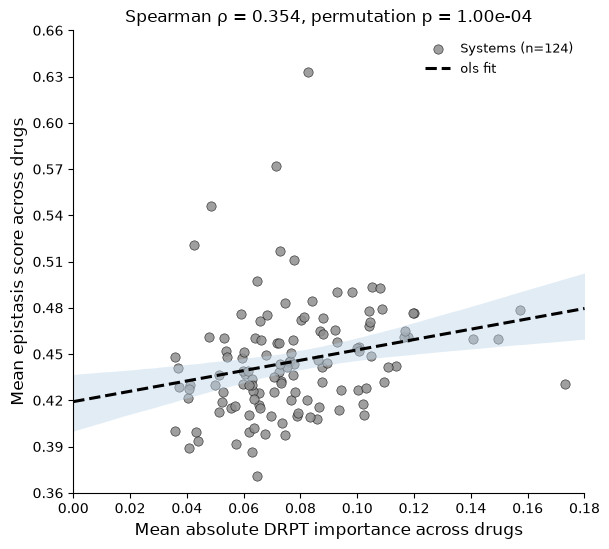

Systems plotted: 124
Systems used for correlation/fit: 124
Outlier mode: none
Fit method: ols
Spearman correlation: 0.3537
Permutation p-value: 9.9990e-05


In [39]:
out = plot_epistasis_vs_abs_importance(
    epistasis_csv="system_epistasis_scores_stringent.csv",
    #rsi_important_systems=rsi_important_systems,
    epistasis_score_col="epistasis_score_mean_neglog10p",
    epistasis_aggregate="mean",
    importance_aggregate="mean",
    correlation_method="spearman",
    outlier_mode="none",
    fit_method="ols",
    color_crispr=False,
    x_min=0.0,
    x_max=0.18,
    x_tick_step=0.02,
    y_min=0.36,
    y_max=0.66,
    y_tick_step=0.03,
    #out_svg="robust_epistasis_vs_importance.svg"
)

### c. Water Fall Plot of Important Systems with High Epistasis Scores (Fig. 6d)

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


def _pretty_alt_label(x):
    """
    Convert labels like AR_del or RBL1_amp into AR del / RBL1 amp.
    """
    x = str(x)
    if "_" in x:
        gene, alt = x.rsplit("_", 1)
        return f"{gene} {alt}"
    return x


def plot_top_rsi_important_system_drug_epistasis_bubbles(
    epistasis_csv,
    importance_df_semi,
    rsi_important_systems,
    name_to_new_name=None,
    epistasis_score_col="epistasis_score_max_neglog10p",
    size_col="n_system_genes",
    alteration1_col="max_neglog10p_alteration_1",
    alteration2_col="max_neglog10p_alteration_2",
    importance_p_col="p_bonferroni_pearson",
    system_col="system",
    drug_col="drug",
    importance_p_cutoff=1e-4,
    top_n=20,
    figsize=(10, 5),
    cmap="Reds",
    edgecolor="black",
    min_marker_size=80,
    max_marker_size=700,
    y_min=None,
    y_max=None,
    y_tick_step=1.0,
    colorbar_vmin=4,
    colorbar_vmax=14,
    colorbar_label=r"DRPT importance, $-\log_{10}(P)$",
    colorbar_width="88%",
    colorbar_height="8%",
    colorbar_bbox=(0.06, 1.075, 0.88, 0.12),
    size_legend_anchor=(1.02, 0.82),
    size_legend_labelspacing=1.6,
    size_legend_color="white",

    # NEW: epistasis-pair label controls
    show_pair_labels=True,
    pair_label_rotation=60,
    pair_label_fontsize=8,
    pair_label_y_offset=0.04,
    pair_label_x_offset=0.02,

    ylabel=None,
    title=None,
    rotation=65,
    out_svg=None,
    show=True,
):
    rsi_important_systems = set(map(str, rsi_important_systems))

    epi_df = pd.read_csv(epistasis_csv).copy()
    imp_df = importance_df_semi.copy()

    required_epi = {
        system_col, drug_col, epistasis_score_col, size_col,
        alteration1_col, alteration2_col
    }
    required_imp = {system_col, drug_col, importance_p_col}

    missing_epi = required_epi - set(epi_df.columns)
    missing_imp = required_imp - set(imp_df.columns)

    if missing_epi:
        raise ValueError(f"Epistasis CSV missing required columns: {missing_epi}")
    if missing_imp:
        raise ValueError(f"importance_df_semi missing required columns: {missing_imp}")

    epi_df[system_col] = epi_df[system_col].astype(str)
    epi_df[drug_col] = epi_df[drug_col].astype(str)
    epi_df[epistasis_score_col] = pd.to_numeric(epi_df[epistasis_score_col], errors="coerce")
    epi_df[size_col] = pd.to_numeric(epi_df[size_col], errors="coerce")

    imp_df[system_col] = imp_df[system_col].astype(str)
    imp_df[drug_col] = imp_df[drug_col].astype(str)
    imp_df[importance_p_col] = pd.to_numeric(imp_df[importance_p_col], errors="coerce")

    epi_df = epi_df.dropna(subset=[system_col, drug_col, epistasis_score_col, size_col])
    imp_df = imp_df.dropna(subset=[system_col, drug_col, importance_p_col])

    epi_df = epi_df[epi_df[system_col].isin(rsi_important_systems)].copy()

    imp_sig = imp_df[
        imp_df[importance_p_col] < importance_p_cutoff
    ][[system_col, drug_col, importance_p_col]].copy()

    merged = pd.merge(
        epi_df,
        imp_sig,
        on=[system_col, drug_col],
        how="inner"
    )

    if merged.empty:
        raise ValueError("No RSi-important system-drug pairs passed the importance p-value filter.")

    merged["importance_neglog10p"] = -np.log10(
        merged[importance_p_col].clip(lower=np.nextafter(0, 1))
    )

    merged["importance_neglog10p_capped"] = merged["importance_neglog10p"].clip(
        lower=colorbar_vmin,
        upper=colorbar_vmax
    )

    if name_to_new_name is not None:
        required_name_cols = {"Current Name", "New Name"}
        missing_name_cols = required_name_cols - set(name_to_new_name.columns)
        if missing_name_cols:
            raise ValueError(f"name_to_new_name missing columns: {missing_name_cols}")

        name_map = dict(
            zip(
                name_to_new_name["Current Name"].astype(str),
                name_to_new_name["New Name"].astype(str)
            )
        )
        merged["display_system"] = merged[system_col].map(name_map).fillna(merged[system_col])
    else:
        merged["display_system"] = merged[system_col]

    plot_df = (
        merged
        .sort_values(epistasis_score_col, ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )

    plot_df["label"] = (
        plot_df["display_system"].astype(str)
        + " ("
        + plot_df[drug_col].astype(str)
        + ")"
    )

    plot_df["alteration_pair"] = (
        plot_df[alteration1_col].apply(_pretty_alt_label)
        + " x "
        + plot_df[alteration2_col].apply(_pretty_alt_label)
    )

    sizes_raw = plot_df[size_col].to_numpy(dtype=float)

    def scale_sizes(vals):
        vals = np.asarray(vals, dtype=float)
        vals = np.clip(vals, 5, 100)
        return min_marker_size + ((vals - 5) / 95) * (max_marker_size - min_marker_size)

    marker_sizes = scale_sizes(sizes_raw)
    norm = Normalize(vmin=colorbar_vmin, vmax=colorbar_vmax)

    fig, ax = plt.subplots(figsize=figsize)

    x = np.arange(plot_df.shape[0])
    y = plot_df[epistasis_score_col].to_numpy(dtype=float)

    scatter = ax.scatter(
        x,
        y,
        s=marker_sizes,
        c=plot_df["importance_neglog10p_capped"].to_numpy(dtype=float),
        cmap=cmap,
        norm=norm,
        edgecolor=edgecolor,
        linewidth=0.8,
        alpha=0.9
    )

    # -----------------------------------
    # NEW: labels above each bubble
    # -----------------------------------
    if show_pair_labels:
        y_span_for_labels = (
            (y_max - y_min)
            if (y_min is not None and y_max is not None)
            else (np.nanmax(y) - np.nanmin(y))
        )

        if y_span_for_labels <= 0 or not np.isfinite(y_span_for_labels):
            y_span_for_labels = 1.0

        for xi, yi, label in zip(x, y, plot_df["alteration_pair"].values):
            ax.text(
                xi + pair_label_x_offset,
                yi + pair_label_y_offset * y_span_for_labels,
                label,
                rotation=pair_label_rotation,
                ha="left",
                va="bottom",
                fontsize=pair_label_fontsize,
                color="black",
                clip_on=False
            )

    ax.set_xticks(x)
    ax.set_xticklabels(
        plot_df["label"].values,
        rotation=rotation,
        ha="right",
        fontsize=9
    )

    if ylabel is None:
        ylabel = r"Max epistasis score, $-\log_{10}(P)$"
    ax.set_ylabel(ylabel, fontsize=12)

    if title is None:
        title = "Top epistasis scores among important RSi system–drug pairs"

    ax.set_title(title, fontsize=12, pad=52)

    # -----------------------------
    # Colorbar
    # -----------------------------
    cax = inset_axes(
        ax,
        width=colorbar_width,
        height=colorbar_height,
        loc="upper center",
        bbox_to_anchor=colorbar_bbox,
        bbox_transform=ax.transAxes,
        borderpad=0
    )

    cbar = fig.colorbar(scatter, cax=cax, orientation="horizontal")
    cbar.set_label(colorbar_label, fontsize=10, labelpad=1)
    cbar.ax.tick_params(labelsize=8, length=2)
    cbar.set_ticks([4, 6, 8, 10, 12, 14])

    if y_min is not None or y_max is not None:
        current_min, current_max = ax.get_ylim()
        if y_min is None:
            y_min = current_min
        if y_max is None:
            y_max = current_max
        ax.set_ylim(y_min, y_max)

    ymin_final, ymax_final = ax.get_ylim()
    if y_tick_step is not None:
        ax.set_yticks(np.arange(ymin_final, ymax_final + 1e-12, y_tick_step))

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # -----------------------------
    # System-size legend
    # -----------------------------
    legend_sizes = np.array([5, 20, 50, 100], dtype=float)
    legend_marker_sizes = scale_sizes(legend_sizes)

    legend_handles = [
        plt.scatter(
            [],
            [],
            s=ms,
            facecolors=size_legend_color,
            edgecolors=edgecolor,
            linewidth=0.8,
            alpha=1.0,
            label=f"{int(val)} genes"
        )
        for val, ms in zip(legend_sizes, legend_marker_sizes)
    ]

    ax.legend(
        handles=legend_handles,
        title="System size",
        frameon=False,
        loc="upper left",
        bbox_to_anchor=size_legend_anchor,
        fontsize=9,
        title_fontsize=10,
        labelspacing=size_legend_labelspacing,
        handletextpad=1.2,
        borderaxespad=0.0
    )

    plt.tight_layout(rect=[0, 0, 1, 0.92])

    if out_svg is not None:
        plt.rcParams["svg.fonttype"] = "none"
        fig.savefig(out_svg, format="svg", bbox_inches="tight")
        print(f"Saved SVG to: {out_svg}")

    if show:
        plt.show()

    alteration_pair_table = plot_df[
        [
            "label",
            system_col,
            "display_system",
            drug_col,
            epistasis_score_col,
            size_col,
            importance_p_col,
            "importance_neglog10p",
            alteration1_col,
            alteration2_col,
            "alteration_pair",
        ]
    ].copy()

    print("\nAlteration pairs in plot order:")
    for i, row in alteration_pair_table.iterrows():
        print(
            f"{i + 1}. {row['label']}: "
            f"{row['alteration_pair']} "
            f"({epistasis_score_col} = {row[epistasis_score_col]:.4f}; "
            f"{size_col} = {int(row[size_col])}; "
            f"-log10 importance P = {row['importance_neglog10p']:.2f})"
        )

    return {
        "plot_df": plot_df,
        "merged_df": merged,
        "alteration_pair_table": alteration_pair_table,
        "figure": fig,
        "axis": ax,
    }

/var/folders/xn/6msch0w517d5fc96lf16x1wc0000gp/T/ipykernel_2856/1656218079.py:292: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.92])


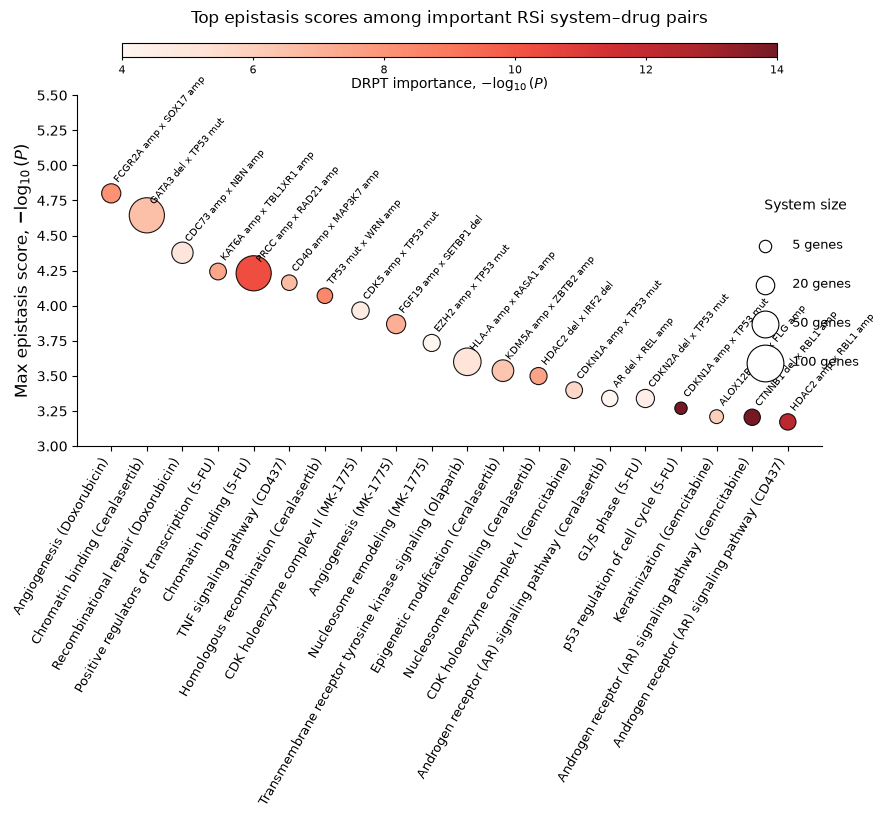


Alteration pairs in plot order:
1. Angiogenesis (Doxorubicin): FCGR2A amp x SOX17 amp (epistasis_score_max_neglog10p = 4.8006; n_system_genes = 22; -log10 importance P = 8.15)
2. Chromatin binding (Ceralasertib): GATA3 del x TP53 mut (epistasis_score_max_neglog10p = 4.6444; n_system_genes = 91; -log10 importance P = 6.60)
3. Recombinational repair (Doxorubicin): CDC73 amp x NBN amp (epistasis_score_max_neglog10p = 4.3775; n_system_genes = 29; -log10 importance P = 5.07)
4. Positive regulators of transcription (5-FU): KAT6A amp x TBL1XR1 amp (epistasis_score_max_neglog10p = 4.2438; n_system_genes = 15; -log10 importance P = 7.40)
5. Chromatin binding (5-FU): PRCC amp x RAD21 amp (epistasis_score_max_neglog10p = 4.2312; n_system_genes = 91; -log10 importance P = 10.31)
6. TNF signaling pathway (CD437): CD40 amp x MAP3K7 amp (epistasis_score_max_neglog10p = 4.1643; n_system_genes = 12; -log10 importance P = 6.73)
7. Homologous recombination (Ceralasertib): TP53 mut x WRN amp (epistasis_s

In [41]:
out = plot_top_rsi_important_system_drug_epistasis_bubbles(
    epistasis_csv="system_epistasis_scores_stringent.csv",
    importance_df_semi=importance_df_semi,
    rsi_important_systems=rsi_important_systems,
    name_to_new_name=name_to_new_name,
    y_min=3,
    y_max=5.5,
    y_tick_step=0.25,

    # thicker colorbar
    colorbar_width="100%",
    colorbar_height="35%",          # increase this to make colorbar thicker
    colorbar_bbox=(0.06, 1.03, 0.88, 0.12),

    # move system-size legend down / closer to plot
    size_legend_anchor=(0.9, 0.72),
    size_legend_labelspacing=2.0,
    figsize=(9,9),

    show_pair_labels=True,
    pair_label_rotation=50,
    pair_label_fontsize=7,
    pair_label_y_offset=0.025,
    pair_label_x_offset=0.03,

    rotation=60,

    #out_svg="top_rsi_important_system_drug_epistasis_bubbles.svg"
)

### d. FCGR2A amp + SOX17 amp epistatic interction for doxorubicin resistance (Fig. e)

In [42]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu


def load_binary_matrix(path, cell_lines, gene_names):
    """
    Load 0/1 alteration matrix; rows correspond to cell lines, columns to gene names.
    """
    df = pd.read_csv(path, sep=",", header=None, dtype=int)
    df.index = cell_lines
    df.columns = gene_names
    return df


def plot_violin_auc_only(
    drug,
    gene1,
    alt1,           # 'amp', 'del', or 'mut'
    gene2,
    alt2,           # 'amp', 'del', or 'mut'
    results,
    amp_file="data/cell2cnamplification_ctg_av.txt",
    del_file="data/cell2cndeletion_ctg_av.txt",
    mut_file="data/cell2mutation_ctg_av.txt",
    cell_index_file="data/cell2ind_av.txt",
    gene_index_file="data/gene2ind_ctg_av.txt",
    alpha=0.05,                 # significance threshold for drawing brackets
    group_spacing=1.25,
    violin_width=0.5,
    box_width=0.15,
    sig_level_step_frac=0.045,
    sig_tick_frac=0.020,
    sig_text_pad_frac=0.006,
    sig_top_margin_frac=0.18,   # slightly more room for brackets + tracing lines
    out_svg=None,
    response_type="predicted",  # "predicted" or "actual"
    observed_line_color="black",
    expected_line_color="#d62728",
    observed_marker="o",
    expected_marker="D",
    trace_linewidth=2.0,
    trace_markersize=7,
    show_expected_observed_lines=True,
):
    # ------------------------------------------------------------------
    # Helpers
    # ------------------------------------------------------------------
    def _p_to_stars(p):
        if pd.isna(p):
            return "NA"
        if p < 1e-8:
            return "*****"
        if p < 1e-5:
            return "****"
        if p < 1e-3:
            return "***"
        if p < 1e-2:
            return "**"
        if p < 0.05:
            return "*"
        return "ns"

    def _draw_bracket(ax, x1, x2, y, label, tick, lw=1.5, fs=10, label_pad=0.0):
        ax.plot(
            [x1, x1, x2, x2],
            [y, y + tick, y + tick, y],
            lw=lw, c="black", solid_capstyle="butt", clip_on=False
        )
        ax.text(
            (x1 + x2) / 2,
            y + tick + label_pad,
            label,
            ha="center",
            va="bottom",
            fontsize=fs,
            color="black",
            clip_on=False
        )

    # ------------------------------------------------------------------
    # 1) Load mappings
    # ------------------------------------------------------------------
    cell_df = pd.read_csv(cell_index_file, sep="\t", header=None, names=["Index", "CellLine"])
    gene_df = pd.read_csv(gene_index_file, sep="\t", header=None, names=["Index", "Gene"])
    cell_lines = list(cell_df["CellLine"])
    genes = list(gene_df["Gene"])

    if gene1 not in genes or gene2 not in genes:
        raise ValueError(f"Gene not in index: {gene1}, {gene2}")

    # ------------------------------------------------------------------
    # 2) Load alteration matrices
    # ------------------------------------------------------------------
    amp_df = load_binary_matrix(amp_file, cell_lines, genes)
    del_df = load_binary_matrix(del_file, cell_lines, genes)
    mut_df = load_binary_matrix(mut_file, cell_lines, genes)

    # ------------------------------------------------------------------
    # 3) Helper to extract status
    # ------------------------------------------------------------------
    def get_status(gene, alt):
        alt = str(alt).lower().strip()
        if alt == "amp":
            return amp_df[gene].astype(int)
        if alt == "del":
            return del_df[gene].astype(int)
        if alt == "mut":
            return mut_df[gene].astype(int)
        raise ValueError("alt must be 'amp', 'del', or 'mut'")

    status1 = get_status(gene1, alt1)
    status2 = get_status(gene2, alt2)

    # ------------------------------------------------------------------
    # 4) Pull out AUC values
    # ------------------------------------------------------------------
    celllist = results[drug]["celllines"]

    if response_type == "predicted":
        aucs = np.array(results[drug]["predictions"], dtype=float)
    elif response_type == "actual":
        aucs = np.array(results[drug]["actual"], dtype=float)
    else:
        raise ValueError("response_type must be 'predicted' or 'actual'")

    auc_series = pd.Series(aucs, index=celllist)

    # ------------------------------------------------------------------
    # 5) Intersection of cell lines
    # ------------------------------------------------------------------
    common = sorted(set(celllist) & set(status1.index) & set(status2.index))
    if not common:
        raise ValueError("No overlapping cell lines")

    status1 = status1.loc[common]
    status2 = status2.loc[common]
    auc_series = auc_series.loc[common]

    # ------------------------------------------------------------------
    # 6) Define strict WT for each gene
    # ------------------------------------------------------------------
    wt1 = (
        (amp_df.loc[common, gene1] == 0) &
        (del_df.loc[common, gene1] == 0) &
        (mut_df.loc[common, gene1] == 0)
    )
    wt2 = (
        (amp_df.loc[common, gene2] == 0) &
        (del_df.loc[common, gene2] == 0) &
        (mut_df.loc[common, gene2] == 0)
    )

    alt1_m = status1 == 1
    alt2_m = status2 == 1

    # ------------------------------------------------------------------
    # 7) Build strict four-group masks in fixed order
    # ------------------------------------------------------------------
    group_order = ["WT_WT", f"{alt1}_WT", f"WT_{alt2}", f"{alt1}_{alt2}"]

    group_masks = {
        "WT_WT":          wt1 & wt2,
        f"{alt1}_WT":     alt1_m & wt2,
        f"WT_{alt2}":     wt1 & alt2_m,
        f"{alt1}_{alt2}": alt1_m & alt2_m,
    }

    # require all four groups for additive expectation
    for g in group_order:
        if group_masks[g].sum() == 0:
            raise ValueError(f"Group '{g}' has 0 cells; cannot draw additive expectation cleanly.")

    group_labels = group_order
    colors = ["#bdbdbd", "#5DA5DA", "#F15854", "#B276B2"]

    # ------------------------------------------------------------------
    # 8) Collect group AUCs & pairwise tests
    # ------------------------------------------------------------------
    group_values = {lbl: auc_series[group_masks[lbl]].values for lbl in group_labels}

    pairwise = []
    for i in range(len(group_labels)):
        for j in range(i + 1, len(group_labels)):
            g1, g2 = group_labels[i], group_labels[j]
            v1, v2 = group_values[g1], group_values[g2]
            if len(v1) == 0 or len(v2) == 0:
                stat, p = np.nan, np.nan
            else:
                stat, p = mannwhitneyu(v1, v2, alternative="two-sided")
            pairwise.append({
                "i": i,
                "j": j,
                "G1": g1,
                "G2": g2,
                "U": stat,
                "p": p,
                "p_str": _p_to_stars(p)
            })
    pairwise_df = pd.DataFrame(pairwise)

    # ------------------------------------------------------------------
    # 9) Group means + additive expectation
    # ------------------------------------------------------------------
    means = {lbl: float(np.mean(group_values[lbl])) for lbl in group_labels}

    mean00 = means["WT_WT"]
    mean10 = means[f"{alt1}_WT"]
    mean01 = means[f"WT_{alt2}"]
    mean11 = means[f"{alt1}_{alt2}"]

    expected_double = mean10 + mean01 - mean00

    observed_trace = [mean00, mean10, mean01, mean11]
    expected_trace = [mean00, mean10, mean01, expected_double]

    # ------------------------------------------------------------------
    # 10) Plot violin + box
    # ------------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(6, 6))

    positions = np.arange(len(group_labels)) * float(group_spacing)
    data = [group_values[l] for l in group_labels]

    # draw violins
    vp = ax.violinplot(
        data,
        positions=positions,
        widths=float(violin_width),
        showmeans=False,
        showmedians=False,
        showextrema=False
    )
    for i, body in enumerate(vp["bodies"]):
        body.set_facecolor(colors[i])
        body.set_edgecolor("black")
        body.set_alpha(0.7)

    # draw boxes
    ax.boxplot(
        data,
        positions=positions,
        widths=float(box_width),
        patch_artist=True,
        showfliers=False,
        boxprops=dict(facecolor="black", color="black"),
        medianprops=dict(color="white", linewidth=2),
        whiskerprops=dict(color="black"),
        capprops=dict(color="black")
    )

    # global median line
    med_all = float(np.median(aucs))
    ax.axhline(
        med_all,
        linestyle="--",
        color="red",
        label=f"{drug} AUC median"
    )

    # ------------------------------------------------------------------
    # 11) Add observed and expected tracing lines
    # ------------------------------------------------------------------
    if show_expected_observed_lines:
        ax.plot(
            positions,
            observed_trace,
            color=observed_line_color,
            linewidth=trace_linewidth,
            marker=observed_marker,
            markersize=trace_markersize,
            label="Observed"
        )

        ax.plot(
            positions,
            expected_trace,
            color=expected_line_color,
            linewidth=trace_linewidth,
            linestyle="--",
            marker=expected_marker,
            markersize=trace_markersize,
            label="Expected additive"
        )

    # ------------------------------------------------------------------
    # 12) Labels
    # ------------------------------------------------------------------
    def mk_lbl(lbl):
        a1, a2 = lbl.split("_")
        return f"{gene1} {a1}\n{gene2} {a2}"

    ax.set_xticks(positions)
    ax.set_xticklabels([mk_lbl(l) for l in group_labels], rotation=0, ha="center")

    ax.set_ylabel(f"{drug} AUC (Drug Response)")
    ax.set_title(f"{drug}: {gene1} {alt1} vs {gene2} {alt2}", pad=10, fontsize=10)

    # sample sizes below axis
    ymin, ymax = ax.get_ylim()
    span = ymax - ymin if ymax > ymin else 1.0
    ypad = span * 0.11
    for pos, lbl in zip(positions, group_labels):
        ax.text(
            pos,
            ymin - ypad + 0.01,
            f"n={len(group_values[lbl])}",
            ha="center",
            va="top",
            fontsize=9
        )

    # ------------------------------------------------------------------
    # 13) Significance brackets with star labels
    # ------------------------------------------------------------------
    sig_pairs = [
        r for _, r in pairwise_df.iterrows()
        if pd.notna(r["p"]) and r["p"] < alpha
    ]

    if sig_pairs:
        ymin, ymax = ax.get_ylim()
        span = ymax - ymin if ymax > ymin else 1.0

        extra = span * float(sig_top_margin_frac)
        ax.set_ylim(ymin, ymax + extra)
        ymin, ymax = ax.get_ylim()
        span = ymax - ymin if ymax > ymin else 1.0

        tick = span * float(sig_tick_frac)
        step = span * float(sig_level_step_frac)
        label_pad = span * float(sig_text_pad_frac)

        intervals = []
        for r in sig_pairs:
            i, j = int(r["i"]), int(r["j"])
            if i > j:
                i, j = j, i
            intervals.append((i, j, r))
        intervals.sort(key=lambda t: (t[1] - t[0], t[0], t[1]))

        levels_last_end = []
        assigned = []

        for i, j, r in intervals:
            placed = False
            for lvl, last_end in enumerate(levels_last_end):
                if i > last_end:
                    levels_last_end[lvl] = j
                    assigned.append((lvl, i, j, r))
                    placed = True
                    break
            if not placed:
                levels_last_end.append(j)
                assigned.append((len(levels_last_end) - 1, i, j, r))

        y_top = ymax - tick * 1.1
        for lvl, i, j, r in assigned:
            y = y_top - step * lvl
            x1, x2 = positions[i], positions[j]
            _draw_bracket(
                ax,
                x1,
                x2,
                y,
                r["p_str"],
                tick=tick,
                lw=1.5,
                fs=10,
                label_pad=label_pad
            )

    # ------------------------------------------------------------------
    # 14) Final style
    # ------------------------------------------------------------------
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(loc="lower right", fontsize=8, frameon=False)

    plt.tight_layout()

    if out_svg is not None:
        plt.rcParams["svg.fonttype"] = "none"
        fig.savefig(out_svg, format="svg", bbox_inches="tight")
        print(f"Saved SVG to: {out_svg}")

    plt.show()

    additive_summary = {
        "mean_WT_WT": mean00,
        f"mean_{alt1}_WT": mean10,
        f"mean_WT_{alt2}": mean01,
        f"mean_{alt1}_{alt2}": mean11,
        "expected_additive_double": expected_double,
        "observed_minus_expected": mean11 - expected_double,
    }

    return pairwise_df, group_values, additive_summary

Saved SVG to: fcgr2a_sox17_doxorubicin_epistasis_violin.svg


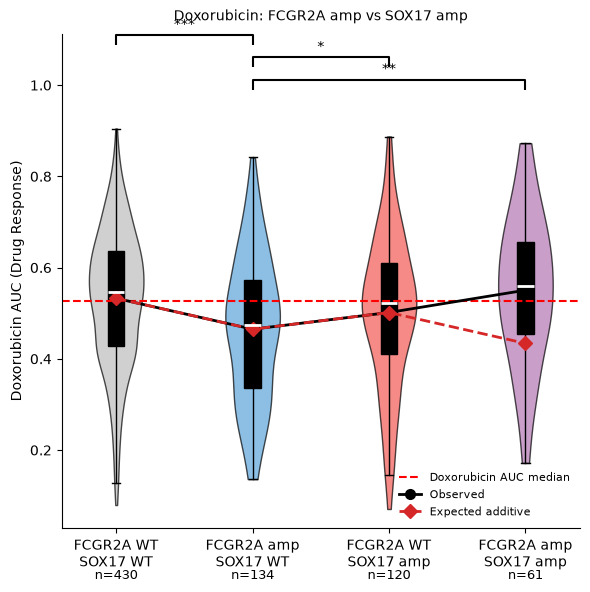

In [43]:
pairwise_df, group_values, additive_summary = plot_violin_auc_only(
    drug="Doxorubicin",
    gene1="FCGR2A", alt1="amp",
    gene2="SOX17", alt2="amp",
    results=results,
    alpha=0.05,
    group_spacing=1.25,
    response_type="actual",
    out_svg="fcgr2a_sox17_doxorubicin_epistasis_violin.svg",
    show_expected_observed_lines=True,
)

### e. Epistasis test with statistics (figure not included in manuscript)

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm


def _read_single_column_series(path: str) -> pd.Series:
    df = pd.read_csv(path, header=None, sep="\t", engine="python", dtype=str)
    if df.shape[1] != 1:
        raise ValueError(f"{path} should have exactly one column; got {df.shape[1]}")
    return df.iloc[:, 0].astype(str).str.strip()


def _parse_binary_matrix(series_of_rows: pd.Series, n_cols_expected: int) -> np.ndarray:
    rows = [np.fromstring(row, sep=",", dtype=np.int8) for row in series_of_rows.values]
    arr = np.vstack(rows)
    if arr.shape[1] != n_cols_expected:
        raise ValueError(f"Parsed matrix has {arr.shape[1]} columns, expected {n_cols_expected}.")
    return arr


def _load_indices(cell_index_file: str, gene_index_file: str):
    cell_df = pd.read_csv(cell_index_file, sep="\t", header=None, names=["Index", "CellLine"])
    gene_df = pd.read_csv(gene_index_file, sep="\t", header=None, names=["Index", "Gene"])

    cell_df["Index"] = pd.to_numeric(cell_df["Index"], errors="coerce").astype(int)
    gene_df["Index"] = pd.to_numeric(gene_df["Index"], errors="coerce").astype(int)

    cell_df = cell_df.sort_values("Index")
    gene_df = gene_df.sort_values("Index")

    cell_lines = list(cell_df["CellLine"].astype(str))
    genes = list(gene_df["Gene"].astype(str))
    return cell_lines, genes


def load_binary_matrix_from_singlecol(path: str, cell_lines, gene_names) -> pd.DataFrame:
    s = _read_single_column_series(path)
    arr = _parse_binary_matrix(s, n_cols_expected=len(gene_names))

    if arr.shape[0] != len(cell_lines):
        raise ValueError(f"{path}: parsed {arr.shape[0]} rows but expected {len(cell_lines)} cell lines.")

    return pd.DataFrame(
        arr,
        index=pd.Index(cell_lines, name="cell_line"),
        columns=pd.Index(gene_names, name="gene")
    )


def _get_alteration_series(gene, alt_type, amp_df, del_df, mut_df):
    alt_type = str(alt_type).lower().strip()
    if alt_type == "amp":
        return amp_df[gene].astype(int)
    elif alt_type == "del":
        return del_df[gene].astype(int)
    elif alt_type == "mut":
        return mut_df[gene].astype(int)
    else:
        raise ValueError("alt_type must be one of: 'amp', 'del', 'mut'")


def _pretty_p(p):
    if pd.isna(p):
        return "NA"
    if p < 1e-4:
        return "< 1e-4"
    return f"{p:.3e}"


def test_epistatic_interaction_for_drug(
    results,
    drug,
    gene1,
    alt1,
    gene2,
    alt2,
    response_type="actual",   # "actual" or "predicted"
    cn_burden=False,
    mut_burden=False,
    amp_file="data/cell2cnamplification_ctg_av.txt",
    del_file="data/cell2cndeletion_ctg_av.txt",
    mut_file="data/cell2mutation_ctg_av.txt",
    gene_index_file="data/gene2ind_ctg_av.txt",
    cell_index_file="data/cell2ind_av.txt",
    min_cells_per_group=1,
    make_plot=True,
    figsize=(6.8, 5.8),
    point_alpha=0.7,
    point_size=35,
    out_svg=None,
    show=True,
):
    """
    Test epistasis between two binary genetic alterations for a specified drug.

    Models:
      additive:    y ~ x1 + x2 [+ cn_burden] [+ mut_burden]
      interaction: y ~ x1 + x2 + x1:x2 [+ cn_burden] [+ mut_burden]

    Definitions:
      cn_burden  = (sum of amplifications + sum of deletions) / 718
      mut_burden = (sum of mutations) / 718

    Interpretation:
      - Significant x1:x2 coefficient => evidence for non-additive interaction
      - Positive beta_interaction => double-altered cells have higher AUC than expected additively
      - Negative beta_interaction => double-altered cells have lower AUC than expected additively
    """
    if drug not in results:
        raise KeyError(f"Drug '{drug}' not found in results.")

    response_type = str(response_type).lower().strip()
    if response_type not in {"actual", "predicted"}:
        raise ValueError("response_type must be 'actual' or 'predicted'.")

    gene1 = str(gene1).strip()
    gene2 = str(gene2).strip()
    alt1 = str(alt1).lower().strip()
    alt2 = str(alt2).lower().strip()

    if alt1 not in {"amp", "del", "mut"}:
        raise ValueError("alt1 must be one of: 'amp', 'del', 'mut'")
    if alt2 not in {"amp", "del", "mut"}:
        raise ValueError("alt2 must be one of: 'amp', 'del', 'mut'")

    # Load matrices
    cell_lines, genes = _load_indices(cell_index_file, gene_index_file)
    amp_df = load_binary_matrix_from_singlecol(amp_file, cell_lines, genes)
    del_df = load_binary_matrix_from_singlecol(del_file, cell_lines, genes)
    mut_df = load_binary_matrix_from_singlecol(mut_file, cell_lines, genes)

    if gene1 not in genes:
        raise ValueError(f"gene1 '{gene1}' not found in gene index file.")
    if gene2 not in genes:
        raise ValueError(f"gene2 '{gene2}' not found in gene index file.")

    # Drug response
    drug_cells = pd.Index(results[drug]["celllines"], name="cell_line")

    if response_type == "actual":
        y_vals = np.asarray(results[drug]["actual"], dtype=float)
        response_label = "Actual AUC"
    else:
        y_vals = np.asarray(results[drug]["predictions"], dtype=float)
        response_label = "Predicted AUC"

    y = pd.Series(y_vals, index=drug_cells, name="y")
    y = y[~y.index.duplicated(keep="first")]
    y = y[pd.notna(y)]

    # Align common cells
    common = y.index.intersection(amp_df.index).intersection(del_df.index).intersection(mut_df.index)
    if len(common) < 4:
        raise ValueError("Need at least 4 overlapping cell lines.")

    amp_sub = amp_df.loc[common]
    del_sub = del_df.loc[common]
    mut_sub = mut_df.loc[common]
    y = y.loc[common]

    # Alteration variables
    x1 = _get_alteration_series(gene1, alt1, amp_sub, del_sub, mut_sub).rename("x1")
    x2 = _get_alteration_series(gene2, alt2, amp_sub, del_sub, mut_sub).rename("x2")

    # Build main dataframe
    df = pd.concat([y, x1, x2], axis=1).dropna()
    df["x1"] = df["x1"].astype(int)
    df["x2"] = df["x2"].astype(int)
    df["x1x2"] = df["x1"] * df["x2"]

    # Burden covariates using your definitions
    n_panel_genes = len(genes)  # should be 718 in your setup

    if cn_burden:
        cn_series = ((amp_sub.sum(axis=1) + del_sub.sum(axis=1)) / n_panel_genes).rename("cn_burden")
        df = df.join(cn_series, how="left")

    if mut_burden:
        mut_series = (mut_sub.sum(axis=1) / n_panel_genes).rename("mut_burden")
        df = df.join(mut_series, how="left")

    df = df.dropna()

    # Four genotype groups
    df["group"] = (
        "x1=" + df["x1"].astype(str) +
        ", x2=" + df["x2"].astype(str)
    )

    group_summary = (
        df.groupby(["x1", "x2"])["y"]
        .agg(["size", "mean", "median", "std"])
        .reset_index()
        .rename(columns={"size": "n"})
    )

    # Optional guard for very sparse groups
    group_counts = df.groupby(["x1", "x2"]).size().to_dict()
    expected_groups = [(0, 0), (0, 1), (1, 0), (1, 1)]
    for g in expected_groups:
        if group_counts.get(g, 0) < min_cells_per_group:
            print(f"Warning: group {g} has n={group_counts.get(g, 0)} < {min_cells_per_group}")

    # Build formulas dynamically
    additive_terms = ["x1", "x2"]
    interaction_terms = ["x1", "x2", "x1:x2"]

    if cn_burden:
        additive_terms.append("cn_burden")
        interaction_terms.append("cn_burden")

    if mut_burden:
        additive_terms.append("mut_burden")
        interaction_terms.append("mut_burden")

    additive_formula = "y ~ " + " + ".join(additive_terms)
    interaction_formula = "y ~ " + " + ".join(interaction_terms)

    # Fit models
    additive_model = smf.ols(additive_formula, data=df).fit()
    interaction_model = smf.ols(interaction_formula, data=df).fit()

    # Nested model comparison
    model_comparison = anova_lm(additive_model, interaction_model)

    # Extract interaction stats
    interaction_term_name = "x1:x2"
    beta_interaction = interaction_model.params.get(interaction_term_name, np.nan)
    p_interaction = interaction_model.pvalues.get(interaction_term_name, np.nan)

    if interaction_term_name in interaction_model.params.index:
        ci_interaction = interaction_model.conf_int().loc[interaction_term_name].values
    else:
        ci_interaction = np.array([np.nan, np.nan])

    # Direction / interpretation
    if np.isfinite(beta_interaction):
        if beta_interaction > 0:
            interaction_direction = "positive interaction on AUC (double alteration increases AUC above additive expectation)"
        elif beta_interaction < 0:
            interaction_direction = "negative interaction on AUC (double alteration decreases AUC below additive expectation)"
        else:
            interaction_direction = "no interaction effect estimated"
    else:
        interaction_direction = "interaction not estimable"

    # Plot
    fig, ax = None, None
    if make_plot:
        fig, ax = plt.subplots(figsize=figsize)

        order = [(0, 0), (1, 0), (0, 1), (1, 1)]
        x_positions = np.arange(len(order))

        plot_data = []
        labels = []
        for i, j in order:
            vals = df.loc[(df["x1"] == i) & (df["x2"] == j), "y"].values
            plot_data.append(vals)
            labels.append(f"{gene1} {alt1}={i}\n{gene2} {alt2}={j}")

        # Boxplot
        ax.boxplot(
            plot_data,
            positions=x_positions,
            widths=0.5,
            patch_artist=True,
            showfliers=False,
            boxprops=dict(facecolor="black", color="black"),
            medianprops=dict(color="white", linewidth=2),
            whiskerprops=dict(color="black"),
            capprops=dict(color="black")
        )

        # Jittered points
        rng = np.random.default_rng(0)
        for k, vals in enumerate(plot_data):
            if len(vals) == 0:
                continue
            jitter = rng.normal(0, 0.06, size=len(vals))
            ax.scatter(
                np.full(len(vals), x_positions[k]) + jitter,
                vals,
                alpha=point_alpha,
                s=point_size
            )

        cov_text = []
        if cn_burden:
            cov_text.append("CN burden")
        if mut_burden:
            cov_text.append("Mutation burden")
        cov_text = ", ".join(cov_text) if len(cov_text) > 0 else "None"

        ax.set_xticks(x_positions)
        ax.set_xticklabels(labels, fontsize=10)
        ax.set_ylabel(response_label, fontsize=12)
        ax.set_xlabel("Alteration combinations", fontsize=12)
        ax.set_title(
            f"{drug}: {gene1} {alt1} × {gene2} {alt2}\n"
            f"interaction β = {beta_interaction:.3f}, p = {_pretty_p(p_interaction)}\n"
            f"Covariates: {cov_text}",
            fontsize=11
        )
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        plt.tight_layout()

        if out_svg is not None:
            plt.rcParams["svg.fonttype"] = "none"
            fig.savefig(out_svg, format="svg", bbox_inches="tight")
            print(f"Saved SVG to: {out_svg}")

        if show:
            plt.show()

    # Readable summary
    model_comparison_p = model_comparison.iloc[1]["Pr(>F)"] if model_comparison.shape[0] > 1 else np.nan

    summary_lines = [
        f"Drug: {drug}",
        f"Response type: {response_type}",
        f"Alteration 1: {gene1} {alt1}",
        f"Alteration 2: {gene2} {alt2}",
        f"n cells: {len(df)}",
        f"CN burden included: {cn_burden}",
        f"Mutation burden included: {mut_burden}",
        f"Additive formula: {additive_formula}",
        f"Interaction formula: {interaction_formula}",
        f"Interaction beta (x1:x2): {beta_interaction:.6f}" if np.isfinite(beta_interaction) else "Interaction beta (x1:x2): NA",
        f"Interaction p-value: {_pretty_p(p_interaction)}",
        f"Interaction 95% CI: [{ci_interaction[0]:.6f}, {ci_interaction[1]:.6f}]" if np.isfinite(ci_interaction).all() else "Interaction 95% CI: NA",
        f"Model comparison p-value (additive vs interaction): {_pretty_p(model_comparison_p)}",
        f"Interpretation: {interaction_direction}",
    ]

    print("\n".join(summary_lines))
    print("\nGroup summary:")
    print(group_summary.to_string(index=False))

    return {
        "dataframe": df,
        "group_summary": group_summary,
        "additive_formula": additive_formula,
        "interaction_formula": interaction_formula,
        "additive_model": additive_model,
        "interaction_model": interaction_model,
        "model_comparison": model_comparison,
        "interaction_beta": beta_interaction,
        "interaction_pvalue": p_interaction,
        "interaction_ci": ci_interaction,
        "interaction_direction": interaction_direction,
        "figure": fig,
        "axis": ax,
    }

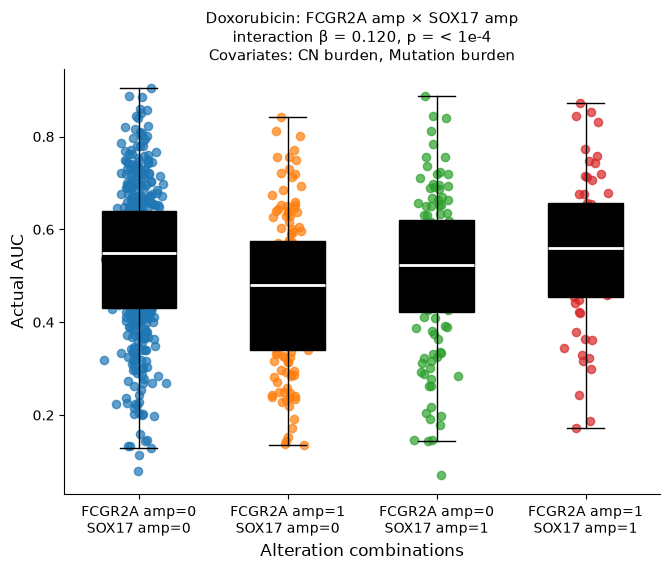

Drug: Doxorubicin
Response type: actual
Alteration 1: FCGR2A amp
Alteration 2: SOX17 amp
n cells: 813
CN burden included: True
Mutation burden included: True
Additive formula: y ~ x1 + x2 + cn_burden + mut_burden
Interaction formula: y ~ x1 + x2 + x1:x2 + cn_burden + mut_burden
Interaction beta (x1:x2): 0.120003
Interaction p-value: < 1e-4
Interaction 95% CI: [0.065769, 0.174237]
Model comparison p-value (additive vs interaction): < 1e-4
Interpretation: positive interaction on AUC (double alteration increases AUC above additive expectation)

Group summary:
 x1  x2   n     mean   median      std
  0   0 488 0.535668 0.548539 0.151241
  0   1 124 0.506473 0.523001 0.163819
  1   0 140 0.468318 0.480032 0.160387
  1   1  61 0.550511 0.559633 0.162777


In [45]:
out = test_epistatic_interaction_for_drug(
    results=results,
    drug="Doxorubicin",
    gene1="FCGR2A",
    alt1="amp",
    gene2="SOX17",
    alt2="amp",
    response_type="actual",
    cn_burden=True,
    mut_burden=True,
    make_plot=True,
    show=True,
)

### f. Gene epistasis vs gene importance for specific drug (Fig. 6f)

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _load_drpt_important_genes_for_drug(
    drpt_important_genes,
    drug,
    gene_col="gene",
    important_drugs_col="important_drugs",
):
    """
    Load a dataframe or CSV containing:
        gene
        important_drugs

    important_drugs should contain semicolon-separated drug names, e.g.
        Etoposide;Doxorubicin;CD437

    Returns a set of genes important for the specified drug.
    """

    if drpt_important_genes is None:
        return set()

    if isinstance(drpt_important_genes, pd.DataFrame):
        df = drpt_important_genes.copy()
    else:
        df = pd.read_csv(drpt_important_genes).copy()

    required = {gene_col, important_drugs_col}
    missing = required - set(df.columns)

    if missing:
        raise ValueError(
            f"drpt_important_genes file/dataframe missing columns: {missing}"
        )

    df[gene_col] = df[gene_col].astype(str)
    df[important_drugs_col] = df[important_drugs_col].fillna("").astype(str)

    drug = str(drug).strip()

    important_genes = set()

    for _, row in df.iterrows():
        gene = str(row[gene_col]).strip()

        drugs = [
            d.strip()
            for d in str(row[important_drugs_col]).split(";")
            if d.strip()
        ]

        if drug in drugs:
            important_genes.add(gene)

    return important_genes


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_gene_epistasis_vs_abs_importance_for_drug(
    gene_epistasis_csv,
    gene_importance_csv,
    drug,
    epistasis_score_col="epistasis_score_mean_neglog10p",
    importance_score_col="semi_partial_pearson",
    gene_col="gene",
    drug_col="drug",

    # Optional restriction to a specific gene list
    rsi_important_genes=None,
    genes_to_include=None,  # backward-compatible alias

    # Epistasis aggregation only
    epistasis_aggregate="mean",  # "mean" or "max"

    figsize=(6.2, 5.6),
    point_size=45,
    point_alpha=0.85,

    # Colors
    point_color="#8E8E8E",

    # Scaled 1:1 reference line
    show_scaled_identity_line=True,
    identity_line_color="black",
    identity_line_width=2.0,
    identity_line_style="--",
    identity_line_label="Scaled 1:1 reference",

    # Axis controls
    x_min=None,
    x_max=None,
    y_min=None,
    y_max=None,
    x_tick_step=None,
    y_tick_step=None,

    # Margins
    x_left_margin_frac=0.04,
    y_bottom_margin_frac=0.04,

    xlabel=None,
    ylabel=None,
    title=None,

    out_svg=None,
    show=True,
):
    """
    Scatter plot of gene-level epistasis score versus absolute gene importance
    for one specified drug.

    For a specific drug:
      x = abs(gene importance score for that drug)
      y = gene epistasis score for that drug

    This version:
      - plots all genes in one color
      - removes important-gene coloring
      - adds a scaled 1:1 reference line that accounts for different x/y scales

    The scaled 1:1 line maps:
      x_min -> y_min
      x_max -> y_max

    Example:
      x-axis: 0 to 0.4
      y-axis: 0 to 4

      Then the scaled 1:1 line is y = 10x.
    """

    if epistasis_aggregate not in {"mean", "max"}:
        raise ValueError("epistasis_aggregate must be 'mean' or 'max'.")

    drug = str(drug).strip()

    if rsi_important_genes is None and genes_to_include is not None:
        rsi_important_genes = genes_to_include

    epi_df = pd.read_csv(gene_epistasis_csv).copy()
    imp_df = pd.read_csv(gene_importance_csv).copy()

    required_epi = {gene_col, drug_col, epistasis_score_col}
    required_imp = {gene_col, drug_col, importance_score_col}

    missing_epi = required_epi - set(epi_df.columns)
    missing_imp = required_imp - set(imp_df.columns)

    if missing_epi:
        raise ValueError(f"gene_epistasis_csv missing columns: {missing_epi}")

    if missing_imp:
        raise ValueError(f"gene_importance_csv missing columns: {missing_imp}")

    # -------------------------------------------------
    # Clean epistasis file
    # -------------------------------------------------
    epi_df[gene_col] = epi_df[gene_col].astype(str)
    epi_df[drug_col] = epi_df[drug_col].astype(str)

    epi_df[epistasis_score_col] = pd.to_numeric(
        epi_df[epistasis_score_col],
        errors="coerce"
    )

    epi_df = epi_df.dropna(
        subset=[gene_col, drug_col, epistasis_score_col]
    )

    epi_df = epi_df[epi_df[drug_col] == drug].copy()

    if epi_df.empty:
        raise ValueError(
            f"No rows found in gene_epistasis_csv for drug='{drug}'."
        )

    # -------------------------------------------------
    # Clean importance file
    # -------------------------------------------------
    imp_df[gene_col] = imp_df[gene_col].astype(str)
    imp_df[drug_col] = imp_df[drug_col].astype(str)

    imp_df[importance_score_col] = pd.to_numeric(
        imp_df[importance_score_col],
        errors="coerce"
    )

    imp_df = imp_df.dropna(
        subset=[gene_col, drug_col, importance_score_col]
    )

    imp_df = imp_df[imp_df[drug_col] == drug].copy()

    if imp_df.empty:
        raise ValueError(
            f"No rows found in gene_importance_csv for drug='{drug}'."
        )

    # -------------------------------------------------
    # Optional RSi-important gene restriction
    # -------------------------------------------------
    if rsi_important_genes is not None:
        rsi_important_genes = set(map(str, rsi_important_genes))

        epi_df = epi_df[epi_df[gene_col].isin(rsi_important_genes)].copy()
        imp_df = imp_df[imp_df[gene_col].isin(rsi_important_genes)].copy()

        if epi_df.empty:
            raise ValueError(
                "After filtering to rsi_important_genes, no epistasis rows remain."
            )

        if imp_df.empty:
            raise ValueError(
                "After filtering to rsi_important_genes, no importance rows remain."
            )

    # -------------------------------------------------
    # Collapse duplicate gene-drug rows if present
    # -------------------------------------------------
    epi_agg = (
        epi_df
        .groupby(gene_col, as_index=False)
        .agg(epistasis_score=(epistasis_score_col, epistasis_aggregate))
    )

    imp_agg = (
        imp_df
        .groupby(gene_col, as_index=False)
        .agg(importance_score=(importance_score_col, "mean"))
    )

    # -------------------------------------------------
    # Merge
    # -------------------------------------------------
    gene_df = pd.merge(
        epi_agg,
        imp_agg,
        on=gene_col,
        how="inner"
    )

    if gene_df.empty:
        raise ValueError(
            "No overlapping genes between epistasis and importance files "
            f"for drug='{drug}'."
        )

    if gene_df.shape[0] < 3:
        raise ValueError(
            f"Need at least 3 genes for plotting; got {gene_df.shape[0]}."
        )

    gene_df["abs_importance"] = np.abs(gene_df["importance_score"].values)

    # -------------------------------------------------
    # Top genes tables
    # -------------------------------------------------
    top20_epistasis = (
        gene_df
        .sort_values("epistasis_score", ascending=False)
        .head(20)
        [[gene_col, "epistasis_score", "importance_score", "abs_importance"]]
        .reset_index(drop=True)
    )

    top20_importance = (
        gene_df
        .sort_values("abs_importance", ascending=False)
        .head(20)
        [[gene_col, "abs_importance", "importance_score", "epistasis_score"]]
        .reset_index(drop=True)
    )

    # -------------------------------------------------
    # X/Y values
    # -------------------------------------------------
    x = gene_df["abs_importance"].to_numpy(dtype=float)
    y = gene_df["epistasis_score"].to_numpy(dtype=float)

    # -------------------------------------------------
    # Axis limits
    # -------------------------------------------------
    x_min_use = float(np.nanmin(x)) if x_min is None else float(x_min)
    x_max_use = float(np.nanmax(x)) if x_max is None else float(x_max)

    y_min_use = float(np.nanmin(y)) if y_min is None else float(y_min)
    y_max_use = float(np.nanmax(y)) if y_max is None else float(y_max)

    if x_max_use <= x_min_use:
        raise ValueError("x_max must be greater than x_min.")

    if y_max_use <= y_min_use:
        raise ValueError("y_max must be greater than y_min.")

    x_span = x_max_use - x_min_use
    y_span = y_max_use - y_min_use

    plot_x_min = x_min_use - x_left_margin_frac * x_span
    plot_x_max = x_max_use
    plot_y_min = y_min_use - y_bottom_margin_frac * y_span
    plot_y_max = y_max_use

    # -------------------------------------------------
    # Plot
    # -------------------------------------------------
    fig, ax = plt.subplots(figsize=figsize)

    ax.scatter(
        x,
        y,
        s=point_size,
        alpha=point_alpha,
        color=point_color,
        edgecolor="black",
        linewidth=0.4,
        label=f"Genes (n={len(gene_df)})"
    )

    # -------------------------------------------------
    # Scaled 1:1 reference line
    # -------------------------------------------------
    if show_scaled_identity_line:
        ref_x = np.linspace(x_min_use, x_max_use, 200)

        ref_y = y_min_use + (
            (ref_x - x_min_use) / (x_max_use - x_min_use)
        ) * (y_max_use - y_min_use)

        ax.plot(
            ref_x,
            ref_y,
            color=identity_line_color,
            linestyle=identity_line_style,
            linewidth=identity_line_width,
            label=identity_line_label,
            zorder=2
        )

    # -------------------------------------------------
    # Labels
    # -------------------------------------------------
    if xlabel is None:
        xlabel = f"Absolute gene importance score for {drug}"

    if ylabel is None:
        ylabel = (
            f"{epistasis_aggregate.capitalize()} gene epistasis score "
            f"for {drug}"
        )

    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)

    if title is None:
        title = f"{drug}: gene epistasis vs. DRPT importance"

    ax.set_title(title, fontsize=12)

    # -------------------------------------------------
    # Axis limits and ticks
    # -------------------------------------------------
    ax.set_xlim(plot_x_min, plot_x_max)
    ax.set_ylim(plot_y_min, plot_y_max)

    if x_tick_step is not None:
        xticks = np.arange(
            x_min_use,
            x_max_use + 1e-12,
            float(x_tick_step)
        )
        ax.set_xticks(xticks)

    if y_tick_step is not None:
        yticks = np.arange(
            y_min_use,
            y_max_use + 1e-12,
            float(y_tick_step)
        )
        ax.set_yticks(yticks)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(frameon=False, fontsize=9)

    plt.tight_layout()

    if out_svg is not None:
        plt.rcParams["svg.fonttype"] = "none"
        fig.savefig(out_svg, format="svg", bbox_inches="tight")
        print(f"Saved SVG to: {out_svg}")

    if show:
        plt.show()

    print(f"Drug: {drug}")
    print(f"Genes analyzed: {gene_df.shape[0]}")

    if rsi_important_genes is not None:
        print("Restricted to provided RSi-important genes.")

    print(f"\nTop 20 genes by {epistasis_score_col} ({epistasis_aggregate}) for {drug}:")
    print(top20_epistasis.to_string(index=False))

    print(f"\nTop 20 genes by absolute importance score for {drug}:")
    print(top20_importance.to_string(index=False))

    return {
        "drug": drug,
        "gene_df": gene_df,
        "top20_epistasis": top20_epistasis,
        "top20_importance": top20_importance,
        "figure": fig,
        "axis": ax,
    }

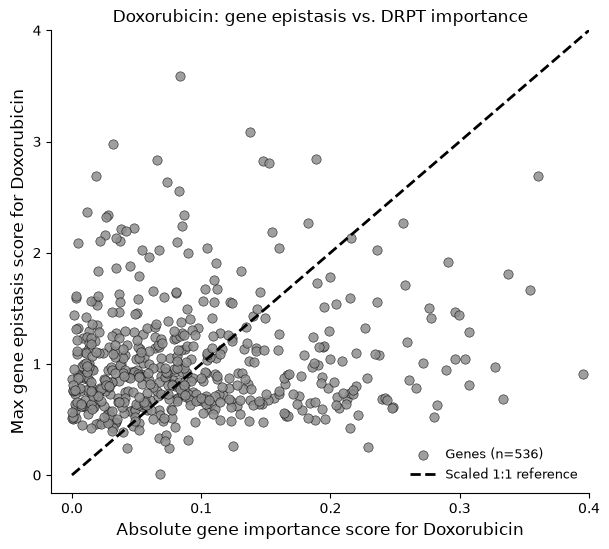

Drug: Doxorubicin
Genes analyzed: 536

Top 20 genes by epistasis_score_hmp_neglog10p (max) for Doxorubicin:
  gene  epistasis_score  importance_score  abs_importance
  XPO1         3.585720         -0.083741        0.083741
 STAG2         3.089996          0.137901        0.137901
  IRF1         2.979735          0.031862        0.031862
   LYN         2.844556          0.188932        0.188932
 SOX17         2.829574          0.065824        0.065824
 PNRC1         2.827091          0.147579        0.147579
   REL         2.802353          0.152718        0.152718
  FGF7         2.690657          0.018826        0.018826
FCGR2A         2.687981          0.360858        0.360858
   NBN         2.636621         -0.073246        0.073246
 EPCAM         2.557279          0.082822        0.082822
 STK11         2.367623          0.011768        0.011768
  PHF6         2.339513         -0.027917        0.027917
 FOXO1         2.339337          0.086546        0.086546
PTPN22         2.31888

In [47]:
out = plot_gene_epistasis_vs_abs_importance_for_drug(
    gene_epistasis_csv="gene_epistasis_scores.csv",
    gene_importance_csv="gene_semi_partial_importance_g2d.csv",
    drug="Doxorubicin",
    epistasis_score_col="epistasis_score_hmp_neglog10p",
    epistasis_aggregate="max",
    x_min=0.0,
    x_max=0.4,
    y_min=0.0,
    y_max=4,
    x_tick_step=0.1,
    y_tick_step=1.0,
    x_left_margin_frac=0.04,
    y_bottom_margin_frac=0.04,
    #out_svg="doxorubicin_gene_epistasis_vs_importance.svg"
)

### g. Expression heatmap of doxorubicin important genes in FCGR2A + SOX17 amp cell lines 

#### Heatmaps

In [48]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist
from typing import Iterable, Dict, Any, Optional, Tuple, List, Literal


# ---------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------

def load_binary_matrix_from_singlecol(path, cell_lines, gene_names):
    """
    Load a 0/1 alteration matrix from the single-column comma-separated format.

    Each row is a single string like:
        "0,1,0,0,..."

    Rows correspond to cell_lines and columns correspond to gene_names.
    """
    s = (
        pd.read_csv(path, header=None, sep="\t", engine="python", dtype=str)
        .iloc[:, 0]
        .astype(str)
        .str.strip()
    )

    rows = [np.fromstring(x, sep=",", dtype=np.int8) for x in s.values]
    arr = np.vstack(rows)

    if arr.shape[0] != len(cell_lines):
        raise ValueError(
            f"{path}: parsed {arr.shape[0]} rows but expected {len(cell_lines)} cell lines."
        )

    if arr.shape[1] != len(gene_names):
        raise ValueError(
            f"{path}: parsed {arr.shape[1]} genes but expected {len(gene_names)} genes."
        )

    return pd.DataFrame(
        arr,
        index=pd.Index(cell_lines, name="cell_line"),
        columns=pd.Index(gene_names, name="gene"),
    )


def _parse_drug_list_cell(x) -> set:
    """
    Parse semicolon-separated drug-list cells from drpt_important_genes.csv.
    """
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return set()

    s = str(x).strip()

    if s == "":
        return set()

    return {t.strip() for t in s.split(";") if t.strip()}


def get_important_genes_for_drug_from_csv(
    drpt_important_genes_csv: str,
    drug: str,
    gene_col: str = "gene",
    important_drugs_col: str = "important_drugs",
) -> List[str]:
    """
    Load important genes from drpt_important_genes.csv for a specified drug.

    Falls back to 'sig_drugs' if important_drugs_col is not present.
    """
    imp_df = pd.read_csv(drpt_important_genes_csv)

    if gene_col not in imp_df.columns:
        raise KeyError(f"Important genes CSV missing required column: '{gene_col}'")

    if important_drugs_col not in imp_df.columns:
        if "sig_drugs" in imp_df.columns:
            important_drugs_col = "sig_drugs"
        else:
            raise KeyError(
                f"Important genes CSV missing '{important_drugs_col}' and no fallback 'sig_drugs' column found."
            )

    imp_df[gene_col] = imp_df[gene_col].astype(str)
    imp_df["_drug_set"] = imp_df[important_drugs_col].apply(_parse_drug_list_cell)

    important_genes = (
        imp_df.loc[
            imp_df["_drug_set"].apply(lambda s: str(drug) in s),
            gene_col,
        ]
        .astype(str)
        .tolist()
    )

    return sorted(set(important_genes))


def _mannwhitneyu_pvalue_two_sided(group_values: np.ndarray, wt_values: np.ndarray) -> float:
    """
    Two-sided Mann-Whitney U test.

    Matches:
        mannwhitneyu(v1, v2, alternative="two-sided")
    """
    group_values = np.asarray(group_values, dtype=float)
    wt_values = np.asarray(wt_values, dtype=float)

    group_values = group_values[np.isfinite(group_values)]
    wt_values = wt_values[np.isfinite(wt_values)]

    if len(group_values) == 0 or len(wt_values) == 0:
        return np.nan

    try:
        _, p = mannwhitneyu(group_values, wt_values, alternative="two-sided")
        return float(p)
    except ValueError:
        return np.nan


def _cluster_gene_columns_only(
    matrix: pd.DataFrame,
    method: str = "average",
    metric: str = "euclidean",
) -> List[str]:
    """
    Cluster only the gene columns and return the reordered gene list.

    This does not create a clustermap, dendrogram, or alter the heatmap style.
    It simply reorders columns before passing the matrix to sns.heatmap().
    """
    if matrix.shape[1] <= 1:
        return matrix.columns.tolist()

    X = matrix.T.copy()

    # Replace missing values with column/gene-level neutral values for clustering only.
    # This does not modify the plotted matrix values.
    X = X.replace([np.inf, -np.inf], np.nan)

    if X.isna().any().any():
        X = X.apply(lambda col: col.fillna(col.median()), axis=0)
        X = X.fillna(0.0)

    distances = pdist(X.values, metric=metric)

    if len(distances) == 0 or not np.all(np.isfinite(distances)):
        return matrix.columns.tolist()

    Z = linkage(distances, method=method)
    order = leaves_list(Z)

    return matrix.columns[order].tolist()


# ---------------------------------------------------------------------
# Main function
# ---------------------------------------------------------------------

def plot_expression_heatmap_two_gene_combo(
    expression_csv: str,
    drpt_important_genes_csv: str,
    drug: str = "Doxorubicin",

    gene1: str = "FCGR2A",
    alt1: str = "amp",
    gene2: str = "SOX17",
    alt2: str = "amp",

    amp_file: str = "/cellar/users/zwallace/DRPT/data/cell2cnamplification_ctg_av.txt",
    del_file: str = "/cellar/users/zwallace/DRPT/data/cell2cndeletion_ctg_av.txt",
    mut_file: str = "/cellar/users/zwallace/DRPT/data/cell2mutation_ctg_av.txt",
    cell_index_file: str = "/cellar/users/zwallace/DRPT/data/cell2ind_av.txt",
    gene_index_file: str = "/cellar/users/zwallace/DRPT/data/gene2ind_ctg_av.txt",

    important_gene_col: str = "gene",
    important_drugs_col: str = "important_drugs",

    heatmap_value: Literal["fold_change", "p_value", "neglog10_p_value"] = "fold_change",

    expression_pseudocount: float = 1e-6,
    p_value_floor: float = 1e-300,
    min_group_n: int = 1,
    min_wt_n: int = 1,

    center: Optional[float] = None,
    vmin: Optional[float] = None,
    vmax: Optional[float] = None,
    cmap: Optional[str] = None,

    # When True, only the gene/column order changes.
    # The heatmap itself stays exactly the same.
    cluster_genes: bool = False,
    cluster_method: str = "average",
    cluster_metric: str = "euclidean",

    sort_genes_by_max_abs_fc: bool = True,
    sort_genes_by_min_p: bool = True,

    figsize: Optional[Tuple[float, float]] = None,
    title: Optional[str] = None,
    out_svg: Optional[str] = None,
    show: bool = True,
) -> Dict[str, Any]:
    """
    Create a 3 x N heatmap for drug-important genes.

    Rows are:
        1. gene1 altered / gene2 WT
        2. gene1 WT / gene2 altered
        3. gene1 altered / gene2 altered

    Reference group:
        gene1 WT / gene2 WT

    heatmap_value options
    ---------------------
    'fold_change':
        Plot log2 fold-change versus WT/WT.

    'p_value':
        Plot raw two-sided Mann-Whitney U p-value comparing expression
        in each altered group against WT/WT.

    'neglog10_p_value':
        Plot -log10(two-sided Mann-Whitney U p-value) comparing expression
        in each altered group against WT/WT.

    Important behavior
    ------------------
    If cluster_genes=True, this function only reorders the gene columns using
    hierarchical clustering. It does not use sns.clustermap, does not add a
    dendrogram, does not move the colorbar, and does not change row labels.
    """

    # ------------------------------------------------------------------
    # Validate inputs
    # ------------------------------------------------------------------
    heatmap_value = str(heatmap_value).strip()

    if heatmap_value not in {"fold_change", "p_value", "neglog10_p_value"}:
        raise ValueError(
            "heatmap_value must be one of: 'fold_change', 'p_value', or 'neglog10_p_value'."
        )

    alt1 = str(alt1).lower().strip()
    alt2 = str(alt2).lower().strip()

    if alt1 not in {"amp", "del", "mut"}:
        raise ValueError("alt1 must be one of: 'amp', 'del', or 'mut'.")

    if alt2 not in {"amp", "del", "mut"}:
        raise ValueError("alt2 must be one of: 'amp', 'del', or 'mut'.")

    if expression_pseudocount <= 0:
        raise ValueError("expression_pseudocount must be > 0.")

    if p_value_floor <= 0:
        raise ValueError("p_value_floor must be > 0.")

    # ------------------------------------------------------------------
    # Default plot settings by heatmap type
    # ------------------------------------------------------------------
    if heatmap_value == "fold_change":
        if cmap is None:
            cmap = "coolwarm"
        if center is None:
            center = 0.0
        if vmin is None:
            vmin = -2.0
        if vmax is None:
            vmax = 2.0
        cbar_label = "log2 fold-change vs WT/WT"

    elif heatmap_value == "p_value":
        if cmap is None:
            cmap = "viridis_r"
        if center is None:
            center = None
        if vmin is None:
            vmin = 0.0
        if vmax is None:
            vmax = 0.05
        cbar_label = "MWU p-value vs WT/WT"

    else:
        if cmap is None:
            cmap = "Reds"
        if center is None:
            center = None
        if vmin is None:
            vmin = 0.0
        if vmax is None:
            vmax = None
        cbar_label = r"$-\log_{10}$(MWU p-value vs WT/WT)"

    # ------------------------------------------------------------------
    # Load expression data
    # ------------------------------------------------------------------
    expression = pd.read_csv(expression_csv, index_col=0)
    expression.index = expression.index.astype(str)
    expression.columns = expression.columns.astype(str)
    expression = expression.apply(pd.to_numeric, errors="coerce")

    # ------------------------------------------------------------------
    # Load cell-line and gene index files
    # ------------------------------------------------------------------
    cell_df = pd.read_csv(
        cell_index_file,
        sep="\t",
        header=None,
        names=["Index", "CellLine"],
    )

    gene_df = pd.read_csv(
        gene_index_file,
        sep="\t",
        header=None,
        names=["Index", "Gene"],
    )

    cell_lines = list(cell_df["CellLine"].astype(str))
    genes = list(gene_df["Gene"].astype(str))

    if gene1 not in genes:
        raise ValueError(f"gene1 '{gene1}' not found in gene index file.")

    if gene2 not in genes:
        raise ValueError(f"gene2 '{gene2}' not found in gene index file.")

    # ------------------------------------------------------------------
    # Load alteration matrices
    # ------------------------------------------------------------------
    amp_df = load_binary_matrix_from_singlecol(amp_file, cell_lines, genes)
    del_df = load_binary_matrix_from_singlecol(del_file, cell_lines, genes)
    mut_df = load_binary_matrix_from_singlecol(mut_file, cell_lines, genes)

    # ------------------------------------------------------------------
    # Align expression and alteration files by cell line
    # ------------------------------------------------------------------
    common_cells = sorted(set(expression.index) & set(cell_lines))

    if len(common_cells) == 0:
        raise ValueError("No overlapping cell lines between expression matrix and alteration files.")

    expression = expression.loc[common_cells].copy()
    amp_df = amp_df.loc[common_cells].copy()
    del_df = del_df.loc[common_cells].copy()
    mut_df = mut_df.loc[common_cells].copy()

    # ------------------------------------------------------------------
    # Get important genes for selected drug
    # ------------------------------------------------------------------
    important_genes = get_important_genes_for_drug_from_csv(
        drpt_important_genes_csv=drpt_important_genes_csv,
        drug=drug,
        gene_col=important_gene_col,
        important_drugs_col=important_drugs_col,
    )

    important_genes_with_expression = [
        g for g in important_genes
        if g in expression.columns
    ]

    missing_expression_genes = sorted(
        set(important_genes) - set(important_genes_with_expression)
    )

    if len(important_genes_with_expression) == 0:
        raise ValueError(
            f"No important genes for drug '{drug}' were found in the expression matrix columns."
        )

    # ------------------------------------------------------------------
    # Alteration status helpers
    # ------------------------------------------------------------------
    def get_alt_status(gene: str, alt: str) -> pd.Series:
        if alt == "amp":
            return amp_df[gene].astype(int) == 1
        if alt == "del":
            return del_df[gene].astype(int) == 1
        if alt == "mut":
            return mut_df[gene].astype(int) == 1
        raise ValueError("alt must be 'amp', 'del', or 'mut'.")

    def get_strict_wt_status(gene: str) -> pd.Series:
        return (
            (amp_df[gene].astype(int) == 0)
            & (del_df[gene].astype(int) == 0)
            & (mut_df[gene].astype(int) == 0)
        )

    gene1_alt = get_alt_status(gene1, alt1)
    gene2_alt = get_alt_status(gene2, alt2)

    gene1_wt = get_strict_wt_status(gene1)
    gene2_wt = get_strict_wt_status(gene2)

    # ------------------------------------------------------------------
    # Define groups
    # ------------------------------------------------------------------
    wt_wt_mask = gene1_wt & gene2_wt

    group_masks = {
        f"{gene1} {alt1.upper()} / {gene2} WT": gene1_alt & gene2_wt,
        f"{gene1} WT / {gene2} {alt2.upper()}": gene1_wt & gene2_alt,
        f"{gene1} {alt1.upper()} / {gene2} {alt2.upper()}": gene1_alt & gene2_alt,
    }

    group_ns = {
        "WT/WT reference": int(wt_wt_mask.sum())
    }

    for label, mask in group_masks.items():
        group_ns[label] = int(mask.sum())

    if int(wt_wt_mask.sum()) < int(min_wt_n):
        raise ValueError(
            f"WT/WT reference group has n={int(wt_wt_mask.sum())}, "
            f"which is below min_wt_n={min_wt_n}."
        )

    nonempty_group_masks = {}

    for label, mask in group_masks.items():
        if int(mask.sum()) >= int(min_group_n):
            nonempty_group_masks[label] = mask
        else:
            print(
                f"Warning: skipping group '{label}' because n={int(mask.sum())} "
                f"is below min_group_n={min_group_n}."
            )

    if len(nonempty_group_masks) == 0:
        raise ValueError("All altered groups were empty or below min_group_n.")

    expr_cols = important_genes_with_expression

    # ------------------------------------------------------------------
    # Compute fold-change matrix and p-value matrix
    # ------------------------------------------------------------------
    wt_expr = expression.loc[wt_wt_mask, expr_cols].copy()
    wt_mean = wt_expr.mean(axis=0)

    fc_rows = []
    pval_rows = []
    neglog10_p_rows = []
    mean_expr_rows = []

    for label, mask in nonempty_group_masks.items():
        group_expr = expression.loc[mask, expr_cols].copy()
        group_mean = group_expr.mean(axis=0)

        log2_fc = (
            np.log2(group_mean.astype(float) + expression_pseudocount)
            - np.log2(wt_mean.astype(float) + expression_pseudocount)
        )

        pvals = {}

        for g in expr_cols:
            pvals[g] = _mannwhitneyu_pvalue_two_sided(
                group_values=group_expr[g].to_numpy(dtype=float),
                wt_values=wt_expr[g].to_numpy(dtype=float),
            )

        pvals = pd.Series(pvals, name=label, dtype=float)
        neglog10_p = -np.log10(pvals.clip(lower=p_value_floor))

        fc_rows.append(pd.Series(log2_fc, name=label))
        pval_rows.append(pvals)
        neglog10_p_rows.append(pd.Series(neglog10_p, name=label))
        mean_expr_rows.append(pd.Series(group_mean, name=label))

    fc_matrix = pd.DataFrame(fc_rows)
    pval_matrix = pd.DataFrame(pval_rows)
    neglog10_p_matrix = pd.DataFrame(neglog10_p_rows)
    mean_expression_matrix = pd.DataFrame(mean_expr_rows)

    # ------------------------------------------------------------------
    # Keep valid genes
    # ------------------------------------------------------------------
    valid_genes = sorted(
        set(fc_matrix.dropna(axis=1, how="all").columns)
        & set(pval_matrix.dropna(axis=1, how="all").columns)
    )

    if len(valid_genes) == 0:
        raise ValueError("No valid genes remain after fold-change/p-value computation.")

    fc_matrix = fc_matrix[valid_genes]
    pval_matrix = pval_matrix[valid_genes]
    neglog10_p_matrix = neglog10_p_matrix[valid_genes]
    mean_expression_matrix = mean_expression_matrix[valid_genes]

    # ------------------------------------------------------------------
    # Choose matrix to plot
    # ------------------------------------------------------------------
    if heatmap_value == "fold_change":
        plot_matrix = fc_matrix.copy()
    elif heatmap_value == "p_value":
        plot_matrix = pval_matrix.copy()
    else:
        plot_matrix = neglog10_p_matrix.copy()

    # ------------------------------------------------------------------
    # Gene ordering
    # ------------------------------------------------------------------
    gene_order = plot_matrix.columns.tolist()

    if cluster_genes:
        gene_order = _cluster_gene_columns_only(
            matrix=plot_matrix,
            method=cluster_method,
            metric=cluster_metric,
        )

    elif heatmap_value == "fold_change" and sort_genes_by_max_abs_fc:
        gene_order = (
            fc_matrix.abs()
            .max(axis=0)
            .sort_values(ascending=False)
            .index
            .tolist()
        )

    elif heatmap_value in {"p_value", "neglog10_p_value"} and sort_genes_by_min_p:
        gene_order = (
            pval_matrix
            .min(axis=0)
            .sort_values(ascending=True)
            .index
            .tolist()
        )

    plot_matrix = plot_matrix[gene_order]
    fc_matrix = fc_matrix[gene_order]
    pval_matrix = pval_matrix[gene_order]
    neglog10_p_matrix = neglog10_p_matrix[gene_order]
    mean_expression_matrix = mean_expression_matrix[gene_order]

    # ------------------------------------------------------------------
    # Default output name
    # ------------------------------------------------------------------
    if out_svg is None:
        out_svg = (
            f"{drug}_important_genes_{gene1}{alt1}_{gene2}{alt2}_"
            f"expression_{heatmap_value}_heatmap.svg"
        )

    # ------------------------------------------------------------------
    # Plot using regular sns.heatmap no matter what
    # ------------------------------------------------------------------
    if figsize is None:
        figsize = (max(8, 0.23 * plot_matrix.shape[1]), 3.2)

    fig, ax = plt.subplots(figsize=figsize)

    sns.heatmap(
        plot_matrix,
        ax=ax,
        cmap=cmap,
        center=center,
        vmin=vmin,
        vmax=vmax,
        linewidths=0.25,
        linecolor="white",
        cbar_kws={"label": cbar_label},
    )

    ax.set_xlabel("")
    ax.set_ylabel("")

    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation=90,
        ha="center",
        fontsize=7,
    )

    ax.set_yticklabels(
        ax.get_yticklabels(),
        rotation=0,
        fontsize=9,
    )

    # Force row labels to stay on the left
    ax.yaxis.tick_left()
    ax.yaxis.set_label_position("left")

    if title is None:
        title = (
            f"{drug} important genes: {heatmap_value.replace('_', ' ')} vs WT/WT\n"
            f"{gene1} {alt1.upper()} and {gene2} {alt2.upper()}"
        )

    ax.set_title(title, fontsize=11, pad=10)

    plt.tight_layout()

    if out_svg is not None:
        plt.rcParams["svg.fonttype"] = "none"
        fig.savefig(out_svg, format="svg", bbox_inches="tight")
        print(f"Saved SVG to: {out_svg}")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return {
        "drug": drug,
        "gene1": gene1,
        "alt1": alt1,
        "gene2": gene2,
        "alt2": alt2,
        "heatmap_value": heatmap_value,

        "important_genes": important_genes,
        "important_genes_with_expression": important_genes_with_expression,
        "missing_expression_genes": missing_expression_genes,

        "plot_matrix": plot_matrix,
        "fc_matrix": fc_matrix,
        "pval_matrix": pval_matrix,
        "neglog10_p_matrix": neglog10_p_matrix,
        "mean_expression_matrix": mean_expression_matrix,
        "wt_wt_mean_expression": wt_mean,

        "gene_order": gene_order,
        "cluster_genes": bool(cluster_genes),
        "cluster_method": cluster_method,
        "cluster_metric": cluster_metric,

        "group_ns": group_ns,
        "common_cells": common_cells,
        "wt_wt_cells": expression.index[wt_wt_mask].tolist(),
        "group_cells": {
            label: expression.index[mask].tolist()
            for label, mask in nonempty_group_masks.items()
        },

        "fig": fig,
        "ax": ax,
    }

Saved SVG to: doxorubicin_important_genes_FCGR2Aamp_SOX17amp_expression_pvalue_heatmap_clustered_columns_only.svg


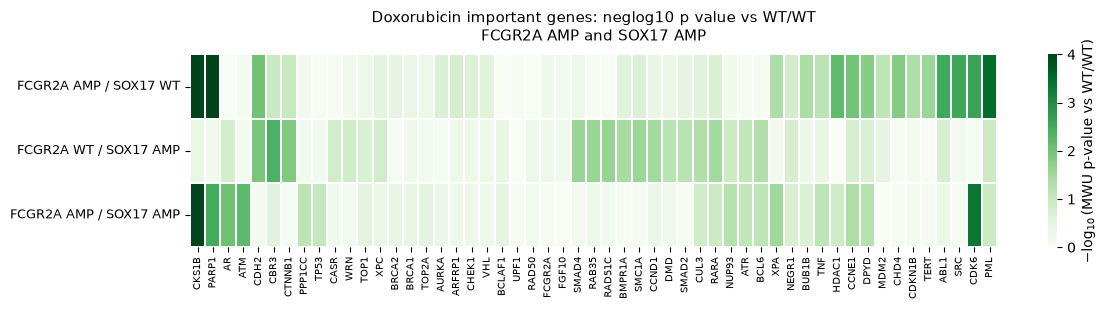

In [49]:
result_fc_clustered = plot_expression_heatmap_two_gene_combo(
    expression_csv="depmap_expression_processed.csv",
    drpt_important_genes_csv="drpt_important_genes.csv",
    drug="Doxorubicin",

    gene1="FCGR2A",
    alt1="amp",
    gene2="SOX17",
    alt2="amp",

    amp_file="data/cell2cnamplification_ctg_av.txt",
    del_file="data/cell2cndeletion_ctg_av.txt",
    mut_file="data/cell2mutation_ctg_av.txt",
    cell_index_file="data/cell2ind_av.txt",
    gene_index_file="data/gene2ind_ctg_av.txt",

    heatmap_value="neglog10_p_value",

    important_gene_col="gene",
    important_drugs_col="important_drugs",

    cmap="Greens",
    center=None,
    vmin=0,
    vmax=4.0,

    # This now ONLY reorders columns.
    cluster_genes=True,
    cluster_method="average",
    cluster_metric="euclidean",

    out_svg="doxorubicin_important_genes_FCGR2Aamp_SOX17amp_expression_pvalue_heatmap_clustered_columns_only.svg",
    show=True,
)

#### Volcanoe Plots

Doxorubicin important-gene expression volcano analysis
Reference group: FCGR2A WT / SOX17 WT
Reference n = 522
Fold-change threshold: abs(log2FC) >= 1.0
P-value threshold: p <= 0.05  |  -log10(p) >= 1.301

----------------------------------------------------------------------------------------------------
FCGR2A AMP / SOX17 WT vs WT/WT
Group n = 160
----------------------------------------------------------------------------------------------------

Genes above fold-change threshold, abs(log2FC) >= 1.0: n=1
gene  abs_log2_fc  log2_fc  p_value  neglog10_p
CASR       1.6571  -1.6571 0.949478    0.022515

Genes above p-value threshold, p <= 0.05: n=15
  gene  neglog10_p   log2_fc      p_value  neglog10_p
 CKS1B   17.701686  0.091179 1.987530e-18   17.701686
 PARP1    7.415244  0.091393 3.843759e-08    7.415244
   PML    3.479639 -0.086349 3.314063e-04    3.479639
  CDK6    2.627951 -0.148230 2.355314e-03    2.627951
   SRC    2.558950 -0.198421 2.760896e-03    2.558950
  ABL1    2.501518 

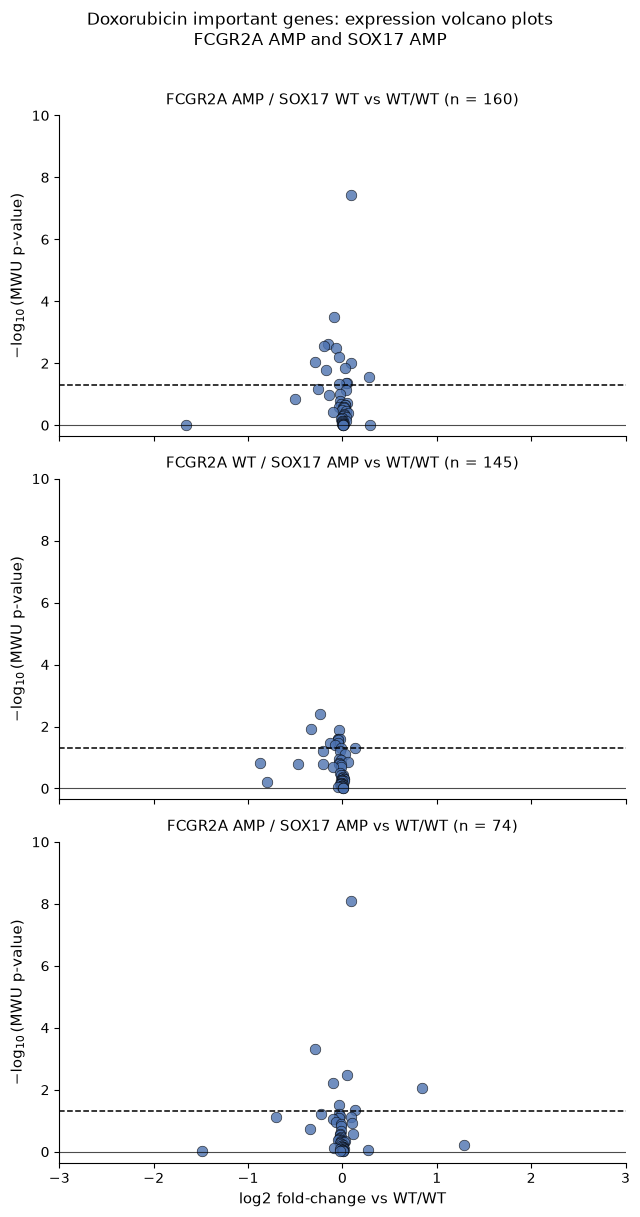

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu
from typing import Iterable, Dict, Any, Optional, Tuple, List


# ---------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------

def load_binary_matrix_from_singlecol(path, cell_lines, gene_names):
    """
    Load a 0/1 alteration matrix from the single-column comma-separated format.

    Each row is a single string like:
        "0,1,0,0,..."

    Rows correspond to cell_lines and columns correspond to gene_names.
    """
    s = (
        pd.read_csv(path, header=None, sep="\t", engine="python", dtype=str)
        .iloc[:, 0]
        .astype(str)
        .str.strip()
    )

    rows = [np.fromstring(x, sep=",", dtype=np.int8) for x in s.values]
    arr = np.vstack(rows)

    if arr.shape[0] != len(cell_lines):
        raise ValueError(
            f"{path}: parsed {arr.shape[0]} rows but expected {len(cell_lines)} cell lines."
        )

    if arr.shape[1] != len(gene_names):
        raise ValueError(
            f"{path}: parsed {arr.shape[1]} genes but expected {len(gene_names)} genes."
        )

    return pd.DataFrame(
        arr,
        index=pd.Index(cell_lines, name="cell_line"),
        columns=pd.Index(gene_names, name="gene"),
    )


def _parse_drug_list_cell(x) -> set:
    """
    Parse semicolon-separated drug-list cells from drpt_important_genes.csv.
    """
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return set()

    s = str(x).strip()

    if s == "":
        return set()

    return {t.strip() for t in s.split(";") if t.strip()}


def get_important_genes_for_drug_from_csv(
    drpt_important_genes_csv: str,
    drug: str,
    gene_col: str = "gene",
    important_drugs_col: str = "important_drugs",
) -> List[str]:
    """
    Load important genes from drpt_important_genes.csv for a specified drug.

    Falls back to 'sig_drugs' if important_drugs_col is not present.
    """
    imp_df = pd.read_csv(drpt_important_genes_csv)

    if gene_col not in imp_df.columns:
        raise KeyError(f"Important genes CSV missing required column: '{gene_col}'")

    if important_drugs_col not in imp_df.columns:
        if "sig_drugs" in imp_df.columns:
            important_drugs_col = "sig_drugs"
        else:
            raise KeyError(
                f"Important genes CSV missing '{important_drugs_col}' "
                f"and no fallback 'sig_drugs' column found."
            )

    imp_df[gene_col] = imp_df[gene_col].astype(str)
    imp_df["_drug_set"] = imp_df[important_drugs_col].apply(_parse_drug_list_cell)

    important_genes = (
        imp_df.loc[
            imp_df["_drug_set"].apply(lambda s: str(drug) in s),
            gene_col,
        ]
        .astype(str)
        .tolist()
    )

    return sorted(set(important_genes))


def _mannwhitneyu_pvalue_two_sided(group_values: np.ndarray, wt_values: np.ndarray) -> float:
    """
    Two-sided Mann-Whitney U test.

    Matches:
        mannwhitneyu(v1, v2, alternative="two-sided")
    """
    group_values = np.asarray(group_values, dtype=float)
    wt_values = np.asarray(wt_values, dtype=float)

    group_values = group_values[np.isfinite(group_values)]
    wt_values = wt_values[np.isfinite(wt_values)]

    if len(group_values) == 0 or len(wt_values) == 0:
        return np.nan

    try:
        _, p = mannwhitneyu(group_values, wt_values, alternative="two-sided")
        return float(p)
    except ValueError:
        return np.nan


def _format_report_table(df: pd.DataFrame, value_col: str, top_n: Optional[int] = None) -> pd.DataFrame:
    """
    Format compact gene/value table for printed output.
    """
    out = df.copy()

    if top_n is not None:
        out = out.head(int(top_n)).copy()

    return out[["gene", value_col, "log2_fc", "p_value", "neglog10_p"]].reset_index(drop=True)


# ---------------------------------------------------------------------
# Main function
# ---------------------------------------------------------------------

def plot_expression_volcano_three_groups_two_gene_combo(
    expression_csv: str,
    drpt_important_genes_csv: str,
    drug: str = "Doxorubicin",

    gene1: str = "FCGR2A",
    alt1: str = "amp",
    gene2: str = "SOX17",
    alt2: str = "amp",

    amp_file: str = "/cellar/users/zwallace/DRPT/data/cell2cnamplification_ctg_av.txt",
    del_file: str = "/cellar/users/zwallace/DRPT/data/cell2cndeletion_ctg_av.txt",
    mut_file: str = "/cellar/users/zwallace/DRPT/data/cell2mutation_ctg_av.txt",
    cell_index_file: str = "/cellar/users/zwallace/DRPT/data/cell2ind_av.txt",
    gene_index_file: str = "/cellar/users/zwallace/DRPT/data/gene2ind_ctg_av.txt",

    important_gene_col: str = "gene",
    important_drugs_col: str = "important_drugs",

    expression_pseudocount: float = 1e-6,
    p_value_floor: float = 1e-300,
    min_group_n: int = 1,
    min_wt_n: int = 1,

    # Axis limits
    x_min: float = -3.0,
    x_max: float = 3.0,
    y_min: float = 0.0,
    y_max: float = 10.0,

    # NEW: extra empty space below 0
    # Example: y_bottom_margin=0.5 means y-axis starts at -0.5.
    y_bottom_margin: float = 0.35,

    # Threshold lines
    fc_threshold: float = 1.0,
    p_value_threshold: float = 0.05,

    # These already existed, but now explicitly control whether lines are drawn
    draw_fc_lines: bool = True,
    draw_pvalue_line: bool = True,

    # Plot styling
    figsize: Tuple[float, float] = (6.5, 12.0),
    point_size: float = 58,
    point_alpha: float = 0.80,
    point_color: str = "#4C72B0",
    edge_color: str = "black",
    edge_linewidth: float = 0.45,
    threshold_line_color: str = "black",
    threshold_linewidth: float = 1.1,
    threshold_linestyle: str = "--",

    label_genes: bool = False,
    label_fontsize: int = 7,
    label_top_n_by_neglog10p: Optional[int] = None,

    title: Optional[str] = None,
    out_svg: Optional[str] = "doxorubicin_important_genes_FCGR2Aamp_SOX17amp_expression_volcano_three_groups_vertical.svg",
    show: bool = True,

    # Reporting
    report_top_n: Optional[int] = None,
) -> Dict[str, Any]:
    """
    Create three vertically stacked volcano plots for drug-important genes.

    Each point is one drug-important gene.

    x-axis:
        log2 fold-change in expression versus WT/WT.

    y-axis:
        -log10(two-sided Mann-Whitney U p-value) versus WT/WT.

    Volcano plots
    -------------
    1. gene1 altered / gene2 WT vs WT/WT
    2. gene1 WT / gene2 altered vs WT/WT
    3. gene1 altered / gene2 altered vs WT/WT

    WT is strict WT:
        no amp, no del, and no mutation for that gene.
    """

    # ------------------------------------------------------------------
    # Validate inputs
    # ------------------------------------------------------------------
    alt1 = str(alt1).lower().strip()
    alt2 = str(alt2).lower().strip()

    if alt1 not in {"amp", "del", "mut"}:
        raise ValueError("alt1 must be one of: 'amp', 'del', or 'mut'.")

    if alt2 not in {"amp", "del", "mut"}:
        raise ValueError("alt2 must be one of: 'amp', 'del', or 'mut'.")

    if expression_pseudocount <= 0:
        raise ValueError("expression_pseudocount must be > 0.")

    if p_value_floor <= 0:
        raise ValueError("p_value_floor must be > 0.")

    if p_value_threshold <= 0 or p_value_threshold > 1:
        raise ValueError("p_value_threshold must be in the interval (0, 1].")

    if fc_threshold < 0:
        raise ValueError("fc_threshold must be >= 0.")

    if y_bottom_margin < 0:
        raise ValueError("y_bottom_margin must be >= 0.")

    # ------------------------------------------------------------------
    # Load expression data
    # ------------------------------------------------------------------
    expression = pd.read_csv(expression_csv, index_col=0)
    expression.index = expression.index.astype(str)
    expression.columns = expression.columns.astype(str)
    expression = expression.apply(pd.to_numeric, errors="coerce")

    # ------------------------------------------------------------------
    # Load cell-line and gene index files
    # ------------------------------------------------------------------
    cell_df = pd.read_csv(
        cell_index_file,
        sep="\t",
        header=None,
        names=["Index", "CellLine"],
    )

    gene_df = pd.read_csv(
        gene_index_file,
        sep="\t",
        header=None,
        names=["Index", "Gene"],
    )

    cell_lines = list(cell_df["CellLine"].astype(str))
    genes = list(gene_df["Gene"].astype(str))

    if gene1 not in genes:
        raise ValueError(f"gene1 '{gene1}' not found in gene index file.")

    if gene2 not in genes:
        raise ValueError(f"gene2 '{gene2}' not found in gene index file.")

    # ------------------------------------------------------------------
    # Load alteration matrices
    # ------------------------------------------------------------------
    amp_df = load_binary_matrix_from_singlecol(amp_file, cell_lines, genes)
    del_df = load_binary_matrix_from_singlecol(del_file, cell_lines, genes)
    mut_df = load_binary_matrix_from_singlecol(mut_file, cell_lines, genes)

    # ------------------------------------------------------------------
    # Align expression and alteration files by cell line
    # ------------------------------------------------------------------
    common_cells = sorted(set(expression.index) & set(cell_lines))

    if len(common_cells) == 0:
        raise ValueError("No overlapping cell lines between expression matrix and alteration files.")

    expression = expression.loc[common_cells].copy()
    amp_df = amp_df.loc[common_cells].copy()
    del_df = del_df.loc[common_cells].copy()
    mut_df = mut_df.loc[common_cells].copy()

    # ------------------------------------------------------------------
    # Get important genes for selected drug
    # ------------------------------------------------------------------
    important_genes = get_important_genes_for_drug_from_csv(
        drpt_important_genes_csv=drpt_important_genes_csv,
        drug=drug,
        gene_col=important_gene_col,
        important_drugs_col=important_drugs_col,
    )

    important_genes_with_expression = [
        g for g in important_genes
        if g in expression.columns
    ]

    missing_expression_genes = sorted(
        set(important_genes) - set(important_genes_with_expression)
    )

    if len(important_genes_with_expression) == 0:
        raise ValueError(
            f"No important genes for drug '{drug}' were found in the expression matrix columns."
        )

    # ------------------------------------------------------------------
    # Alteration status helpers
    # ------------------------------------------------------------------
    def get_alt_status(gene: str, alt: str) -> pd.Series:
        if alt == "amp":
            return amp_df[gene].astype(int) == 1
        if alt == "del":
            return del_df[gene].astype(int) == 1
        if alt == "mut":
            return mut_df[gene].astype(int) == 1
        raise ValueError("alt must be 'amp', 'del', or 'mut'.")

    def get_strict_wt_status(gene: str) -> pd.Series:
        return (
            (amp_df[gene].astype(int) == 0)
            & (del_df[gene].astype(int) == 0)
            & (mut_df[gene].astype(int) == 0)
        )

    gene1_alt = get_alt_status(gene1, alt1)
    gene2_alt = get_alt_status(gene2, alt2)

    gene1_wt = get_strict_wt_status(gene1)
    gene2_wt = get_strict_wt_status(gene2)

    wt_wt_mask = gene1_wt & gene2_wt

    group_masks = {
        f"{gene1} {alt1.upper()} / {gene2} WT": gene1_alt & gene2_wt,
        f"{gene1} WT / {gene2} {alt2.upper()}": gene1_wt & gene2_alt,
        f"{gene1} {alt1.upper()} / {gene2} {alt2.upper()}": gene1_alt & gene2_alt,
    }

    group_ns = {
        "WT/WT reference": int(wt_wt_mask.sum())
    }

    for label, mask in group_masks.items():
        group_ns[label] = int(mask.sum())

    if int(wt_wt_mask.sum()) < int(min_wt_n):
        raise ValueError(
            f"WT/WT reference group has n={int(wt_wt_mask.sum())}, "
            f"which is below min_wt_n={min_wt_n}."
        )

    nonempty_group_masks = {}

    for label, mask in group_masks.items():
        if int(mask.sum()) >= int(min_group_n):
            nonempty_group_masks[label] = mask
        else:
            print(
                f"Warning: skipping group '{label}' because n={int(mask.sum())} "
                f"is below min_group_n={min_group_n}."
            )

    if len(nonempty_group_masks) == 0:
        raise ValueError("All altered groups were empty or below min_group_n.")

    # ------------------------------------------------------------------
    # Compute volcano tables
    # ------------------------------------------------------------------
    expr_cols = important_genes_with_expression

    wt_expr = expression.loc[wt_wt_mask, expr_cols].copy()
    wt_mean = wt_expr.mean(axis=0)

    volcano_tables: Dict[str, pd.DataFrame] = {}

    for label, mask in nonempty_group_masks.items():
        group_expr = expression.loc[mask, expr_cols].copy()
        group_mean = group_expr.mean(axis=0)

        log2_fc = (
            np.log2(group_mean.astype(float) + expression_pseudocount)
            - np.log2(wt_mean.astype(float) + expression_pseudocount)
        )

        pvals = {}

        for g in expr_cols:
            pvals[g] = _mannwhitneyu_pvalue_two_sided(
                group_values=group_expr[g].to_numpy(dtype=float),
                wt_values=wt_expr[g].to_numpy(dtype=float),
            )

        tmp = pd.DataFrame({
            "gene": expr_cols,
            "log2_fc": [
                float(log2_fc[g]) if pd.notna(log2_fc[g]) else np.nan
                for g in expr_cols
            ],
            "p_value": [pvals[g] for g in expr_cols],
            "group_n": int(mask.sum()),
            "wt_wt_n": int(wt_wt_mask.sum()),
            "group_mean_expression": [
                float(group_mean[g]) if pd.notna(group_mean[g]) else np.nan
                for g in expr_cols
            ],
            "wt_wt_mean_expression": [
                float(wt_mean[g]) if pd.notna(wt_mean[g]) else np.nan
                for g in expr_cols
            ],
        })

        tmp["p_value_clipped"] = tmp["p_value"].clip(lower=p_value_floor)
        tmp["neglog10_p"] = -np.log10(tmp["p_value_clipped"])

        tmp = tmp.dropna(subset=["log2_fc", "p_value", "neglog10_p"]).copy()

        tmp["passes_abs_fc_threshold"] = tmp["log2_fc"].abs() >= float(fc_threshold)
        tmp["passes_pvalue_threshold"] = tmp["p_value"] <= float(p_value_threshold)
        tmp["passes_both_thresholds"] = (
            tmp["passes_abs_fc_threshold"] & tmp["passes_pvalue_threshold"]
        )

        tmp = tmp.sort_values(
            ["passes_both_thresholds", "neglog10_p", "log2_fc"],
            ascending=[False, False, False],
        ).reset_index(drop=True)

        volcano_tables[label] = tmp

    # ------------------------------------------------------------------
    # Reporting
    # ------------------------------------------------------------------
    pvalue_y_threshold = -np.log10(max(float(p_value_threshold), p_value_floor))

    print("=" * 100)
    print(f"{drug} important-gene expression volcano analysis")
    print(f"Reference group: {gene1} WT / {gene2} WT")
    print(f"Reference n = {int(wt_wt_mask.sum())}")
    print(f"Fold-change threshold: abs(log2FC) >= {fc_threshold}")
    print(f"P-value threshold: p <= {p_value_threshold}  |  -log10(p) >= {pvalue_y_threshold:.3f}")
    print("=" * 100)

    report_tables = {}

    for group_label, tab in volcano_tables.items():
        print("\n" + "-" * 100)
        print(f"{group_label} vs WT/WT")
        print(f"Group n = {group_ns[group_label]}")
        print("-" * 100)

        fc_hits = (
            tab[tab["passes_abs_fc_threshold"]]
            .copy()
            .assign(abs_log2_fc=lambda d: d["log2_fc"].abs())
            .sort_values(["abs_log2_fc", "neglog10_p"], ascending=[False, False])
        )

        p_hits = (
            tab[tab["passes_pvalue_threshold"]]
            .copy()
            .sort_values(["neglog10_p", "log2_fc"], ascending=[False, False])
        )

        both_hits = (
            tab[tab["passes_both_thresholds"]]
            .copy()
            .assign(abs_log2_fc=lambda d: d["log2_fc"].abs())
            .sort_values(["neglog10_p", "abs_log2_fc"], ascending=[False, False])
        )

        report_tables[group_label] = {
            "fold_change_hits": fc_hits,
            "p_value_hits": p_hits,
            "both_hits": both_hits,
        }

        print(f"\nGenes above fold-change threshold, abs(log2FC) >= {fc_threshold}: n={len(fc_hits)}")
        if len(fc_hits) > 0:
            print(
                _format_report_table(
                    fc_hits,
                    value_col="abs_log2_fc",
                    top_n=report_top_n,
                ).to_string(index=False)
            )
        else:
            print("None")

        print(f"\nGenes above p-value threshold, p <= {p_value_threshold}: n={len(p_hits)}")
        if len(p_hits) > 0:
            print(
                _format_report_table(
                    p_hits,
                    value_col="neglog10_p",
                    top_n=report_top_n,
                ).to_string(index=False)
            )
        else:
            print("None")

        print(f"\nGenes above both thresholds: n={len(both_hits)}")
        if len(both_hits) > 0:
            cols = ["gene", "log2_fc", "p_value", "neglog10_p", "abs_log2_fc"]
            print(
                both_hits[cols]
                .head(report_top_n if report_top_n is not None else len(both_hits))
                .reset_index(drop=True)
                .to_string(index=False)
            )
        else:
            print("None")

    # ------------------------------------------------------------------
    # Plot: vertically stacked panels
    # ------------------------------------------------------------------
    n_panels = len(volcano_tables)

    fig, axes = plt.subplots(
        n_panels,
        1,
        figsize=figsize,
        sharex=True,
        sharey=True,
    )

    if n_panels == 1:
        axes = [axes]

    y_lower = float(y_min) - float(y_bottom_margin)

    for ax, (group_label, tab) in zip(axes, volcano_tables.items()):
        ax.scatter(
            tab["log2_fc"],
            tab["neglog10_p"],
            s=point_size,
            alpha=point_alpha,
            color=point_color,
            edgecolor=edge_color,
            linewidth=edge_linewidth,
        )

        # Optional fold-change threshold lines
        if draw_fc_lines and fc_threshold > 0:
            ax.axvline(
                -float(fc_threshold),
                color=threshold_line_color,
                linestyle=threshold_linestyle,
                linewidth=threshold_linewidth,
            )

            ax.axvline(
                float(fc_threshold),
                color=threshold_line_color,
                linestyle=threshold_linestyle,
                linewidth=threshold_linewidth,
            )

        # Optional p-value threshold line
        if draw_pvalue_line:
            ax.axhline(
                pvalue_y_threshold,
                color=threshold_line_color,
                linestyle=threshold_linestyle,
                linewidth=threshold_linewidth,
            )

        if label_genes:
            label_df = tab.copy()

            if label_top_n_by_neglog10p is not None:
                label_df = (
                    label_df.sort_values("neglog10_p", ascending=False)
                    .head(int(label_top_n_by_neglog10p))
                    .copy()
                )

            for _, row in label_df.iterrows():
                ax.text(
                    row["log2_fc"],
                    row["neglog10_p"],
                    str(row["gene"]),
                    fontsize=label_fontsize,
                    ha="left",
                    va="bottom",
                )

        ax.set_title(
            f"{group_label} vs WT/WT (n = {group_ns[group_label]})",
            fontsize=11,
            pad=8,
        )

        ax.set_xlim(float(x_min), float(x_max))
        ax.set_ylim(y_lower, float(y_max))

        ax.axhline(
            0,
            color="black",
            linewidth=0.8,
            linestyle="-",
            alpha=0.7,
        )

        ax.grid(False)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        ax.set_ylabel(r"$-\log_{10}$(MWU p-value)", fontsize=11)

    axes[-1].set_xlabel("log2 fold-change vs WT/WT", fontsize=11)

    if title is None:
        title = (
            f"{drug} important genes: expression volcano plots\n"
            f"{gene1} {alt1.upper()} and {gene2} {alt2.upper()}"
        )

    fig.suptitle(title, fontsize=12, y=1.01)

    plt.tight_layout()

    if out_svg is not None:
        plt.rcParams["svg.fonttype"] = "none"
        fig.savefig(out_svg, format="svg", bbox_inches="tight")
        print(f"\nSaved SVG to: {out_svg}")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return {
        "drug": drug,
        "gene1": gene1,
        "alt1": alt1,
        "gene2": gene2,
        "alt2": alt2,

        "important_genes": important_genes,
        "important_genes_with_expression": important_genes_with_expression,
        "missing_expression_genes": missing_expression_genes,

        "volcano_tables": volcano_tables,
        "report_tables": report_tables,

        "group_ns": group_ns,
        "common_cells": common_cells,
        "wt_wt_cells": expression.index[wt_wt_mask].tolist(),
        "group_cells": {
            label: expression.index[mask].tolist()
            for label, mask in nonempty_group_masks.items()
        },

        "fc_threshold": float(fc_threshold),
        "p_value_threshold": float(p_value_threshold),
        "pvalue_y_threshold": float(pvalue_y_threshold),
        "draw_fc_lines": bool(draw_fc_lines),
        "draw_pvalue_line": bool(draw_pvalue_line),
        "y_bottom_margin": float(y_bottom_margin),

        "fig": fig,
        "axes": axes,
    }


# ---------------------------------------------------------------------
# Example usage: Doxorubicin important genes, FCGR2A amp x SOX17 amp
# ---------------------------------------------------------------------

volcano_result = plot_expression_volcano_three_groups_two_gene_combo(
    expression_csv="depmap_expression_processed.csv",
    drpt_important_genes_csv="drpt_important_genes.csv",
    drug="Doxorubicin",

    gene1="FCGR2A",
    alt1="amp",
    gene2="SOX17",
    alt2="amp",

    amp_file="data/cell2cnamplification_ctg_av.txt",
    del_file="data/cell2cndeletion_ctg_av.txt",
    mut_file="data/cell2mutation_ctg_av.txt",
    cell_index_file="data/cell2ind_av.txt",
    gene_index_file="data/gene2ind_ctg_av.txt",

    important_gene_col="gene",
    important_drugs_col="important_drugs",

    expression_pseudocount=1e-6,
    p_value_floor=1e-300,
    min_group_n=1,
    min_wt_n=1,

    # Axis limits
    x_min=-3.0,
    x_max=3.0,
    y_min=0.0,
    y_max=10.0,

    # Adds space below 0 so points near y=0 are not clumped on the x-axis
    y_bottom_margin=0.35,

    # Significance lines
    fc_threshold=1.0,
    p_value_threshold=0.05,

    # Toggle these as needed
    draw_fc_lines=False,
    draw_pvalue_line=True,

    # Larger vertical layout
    figsize=(6.5, 12.0),
    point_size=58,
    point_alpha=0.80,

    label_genes=False,
    label_top_n_by_neglog10p=None,

    title=None,
    out_svg="doxorubicin_important_genes_FCGR2Aamp_SOX17amp_expression_volcano_three_groups_vertical.svg",
    show=True,

    report_top_n=None,
)

volcano_tables = volcano_result["volcano_tables"]

## ii. Embedding Space of Growth Factor Signaling and AR Signaing Pathway (Fig. 6g, Supplementary Fig. 7)

### a. Waterfall of importance scores among important systems (Supplementary Fig. 7a)

Saved SVG to: rsi_important_systems_mean_importance_waterfall.svg


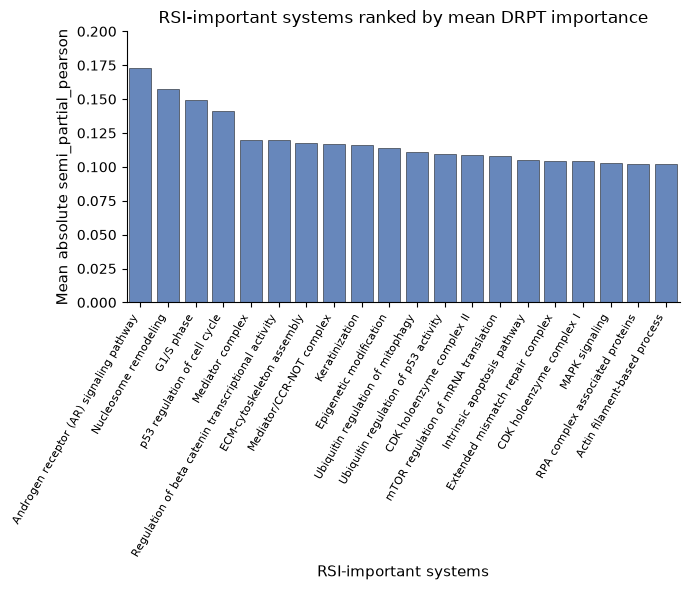

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from typing import Iterable, Optional, Dict, Any


def waterfall_rsi_important_systems_by_mean_importance(
    importance_df: pd.DataFrame,
    rsi_important_systems: Iterable[str],
    name_to_new_name: pd.DataFrame,
    out_svg: str,
    score_col: str = "semi_partial_pearson",
    system_col: str = "system",
    drug_col: str = "drug",
    current_name_col: str = "Current Name",
    new_name_col: str = "New Name",
    use_abs: bool = True,
    top_n: Optional[int] = None,
    figsize=(8.5, 4.8),
    title: Optional[str] = None,
    bar_color: str = "#4C72B0",
    edge_color: str = "black",
    bar_alpha: float = 0.85,
    x_label_rotation: int = 60,
    fontsize_xtick: int = 8,
    fontsize_axis: int = 11,
    fontsize_title: int = 12,
    y_label: Optional[str] = None,
    y_min: float = 0.0,
    y_max: float = 0.2,
    save_svg: bool = True,
    show_plot: bool = True,
) -> Dict[str, Any]:
    """
    Create a waterfall/bar plot of RSI-important systems ranked by mean importance score.

    System names in importance_df are expected to match name_to_new_name[current_name_col].
    The x-axis labels use name_to_new_name[new_name_col].

    Parameters
    ----------
    importance_df : pd.DataFrame
        Long-form system importance dataframe. Expected columns include system, drug, and score.

    rsi_important_systems : iterable of str
        Important systems to retain before ranking.

    name_to_new_name : pd.DataFrame
        Mapping dataframe with columns:
            - current_name_col, default "Current Name"
            - new_name_col, default "New Name"

    out_svg : str
        Output SVG filename.

    top_n : int or None
        Number of top-ranked systems to show.
        If None, show all RSI-important systems.

    use_abs : bool
        If True, rank by mean absolute importance.
        If False, rank by mean signed importance.

    Returns
    -------
    dict
        Includes the ranked plotting table.
    """

    # ----------------------------
    # Validate inputs
    # ----------------------------
    required_importance_cols = {system_col, drug_col, score_col}
    missing = required_importance_cols - set(importance_df.columns)

    if missing:
        raise KeyError(f"importance_df missing required column(s): {missing}")

    required_name_cols = {current_name_col, new_name_col}
    missing_name_cols = required_name_cols - set(name_to_new_name.columns)

    if missing_name_cols:
        raise KeyError(f"name_to_new_name missing required column(s): {missing_name_cols}")

    rsi_important_systems = [
        str(s)
        for s in rsi_important_systems
        if s is not None and str(s).strip()
    ]

    if len(rsi_important_systems) == 0:
        raise ValueError("rsi_important_systems is empty.")

    if top_n is not None:
        top_n = int(top_n)
        if top_n <= 0:
            raise ValueError("top_n must be a positive integer or None.")

    rsi_important_set = set(rsi_important_systems)

    # ----------------------------
    # Build system-name mapping
    # ----------------------------
    name_map_df = name_to_new_name[[current_name_col, new_name_col]].copy()

    name_map_df[current_name_col] = name_map_df[current_name_col].astype(str)
    name_map_df[new_name_col] = name_map_df[new_name_col].astype(str)

    # If duplicate current names exist, keep the first mapping.
    name_map_df = name_map_df.drop_duplicates(subset=[current_name_col], keep="first")

    system_name_map = dict(
        zip(
            name_map_df[current_name_col],
            name_map_df[new_name_col],
        )
    )

    # ----------------------------
    # Prepare importance dataframe
    # ----------------------------
    df = importance_df[[system_col, drug_col, score_col]].copy()

    df[system_col] = df[system_col].astype(str)
    df[drug_col] = df[drug_col].astype(str)
    df[score_col] = pd.to_numeric(df[score_col], errors="coerce")

    df = df.dropna(subset=[score_col])
    df = df[df[system_col].isin(rsi_important_set)].copy()

    if df.empty:
        raise ValueError(
            "No rows remain after filtering importance_df to rsi_important_systems. "
            "Check that system names match exactly."
        )

    if use_abs:
        df["importance_score"] = df[score_col].abs()
        score_label = f"Mean absolute {score_col}"
    else:
        df["importance_score"] = df[score_col]
        score_label = f"Mean {score_col}"

    # ----------------------------
    # Aggregate across drugs
    # ----------------------------
    ranked = (
        df.groupby(system_col, as_index=False)
        .agg(
            mean_importance_score=("importance_score", "mean"),
            n_drugs=(drug_col, "nunique"),
            n_rows=(score_col, "size"),
        )
        .rename(columns={system_col: "system"})
    )

    ranked = ranked.sort_values(
        "mean_importance_score",
        ascending=False,
    ).reset_index(drop=True)

    ranked["rank"] = np.arange(1, len(ranked) + 1)

    # Add display names for plotting.
    # If no mapping exists, fall back to the original system name.
    ranked["display_name"] = ranked["system"].map(
        lambda s: system_name_map.get(str(s), str(s))
    )

    # ----------------------------
    # Apply top-N filter
    # ----------------------------
    if top_n is not None:
        ranked_plot = ranked.head(top_n).copy()
    else:
        ranked_plot = ranked.copy()

    if ranked_plot.empty:
        raise ValueError("No systems available to plot after top_n filtering.")

    # ----------------------------
    # Plot
    # ----------------------------
    fig, ax = plt.subplots(figsize=figsize)

    x = np.arange(len(ranked_plot))

    ax.bar(
        x,
        ranked_plot["mean_importance_score"],
        color=bar_color,
        edgecolor=edge_color,
        linewidth=0.4,
        alpha=bar_alpha,
    )

    ax.set_xticks(x)
    ax.set_xticklabels(
        ranked_plot["display_name"],
        rotation=x_label_rotation,
        ha="right" if x_label_rotation != 0 else "center",
        fontsize=fontsize_xtick,
    )

    ax.set_xlabel("RSI-important systems", fontsize=fontsize_axis)

    if y_label is None:
        y_label = score_label

    ax.set_ylabel(y_label, fontsize=fontsize_axis)

    ax.set_ylim(float(y_min), float(y_max))

    # Remove horizontal margin between the y-axis and first bar.
    ax.set_xlim(-0.5, len(ranked_plot) - 0.5)
    ax.margins(x=0)

    if title is not None:
        ax.set_title(title, fontsize=fontsize_title)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)

    plt.tight_layout()

    if save_svg:
        plt.rcParams["svg.fonttype"] = "none"
        fig.savefig(out_svg, format="svg", bbox_inches="tight")
        print(f"Saved SVG to: {out_svg}")

    if show_plot:
        plt.show()
    else:
        plt.close(fig)

    return {
        "ranked_table_all": ranked,
        "ranked_table_plotted": ranked_plot,
        "n_systems_total": int(len(ranked)),
        "n_systems_plotted": int(len(ranked_plot)),
        "score_col": score_col,
        "use_abs": bool(use_abs),
        "top_n": top_n,
        "out_svg": out_svg,
    }


# ---------------------------------------------------------------------
# Example usage
# ---------------------------------------------------------------------

result = waterfall_rsi_important_systems_by_mean_importance(
    importance_df=importance_df_semi,
    rsi_important_systems=rsi_important_systems,
    name_to_new_name=name_to_new_name,
    out_svg="rsi_important_systems_mean_importance_waterfall.svg",
    score_col="semi_partial_pearson",
    system_col="system",
    drug_col="drug",
    current_name_col="Current Name",
    new_name_col="New Name",
    use_abs=True,
    top_n=20,  # set to e.g. 20 to show only the top 20 systems
    figsize=(7, 6),
    title="RSI-important systems ranked by mean DRPT importance",
    x_label_rotation=60,
    y_min=0.0,
    y_max=0.2,
)

### b. AR signaling genes and their alterations (Supplementary Fig. 7b)

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Basic loaders
# ------------------------------------------------------------
def _read_single_column_series(path: str) -> pd.Series:
    df = pd.read_csv(path, header=None, sep="\t", engine="python", dtype=str)
    if df.shape[1] != 1:
        raise ValueError(f"{path} should have exactly one column; got {df.shape[1]}")
    return df.iloc[:, 0].astype(str).str.strip()


def _parse_binary_matrix(series_of_rows: pd.Series, n_cols_expected: int) -> np.ndarray:
    rows = [np.fromstring(row, sep=",", dtype=np.int8) for row in series_of_rows.values]
    arr = np.vstack(rows)

    if arr.shape[1] != n_cols_expected:
        raise ValueError(f"Parsed matrix has {arr.shape[1]} columns, expected {n_cols_expected}.")

    return arr


def _load_indices(cell_index_file: str, gene_index_file: str):
    cell_df = pd.read_csv(cell_index_file, sep="\t", header=None, names=["Index", "CellLine"])
    gene_df = pd.read_csv(gene_index_file, sep="\t", header=None, names=["Index", "Gene"])

    cell_df["Index"] = pd.to_numeric(cell_df["Index"], errors="coerce").astype(int)
    gene_df["Index"] = pd.to_numeric(gene_df["Index"], errors="coerce").astype(int)

    cell_df = cell_df.sort_values("Index")
    gene_df = gene_df.sort_values("Index")

    cell_lines = list(cell_df["CellLine"].astype(str))
    genes = list(gene_df["Gene"].astype(str))

    return cell_lines, genes


def load_binary_matrix_from_singlecol(path: str, cell_lines, gene_names):
    s = _read_single_column_series(path)
    arr = _parse_binary_matrix(s, n_cols_expected=len(gene_names))

    if arr.shape[0] != len(cell_lines):
        raise ValueError(
            f"{path}: parsed {arr.shape[0]} rows but expected {len(cell_lines)} cell lines."
        )

    return pd.DataFrame(
        arr,
        index=pd.Index(cell_lines, name="cell_line"),
        columns=pd.Index(gene_names, name="gene")
    )


# ------------------------------------------------------------
# Main plotting function
# ------------------------------------------------------------
def plot_system_stacked_gene_alteration_frequencies(
    system_name,
    system_to_genes,

    amp_file="data/cell2cnamplification_ctg_av.txt",
    del_file="data/cell2cndeletion_ctg_av.txt",
    mut_file="data/cell2mutation_ctg_av.txt",

    cell_index_file="data/cell2ind_av.txt",
    gene_index_file="data/gene2ind_ctg_av.txt",

    figsize=(10, 5),

    colors=None,

    ylabel="Fraction of Cell Lines Altered",
    title=None,
    ylim=(0, 1),

    sort_by_total_altered=True,

    rotation=45,
    out_svg=None,
    show=True,
):
    """
    One stacked bar per gene.

    Bar height:
        fraction of all cell lines altered for that gene.

    Stacked categories:
        amp
        del
        mut
        amp+mut
        del+mut

    Notes:
        This assumes amp and del are mutually exclusive for a given gene/cell.
        If amp+del or amp+del+mut occur, they are counted in an 'other' column
        in the returned dataframe but not plotted unless you add it manually.
    """

    if colors is None:
        colors = {
            "amp": "red",
            "del": "blue",
            "mut": "green",
            "amp+mut": "yellow",
            "del+mut": "cyan",
        }

    categories = ["amp", "del", "mut", "amp+mut", "del+mut"]

    # ------------------------------------------------------------
    # Load indices and matrices
    # ------------------------------------------------------------
    cell_lines, all_genes = _load_indices(cell_index_file, gene_index_file)

    amp_df = load_binary_matrix_from_singlecol(amp_file, cell_lines, all_genes)
    del_df = load_binary_matrix_from_singlecol(del_file, cell_lines, all_genes)
    mut_df = load_binary_matrix_from_singlecol(mut_file, cell_lines, all_genes)

    # ------------------------------------------------------------
    # System genes
    # ------------------------------------------------------------
    if system_name not in system_to_genes:
        raise KeyError(f"System '{system_name}' not found in system_to_genes.")

    system_genes_raw = list(system_to_genes[system_name])
    system_genes = [g for g in system_genes_raw if g in all_genes]

    if len(system_genes) == 0:
        raise ValueError(f"No genes from system '{system_name}' found in indexed panel.")

    # ------------------------------------------------------------
    # Compute stacked frequencies
    # ------------------------------------------------------------
    records = []
    n_cells = len(cell_lines)

    for gene in system_genes:
        amp = amp_df[gene].astype(int) == 1
        dele = del_df[gene].astype(int) == 1
        mut = mut_df[gene].astype(int) == 1

        amp_only = amp & ~dele & ~mut
        del_only = dele & ~amp & ~mut
        mut_only = mut & ~amp & ~dele
        amp_mut = amp & mut & ~dele
        del_mut = dele & mut & ~amp

        # Rare/ambiguous cases, not plotted by default
        amp_del = amp & dele & ~mut
        amp_del_mut = amp & dele & mut

        total_altered = amp | dele | mut

        records.append({
            "gene": gene,
            "amp": amp_only.mean(),
            "del": del_only.mean(),
            "mut": mut_only.mean(),
            "amp+mut": amp_mut.mean(),
            "del+mut": del_mut.mean(),
            "other_amp+del": amp_del.mean(),
            "other_amp+del+mut": amp_del_mut.mean(),
            "total_altered": total_altered.mean(),
            "n_amp": int(amp_only.sum()),
            "n_del": int(del_only.sum()),
            "n_mut": int(mut_only.sum()),
            "n_amp+mut": int(amp_mut.sum()),
            "n_del+mut": int(del_mut.sum()),
            "n_other_amp+del": int(amp_del.sum()),
            "n_other_amp+del+mut": int(amp_del_mut.sum()),
            "n_total_altered": int(total_altered.sum()),
            "n_cells": n_cells,
        })

    stacked_df = pd.DataFrame(records)

    if sort_by_total_altered:
        stacked_df = (
            stacked_df
            .sort_values("total_altered", ascending=False)
            .reset_index(drop=True)
        )

    # ------------------------------------------------------------
    # Plot
    # ------------------------------------------------------------
    fig, ax = plt.subplots(figsize=figsize)

    x = np.arange(stacked_df.shape[0]) * 0.8
    bottom = np.zeros(stacked_df.shape[0])

    for cat in categories:
        vals = stacked_df[cat].values

        ax.bar(
            x,
            vals,
            width=0.6,
            bottom=bottom,
            color=colors[cat],
            edgecolor="black",
            linewidth=0.6,
            label=cat
        )

        bottom += vals

    ax.set_xticks(x)
    ax.set_xticklabels(
        stacked_df["gene"].values,
        rotation=rotation,
        ha="right" if rotation != 0 else "center"
    )

    ax.set_ylabel(ylabel)

    if title is None:
        title = f"{system_name}: stacked alteration frequencies (n={n_cells} cell lines)"

    ax.set_title(title)
    ax.set_ylim(ylim)

    ax.legend(frameon=False, title="Alteration", fontsize=9, title_fontsize=10)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    if out_svg is not None:
        plt.rcParams["svg.fonttype"] = "none"
        fig.savefig(out_svg, format="svg", bbox_inches="tight")
        print(f"Saved SVG to: {out_svg}")

    if show:
        plt.show()

    return stacked_df

Saved SVG to: ar_signaling_stacked_alteration_frequencies.svg


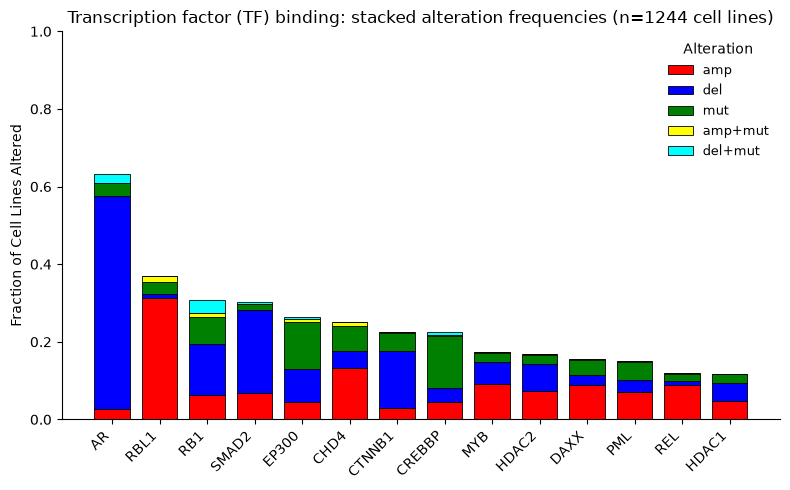

In [50]:
stacked_df = plot_system_stacked_gene_alteration_frequencies(
    system_name="Transcription factor (TF) binding",
    system_to_genes=system_to_genes,
    figsize=(8, 5),
    out_svg="ar_signaling_stacked_alteration_frequencies.svg"
)

### c. System copy number burden and response outcome visualized through the embedding space (Supplementary Fig. 7c,e)

In [51]:
from typing import Optional
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from scipy.sparse import coo_matrix
import matplotlib.pyplot as plt
from typing import Optional

# ---------------------------
# 1) EMBEDDINGS (per system for ONE drug)
# ---------------------------
def build_system_embeddings_for_drug(results, drug, system_name, system_to_index):
    """
    Get cell-line embeddings for a given system for ONE drug.

    results[drug]["celllines"] -> list[str]
    results[drug]["system_embeddings_forward"] -> np.ndarray (N_cells, 131, 128)
    """
    sys_idx = system_to_index[system_name]
    cells = results[drug]["celllines"]
    emb3d = results[drug]["system_embeddings"]      # (n_cells, 131, 128)
    emb2d = emb3d[:, sys_idx, :]                    # (n_cells, 128)
    emb_df = pd.DataFrame(emb2d, index=pd.Index(cells, name="cell_line"))
    emb_df.columns = [f"e{i}" for i in range(emb_df.shape[1])]
    emb_df = emb_df[~emb_df.index.duplicated(keep='first')]
    return emb_df

# ---------------------------
# 2) TORCH kNN (cosine) -> COO matrix
# ---------------------------
def torch_knn_cosine(emb_df, k=15, device: Optional[str] = None):
    """
    Build kNN (cosine) graph using PyTorch.
    Returns row, col, sim, N (torch tensors), where sim is clamped to [0,1].
    """
    N, D = emb_df.shape
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    X = torch.from_numpy(emb_df.values).to(device=device, dtype=torch.float32)

    X = F.normalize(X, p=2, dim=1)     # unit vectors
    S = X @ X.t()                      # cosine in [-1,1]
    S.fill_diagonal_(-1.0)             # exclude self
    k_eff = min(k, max(N - 1, 1))
    vals, idxs = torch.topk(S, k=k_eff, dim=1, largest=True, sorted=False)

    row = torch.arange(N, device=device).unsqueeze(1).expand_as(idxs).reshape(-1)
    col = idxs.reshape(-1)
    sim = torch.clamp(vals.reshape(-1), min=0.0, max=1.0)
    return row, col, sim, N

def knn_coo_from_torch(row, col, sim, emb_df):
    """
    Recompute cosine on the selected edges and return a COO.
    """
    X = torch.from_numpy(emb_df.values).to(sim.device, dtype=torch.float32)
    X = F.normalize(X, p=2, dim=1)
    cos_sim = F.cosine_similarity(X[row], X[col], dim=1)
    cos_sim = torch.clamp(cos_sim, min=0.0, max=1.0)
    row_cpu = row.detach().cpu().numpy()
    col_cpu = col.detach().cpu().numpy()
    sim_cpu = cos_sim.detach().cpu().numpy()
    N = emb_df.shape[0]
    return coo_matrix((sim_cpu, (row_cpu, col_cpu)), shape=(N, N))

# ---------------------------
# 3) 2D LAYOUT (UMAP/TSNE/PCA) + plotting helpers
# ---------------------------
def to_2d(emb_df, method="umap", random_state=0):
    X = emb_df.values
    try:
        import umap
        reducer = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1, random_state=random_state)
        Y = reducer.fit_transform(X)
        return pd.DataFrame(Y, index=emb_df.index, columns=["x","y"])
    except Exception:
        try:
            from sklearn.manifold import TSNE
            Y = TSNE(n_components=2, init='pca', learning_rate='auto', perplexity=30, random_state=random_state).fit_transform(X)
            return pd.DataFrame(Y, index=emb_df.index, columns=["x","y"])
        except Exception:
            from sklearn.decomposition import PCA
            Y = PCA(n_components=2, random_state=random_state).fit_transform(X)
            return pd.DataFrame(Y, index=emb_df.index, columns=["x","y"])

def plot_scatter(ax, coords2d, values, title, cmap='viridis', s=24, alpha=0.9):
    sc = ax.scatter(coords2d['x'], coords2d['y'], c=values.values, s=s, alpha=alpha, cmap=cmap)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title)
    cb = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label(values.name)

def knn_weighted_smooth(values, W_coo):
    """
    Weighted neighbor smoothing: s_i = sum_j w_ij * x_j / sum_j w_ij
    Assumes W_coo is potentially asymmetric; uses symmetric CSR under the hood.
    """
    W = (W_coo + W_coo.T).tocsr()
    x = values.values.astype(float)
    sm = np.zeros_like(x)
    indptr, indices, data = W.indptr, W.indices, W.data
    for i in range(W.shape[0]):
        start, end = indptr[i], indptr[i+1]
        nbrs = indices[start:end]
        wts  = data[start:end]
        sm[i] = np.average(x[nbrs], weights=wts) if wts.size else np.nan
    return pd.Series(sm, index=values.index, name=values.name + "_kNNsmooth")

# ---------------------------
# 4) CNA/MUT helpers (TAB-separated single-column '0,1,1,0,...' files)
# ---------------------------
def _read_single_column_series(path: str) -> pd.Series:
    df = pd.read_csv(path, header=None, sep="\t", engine="python", dtype=str)
    if df.shape[1] != 1:
        raise ValueError(f"{path} should have exactly one column; got {df.shape[1]}")
    return df.iloc[:, 0].astype(str).str.strip()

def _parse_binary_matrix(series_of_rows: pd.Series, n_cols_expected: int) -> np.ndarray:
    rows = [np.fromstring(row, sep=',', dtype=np.int8) for row in series_of_rows.values]
    arr = np.vstack(rows)
    if arr.shape[1] != n_cols_expected:
        raise ValueError(f"Parsed matrix has {arr.shape[1]} columns, expected {n_cols_expected}.")
    return arr

def _load_indices(cell_index_file: str, gene_index_file: str):
    cell_map = pd.read_csv(cell_index_file, header=None, sep="\t", engine="python", dtype=str).iloc[:, :2]
    cell_map.columns = ["index", "cell_line"]
    cell_map["index"] = pd.to_numeric(cell_map["index"], errors="coerce").astype(int)
    cell_map = cell_map.sort_values("index")
    cell_idx = pd.Index(cell_map["cell_line"].values, name="cell_line")

    gene_map = pd.read_csv(gene_index_file, header=None, sep="\t", engine="python", dtype=str).iloc[:, :2]
    gene_map.columns = ["index", "gene"]
    gene_map["index"] = pd.to_numeric(gene_map["index"], errors="coerce").astype(int)
    gene_map = gene_map.sort_values("index")
    gene_idx = pd.Index(gene_map["gene"].values, name="gene")
    return cell_idx, gene_idx

def umap_burden_and_single_drug_auc_stacked(
    results,
    drug: str,
    system_name: str,
    system_to_index: dict,
    system_to_genes: dict,
    amp_file: str,
    del_file: str,
    mut_file: str,
    cell_index_file: str,
    gene_index_file: str,
    which_auc: str = "predictions",   # "predictions" or "actual"
    burden_mode: str = "cn",          # "cn" or "tmb"
    burden_scope: str = "global",     # "global" or "local"
    knn_smooth: bool = True,
    k: int = 15,
    device: Optional[str] = None,
    random_state: int = 0,
    figsize=(7, 10),
    cmap="viridis",
    out_svg="single_drug_umap_stacked.svg"
):
    """
    Produces 2 vertically stacked UMAPs for ONE system and ONE drug:

      1) Burden signal (CN or TMB; global or local)
      2) AUC for the specified drug

    Workflow:
      - Uses the specified drug's system embeddings
      - Restricts embeddings, burden, and AUC series to common cell lines
      - Computes one shared 2D layout
      - Optionally applies one shared kNN graph for smoothing
      - Saves the full figure to SVG
    """

    burden_mode = str(burden_mode).lower().strip()
    burden_scope = str(burden_scope).lower().strip()

    if burden_mode not in ("cn", "tmb"):
        raise ValueError("burden_mode must be 'cn' or 'tmb'")

    if burden_scope not in ("global", "local"):
        raise ValueError("burden_scope must be 'global' or 'local'")

    if which_auc not in ("predictions", "actual"):
        raise ValueError("which_auc must be 'predictions' or 'actual'")

    if drug not in results:
        raise KeyError(f"Drug '{drug}' not found in results.")

    # -----------------------------
    # Embeddings
    # -----------------------------
    emb_df_full = build_system_embeddings_for_drug(
        results,
        drug,
        system_name,
        system_to_index
    )

    # -----------------------------
    # AUC series
    # -----------------------------
    cells = pd.Index(results[drug]["celllines"], name="cell_line")
    auc_vals = np.asarray(results[drug][which_auc], dtype=float)

    auc = pd.Series(
        auc_vals,
        index=cells,
        name=f"{drug}_{which_auc.capitalize()}_AUC"
    )

    auc = auc[~auc.index.duplicated(keep="first")]
    auc = auc[pd.notna(auc)]

    # -----------------------------
    # Load CNA/MUT matrices
    # -----------------------------
    cell_idx, gene_idx = _load_indices(
        cell_index_file,
        gene_index_file
    )

    G = len(gene_idx)

    amp_s = _read_single_column_series(amp_file)
    del_s = _read_single_column_series(del_file)
    mut_s = _read_single_column_series(mut_file)

    if (
        len(amp_s) != len(cell_idx)
        or len(del_s) != len(cell_idx)
        or len(mut_s) != len(cell_idx)
    ):
        raise ValueError(
            f"Row mismatch: amp({len(amp_s)}), "
            f"del({len(del_s)}), mut({len(mut_s)}), "
            f"cells({len(cell_idx)})"
        )

    amp = _parse_binary_matrix(
        amp_s,
        n_cols_expected=G
    )

    dele = _parse_binary_matrix(
        del_s,
        n_cols_expected=G
    )

    mut = _parse_binary_matrix(
        mut_s,
        n_cols_expected=G
    )

    # -----------------------------
    # Decide burden columns
    # -----------------------------
    if burden_scope == "global":

        cols = None
        denom = float(G)
        scope_label = "Global"

    else:

        if system_name not in system_to_genes:
            raise KeyError(
                f"system_name '{system_name}' not found in system_to_genes"
            )

        sys_genes = [
            str(g)
            for g in system_to_genes[system_name]
        ]

        if len(sys_genes) == 0:
            raise ValueError(
                f"system_to_genes['{system_name}'] is empty "
                f"(cannot compute local burden)."
            )

        missing = [
            g for g in sys_genes
            if g not in gene_idx
        ]

        if len(missing) > 0:
            raise KeyError(
                "Some system genes are not in gene_index_file. "
                f"Missing (showing up to 25): {missing[:25]}"
            )

        cols = np.array(
            [int(gene_idx.get_loc(g)) for g in sys_genes],
            dtype=int
        )

        denom = float(len(sys_genes))
        scope_label = "Local"

    # -----------------------------
    # Compute burden
    # -----------------------------
    if burden_mode == "cn":

        if cols is None:
            counts = (
                amp.sum(axis=1, dtype=np.int32)
                + dele.sum(axis=1, dtype=np.int32)
            )
        else:
            counts = (
                amp[:, cols].sum(axis=1, dtype=np.int32)
                + dele[:, cols].sum(axis=1, dtype=np.int32)
            )

        burden_all = counts.astype(float) / denom
        burden_name = f"{scope_label} copy-number burden"

    else:

        if cols is None:
            counts = mut.sum(axis=1, dtype=np.int32)
        else:
            counts = mut[:, cols].sum(axis=1, dtype=np.int32)

        burden_all = counts.astype(float) / denom
        burden_name = f"{scope_label} tumor mutation burden"

    burden = pd.Series(
        burden_all,
        index=cell_idx,
        name=burden_name
    )

    burden = burden[~burden.index.duplicated(keep="first")]

    # -----------------------------
    # Intersect cells
    # -----------------------------
    common = (
        emb_df_full.index
        .intersection(burden.index)
        .intersection(auc.index)
    )

    if len(common) < 3:
        raise ValueError(
            "Not enough common cell lines across embeddings, burden, "
            "and drug AUC series (need >= 3)."
        )

    emb_df = emb_df_full.loc[common].copy()
    burden = burden.loc[common].copy()
    auc = auc.loc[common].copy()

    # -----------------------------
    # Shared 2D coordinates
    # -----------------------------
    coords2d = to_2d(
        emb_df,
        method="umap",
        random_state=random_state
    )

    # -----------------------------
    # Optional kNN smoothing
    # -----------------------------
    W = None

    if knn_smooth:

        row, col, sim, _ = torch_knn_cosine(
            emb_df,
            k=k,
            device=device
        )

        W = knn_coo_from_torch(
            row,
            col,
            sim,
            emb_df
        )

        burden_plot = knn_weighted_smooth(
            burden.reset_index(drop=True),
            W
        )

        auc_plot = knn_weighted_smooth(
            auc.reset_index(drop=True),
            W
        )

        burden_plot.index = emb_df.index
        auc_plot.index = emb_df.index

        burden_plot = burden_plot.rename(
            f"{burden.name} (kNN-Smoothed)"
        )

        auc_plot = auc_plot.rename(
            f"{drug} {which_auc.capitalize()} AUC (kNN-Smoothed)"
        )

        titles = [
            f"{system_name}: {burden.name} (kNN-smoothed)",
            f"{drug} · {system_name}: {which_auc.capitalize()} AUC (kNN-smoothed)",
        ]

    else:

        burden_plot = burden.rename(burden.name)

        auc_plot = auc.rename(
            f"{drug} {which_auc.capitalize()} AUC"
        )

        titles = [
            f"{system_name}: {burden.name}",
            f"{drug} · {system_name}: {which_auc.capitalize()} AUC",
        ]

    # -----------------------------
    # Plot 2 vertically stacked UMAPs
    # -----------------------------
    fig, axes = plt.subplots(
        2,
        1,
        figsize=figsize
    )

    plot_scatter(
        axes[0],
        coords2d,
        burden_plot,
        titles[0],
        cmap=cmap
    )

    plot_scatter(
        axes[1],
        coords2d,
        auc_plot,
        titles[1],
        cmap=cmap
    )

    plt.tight_layout()

    plt.rcParams["svg.fonttype"] = "none"

    fig.savefig(
        out_svg,
        format="svg",
        bbox_inches="tight"
    )

    plt.show()

    print(f"Saved SVG to: {out_svg}")

    out = {
        "drug": drug,
        "emb_df": emb_df,
        "coords2d": coords2d,
        "W": W,
        "burden_mode": burden_mode,
        "burden_scope": burden_scope,
        "burden": burden,
        "auc": auc,
        "common_cells": common,
        "knn_smooth": bool(knn_smooth),
        "k": int(k),
        "panel_gene_count": int(G),
        "figure": fig,
        "out_svg": out_svg,
    }

    if burden_scope == "local":
        out["local_system_gene_count"] = int(len(system_to_genes[system_name]))
        out["local_system_genes"] = list(map(str, system_to_genes[system_name]))

    if knn_smooth:
        out["burden_smooth"] = burden_plot
        out["auc_smooth"] = auc_plot

    return out

ModuleNotFoundError: No module named 'torch'

### d. System alterations in the embedding space (Fig. 6g, Supplementary Fig. 7d)

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ---------------------------
# Basic loaders
# ---------------------------
def _read_single_column_series(path: str) -> pd.Series:
    df = pd.read_csv(path, header=None, sep="\t", engine="python", dtype=str)
    if df.shape[1] != 1:
        raise ValueError(f"{path} should have exactly one column; got {df.shape[1]}")
    return df.iloc[:, 0].astype(str).str.strip()


def _parse_binary_matrix(series_of_rows: pd.Series, n_cols_expected: int) -> np.ndarray:
    rows = [np.fromstring(row, sep=",", dtype=np.int8) for row in series_of_rows.values]
    arr = np.vstack(rows)

    if arr.shape[1] != n_cols_expected:
        raise ValueError(
            f"Parsed matrix has {arr.shape[1]} columns, expected {n_cols_expected}."
        )

    return arr


def _load_indices(cell_index_file: str, gene_index_file: str):
    cell_df = pd.read_csv(cell_index_file, sep="\t", header=None, names=["Index", "CellLine"])
    gene_df = pd.read_csv(gene_index_file, sep="\t", header=None, names=["Index", "Gene"])

    cell_df["Index"] = pd.to_numeric(cell_df["Index"], errors="coerce").astype(int)
    gene_df["Index"] = pd.to_numeric(gene_df["Index"], errors="coerce").astype(int)

    cell_df = cell_df.sort_values("Index")
    gene_df = gene_df.sort_values("Index")

    cell_lines = pd.Index(cell_df["CellLine"].astype(str), name="cell_line")
    genes = pd.Index(gene_df["Gene"].astype(str), name="gene")

    return cell_lines, genes


# ---------------------------
# Dimensionality reduction
# ---------------------------
def _to_2d(emb_df, random_state=0):
    X = emb_df.values

    try:
        import umap

        reducer = umap.UMAP(
            n_components=2,
            n_neighbors=30,
            min_dist=0.1,
            random_state=random_state
        )

        Y = reducer.fit_transform(X)
        return pd.DataFrame(Y, index=emb_df.index, columns=["x", "y"])

    except Exception:
        try:
            from sklearn.manifold import TSNE

            perplexity = max(5, min(30, (len(emb_df) - 1) // 3))

            Y = TSNE(
                n_components=2,
                init="pca",
                learning_rate="auto",
                perplexity=perplexity,
                random_state=random_state
            ).fit_transform(X)

            return pd.DataFrame(Y, index=emb_df.index, columns=["x", "y"])

        except Exception:
            from sklearn.decomposition import PCA

            Y = PCA(n_components=2, random_state=random_state).fit_transform(X)
            return pd.DataFrame(Y, index=emb_df.index, columns=["x", "y"])


# ---------------------------
# Main plotting function
# ---------------------------
def plot_single_drug_umap_by_two_alterations(
    results,
    drug,
    system_name,
    gene1,
    alt1,  # "amp", "del", or "mut"
    gene2,
    alt2,  # "amp", "del", or "mut"
    system_to_index,
    amp_file,
    del_file,
    mut_file,
    cell_index_file,
    gene_index_file,
    response_key="predictions",
    random_state=0,
    figsize=(5.5, 6),
    point_size=24,
    alpha=0.9,
    unaltered_color="#BFBFBF",
    gene1_color="red",
    gene2_color="blue",
    both_color="purple",
    title_fontsize=13,
    legend_fontsize=10,
    out_svg="single_drug_umap_two_alterations.svg",
    show=True,
):
    """
    Build one UMAP from system embeddings for a single drug and color cell lines by
    alteration state for two specified gene alterations.

    Colors:
        grey   = neither alteration
        red    = gene1 alteration only
        blue   = gene2 alteration only
        purple = both alterations

    Example:
        gene1="AR", alt1="del"
        gene2="RBL1", alt2="amp"
    """

    # ---------------------------
    # Validate inputs
    # ---------------------------
    if drug not in results:
        raise KeyError(f"Drug '{drug}' not found in results.")

    if system_name not in system_to_index:
        raise KeyError(f"System '{system_name}' not found in system_to_index.")

    alt1 = str(alt1).lower().strip()
    alt2 = str(alt2).lower().strip()

    if alt1 not in {"amp", "del", "mut"}:
        raise ValueError("alt1 must be one of: 'amp', 'del', or 'mut'.")

    if alt2 not in {"amp", "del", "mut"}:
        raise ValueError("alt2 must be one of: 'amp', 'del', or 'mut'.")

    gene1 = str(gene1).strip()
    gene2 = str(gene2).strip()

    # ---------------------------
    # Valid response cells
    # ---------------------------
    if response_key not in results[drug]:
        raise KeyError(f"results['{drug}'] does not contain '{response_key}'.")

    drug_cells = pd.Index(results[drug]["celllines"], name="cell_line")
    response_vals = np.asarray(results[drug][response_key], dtype=float)

    response_series = pd.Series(response_vals, index=drug_cells)
    response_series = response_series[~response_series.index.duplicated(keep="first")]
    response_series = response_series[pd.notna(response_series)]

    valid_response_cells = pd.Index(response_series.index, name="cell_line")

    # ---------------------------
    # Embeddings for specified system
    # ---------------------------
    sys_idx = system_to_index[system_name]

    emb3d = np.asarray(results[drug]["system_embeddings_forward"])
    emb_cells = pd.Index(results[drug]["celllines"], name="cell_line")

    if emb3d.ndim != 3:
        raise ValueError(
            f"Expected system_embeddings_forward to be 3D "
            f"(cells, systems, dim); got {emb3d.shape}"
        )

    if sys_idx < 0 or sys_idx >= emb3d.shape[1]:
        raise ValueError(
            f"System index {sys_idx} out of bounds for embeddings with shape {emb3d.shape}"
        )

    emb2d = emb3d[:, sys_idx, :]

    emb_df = pd.DataFrame(
        emb2d,
        index=emb_cells,
        columns=[f"e{i}" for i in range(emb2d.shape[1])]
    )

    emb_df = emb_df[~emb_df.index.duplicated(keep="first")].astype(float)

    # ---------------------------
    # Load genomic matrices
    # ---------------------------
    cell_idx, gene_idx = _load_indices(cell_index_file, gene_index_file)
    G = len(gene_idx)

    amp = _parse_binary_matrix(_read_single_column_series(amp_file), n_cols_expected=G)
    dele = _parse_binary_matrix(_read_single_column_series(del_file), n_cols_expected=G)
    mut = _parse_binary_matrix(_read_single_column_series(mut_file), n_cols_expected=G)

    # ---------------------------
    # Common cells
    # ---------------------------
    common = (
        emb_df.index
        .intersection(valid_response_cells)
        .intersection(cell_idx)
    )

    if len(common) < 3:
        raise ValueError(
            "Not enough common cell lines across embeddings, drug response, "
            "and genomic files. Need >= 3."
        )

    emb_df = emb_df.loc[common].copy()

    # ---------------------------
    # Shared 2D projection
    # ---------------------------
    coords2d = _to_2d(emb_df, random_state=random_state)

    # ---------------------------
    # Map common cells to genomic rows
    # ---------------------------
    row_map = {c: i for i, c in enumerate(cell_idx)}
    rows = np.array([row_map[c] for c in common], dtype=int)

    amp_sub = amp[rows, :]
    del_sub = dele[rows, :]
    mut_sub = mut[rows, :]

    # ---------------------------
    # Helper for alteration status
    # ---------------------------
    def get_alt_status(gene, alt):
        if gene not in gene_idx:
            raise ValueError(f"Gene '{gene}' not found in gene index file.")

        j = int(gene_idx.get_loc(gene))

        if alt == "amp":
            return amp_sub[:, j] == 1
        elif alt == "del":
            return del_sub[:, j] == 1
        elif alt == "mut":
            return mut_sub[:, j] == 1
        else:
            raise ValueError("alt must be one of: 'amp', 'del', or 'mut'.")

    is_alt1 = get_alt_status(gene1, alt1)
    is_alt2 = get_alt_status(gene2, alt2)

    neither = (~is_alt1) & (~is_alt2)
    gene1_only = is_alt1 & (~is_alt2)
    gene2_only = (~is_alt1) & is_alt2
    both = is_alt1 & is_alt2

    # ---------------------------
    # Assign colors
    # ---------------------------
    colors = np.array([unaltered_color] * len(common), dtype=object)
    edgecolors = np.array(["none"] * len(common), dtype=object)
    linewidths = np.zeros(len(common), dtype=float)

    colors[gene1_only] = gene1_color
    colors[gene2_only] = gene2_color
    colors[both] = both_color

    altered = is_alt1 | is_alt2
    edgecolors[altered] = "k"
    linewidths[altered] = 0.3

    n_neither = int(neither.sum())
    n_gene1_only = int(gene1_only.sum())
    n_gene2_only = int(gene2_only.sum())
    n_both = int(both.sum())

    # ---------------------------
    # Plot
    # ---------------------------
    fig, ax = plt.subplots(figsize=figsize)

    ax.scatter(
        coords2d["x"],
        coords2d["y"],
        s=point_size,
        c=colors,
        alpha=alpha,
        edgecolor=edgecolors,
        linewidth=linewidths,
    )

    ax.set_xticks([])
    ax.set_yticks([])

    title = (
        f"{drug} · {system_name}\n"
        f"{gene1} {alt1} × {gene2} {alt2}"
    )

    ax.set_title(title, fontsize=title_fontsize)

    from matplotlib.lines import Line2D

    legend_handles = [
        Line2D(
            [0], [0],
            marker="o",
            color="none",
            markerfacecolor=unaltered_color,
            markeredgecolor="none",
            markersize=6,
            label=f"Neither (n={n_neither})"
        ),
        Line2D(
            [0], [0],
            marker="o",
            color="none",
            markerfacecolor=gene1_color,
            markeredgecolor="k",
            markersize=6,
            label=f"{gene1} {alt1} only (n={n_gene1_only})"
        ),
        Line2D(
            [0], [0],
            marker="o",
            color="none",
            markerfacecolor=gene2_color,
            markeredgecolor="k",
            markersize=6,
            label=f"{gene2} {alt2} only (n={n_gene2_only})"
        ),
        Line2D(
            [0], [0],
            marker="o",
            color="none",
            markerfacecolor=both_color,
            markeredgecolor="k",
            markersize=6,
            label=f"Both (n={n_both})"
        ),
    ]

    ax.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.08),
        ncol=2,
        frameon=True,
        fontsize=legend_fontsize,
        handletextpad=0.4,
        columnspacing=0.9
    )

    plt.tight_layout()

    if out_svg is not None:
        plt.rcParams["svg.fonttype"] = "none"
        fig.savefig(out_svg, format="svg", bbox_inches="tight")
        print(f"Saved SVG to: {out_svg}")

    if show:
        plt.show()

    out = {
        "drug": drug,
        "system_name": system_name,
        "gene1": gene1,
        "alt1": alt1,
        "gene2": gene2,
        "alt2": alt2,
        "common_cells": list(common),
        "coords2d": coords2d,
        "n_neither": n_neither,
        "n_gene1_only": n_gene1_only,
        "n_gene2_only": n_gene2_only,
        "n_both": n_both,
        "figure": fig,
        "axis": ax,
        "out_svg": out_svg,
    }

    return out

#### Angiogenesis, FCGR2A amp x SOX17 amp (Fig. 6g)

Saved SVG to: doxorubicin_FCGR2Aamp_SOX17amp_umap.svg


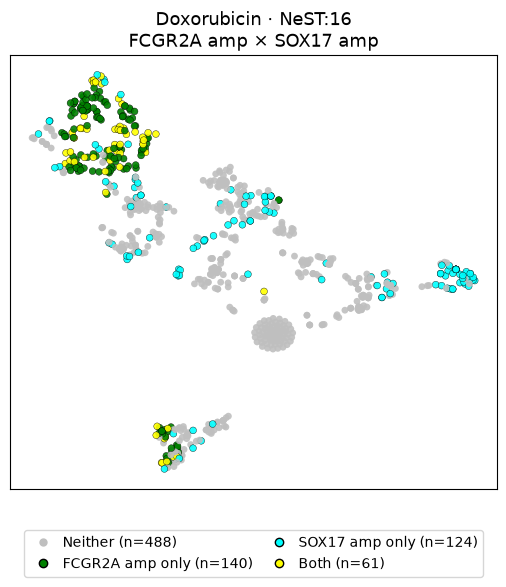

In [59]:
out = plot_single_drug_umap_by_two_alterations(
    results=results,
    drug="Doxorubicin",
    system_name="NeST:16", # this is also the "angiogenesis system"
    gene1="FCGR2A",
    alt1="amp",
    gene2="SOX17",
    alt2="amp",
    system_to_index=system_to_index,
    amp_file="data/cell2cnamplification_ctg_av.txt",
    del_file="data/cell2cndeletion_ctg_av.txt",
    mut_file="data/cell2mutation_ctg_av.txt",
    cell_index_file="data/cell2ind_av.txt",
    gene_index_file="data/gene2ind_ctg_av.txt",
    gene1_color="green",
    gene2_color="cyan",
    both_color="yellow",
    out_svg="doxorubicin_FCGR2Aamp_SOX17amp_umap.svg"
)

#### AR signaling, AR del x RBL1 amp (Supplementary Fig. 7e)

Saved SVG to: etoposide_ARdel_RBL1amp_umap.svg


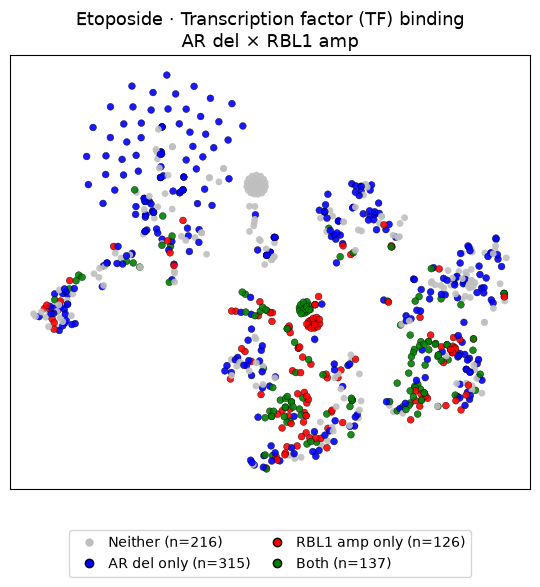

In [60]:
out = plot_single_drug_umap_by_two_alterations(
    results=results,
    drug="Etoposide",
    system_name="Transcription factor (TF) binding", # this is also the "AR signaling" system
    gene1="AR",
    alt1="del",
    gene2="RBL1",
    alt2="amp",
    system_to_index=system_to_index,
    amp_file="data/cell2cnamplification_ctg_av.txt",
    del_file="data/cell2cndeletion_ctg_av.txt",
    mut_file="data/cell2mutation_ctg_av.txt",
    cell_index_file="data/cell2ind_av.txt",
    gene_index_file="data/gene2ind_ctg_av.txt",
    gene1_color="blue",
    gene2_color="red",
    both_color="green",
    out_svg="etoposide_ARdel_RBL1amp_umap.svg"
)